# Electric cable instance segmentation

**RF-DETR · instance masks · PCA / geometric post-processing**

**Research notebook — guided, lightweight edition**  
Paolo Pangallo & Gianluigi Oricchio · University of Calabria

This research explores segmentation of thin, elongated electrical cables, including dataset diagnostics, RF-DETR, geometry-aware reconstruction, and optional SAM/line-guided alternatives.

> **Important:** This notebook records experiments carried out at different stages, not a single end-to-end pipeline. Several cells expect Colab/Google Drive paths, saved checkpoints, generated JSON files or outputs of alternative experiments. Do **not** use “Run all” without adapting inputs and selecting a coherent experiment path. Code is preserved in its historical order to avoid silently changing dependencies.

## Reading and reproducibility

Use Jupyter's **Table of Contents** to move between numbered chapters. Marked optional steps can modify data, install different packages, or train expensive models; run only the relevant ones. Saved plots and full console logs are retained in the [original research notebook](Segmentation.ipynb); this edition intentionally omits large captured outputs to render quickly on GitHub. **Removing stored outputs does not remove the plotting code.**

The [repository README](README.md) reports **1,242 images** (842 train / 400 test), **mAP@50 0.528**, **mAR@10 0.280**, and approximately **0.998°** angular error for the described PCA setting. These numbers are historical reported results; they are not recomputed here. Do not mix results produced on different splits or tune on a final held-out test set.

For each experiment, record dataset revision, split, checkpoint, confidence threshold, post-processing and COCO evaluation settings before comparing metrics.

## 01 · Overview and installation

RF-DETR installation in Google Colab; check dependency compatibility before running.

In [ ]:
!pip install rfdetr




[Stored console output abbreviated; full log in Segmentation.ipynb]
7b9f496e024f80aac0
Successfully built fairscale
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


## 02 · Data preparation

Dataset archive extraction and Drive copies. Path-dependent steps; change destinations before execution.

In [ ]:
# ============================================================
#  UNZIP Prof.zip
# ============================================================

from pathlib import Path
import zipfile
import shutil

ZIP_PATH = Path("/content/drive/MyDrive/clean_prof.zip")  # <-- se diverso, lo cambi tu
OUT_DIR = Path("/content/dataset_finale8")

# clean target dir
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

# unzip
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)

print("✅ Unzip completato")
print(f"📂 Contenuto estratto in: {OUT_DIR}")
print("\n📁 Struttura di primo livello:")
for p in OUT_DIR.iterdir():
    print(" -", p.name)


✅ Unzip completato
📂 Contenuto estratto in: /content/dataset_finale8

📁 Struttura di primo livello:
 - valid
 - test
 - train


In [ ]:
# ============================================================
#  UNZIP Prof.zip
# ============================================================

from pathlib import Path
import zipfile
import shutil

ZIP_PATH = Path("/content/drive/MyDrive/Cable segmentation.v1i.coco-segmentation_aug.zip")  # <-- se diverso, lo cambi tu
OUT_DIR = Path("/content/dataset_finale_aug")

# clean target dir
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

# unzip
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)

print("✅ Unzip completato")
print(f"📂 Contenuto estratto in: {OUT_DIR}")
print("\n📁 Struttura di primo livello:")
for p in OUT_DIR.iterdir():
    print(" -", p.name)


✅ Unzip completato
📂 Contenuto estratto in: /content/dataset_finale_aug

📁 Struttura di primo livello:
 - test
 - train
 - README.roboflow.txt
 - valid
 - README.dataset.txt


In [ ]:
# ============================================================
#  UNZIP EMA.zip
# ============================================================

from pathlib import Path
import zipfile
import shutil

ZIP_PATH = Path("/content/drive/MyDrive/25.zip")  # <-- se diverso, lo cambi tu
OUT_DIR = Path("/content/ema2")

# clean target dir
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

# unzip
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)

print("✅ Unzip completato")
print(f"📂 Contenuto estratto in: {OUT_DIR}")
print("\n📁 Struttura di primo livello:")
for p in OUT_DIR.iterdir():
    print(" -", p.name)


✅ Unzip completato
📂 Contenuto estratto in: /content/ema2

📁 Struttura di primo livello:
 - output


In [ ]:
import shutil
import os

# =========================
# PATHS
# =========================
dst_dir = "/content/dataset_finale8/train"
src_dir = "/content/drive/MyDrive/train"

# =========================
# CHECK + COPY
# =========================
if not os.path.exists(src_dir):
    raise FileNotFoundError(f"Directory sorgente non trovata: {src_dir}")

os.makedirs(os.path.dirname(dst_dir), exist_ok=True)

print(f"Copio:\n  {src_dir}\n→ {dst_dir}")

shutil.copytree(
    src_dir,
    dst_dir,
    dirs_exist_ok=True   # 🔑 NON fallisce se esiste già
)

print("✅ Copia completata")


Copio:
  /content/drive/MyDrive/train
→ /content/dataset_finale8/train
✅ Copia completata


## 03 · COCO dataset exploration

Integrity checks and mask/bounding-box geometry. Thin elongated targets often make box metrics misleading.

In [ ]:
# ============================================================
# CELLA 1 — LOAD + SANITY + OVERVIEW (COCO segm)
# - patch metadati minimi (info/licenses) se mancanti
# - summary per split: immagini/annotazioni/categorie/densità
# - distribuzioni: istanze per immagine, immagini senza ann
# ============================================================

import json, os
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from tqdm import tqdm
from pycocotools.coco import COCO

# -------------------------
# PATHS (MODIFICA QUI)
# -------------------------
SPLITS = {
    "train": "/content/dataset_finale8/train/_annotations.coco.json",
    "valid": "/content/dataset_finale8/valid/_annotations.coco.json",
    "test":  "/content/dataset_finale8/test/_annotations.coco.json",
}
PATCH_INPLACE = True  # scrive i metadati nel file (consigliato per evitare crash futuri)

# -------------------------
# HELPERS
# -------------------------
def patch_coco_metadata(json_path: str, inplace: bool = True) -> dict:
    with open(json_path, "r") as f:
        data = json.load(f)

    patched = False
    if "info" not in data:
        data["info"] = {
            "description": "Auto-added COCO info",
            "version": "1.0",
            "year": datetime.now().year,
            "contributor": "coco-patch",
            "date_created": datetime.now().isoformat()
        }
        patched = True

    if "licenses" not in data:
        data["licenses"] = [{"id": 1, "name": "Unknown", "url": ""}]
        patched = True

    # COCO “ufficiale” vuole images/annotations/categories; qui controlliamo solo presenza
    for k in ["images", "annotations", "categories"]:
        if k not in data:
            raise ValueError(f"[{json_path}] manca la chiave COCO obbligatoria: '{k}'")

    if patched and inplace:
        with open(json_path, "w") as f:
            json.dump(data, f)
        print(f"✅ Patched metadata in-place: {json_path}")
    elif patched:
        print(f"ℹ️ Metadata mancante, patch in-memory (non scritto su file): {json_path}")
    else:
        print(f"✅ Metadata OK: {json_path}")

    return data

def load_coco(json_path: str) -> COCO:
    if PATCH_INPLACE:
        _ = patch_coco_metadata(json_path, inplace=True)
        return COCO(json_path)
    else:
        # se non vuoi scrivere su file, comunque pycocotools vuole un path,
        # quindi meglio PATCH_INPLACE=True. Qui lasciamo fallback.
        _ = patch_coco_metadata(json_path, inplace=False)
        return COCO(json_path)

def coco_split_summary(coco: COCO, split_name: str) -> dict:
    imgs = coco.dataset.get("images", [])
    anns = coco.dataset.get("annotations", [])
    cats = coco.dataset.get("categories", [])

    img_ids = [im["id"] for im in imgs]
    ann_img_ids = [a["image_id"] for a in anns]
    per_img = Counter(ann_img_ids)

    n_images = len(imgs)
    n_anns = len(anns)
    n_cats = len(cats)

    imgs_wo_ann = sum(1 for i in img_ids if per_img.get(i, 0) == 0)
    inst_per_img = np.array([per_img.get(i, 0) for i in img_ids], dtype=np.int32)

    # category distribution
    cat_counts = Counter([a["category_id"] for a in anns])

    return {
        "split": split_name,
        "images": n_images,
        "annotations": n_anns,
        "categories": n_cats,
        "images_wo_ann": imgs_wo_ann,
        "inst_per_img_min": int(inst_per_img.min()) if n_images else 0,
        "inst_per_img_mean": float(inst_per_img.mean()) if n_images else 0.0,
        "inst_per_img_median": float(np.median(inst_per_img)) if n_images else 0.0,
        "inst_per_img_max": int(inst_per_img.max()) if n_images else 0,
        "cat_counts": dict(cat_counts),
    }

# -------------------------
# LOAD ALL SPLITS
# -------------------------
cocos = {}
for name, path in SPLITS.items():
    print(f"\n=== Loading {name} ===")
    cocos[name] = load_coco(path)

# -------------------------
# SUMMARY TABLE
# -------------------------
summaries = []
for name, coco in cocos.items():
    summaries.append(coco_split_summary(coco, name))

df = pd.DataFrame([{k:v for k,v in s.items() if k != "cat_counts"} for s in summaries])
display(df)

# -------------------------
# CATEGORIES CONSISTENCY
# -------------------------
def cats_signature(coco: COCO):
    cats = coco.dataset.get("categories", [])
    # signature: list of (id,name) sorted
    return tuple(sorted((c.get("id"), c.get("name")) for c in cats))

signs = {name: cats_signature(coco) for name, coco in cocos.items()}
all_equal = len(set(signs.values())) == 1
print("\n=== CATEGORY SIGNATURES ===")
for name, sig in signs.items():
    print(name, "->", sig[:10], ("..." if len(sig) > 10 else ""))

print("\n✅ Categories identical across splits?" , all_equal)

# -------------------------
# TOP categories (per split)
# -------------------------
print("\n=== CATEGORY COUNTS (TOP) ===")
for s in summaries:
    name = s["split"]
    cat_counts = s["cat_counts"]
    # map id -> name
    id2name = {c["id"]: c.get("name","?") for c in cocos[name].dataset.get("categories", [])}
    top = sorted(cat_counts.items(), key=lambda x: x[1], reverse=True)[:10]
    pretty = [(cid, id2name.get(cid,"?"), cnt) for cid, cnt in top]
    print(f"\n[{name}] top categories:")
    for cid, cname, cnt in pretty:
        print(f"  id={cid:>4}  name={cname:<20}  count={cnt}")

# -------------------------
# INSTANCE PER IMAGE DISTRIBUTION (quantili)
# -------------------------
print("\n=== INSTANCES PER IMAGE — QUANTILES ===")
for name, coco in cocos.items():
    img_ids = coco.getImgIds()
    per_img = Counter([a["image_id"] for a in coco.dataset.get("annotations", [])])
    arr = np.array([per_img.get(i, 0) for i in img_ids], dtype=np.int32)
    qs = np.quantile(arr, [0, .25, .5, .75, .9, .95, .99, 1.0])
    print(f"[{name}] n_images={len(arr)} | quantiles [min..max] =", np.round(qs, 2))



=== Loading train ===
✅ Metadata OK: /content/dataset_finale8/train/_annotations.coco.json
loading annotations into memory...
Done (t=0.21s)
creating index...
index created!

=== Loading valid ===
✅ Metadata OK: /content/dataset_finale8/valid/_annotations.coco.json
loading annotations into memory...
Done (t=0.10s)
creating index...
index created!

=== Loading test ===
✅ Metadata OK: /content/dataset_finale8/test/_annotations.coco.json
loading annotations into memory...
Done (t=0.11s)
creating index...
index created!


,split,images,annotations,categories,images_wo_ann,inst_per_img_min,inst_per_img_mean,inst_per_img_median,inst_per_img_max
0,train,835,6685,1,0,1,8.005988,5.0,46
1,valid,396,3311,1,0,1,8.361111,5.0,48
2,test,396,3311,1,0,1,8.361111,5.0,48



=== CATEGORY SIGNATURES ===
train -> ((0, 'cable'),) 
valid -> ((0, 'cable'),) 
test -> ((0, 'cable'),) 

✅ Categories identical across splits? True

=== CATEGORY COUNTS (TOP) ===

[train] top categories:
  id=   0  name=cable                 count=6685

[valid] top categories:
  id=   0  name=cable                 count=3311

[test] top categories:
  id=   0  name=cable                 count=3311

=== INSTANCES PER IMAGE — QUANTILES ===
[train] n_images=835 | quantiles [min..max] = [ 1.    3.    5.   11.   19.   24.   36.32 46.  ]
[valid] n_images=396 | quantiles [min..max] = [ 1.    3.    5.   11.   19.   26.   36.25 48.  ]
[test] n_images=396 | quantiles [min..max] = [ 1.    3.    5.   11.   19.   26.   36.25 48.  ]


,split,n_boxes,invalid_wh,oob,too_small(<2px),w_mean,h_mean,area_mean,area_median,ar_median
0,train,6685,0,7,0,211.995812,251.472550,48811.162304,20740.0,0.666667
1,valid,3311,0,6,0,230.140743,246.689218,51816.339172,22578.0,0.892704
2,test,3311,0,6,0,230.140743,246.689218,51816.339172,22578.0,0.892704



=== PLOTS: train ===


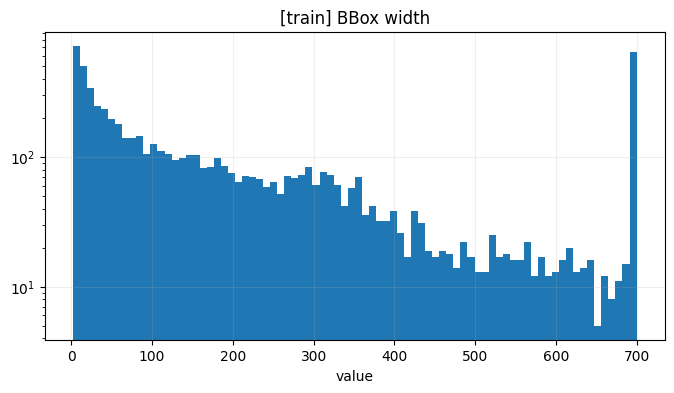

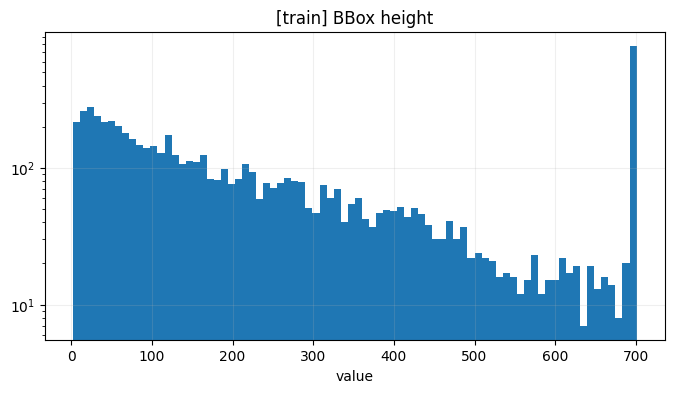

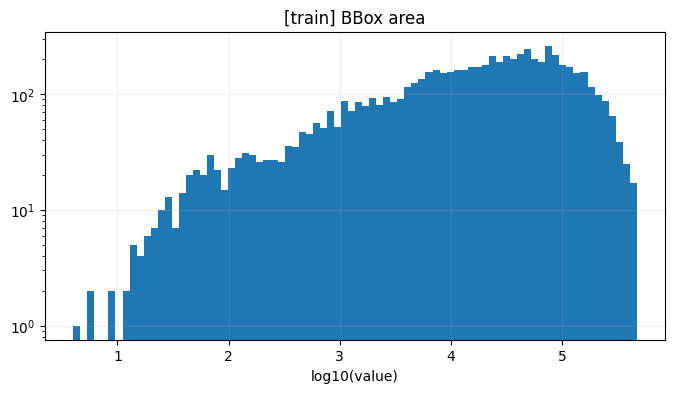

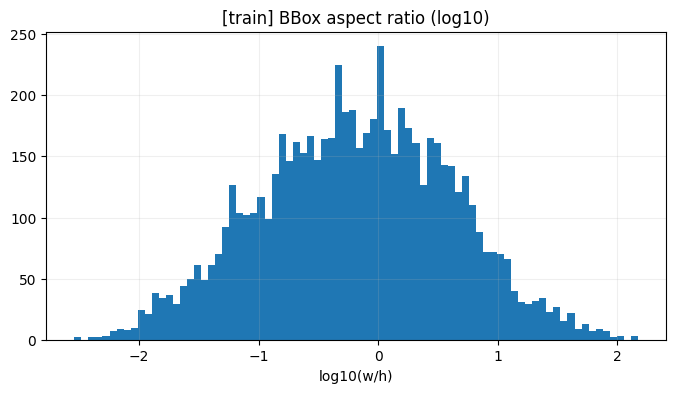


=== PLOTS: valid ===


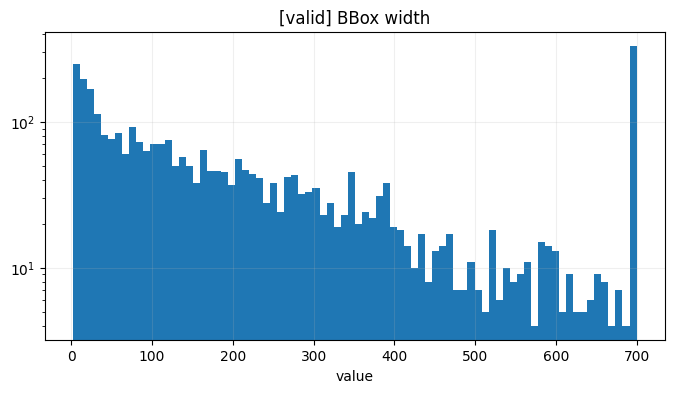

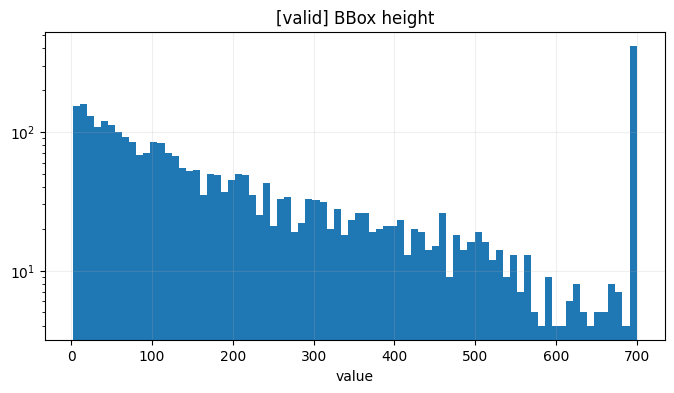

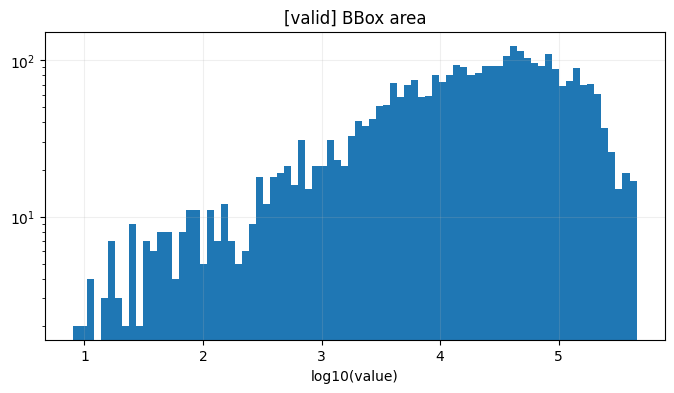

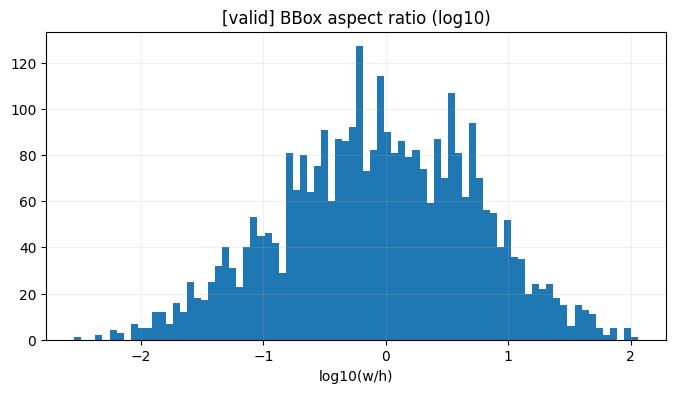


=== PLOTS: test ===


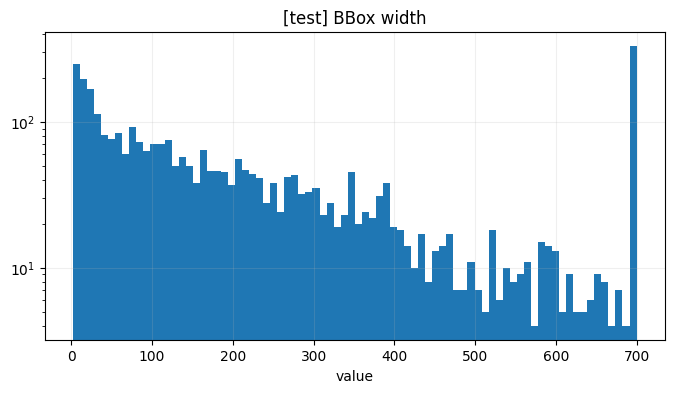

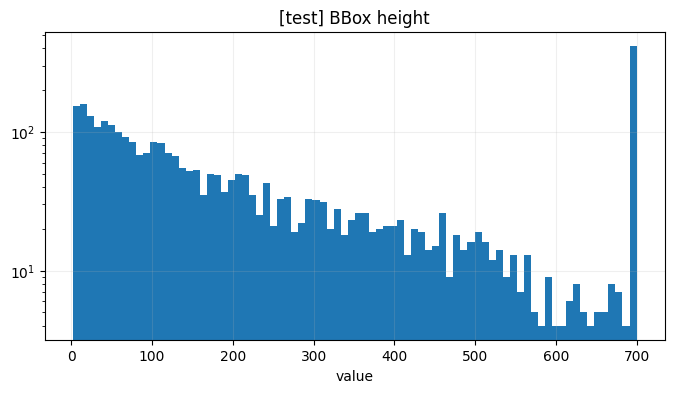

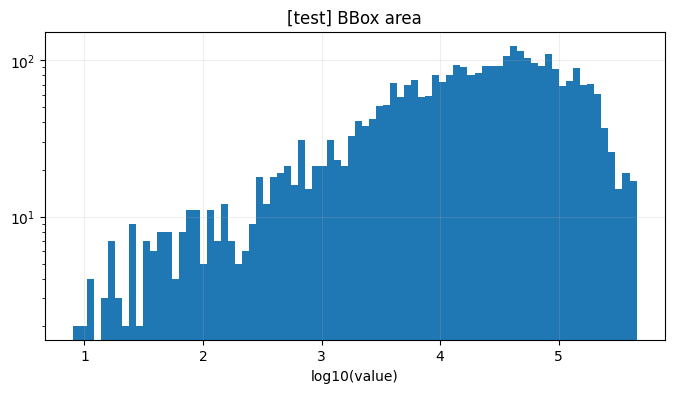

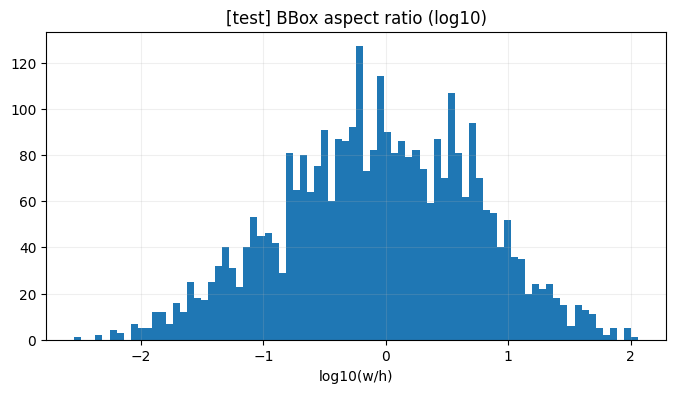

,split,bucket,count,pct
6,test,large,2192,66.203564
7,test,medium,774,23.376623
8,test,small,345,10.419813
0,train,large,4253,63.620045
1,train,medium,1623,24.278235
2,train,small,809,12.101720
3,valid,large,2192,66.203564
4,valid,medium,774,23.376623
5,valid,small,345,10.419813


In [ ]:
# ============================================================
# CELLA 2 — BBOX EXPLORATION
# - distribuzioni: w/h/area/aspect ratio
# - out-of-bounds, bbox troppo piccole, bbox “degenerate”
# - per split: tabella + plot (matplotlib)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

def get_img_wh_map(coco):
    return {im["id"]:(im["width"], im["height"]) for im in coco.dataset.get("images", [])}

def bbox_stats_for_split(coco, split_name: str):
    anns = coco.dataset.get("annotations", [])
    img_wh = get_img_wh_map(coco)

    rows = []
    invalid_wh = 0
    oob = 0
    too_small = 0

    for a in anns:
        bbox = a.get("bbox", None)
        if not bbox or len(bbox) != 4:
            continue
        x, y, w, h = bbox
        if w <= 0 or h <= 0:
            invalid_wh += 1
            continue

        img_id = a["image_id"]
        W, H = img_wh.get(img_id, (None, None))
        if W is None:
            continue

        # out of bounds check (bbox COCO: x,y,w,h)
        x2, y2 = x + w, y + h
        if (x < 0) or (y < 0) or (x2 > W) or (y2 > H):
            oob += 1

        if (w < 2) or (h < 2):
            too_small += 1

        area = w * h
        ar = (w / h) if h > 0 else np.nan

        rows.append({
            "split": split_name,
            "image_id": img_id,
            "ann_id": a.get("id", None),
            "w": w, "h": h,
            "area": area,
            "aspect_ratio": ar,
            "x": x, "y": y, "x2": x2, "y2": y2,
            "img_w": W, "img_h": H
        })

    df = pd.DataFrame(rows)
    summary = {
        "split": split_name,
        "n_boxes": int(len(df)),
        "invalid_wh": int(invalid_wh),
        "oob": int(oob),
        "too_small(<2px)": int(too_small),
        "w_mean": float(df["w"].mean()) if len(df) else 0.0,
        "h_mean": float(df["h"].mean()) if len(df) else 0.0,
        "area_mean": float(df["area"].mean()) if len(df) else 0.0,
        "area_median": float(df["area"].median()) if len(df) else 0.0,
        "ar_median": float(df["aspect_ratio"].median()) if len(df) else 0.0,
    }
    return df, summary

# ---- collect all splits
bbox_dfs = {}
bbox_summaries = []
for name, coco in cocos.items():
    dfb, summ = bbox_stats_for_split(coco, name)
    bbox_dfs[name] = dfb
    bbox_summaries.append(summ)

display(pd.DataFrame(bbox_summaries))

# ---- plots (per split)
def hist_plot(series, title, bins=60, logx=False, logy=False):
    s = series.dropna().values
    if len(s) == 0:
        print("⚠️ No data for:", title)
        return
    plt.figure(figsize=(8, 4))
    if logx:
        s = s[s > 0]
        plt.hist(np.log10(s), bins=bins)
        plt.xlabel("log10(value)")
    else:
        plt.hist(s, bins=bins)
        plt.xlabel("value")
    if logy:
        plt.yscale("log")
    plt.title(title)
    plt.grid(True, alpha=0.2)
    plt.show()

for name, dfb in bbox_dfs.items():
    print(f"\n=== PLOTS: {name} ===")
    hist_plot(dfb["w"], f"[{name}] BBox width", bins=80, logy=True)
    hist_plot(dfb["h"], f"[{name}] BBox height", bins=80, logy=True)
    hist_plot(dfb["area"], f"[{name}] BBox area", bins=80, logx=True, logy=True)
    # aspect ratio spesso heavy-tailed: log10(ar) con clamp
    ar = dfb["aspect_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
    ar = ar[(ar > 0) & (ar < 1e3)]
    plt.figure(figsize=(8, 4))
    plt.hist(np.log10(ar), bins=80)
    plt.xlabel("log10(w/h)")
    plt.title(f"[{name}] BBox aspect ratio (log10)")
    plt.grid(True, alpha=0.2)
    plt.show()

# ---- COCO size buckets based on bbox area (proxy; utile in relazione)
# COCO convention: small < 32^2, medium < 96^2, large >= 96^2
def coco_size_bucket_bbox(area):
    if area < 32**2:
        return "small"
    elif area < 96**2:
        return "medium"
    else:
        return "large"

size_tables = []
for name, dfb in bbox_dfs.items():
    if len(dfb) == 0:
        continue
    buckets = dfb["area"].apply(coco_size_bucket_bbox).value_counts()
    tot = buckets.sum()
    for k, v in buckets.items():
        size_tables.append({"split": name, "bucket": k, "count": int(v), "pct": float(v/tot*100)})

display(pd.DataFrame(size_tables).sort_values(["split","bucket"]))


[test] masks: 100%|██████████| 3311/3311 [00:11<00:00, 292.39it/s]


,split,n_anns,n_rows,decode_fail,empty_mask
0,train,6685,6685,0,0
1,valid,3311,3311,0,0
2,test,3311,3311,0,0



=== QUANTILES (min,25,50,75,90,95,99,max) ===

[train] n=6685
  mask_area    -> [2.00000e+00 2.37000e+02 6.08000e+02 1.72100e+03 3.41700e+03 4.76500e+03
 8.32216e+03 4.84090e+04]
  bbox_area    -> [4.0000000e+00 4.2500000e+03 2.0740000e+04 6.6893000e+04 1.3842720e+05
 1.9572000e+05 3.1995904e+05 4.7263600e+05]
  fill_ratio   -> [0.001573 0.016844 0.037235 0.097043 0.233238 0.370524 0.687562 1.5     ]
  bbox_mask_iou -> [0.       0.953026 0.984127 0.994144 0.998571 1.       1.       1.      ]
  perimeter    -> [   0.        299.320849  684.409161 1324.604243 1514.528824 1591.753936
 1752.932391 1965.389287]
  n_components -> [  1.   1.   1.   1.  12.  32.  93. 243.]
  thinness     -> [2.7500e-04 1.0550e-03 1.7510e-03 3.4350e-03 8.9500e-03 1.5078e-02
 4.8442e-02 1.0000e+00]

[valid] n=3311
  mask_area    -> [1.0000e+00 2.4200e+02 5.7200e+02 1.6740e+03 3.2340e+03 4.4075e+03
 7.0109e+03 2.3834e+04]
  bbox_area    -> [8.000000e+00 5.202500e+03 2.257800e+04 6.780300e+04 1.481880e+05
 2.0557

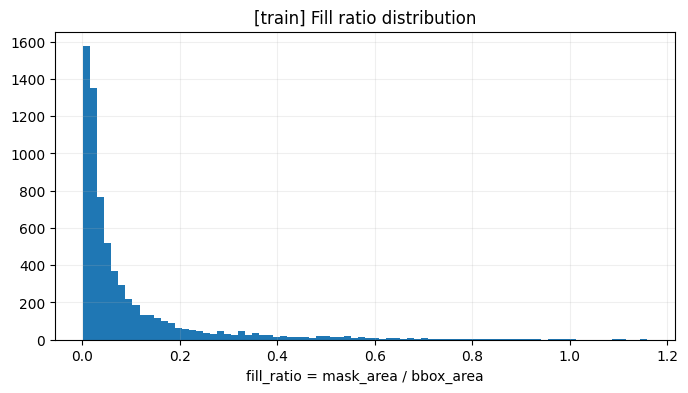

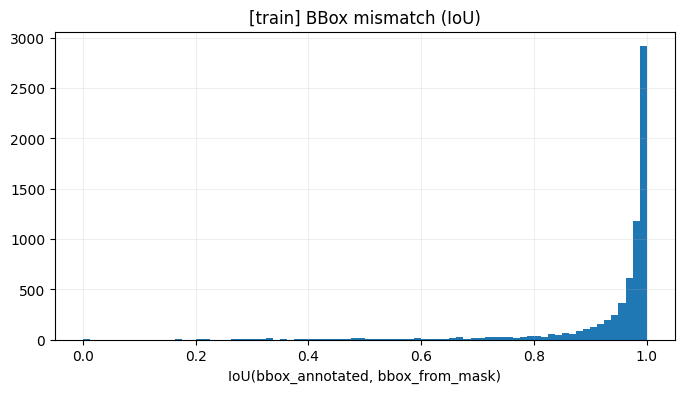

,image_id,ann_id,category_id,bbox_area,mask_area,fill_ratio,bbox_mask_iou,n_components,thinness
6490,824,7210,0,24.0,3.0,0.125000,0.000000,1,0.187500
6494,824,7215,0,20.0,4.0,0.200000,0.000000,1,0.111111
1609,186,1776,0,54.0,9.0,0.166667,0.166667,1,0.035156
4647,574,5195,0,24.0,8.0,0.333333,0.000000,1,0.040816
1615,186,1782,0,45.0,10.0,0.222222,0.222222,1,0.030864
4067,503,4539,0,32.0,15.0,0.468750,0.000000,1,0.019133
6559,828,7283,0,42.0,4.0,0.095238,0.380952,1,0.055556
4164,515,4663,0,52.0,12.0,0.230769,0.287671,2,0.030000
1471,173,1626,0,6.0,2.0,0.333333,0.200000,2,NaN
6552,828,7276,0,441.0,15.0,0.034014,0.510204,1,0.009566


[train] % bbox_mask_iou < 0.50: 1.39%
[train] % fill_ratio    < 0.10: 75.57%

=== PLOTS/OUTLIERS: valid ===


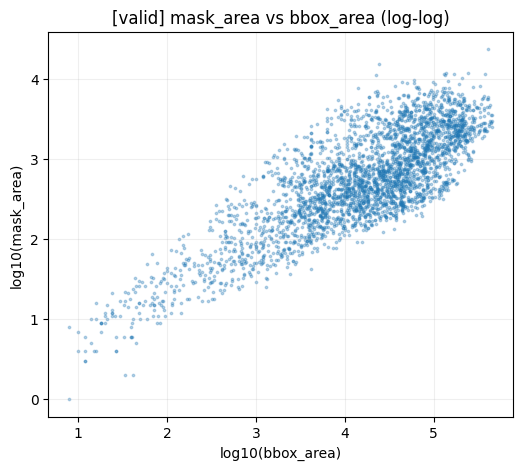

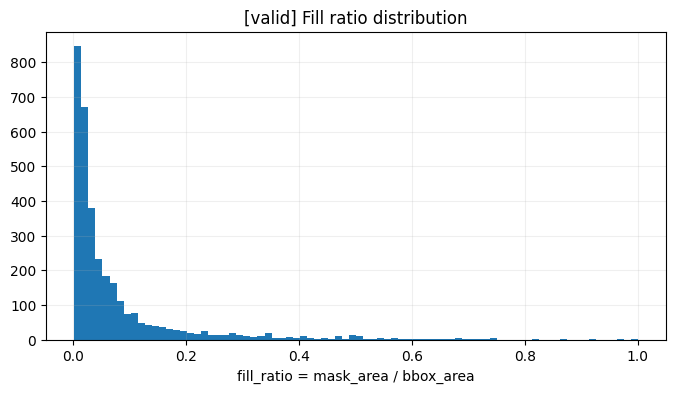

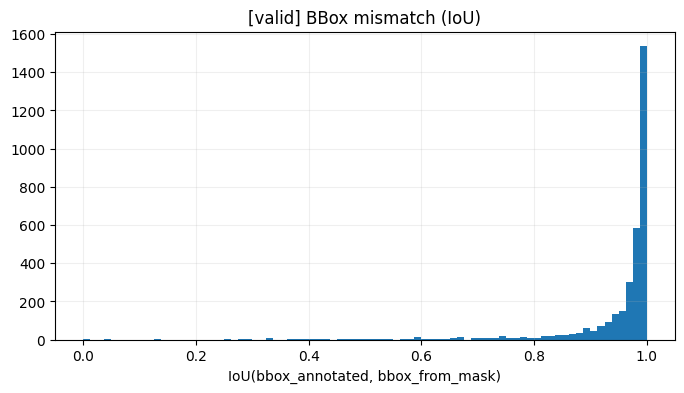

,image_id,ann_id,category_id,bbox_area,mask_area,fill_ratio,bbox_mask_iou,n_components,thinness
2071,229,2289,0,34.0,2.0,0.058824,0.000000,1,0.500000
2074,229,2292,0,42.0,2.0,0.047619,0.047619,1,0.500000
3169,381,3494,0,8.0,1.0,0.125000,0.125000,1,NaN
2026,228,2239,0,16.0,4.0,0.250000,0.250000,1,0.111111
381,38,417,0,12.0,3.0,0.250000,0.250000,1,0.187500
2020,228,2233,0,110.0,12.0,0.109091,0.463636,3,0.037037
382,38,418,0,48.0,16.0,0.333333,0.250000,1,0.016835
2023,228,2236,0,39.0,6.0,0.153846,0.461538,2,0.093750
2033,228,2247,0,39.0,6.0,0.153846,0.461538,2,0.093750
2072,229,2290,0,56.0,17.0,0.303571,0.325581,2,0.018889


[valid] % bbox_mask_iou < 0.50: 1.06%
[valid] % fill_ratio    < 0.10: 80.07%

=== PLOTS/OUTLIERS: test ===


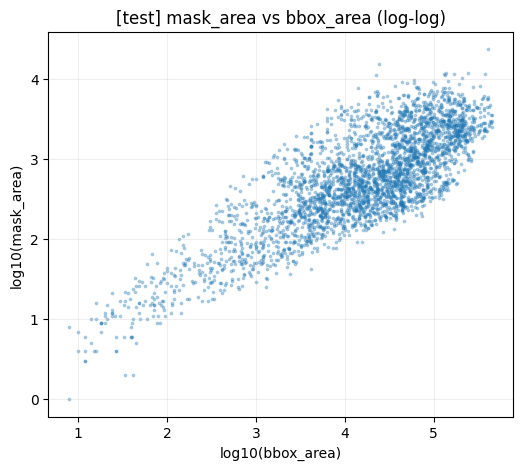

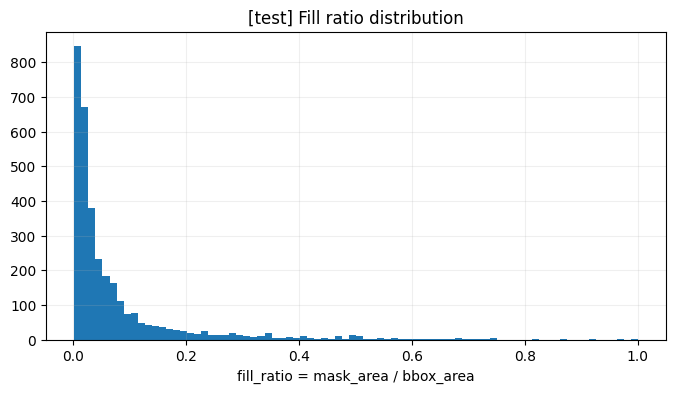

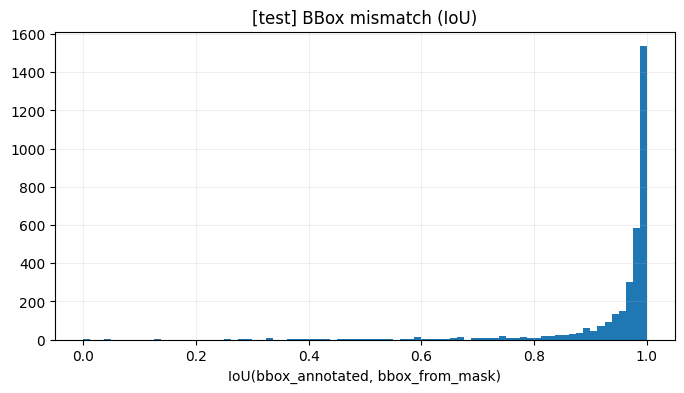

,image_id,ann_id,category_id,bbox_area,mask_area,fill_ratio,bbox_mask_iou,n_components,thinness
2071,229,2289,0,34.0,2.0,0.058824,0.000000,1,0.500000
2074,229,2292,0,42.0,2.0,0.047619,0.047619,1,0.500000
3169,381,3494,0,8.0,1.0,0.125000,0.125000,1,NaN
2026,228,2239,0,16.0,4.0,0.250000,0.250000,1,0.111111
381,38,417,0,12.0,3.0,0.250000,0.250000,1,0.187500
2020,228,2233,0,110.0,12.0,0.109091,0.463636,3,0.037037
382,38,418,0,48.0,16.0,0.333333,0.250000,1,0.016835
2023,228,2236,0,39.0,6.0,0.153846,0.461538,2,0.093750
2033,228,2247,0,39.0,6.0,0.153846,0.461538,2,0.093750
2072,229,2290,0,56.0,17.0,0.303571,0.325581,2,0.018889


[test] % bbox_mask_iou < 0.50: 1.06%
[test] % fill_ratio    < 0.10: 80.07%


In [ ]:
# ============================================================
# CELLA 3 — MASK vs BBOX (segmentation quality proxies)
# - decode robusto (polygons / RLE)
# - mask area, perimeter, fill ratio (mask_area / bbox_area)
# - bbox derivata da mask vs bbox annotata: IoU e mismatch
# - outliers (casi strani) + plot scatter/hist
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pycocotools import mask as coco_mask

def ann_to_rle(coco, ann):
    """
    Ritorna RLE compatibile pycocotools per un'annotazione COCO.
    Supporta:
    - polygon list
    - uncompressed RLE
    - RLE già compresso
    """
    seg = ann.get("segmentation", None)
    img_info = coco.imgs[ann["image_id"]]
    H, W = img_info["height"], img_info["width"]

    if seg is None:
        return None

    # polygon: list of lists
    if isinstance(seg, list):
        rles = coco_mask.frPyObjects(seg, H, W)
        rle = coco_mask.merge(rles)
        return rle

    # RLE: dict
    if isinstance(seg, dict):
        # uncompressed: counts as list
        if isinstance(seg.get("counts", None), list):
            rle = coco_mask.frPyObjects(seg, H, W)
            return rle
        # compressed already
        return seg

    return None

def bbox_xywh_to_xyxy(b):
    x,y,w,h = b
    return (x, y, x+w, y+h)

def bbox_from_mask(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    # convert to xywh
    return (float(x1), float(y1), float(x2-x1+1), float(y2-y1+1))

def bbox_iou_xywh(b1, b2):
    # both xywh
    x1,y1,w1,h1 = b1
    x2,y2,w2,h2 = b2
    ax1, ay1, ax2, ay2 = x1, y1, x1+w1, y1+h1
    bx1, by1, bx2, by2 = x2, y2, x2+w2, y2+h2
    ix1, iy1 = max(ax1,bx1), max(ay1,by1)
    ix2, iy2 = min(ax2,bx2), min(ay2,by2)
    iw, ih = max(0.0, ix2-ix1), max(0.0, iy2-iy1)
    inter = iw*ih
    area_a = max(0.0, w1*h1)
    area_b = max(0.0, w2*h2)
    union = area_a + area_b - inter
    return inter/union if union > 0 else np.nan

def mask_perimeter(mask_u8):
    # perimeter via contours (approx). mask_u8: 0/1
    mask_u8 = (mask_u8.astype(np.uint8) * 255)
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    per = 0.0
    for c in contours:
        per += cv2.arcLength(c, closed=True)
    return float(per), int(len(contours))

def analyze_masks_vs_bbox(coco, split_name: str, sample_limit=None):
    anns = coco.dataset.get("annotations", [])
    if sample_limit is not None:
        anns = anns[:sample_limit]

    rows = []
    decode_fail = 0
    empty_mask = 0

    for ann in tqdm(anns, desc=f"[{split_name}] masks"):
        bbox = ann.get("bbox", None)
        if bbox is None or len(bbox) != 4:
            continue

        rle = ann_to_rle(coco, ann)
        if rle is None:
            decode_fail += 1
            continue

        try:
            m = coco_mask.decode(rle)
            # decode può tornare HxW o HxWxN; normalizziamo
            if m.ndim == 3:
                m = m[..., 0]
            m = (m > 0).astype(np.uint8)
        except Exception:
            decode_fail += 1
            continue

        mask_area = float(m.sum())
        if mask_area <= 0:
            empty_mask += 1
            continue

        bbox_area = float(bbox[2] * bbox[3]) if bbox[2] > 0 and bbox[3] > 0 else np.nan
        fill_ratio = (mask_area / bbox_area) if (bbox_area and bbox_area > 0) else np.nan

        # bbox derivata dalla mask
        bbox_m = bbox_from_mask(m)
        iou_bb = bbox_iou_xywh(bbox, bbox_m) if bbox_m is not None else np.nan

        # perimeter + num components (proxy di frammentazione)
        per, n_comp = mask_perimeter(m)

        # "thinness" proxy: area/perimeter^2 (più piccolo => più sottile/filiforme o frastagliato)
        thinness = mask_area / (per*per) if per > 0 else np.nan

        rows.append({
            "split": split_name,
            "image_id": ann["image_id"],
            "ann_id": ann.get("id", None),
            "category_id": ann.get("category_id", None),
            "bbox_area": bbox_area,
            "mask_area": mask_area,
            "fill_ratio": fill_ratio,
            "bbox_mask_iou": iou_bb,
            "perimeter": per,
            "n_components": n_comp,
            "thinness": thinness,
            "bbox_w": float(bbox[2]),
            "bbox_h": float(bbox[3]),
        })

    dfm = pd.DataFrame(rows)
    meta = {
        "split": split_name,
        "n_anns": len(anns),
        "n_rows": len(dfm),
        "decode_fail": int(decode_fail),
        "empty_mask": int(empty_mask),
    }
    return dfm, meta

# --- run analysis (metti un sample_limit tipo 20000 se è enorme)
mask_dfs = {}
mask_meta = []
for name, coco in cocos.items():
    dfm, meta = analyze_masks_vs_bbox(coco, name, sample_limit=None)
    mask_dfs[name] = dfm
    mask_meta.append(meta)

display(pd.DataFrame(mask_meta))

# --- numeric summary per split
def quant_summary(df, cols):
    out = {}
    for c in cols:
        s = df[c].replace([np.inf, -np.inf], np.nan).dropna()
        if len(s) == 0:
            continue
        qs = np.quantile(s, [0, .25, .5, .75, .9, .95, .99, 1.0])
        out[c] = np.round(qs, 6)
    return out

cols = ["mask_area", "bbox_area", "fill_ratio", "bbox_mask_iou", "perimeter", "n_components", "thinness"]
print("\n=== QUANTILES (min,25,50,75,90,95,99,max) ===")
for name, dfm in mask_dfs.items():
    print(f"\n[{name}] n={len(dfm)}")
    q = quant_summary(dfm, cols)
    for k, v in q.items():
        print(f"  {k:<12} -> {v}")

# --- plots + outliers
for name, dfm in mask_dfs.items():
    if len(dfm) == 0:
        continue

    print(f"\n=== PLOTS/OUTLIERS: {name} ===")

    # scatter: bbox_area vs mask_area (log-log)
    x = dfm["bbox_area"].clip(lower=1)
    y = dfm["mask_area"].clip(lower=1)

    plt.figure(figsize=(6, 5))
    plt.scatter(np.log10(x), np.log10(y), s=3, alpha=0.3)
    plt.xlabel("log10(bbox_area)")
    plt.ylabel("log10(mask_area)")
    plt.title(f"[{name}] mask_area vs bbox_area (log-log)")
    plt.grid(True, alpha=0.2)
    plt.show()

    # fill ratio histogram (clamp)
    fr = dfm["fill_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
    fr = fr[(fr >= 0) & (fr <= 1.2)]  # sopra 1 può capitare per bbox rumorose; clamp per grafico
    plt.figure(figsize=(8, 4))
    plt.hist(fr, bins=80)
    plt.xlabel("fill_ratio = mask_area / bbox_area")
    plt.title(f"[{name}] Fill ratio distribution")
    plt.grid(True, alpha=0.2)
    plt.show()

    # bbox-mismatch IoU histogram
    iou = dfm["bbox_mask_iou"].replace([np.inf, -np.inf], np.nan).dropna()
    plt.figure(figsize=(8, 4))
    plt.hist(iou, bins=80)
    plt.xlabel("IoU(bbox_annotated, bbox_from_mask)")
    plt.title(f"[{name}] BBox mismatch (IoU)")
    plt.grid(True, alpha=0.2)
    plt.show()

    # outliers: fill ratio bassissimo + IoU bassissima
    out = dfm.copy()
    out["score_weird"] = (1 - out["bbox_mask_iou"].fillna(0)) + (1 - out["fill_ratio"].clip(0, 1).fillna(0))
    out = out.sort_values("score_weird", ascending=False).head(15)

    display(out[["image_id","ann_id","category_id","bbox_area","mask_area","fill_ratio","bbox_mask_iou","n_components","thinness"]])

    # percentuali utili per relazione
    p_iou_lt_05 = float((dfm["bbox_mask_iou"] < 0.5).mean() * 100)
    p_fill_lt_01 = float((dfm["fill_ratio"] < 0.1).mean() * 100)
    print(f"[{name}] % bbox_mask_iou < 0.50: {p_iou_lt_05:.2f}%")
    print(f"[{name}] % fill_ratio    < 0.10: {p_fill_lt_01:.2f}%")


In [ ]:
# ============================================================
# 📦 ZIP DATASET -> GOOGLE DRIVE (COLAB SAFE)
# ============================================================

import os
import zipfile
from pathlib import Path

# -------------------------
# CONFIG
# -------------------------
SRC_DIR = Path("/content/dataset_finale_aug")
ZIP_PATH = Path("/content/drive/MyDrive/dataset_finale_aug.zip")

# -------------------------
# CHECK DATASET
# -------------------------
if not SRC_DIR.exists():
    raise FileNotFoundError(f"❌ Dataset non trovato: {SRC_DIR}")

print(f"✅ Dataset trovato: {SRC_DIR}")

# -------------------------
# MOUNT DRIVE (se serve)
# -------------------------
if not Path("/content/drive").exists():
    print("🔧 Mounting Google Drive...")
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("✅ Google Drive già montato")

# -------------------------
# ZIP
# -------------------------
print("📦 Creazione zip in corso...")

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(SRC_DIR):
        for file in files:
            full_path = Path(root) / file
            rel_path = full_path.relative_to(SRC_DIR)
            zf.write(full_path, rel_path)

print("✅ ZIP completato")
print(f"📍 Salvato in: {ZIP_PATH}")
print(f"📏 Dimensione zip: {ZIP_PATH.stat().st_size / 1e6:.2f} MB")


✅ Dataset trovato: /content/dataset_finale_aug
✅ Google Drive già montato
📦 Creazione zip in corso...
✅ ZIP completato
📍 Salvato in: /content/drive/MyDrive/dataset_finale_aug.zip
📏 Dimensione zip: 578.72 MB


In [ ]:
def calculate_polar_coordinates(mask_array: np.ndarray) -> tuple[float, float, bool]:
    points_yx = np.argwhere(mask_array > 0.5)
    points = points_yx[:, [1, 0]].astype(np.float32)

    if points.shape[0] < 20:
        return 0.0, 0.0, False

    [vx, vy, x0, y0] = cv2.fitLine(points,
                                   distType=cv2.DIST_L2,
                                   param=0,
                                   reps=0.01,
                                   aeps=0.01)
    vx, vy, x0, y0 = vx[0], vy[0], x0[0], y0[0]

    theta_normal_rad = math.atan2(vy, vx) + math.pi / 2
    theta_final = theta_normal_rad % (2 * math.pi)

    rho = x0 * math.cos(theta_final) + y0 * math.sin(theta_final)

    if rho < 0:
        rho = -rho
        theta_final = (theta_final + math.pi) % (2 * math.pi)

    return float(rho), float(theta_final), True

In [ ]:
# ============================================================
# 🔎 COCO STRUCTURE + SPLIT CONSISTENCY CHECK
# - struttura JSON
# - # immagini / # annotation
# - immagini senza GT
# - overlap immagini tra split
# ============================================================

from pathlib import Path
from pycocotools.coco import COCO
from collections import defaultdict

BASE = Path("/content/dataset_finale_aug")

SPLITS = {
    "train": BASE / "train/_annotations.coco.json",
    "valid": BASE / "valid/_annotations.coco.json",
    "test":  BASE / "test/_annotations.coco.json",
}

def analyze_split(name, path):
    coco = COCO(str(path))

    imgs = coco.dataset.get("images", [])
    anns = coco.dataset.get("annotations", [])
    cats = coco.dataset.get("categories", [])

    img_ids = set(coco.imgs.keys())
    ann_img_ids = {ann["image_id"] for ann in anns}

    imgs_no_ann = img_ids - ann_img_ids

    print(f"\n================ {name.upper()} SUMMARY ================\n")
    print(f"Images           : {len(imgs)}")
    print(f"Annotations      : {len(anns)}")
    print(f"Categories       : {len(cats)}")
    print(f"GT / image (avg) : {len(anns) / max(len(imgs),1):.2f}")
    print(f"Images w/o GT    : {len(imgs_no_ann)}")

    return {
        "img_ids": img_ids,
        "img_names": {img["file_name"] for img in imgs},
        "imgs_no_ann": imgs_no_ann,
    }

stats = {}
for split, path in SPLITS.items():
    stats[split] = analyze_split(split, path)

# ------------------------------------------------------------
# OVERLAP CHECK
# ------------------------------------------------------------
print("\n================ IMAGE OVERLAP CHECK ================\n")

def overlap(a, b, name_a, name_b):
    inter = a & b
    print(f"{name_a} ∩ {name_b} : {len(inter)} images")
    return inter

overlap(stats["train"]["img_names"], stats["valid"]["img_names"], "train", "valid")
overlap(stats["train"]["img_names"], stats["test"]["img_names"],  "train", "test")
overlap(stats["valid"]["img_names"], stats["test"]["img_names"],  "valid", "test")

# ------------------------------------------------------------
# HARD ASSERTIONS (commenta se vuoi solo ispezione)
# ------------------------------------------------------------


print("\n✅ Split disgiunti correttamente")


loading annotations into memory...
Done (t=0.14s)
creating index...
index created!

================ TRAIN SUMMARY ================

Images           : 2097
Annotations      : 16812
Categories       : 2
GT / image (avg) : 8.02
Images w/o GT    : 15
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!

================ VALID SUMMARY ================

Images           : 396
Annotations      : 3311
Categories       : 1
GT / image (avg) : 8.36
Images w/o GT    : 0
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!

================ TEST SUMMARY ================

Images           : 396
Annotations      : 3311
Categories       : 1
GT / image (avg) : 8.36
Images w/o GT    : 0

================ IMAGE OVERLAP CHECK ================

train ∩ valid : 0 images
train ∩ test : 0 images
valid ∩ test : 396 images

✅ Split disgiunti correttamente


## 04 · Baseline RF-DETR training

Runtime settings and baseline training experiments. Requires a GPU and dataset paths configured.

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [ ]:
from rfdetr import RFDETRSegPreview

model = RFDETRSegPreview()

model.train(
    dataset_dir="/content/dataset_finale_aug",
    dataset_file="roboflow",

    resolution=1200,
    mask_downsample_ratio=1,
    mask_point_sample_ratio=2048,

    num_select=130,

    multi_scale=False,
    expanded_scales=False,
    do_random_resize_via_padding=False,
    square_resize_div_64=True,

    epochs=30,
    batch_size=1,
    grad_accum_steps=4,
    warmup_epochs=3,

    freeze_encoder=False,
    lr_scheduler="step",
    lr_drop=24,

    # --- Matching/Loss più pro-geometry (utile con 1 classe) ---




    amp=True,
    use_ema=True,
)


In [ ]:
# ================================
# ZIP /content/output → Google Drive
# ================================

from google.colab import drive
import os
import shutil

# 1) Mount Drive (se non già montato)
drive.mount('/content/drive')

# 2) Path
SRC_DIR = "/content/output"
DST_ZIP = "/content/drive/MyDrive/30.zip"

# 3) Safety check
assert os.path.isdir(SRC_DIR), f"Directory non trovata: {SRC_DIR}"

# 4) Zip (deflated = compressione reale)
shutil.make_archive(
    base_name=DST_ZIP.replace(".zip", ""),
    format="zip",
    root_dir=SRC_DIR
)

print(f"✅ ZIP creato correttamente: {DST_ZIP}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ZIP creato correttamente: /content/drive/MyDrive/30.zip


## 05 · PCA and dataset filtering

PCA line reconstruction and optional dataset-subsetting experiments.

In [ ]:
# ------------------------------------------------------------
# PCA LINE RECONSTRUCTION (SAFE, NO FILTERS)
# ------------------------------------------------------------
def pca_line_reconstruct(mask_u8):
    """
    Ricostruisce una maschera come segmento spesso lungo PCA.
    SEMPRE safe: se qualcosa va storto, ritorna la maschera originale.
    """
    H, W = mask_u8.shape
    ys, xs = np.where(mask_u8 > 0)
    n = len(xs)

    if n < 5:
        return mask_u8.copy()

    pts = np.stack([xs, ys], axis=1).astype(np.float32)

    # PCA
    mu = pts.mean(axis=0, keepdims=True)
    X = pts - mu
    C = (X.T @ X) / max(1, n - 1)

    try:
        eigvals, eigvecs = np.linalg.eigh(C)
        v = eigvecs[:, np.argmax(eigvals)]
        v = v / (np.linalg.norm(v) + 1e-8)
    except Exception:
        return mask_u8.copy()

    # proiezioni
    t = X @ v
    tmin, tmax = t.min(), t.max()

    p1 = (mu[0] + tmin * v)
    p2 = (mu[0] + tmax * v)

    # stima spessore (robusta)
    dx = X[:, 0]
    dy = X[:, 1]
    perp = np.abs(dx * v[1] - dy * v[0])
    thick = int(np.clip(np.median(perp) * 2.0, 1, 20))

    # disegno linea
    recon = np.zeros((H, W), dtype=np.uint8)
    cv2.line(
        recon,
        (int(round(p1[0])), int(round(p1[1]))),
        (int(round(p2[0])), int(round(p2[1]))),
        color=1,
        thickness=thick,
        lineType=cv2.LINE_AA
    )

    # unione con originale (REGOLA D’ORO)
    recon = np.clip(recon + mask_u8, 0, 1).astype(np.uint8)
    return recon


In [ ]:
# ============================================================
# 🧵 SAFE GT PCA RECONSTRUCTION → COCO (NO DROP VERSION)
# ============================================================

import os, json, math
import numpy as np
import cv2
from tqdm import tqdm

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

COCO_JSON = "/content/dataset_finale7/train/_annotations.coco.json"

# ------------------------------------------------------------
# PARAMETRI (MINIMALI)
# ------------------------------------------------------------
DP_EPS_FRAC = 0.002   # leggero smoothing, NON aggressivo

# ------------------------------------------------------------
# MASK → POLYGON (SAFE)
# ------------------------------------------------------------
def mask_to_polygons_safe(mask):
    h, w = mask.shape
    diag = math.hypot(h, w)
    eps = DP_EPS_FRAC * diag

    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    polys = []
    for cnt in contours:
        if cnt.shape[0] < 4:
            continue
        cnt = cv2.approxPolyDP(cnt, eps, True)
        if cnt.shape[0] < 4:
            continue
        poly = cnt.reshape(-1, 2).astype(float).flatten().tolist()
        polys.append(poly)

    return polys

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
coco = COCO(COCO_JSON)
with open(COCO_JSON, "r") as f:
    coco_json = json.load(f)

print("🔧 PCA reconstruction (SAFE) in corso...")

for ann in tqdm(coco_json["annotations"]):
    img = coco.loadImgs(ann["image_id"])[0]
    H, W = img["height"], img["width"]

    # decode originale
    mask_orig = decode_coco_seg(ann["segmentation"], H, W)
    if mask_orig.sum() == 0:
        continue

    # PCA reconstruction (la TUA logica)
    mask_rep = pca_line_reconstruct(mask_orig)

    # fallback garantito
    if mask_rep.sum() == 0:
        mask_rep = mask_orig

    polys = mask_to_polygons_safe(mask_rep)

    # fallback finale
    if len(polys) == 0:
        polys = ann["segmentation"]

    ann["segmentation"] = polys
    ann["iscrowd"] = 0

    rle = coco_mask.frPyObjects(polys, H, W)
    m = coco_mask.decode(rle)
    if m.ndim == 3:
        m = np.any(m, axis=2)

    ys, xs = np.where(m)
    if len(xs) > 0:
        ann["area"] = int(m.sum())
        ann["bbox"] = [
            int(xs.min()),
            int(ys.min()),
            int(xs.max() - xs.min() + 1),
            int(ys.max() - ys.min() + 1)
        ]
    else:
        ann["area"] = ann["area"]
        ann["bbox"] = ann["bbox"]

# ------------------------------------------------------------
# SAVE (SAFE OVERWRITE)
# ------------------------------------------------------------
with open(COCO_JSON, "w") as f:
    json.dump(coco_json, f)

print("✅ PCA reconstruction completata — NESSUNA annotazione rimossa")


loading annotations into memory...
Done (t=0.10s)
creating index...
index created!
🔧 PCA reconstruction (SAFE) in corso...


100%|██████████| 6685/6685 [00:36<00:00, 185.47it/s]


✅ PCA reconstruction completata — NESSUNA annotazione rimossa


In [ ]:
# ============================================================
# 🧵 FILTER TRAIN SET — IMMAGINI CON > 6 CAVI
# ============================================================

import os, json, shutil
from tqdm import tqdm
from collections import defaultdict

from pycocotools.coco import COCO

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
SRC_ROOT = "/content/dataset_finale7/train"      # dataset PCA
SRC_JSON = os.path.join(SRC_ROOT, "_annotations.coco.json")

DST_ROOT = "/content/dataset_finale7_train_gt6/train"
DST_JSON = os.path.join(DST_ROOT, "_annotations.coco.json")

MIN_CABLES = 6   # condizione: > 6 cavi

os.makedirs(DST_ROOT, exist_ok=True)

# ------------------------------------------------------------
# LOAD COCO
# ------------------------------------------------------------
coco = COCO(SRC_JSON)

with open(SRC_JSON, "r") as f:
    coco_json = json.load(f)

# ------------------------------------------------------------
# CONTA ISTANZE PER IMMAGINE
# ------------------------------------------------------------
img_to_anns = defaultdict(list)
for ann in coco_json["annotations"]:
    img_to_anns[ann["image_id"]].append(ann)

valid_img_ids = [
    img_id for img_id, anns in img_to_anns.items()
    if len(anns) > MIN_CABLES
]

valid_img_ids = set(valid_img_ids)

print(f"✅ Immagini tenute (>{MIN_CABLES} cavi): {len(valid_img_ids)}")
print(f"❌ Immagini scartate             : {len(coco_json['images']) - len(valid_img_ids)}")

# ------------------------------------------------------------
# FILTRA IMAGES
# ------------------------------------------------------------
new_images = []
old_to_new_img_id = {}

for img in coco_json["images"]:
    if img["id"] in valid_img_ids:
        new_id = len(new_images)
        old_to_new_img_id[img["id"]] = new_id

        img_new = img.copy()
        img_new["id"] = new_id
        new_images.append(img_new)

# ------------------------------------------------------------
# FILTRA ANNOTATIONS
# ------------------------------------------------------------
new_annotations = []
ann_id = 0

for ann in coco_json["annotations"]:
    if ann["image_id"] in valid_img_ids:
        ann_new = ann.copy()
        ann_new["id"] = ann_id
        ann_new["image_id"] = old_to_new_img_id[ann["image_id"]]
        new_annotations.append(ann_new)
        ann_id += 1

# ------------------------------------------------------------
# COPY IMAGES
# ------------------------------------------------------------
print("📦 Copia immagini...")

for img in tqdm(new_images):
    src = os.path.join(SRC_ROOT, img["file_name"])
    dst = os.path.join(DST_ROOT, img["file_name"])
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(src, dst)

# ------------------------------------------------------------
# SAVE NEW JSON
# ------------------------------------------------------------
new_coco = {
    "images": new_images,
    "annotations": new_annotations,
    "categories": coco_json["categories"]
}

with open(DST_JSON, "w") as f:
    json.dump(new_coco, f)

print("🎉 Dataset filtrato creato con successo!")
print(f"   • immagini finali   : {len(new_images)}")
print(f"   • annotazioni finali: {len(new_annotations)}")
print(f"   📁 path: {DST_ROOT}")


loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
✅ Immagini tenute (>6 cavi): 336
❌ Immagini scartate             : 499
📦 Copia immagini...


100%|██████████| 336/336 [00:00<00:00, 2571.53it/s]


🎉 Dataset filtrato creato con successo!
   • immagini finali   : 336
   • annotazioni finali: 4962
   📁 path: /content/dataset_finale7_train_gt6/train


In [ ]:
# ============================================================
# 🏆 VISUAL BEST K IMMAGINI — Recall + Mean IoU
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from pycocotools import mask as coco_mask
from collections import defaultdict

# -----------------------------
# CONFIG
# -----------------------------
BEST_K = 20
IOU_THR = 0.5
IMG_DIR = "/content/dataset_finale6/test"

# -----------------------------
# Utils
# -----------------------------
def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

def decode_mask(seg):
    m = coco_mask.decode(seg)
    if m.ndim == 3:
        m = m[:, :, 0]
    return m.astype(bool)

# -----------------------------
# Organizza pred per image_id
# -----------------------------
pred_by_img = defaultdict(list)
for p in predictions:
    pred_by_img[p["image_id"]].append(p)

# -----------------------------
# Per-image stats
# -----------------------------
image_stats = []

for img_id in coco_gt.getImgIds():
    img_info = coco_gt.loadImgs(img_id)[0]

    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    anns = coco_gt.loadAnns(ann_ids)

    gt_masks = [
        decode_mask(a["segmentation"])
        for a in anns
        if "segmentation" in a
    ]

    if len(gt_masks) == 0:
        continue

    preds = pred_by_img.get(img_id, [])
    pred_masks = [decode_mask(p["segmentation"]) for p in preds]

    matched = 0
    best_ious = []

    for gt in gt_masks:
        best = 0.0
        for pm in pred_masks:
            best = max(best, mask_iou(gt, pm))
        best_ious.append(best)
        if best >= IOU_THR:
            matched += 1

    image_stats.append({
        "image_id": img_id,
        "recall": matched / len(gt_masks),
        "mean_best_iou": float(np.mean(best_ious)),
        "n_gt": len(gt_masks),
        "n_pred": len(pred_masks),
    })

# -----------------------------
# BEST K (recall ↓, IoU ↓)
# -----------------------------
best = sorted(
    image_stats,
    key=lambda x: (-x["recall"], -x["mean_best_iou"])
)[:BEST_K]

print(f"\n🏆 BEST {BEST_K} IMMAGINI\n")
for i, s in enumerate(best):
    print(
        f"{i+1:02d}) img={s['image_id']} | "
        f"recall={s['recall']:.2f} | "
        f"meanIoU={s['mean_best_iou']:.2f} | "
        f"GT={s['n_gt']} | PRED={s['n_pred']}"
    )

# -----------------------------
# VISUALIZZAZIONE
# -----------------------------
for s in best:
    img_id = s["image_id"]
    img_info = coco_gt.loadImgs(img_id)[0]

    img_path = os.path.join(IMG_DIR, img_info["file_name"])
    if not os.path.exists(img_path):
        print(f"❌ Missing image: {img_path}")
        continue

    img = plt.imread(img_path)
    overlay = img.copy()

    # GT = verde
    for ann in coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id)):
        if "segmentation" not in ann:
            continue
        gt = decode_mask(ann["segmentation"])
        overlay[gt] = [0, 255, 0]

    # PRED = rosso
    for p in pred_by_img.get(img_id, []):
        pm = decode_mask(p["segmentation"])
        overlay[pm] = [255, 0, 0]

    plt.figure(figsize=(6, 6))
    plt.title(
        f"🏆 BEST | img {img_id} | "
        f"recall={s['recall']:.2f} | "
        f"meanIoU={s['mean_best_iou']:.2f} | "
        f"GT={s['n_gt']} | PRED={s['n_pred']}"
    )
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()


In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
from pycocotools import mask as coco_mask
import json
import numpy as np
import cv2
def evaluate_segmentation(gt_json_path, pred_json_path, check_cable_class=False):
    # Load ground truth
    coco_gt = COCO(gt_json_path)

    # Load predictions
    with open(pred_json_path, 'r') as f:
        predictions = json.load(f)

    # Load results into COCO results structure
    coco_res = coco_gt.loadRes(predictions)

    # Create COCOeval object
    coco_eval = COCOeval(coco_gt, coco_res, 'segm')
    if check_cable_class:
        coco_eval.params.catIds = [0]  # id of the cable class

    # Run evaluation
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    avg_p50 = coco_eval.stats[1]
    avg_r50 = coco_eval.stats[7]
    return avg_p50, avg_r50
def combined_analysis(gt_annotation_file, prediction_file):
    # Load ground truth data
    with open(gt_annotation_file, 'r') as f:
        gt_data = json.load(f)
    # Load prediction data
    with open(prediction_file, 'r') as f:
        pred_data = json.load(f)
    # Group GT lines by image id
    gt_lines_by_image = defaultdict(list)
    for ann in gt_data['annotations']:
        image_id = ann['image_id']
        if 'polar_coordinates' in ann:
            lines = [(coord['rho'], coord['theta']) for coord in ann['polar_coordinates']]
            gt_lines_by_image[image_id].extend(lines)
        else:
            raise RuntimeError(f'no polar coord for image id {image_id}')
    # Group predictions by image id
    pred_by_image = defaultdict(list)
    for pred in pred_data:
        pred_by_image[pred['image_id']].append(pred)
    angle_diffs = []
    rho_diffs = []

    def theta_diff(theta_pred, theta_gt):
        t = min(abs(theta_pred - theta_gt), np.pi - abs(theta_pred - theta_gt))
        return np.exp(-.12 * t)

    def polygons_to_mask(polygons, shape):
        mask = np.zeros(shape, dtype=np.uint8)
        for polygon in polygons:
            pts = np.array(polygon).reshape((-1, 2)).astype(np.int32)
            cv2.fillPoly(mask, [pts], color=255)
        return mask

    def compute_iou(mask1, mask2):
        intersection = np.logical_and(mask1, mask2).sum()
        union = np.logical_or(mask1, mask2).sum()
        return intersection / union if union > 0 else 0

    total_matches = 0
    total_gt_lines = 0
    total_pred_lines = 0

    for image_info in tqdm(gt_data['images']):
        image_id = image_info['id']
        height, width = image_info['height'], image_info['width']

        # Load predictions for this image
        pred_masks = []
        pred_lines = []
        for pred in pred_by_image.get(image_id, []):
            seg = pred['segmentation']
            if isinstance(seg, list):
                mask_poly = polygons_to_mask(seg, (height, width))
                pred_masks.append(mask_poly)
            elif isinstance(seg, dict) and 'counts' in seg and 'size' in seg:
                mask_rle = coco_mask.decode(seg)
                if mask_rle.ndim == 3:
                    mask_rle = mask_rle[:, :, 0]
                mask_rle = (mask_rle * 255).astype(np.uint8)
                pred_masks.append(mask_rle)
            else:
                raise RuntimeError(f'[SEGM] unsupported format for image id {image_id}')

            # Extract predicted line if exists
            if 'lines' in pred and len(pred['lines']) == 2:
                rho, theta = pred['lines']
                rho = np.abs(rho / np.sqrt(height**2 + width**2))
                pred_lines.append((rho, theta))
            else:
                pred_lines.append(None)

        # Load ground truth masks for this image
        gt_masks = []
        gt_lines = []
        for ann in gt_data['annotations']:
            if ann['image_id'] == image_id:
                seg = ann['segmentation']
                if isinstance(seg, list):
                    mask_poly = polygons_to_mask(seg, (height, width))
                    gt_masks.append(mask_poly)
                elif isinstance(seg, dict) and 'counts' in seg and 'size' in seg:
                    mask_rle = coco_mask.decode(seg)
                    if mask_rle.ndim == 3:
                        mask_rle = mask_rle[:, :, 0]
                    mask_rle = (mask_rle * 255).astype(np.uint8)
                    gt_masks.append(mask_rle)
                else:
                    raise RuntimeError(f'[GT] unsupported format for image id {image_id}')

                # Extract GT line
                if 'polar_coordinates' in ann and len(ann['polar_coordinates']) > 0:
                    rho, theta = ann['polar_coordinates'][0]['rho'], ann['polar_coordinates'][0]['theta']
                    rho = np.abs(rho / np.sqrt(height**2 + width**2))
                    gt_lines.append((rho, theta))
                else:
                    gt_lines.append(None)

        # Detect the matching mask by IoU
        matched_gt = set()
        for pred_idx, pred_mask in enumerate(pred_masks):
            best_iou = 0
            best_gt_idx = -1

            for gt_idx, gt_mask in enumerate(gt_masks):
                if gt_idx in matched_gt:
                    continue
                iou = compute_iou(pred_mask, gt_mask)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

            # Consider it a match if IoU > threshold (e.g., 0.5)
            #if best_iou > 0.5:
            if best_gt_idx >= 0:
                matched_gt.add(best_gt_idx)
                total_matches += 1

                # Compute the rho_diff and theta_diff if both lines exist
                pred_line = pred_lines[pred_idx]
                gt_line = gt_lines[best_gt_idx]

                if pred_line is not None and gt_line is not None:
                    rho_pred, theta_pred = pred_line
                    rho_gt, theta_gt = gt_line

                    rho_diffs.append(abs(rho_pred - rho_gt))
                    angle_diffs.append(theta_diff(theta_pred, theta_gt))

        # Count matching and not matching lines
        total_gt_lines += len(gt_masks)
        total_pred_lines += len(pred_masks)

    print(f"Total GT lines: {total_gt_lines}")
    print(f"Total predicted lines: {total_pred_lines}")
    print(f"Total matches: {total_matches}")
    print(f"Lines with coordinate differences computed: {len(rho_diffs)}")

    if len(rho_diffs) == 0:
        return 0, 0

    return np.mean(rho_diffs), np.mean(angle_diffs)
def compute_line_detection_score(gt_json_path, pred_json_path):

    avg_p50, avg_r50 = evaluate_segmentation(gt_json_path, pred_json_path)
    rho_diff, angle_diff = combined_analysis(gt_json_path, pred_json_path)

    print(f'{avg_p50=}, {avg_r50=}, {angle_diff=}')

    lds = avg_p50 + avg_r50 + 2 * angle_diff
    print(f'LDS = {lds}')
    return lds





## 06 · First COCO evaluation

Inference and COCO metrics; predictions and ground truth must refer to the same dataset revision.

In [ ]:
# ============================================================
# RF-DETR — INFERENZA DEFINITIVA + SWEEP THRESHOLD + COCOeval
# (ALLINEATA AL TRAIN MASK-FIRST @1056)
# ============================================================

import torch
import json
import numpy as np
from pathlib import Path
from tqdm import tqdm

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from pycocotools.cocoeval import COCOeval

from torch.utils.data import DataLoader
from rfdetr import RFDETRSegPreview
from rfdetr.datasets import build_dataset
from rfdetr.util.misc import collate_fn

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
DATASET_ROOT = "/content/dataset_finale"
IMAGE_SET = "val"   # RF-DETR supporta solo train / val
GT_JSON = Path(DATASET_ROOT) / "test/_annotations.coco.json"

CHECKPOINT = "/content/ema/seg_mask_first_1024/checkpoint_best_ema.pth"

OUT_DIR = Path("./inference_out")
OUT_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------------------------------------
# ARGS (IDENTICI AL TRAIN)
# ------------------------------------------------------------
class Args:
    dataset_file = "roboflow"
    dataset_dir = DATASET_ROOT
    num_classes = 1

    # INPUT
    resolution = 1056
    square_resize_div_64 = True
    multi_scale = False
    expanded_scales = False
    do_random_resize_via_padding = False

    # BACKBONE
    patch_size = 12
    num_windows = 2

    # MASK GEOMETRY
    mask_downsample_ratio = 1
    mask_point_sample_ratio = 1024

    # SELECTION
    num_select = 10

# ------------------------------------------------------------
# LOAD GT
# ------------------------------------------------------------
coco_gt = COCO(str(GT_JSON))
gt_cat_ids = coco_gt.getCatIds()
assert len(gt_cat_ids) == 1, "Attesa una sola categoria"
CAT_ID = gt_cat_ids[0]

# ------------------------------------------------------------
# DATASET & DATALOADER
# ------------------------------------------------------------
dataset = build_dataset(
    image_set=IMAGE_SET,
    args=Args(),
    resolution=Args.resolution
)

loader = DataLoader(
    dataset,
    batch_size=2,
    collate_fn=collate_fn,
    num_workers=2
)

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------
wrapper = RFDETRSegPreview(pretrain_weights=CHECKPOINT)
model = wrapper.model.model.to(DEVICE).eval()
postprocess = wrapper.model.postprocess

# ------------------------------------------------------------
# 1. INFERENZA COMPLETA (UNA SOLA VOLTA)
# ------------------------------------------------------------
predictions = []

with torch.inference_mode():
    for samples, targets in tqdm(loader, desc="Inferenza completa"):
        samples = samples.to(DEVICE)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        outputs = model(samples)

        # CRITICO: usare orig_size dai targets
        target_sizes = torch.stack([t["orig_size"] for t in targets]).to(DEVICE)
        results = postprocess(outputs, target_sizes)

        image_ids = [t["image_id"].item() for t in targets]

        for b_idx, res in enumerate(results):
            img_id = image_ids[b_idx]

            scores = res["scores"].cpu().numpy()
            labels = res["labels"].cpu().numpy()
            boxes  = res["boxes"].cpu().numpy()   # xyxy
            masks  = res["masks"].cpu().numpy()   # (N,1,H,W) o (N,H,W)

            for i in range(len(scores)):
                mask = masks[i]
                if mask.ndim == 3:
                    mask = mask.squeeze(0)

                mask_bin = (mask > 0.01).astype(np.uint8)
                if mask_bin.sum() == 0:
                    continue

                rle = coco_mask.encode(np.asfortranarray(mask_bin))
                rle["counts"] = rle["counts"].decode("utf-8")

                x1, y1, x2, y2 = boxes[i].tolist()
                bbox_xywh = [x1, y1, x2 - x1, y2 - y1]

                predictions.append({
                    "image_id": img_id,
                    "category_id": int(labels[i]),
                    "segmentation": rle,
                    "bbox": [round(v, 3) for v in bbox_xywh],
                    "score": float(scores[i]),
                })

print(f"\nTotale predizioni raccolte: {len(predictions)}")

# ------------------------------------------------------------
# 2. SWEEP THRESHOLD + COCOeval
# ------------------------------------------------------------
thresholds = np.arange(0.05, 0.50, 0.05)
results_table = []

for th in thresholds:
    th = round(float(th), 2)
    print(f"\n==============================")
    print(f"🔍 Threshold = {th}")
    print(f"==============================")

    filtered = [p for p in predictions if p["score"] >= th]
    print(f"Num predizioni: {len(filtered)}")

    if len(filtered) == 0:
        continue

    temp_json = OUT_DIR / f"pred_th_{th:.2f}.json"
    with open(temp_json, "w") as f:
        json.dump(filtered, f)

    coco_dt = coco_gt.loadRes(str(temp_json))
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="segm")
    coco_eval.params.catIds = gt_cat_ids

    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    ap   = coco_eval.stats[0]   # AP @[0.50:0.95]

    ap50 = coco_eval.stats[1]   # AP @0.50
    ar   = coco_eval.stats[6]   # AR @100


    results_table.append((th, ap, ap50, ar))

# ------------------------------------------------------------
# 3. RIEPILOGO FINALE
# ------------------------------------------------------------

print("\n==============================")
print("📊 RIEPILOGO FINALE")
print("==============================")
print("th\tAP\tAP50\tAR@100")

for th, ap, ap50, ar in results_table:
    print(f"{th:.2f}\t{ap:.3f}\t{ap50:.3f}\t{ar:.3f}")



loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Inferenza completa: 100%|██████████| 200/200 [04:57<00:00,  1.49s/it]


[Stored console output abbreviated; full log in Segmentation.ipynb]
IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.088
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.499
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.306
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.063
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.231
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.239
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.087
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.520
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.875

📊 RIEPILOGO FINALE
th	AP	AP50	AR@100
0.05	0.199	0.427	0.064
0.10	0.199	0.427	0.064
0.15	0.198	0.424	0.064
0.20	0.198	0.424	0.064
0.25	0.197	0.419	0.064
0.30	0.195	0.414	0.063
0.35	0.195	0.414	0.063
0.40	0.193	0.408	0.063
0.45	0.191	0.402	0

loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
GT anns usate: 3328
Predizioni caricate (>= 0.05): 17742

=== RISULTATI BASE ===
GT considerate: 3328
Missed (nessun candidato): 276  (8.3%)
Match valutati: 3052

=== IoU (mask) best-match ===
P(IoU >= 0.25) = 76.2%
P(IoU >= 0.50) = 56.5%
P(IoU >= 0.60) = 45.8%
P(IoU >= 0.70) = 33.3%
P(IoU >= 0.75) = 26.5%

=== Diagnosi pattern (proxy) ===
Fragmentation (>=2 pred con IoU>0.10): 54.6%
Under-seg (area_pred/area_gt < 0.70): 16.5%
Severe under-seg (area_pred/area_gt < 0.50): 10.9%
Trunc-like (bbox IoU>=0.30 & mask IoU<0.50): 30.1%


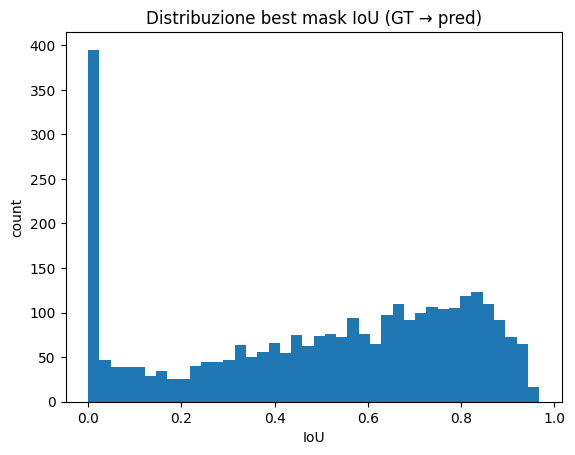

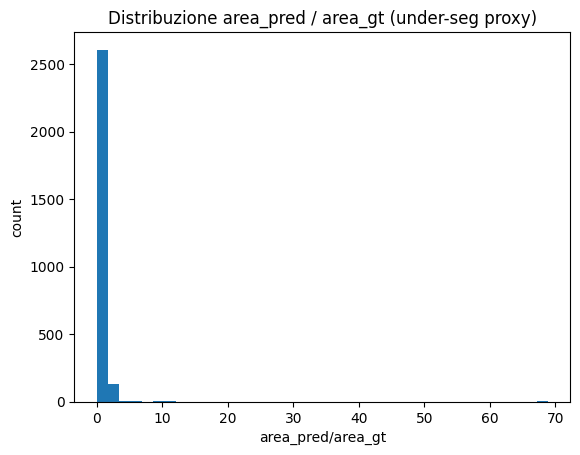

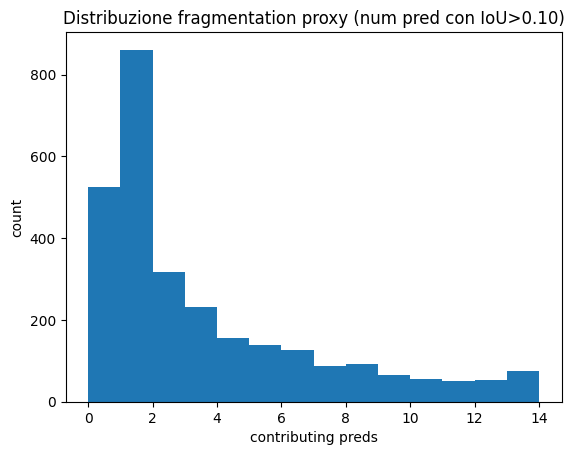

In [ ]:
# ============================================================
# ANALISI NUMERICA GT vs PRED (COCO segm) — OTTIMIZZATA
# - bbox prefilter + topK mask IoU
# - stima fragmentation / underseg / truncation
# ============================================================

import os, json, math, random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# ----------------------------
# PATHS (MODIFICA QUI)
# ----------------------------
GT_JSON   = "/content/dataset_finale2/test/_annotations.coco.json"
PRED_JSON = "./inference_out/pred_th_0.05.json"   # metti qui il json filtrato a una soglia
IMG_W, IMG_H = 700, 700  # se non sai, lascia così; serve solo per clamp bbox

# ----------------------------
# PARAMETRI ANALISI
# ----------------------------
SCORE_MIN       = 0.05      # usa stesso threshold del file o riallinea qui
BBOX_IOU_MIN    = 0.01      # prefilter permissivo (non troppo alto)
TOPK_CANDIDATES = 25        # quante pred per GT decodificare al massimo
MAX_IMAGES      = None      # None = tutte; oppure es. 50 per test rapido
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ----------------------------
# Utils bbox
# ----------------------------
def xywh_to_xyxy(b):
    x,y,w,h = b
    return [x, y, x+w, y+h]

def clamp_xyxy(b):
    x1,y1,x2,y2 = b
    x1 = max(0, min(IMG_W-1, x1))
    y1 = max(0, min(IMG_H-1, y1))
    x2 = max(0, min(IMG_W-1, x2))
    y2 = max(0, min(IMG_H-1, y2))
    return [x1,y1,x2,y2]

def bbox_iou_xyxy(a, b):
    ax1,ay1,ax2,ay2 = a
    bx1,by1,bx2,by2 = b
    inter_x1 = max(ax1,bx1); inter_y1 = max(ay1,by1)
    inter_x2 = min(ax2,bx2); inter_y2 = min(ay2,by2)
    iw = max(0.0, inter_x2-inter_x1)
    ih = max(0.0, inter_y2-inter_y1)
    inter = iw*ih
    area_a = max(0.0,(ax2-ax1))*max(0.0,(ay2-ay1))
    area_b = max(0.0,(bx2-bx1))*max(0.0,(by2-by1))
    union = area_a + area_b - inter + 1e-9
    return inter/union

def mask_iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return float(inter/union) if union > 0 else 0.0

def decode_rle(rle):
    # rle already has counts as str
    return coco_mask.decode(rle).astype(bool)

# ----------------------------
# Load GT
# ----------------------------
coco_gt = COCO(GT_JSON)
gt_ann_ids = coco_gt.getAnnIds()
gt_anns = coco_gt.loadAnns(gt_ann_ids)

# Eventuale subset immagini per test rapido
if MAX_IMAGES is not None:
    all_img_ids = list(set(a["image_id"] for a in gt_anns))
    keep_imgs = set(random.sample(all_img_ids, min(MAX_IMAGES, len(all_img_ids))))
    gt_anns = [a for a in gt_anns if a["image_id"] in keep_imgs]

print(f"GT anns usate: {len(gt_anns)}")

# ----------------------------
# Load preds
# ----------------------------
with open(PRED_JSON) as f:
    preds = json.load(f)

# normalizza category_id (spesso RF-DETR mette label 0, mentre COCO catId può essere 1)
gt_cat_ids = coco_gt.getCatIds()
CAT_ID = gt_cat_ids[0] if len(gt_cat_ids)==1 else None

preds_by_img = defaultdict(list)
for p in preds:
    if p["score"] < SCORE_MIN:
        continue
    # forza category_id al CAT_ID se dataset è mono-classe (evita mismatch)
    if CAT_ID is not None:
        p["category_id"] = int(CAT_ID)
    preds_by_img[p["image_id"]].append(p)

print(f"Predizioni caricate (>= {SCORE_MIN}): {sum(len(v) for v in preds_by_img.values())}")

# Precalcola bbox xyxy per pred
for img_id, plist in preds_by_img.items():
    for p in plist:
        p["_bbox_xyxy"] = clamp_xyxy(xywh_to_xyxy(p["bbox"]))

# ----------------------------
# Analisi per GT
# ----------------------------
best_ious = []
best_bbox_ious = []
area_ratios = []      # area_pred / area_gt (underseg se <<1)
bbox_cover = []       # IoU bbox pred vs gt (proxy truncation)
frag_counts = []      # numero pred con bbox_iou>t che contribuiscono
missed = 0

# per speed: cache decode per img_id e idx (decodifica solo se serve)
mask_cache = {}

def get_pred_mask(img_id, pred_idx):
    key = (img_id, pred_idx)
    if key in mask_cache:
        return mask_cache[key]
    rle = preds_by_img[img_id][pred_idx]["segmentation"]
    m = decode_rle(rle)
    mask_cache[key] = m
    return m

# indicizza GT per immagine per evitare accessi ripetuti
gt_by_img = defaultdict(list)
for ann in gt_anns:
    gt_by_img[ann["image_id"]].append(ann)

# Loop immagini
for img_id, gt_list in gt_by_img.items():
    plist = preds_by_img.get(img_id, [])
    if len(plist) == 0:
        missed += len(gt_list)
        continue

    # array bbox pred per speed
    pred_boxes = [p["_bbox_xyxy"] for p in plist]
    pred_scores = [p["score"] for p in plist]

    for ann in gt_list:
        gt_box = clamp_xyxy(xywh_to_xyxy(ann["bbox"]))
        gt_area = float(ann["area"])
        gt_mask = coco_gt.annToMask(ann).astype(bool)

        # 1) prefilter bbox iou
        cand = []
        for j, pb in enumerate(pred_boxes):
            biou = bbox_iou_xyxy(gt_box, pb)
            if biou >= BBOX_IOU_MIN:
                cand.append((j, biou, pred_scores[j]))

        if not cand:
            missed += 1
            continue

        # 2) prendi topK per bbox_iou (e score come tie-break)
        cand.sort(key=lambda x: (x[1], x[2]), reverse=True)
        cand = cand[:TOPK_CANDIDATES]

        # 3) calcola mask IoU solo su candidati
        best_iou = 0.0
        best_biou = 0.0
        best_pred_area = None
        best_pred_box = None

        # anche: fragmentation proxy -> quante pred hanno mask_iou>0.1 con GT
        contributing = 0

        for (j, biou, sc) in cand:
            pmask = get_pred_mask(img_id, j)
            miou = mask_iou(gt_mask, pmask)
            if miou > 0.10:
                contributing += 1
            if miou > best_iou:
                best_iou = miou
                best_biou = biou
                best_pred_area = float(pmask.sum())
                best_pred_box = pred_boxes[j]

        best_ious.append(best_iou)
        best_bbox_ious.append(best_biou)
        frag_counts.append(contributing)

        if best_pred_area is not None and gt_area > 0:
            area_ratios.append(best_pred_area / gt_area)

        # bbox cover proxy (truncation): se bbox_iou alto ma mask_iou basso -> forma/underseg
        bbox_cover.append(best_biou)

print("\n=== RISULTATI BASE ===")
print(f"GT considerate: {len(gt_anns)}")
print(f"Missed (nessun candidato): {missed}  ({missed/len(gt_anns):.1%})")
print(f"Match valutati: {len(best_ious)}")

best_ious_np = np.array(best_ious) if best_ious else np.array([0.0])

print("\n=== IoU (mask) best-match ===")
for t in [0.25, 0.50, 0.60, 0.70, 0.75]:
    print(f"P(IoU >= {t:.2f}) = {(best_ious_np >= t).mean():.1%}")

# ----------------------------
# Diagnosi pattern (numerica)
# ----------------------------
# Fragmentation: contributing >= 2 con overlap minimo
frag_np = np.array(frag_counts) if frag_counts else np.array([0])
under_np = np.array(area_ratios) if area_ratios else np.array([1.0])
bbox_np  = np.array(best_bbox_ious) if best_bbox_ious else np.array([0.0])

print("\n=== Diagnosi pattern (proxy) ===")
print(f"Fragmentation (>=2 pred con IoU>0.10): {(frag_np >= 2).mean():.1%}")
print(f"Under-seg (area_pred/area_gt < 0.70): {(under_np < 0.70).mean():.1%}")
print(f"Severe under-seg (area_pred/area_gt < 0.50): {(under_np < 0.50).mean():.1%}")

# Truncation proxy: bbox_iou alto ma mask_iou basso
trunc_like = (bbox_np >= 0.30) & (best_ious_np < 0.50)
print(f"Trunc-like (bbox IoU>=0.30 & mask IoU<0.50): {trunc_like.mean():.1%}")

# ----------------------------
# Plot rapidi
# ----------------------------
plt.figure()
plt.hist(best_ious_np, bins=40)
plt.title("Distribuzione best mask IoU (GT → pred)")
plt.xlabel("IoU"); plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(under_np, bins=40)
plt.title("Distribuzione area_pred / area_gt (under-seg proxy)")
plt.xlabel("area_pred/area_gt"); plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(frag_np, bins=range(0, min(int(frag_np.max())+2, 15)))
plt.title("Distribuzione fragmentation proxy (num pred con IoU>0.10)")
plt.xlabel("contributing preds"); plt.ylabel("count")
plt.show()


In [ ]:
# ============================================================
#  BACKUP rfdetr_runs → GOOGLE DRIVE
# ============================================================

import shutil
from pathlib import Path

SRC_DIR = Path("/content/output")
DST_ZIP = Path("/content/drive/MyDrive/25.zip")


# Rimuove zip precedente se esiste
if DST_ZIP.exists():
    DST_ZIP.unlink()

# Crea zip
shutil.make_archive(
    base_name=str(DST_ZIP).replace(".zip", ""),
    format="zip",
    root_dir=SRC_DIR.parent,
    base_dir=SRC_DIR.name
)

print("✅ Backup completato")
print(f"📦 Salvato in: {DST_ZIP}")


✅ Backup completato
📦 Salvato in: /content/drive/MyDrive/25.zip


In [ ]:
from google.colab import drive
from pathlib import Path
import shutil

# 1️⃣ Monta Google Drive (se non già montato)
drive.mount('/content/drive')

# 2️⃣ Path sorgente e destinazione
SRC_DIR = Path("/content/rfdetr_runs")
DST_ZIP = Path("/content/drive/MyDrive/rfdetr_runs_backup_22.zip")

# 3️⃣ Verifica che la cartella esista
assert SRC_DIR.exists(), f"❌ Cartella non trovata: {SRC_DIR}"

# 4️⃣ Crea ZIP
shutil.make_archive(

    base_name=str(DST_ZIP).replace(".zip", ""),
    format="zip",
    root_dir=SRC_DIR
)

print("✅ Backup completato")
print(f"📦 File salvato in: {DST_ZIP}")


## 07 · Morphology and tiling diagnostics

Instance fragmentation, length and thickness proxies, coverage and tiling.

In [ ]:
import json
from collections import Counter, defaultdict
from pathlib import Path

DATASET_DIR = Path("/content/dataset_finale6/test")
ANN_PATH = DATASET_DIR / "_annotations.coco.json"

with open(ANN_PATH) as f:
    coco = json.load(f)

print("Images:", len(coco["images"]))
print("Annotations:", len(coco["annotations"]))
print("Categories:", coco["categories"])

# categorie
cat_ids = [c["id"] for c in coco["categories"]]
print("Category IDs:", cat_ids)

# annotazioni per categoria
ann_cat = Counter(a["category_id"] for a in coco["annotations"])
print("Annotations per category:", ann_cat)

# immagini duplicate per filename
file_counts = Counter(img["file_name"] for img in coco["images"])
dups = [k for k,v in file_counts.items() if v > 1]
print("Duplicate filenames:", len(dups))


Images: 396
Annotations: 3311
Categories: [{'supercategory': 'cable', 'id': 0, 'name': 'cable'}]
Category IDs: [0]
Annotations per category: Counter({0: 3311})
Duplicate filenames: 0


In [ ]:
train_areas = analyze_coco("/content/dataset_finale6/train")
test_areas  = analyze_coco("/content/dataset_finale6/test")



===== ANALISI: TRAIN =====
Images: 835
Annotations: 6685
Categories: [{'supercategory': 'cable', 'id': 0, 'name': 'cable'}]
Annotations per category: Counter({0: 6685})
Duplicate filenames: 0
Empty masks: 0
Very small masks (<10 px): 63
Min area: 2
Median area: 608.0
Mean area: 1306.9204188481676
Max area: 48409

===== ANALISI: TEST =====
Images: 396
Annotations: 3311
Categories: [{'supercategory': 'cable', 'id': 0, 'name': 'cable'}]
Annotations per category: Counter({0: 3311})
Duplicate filenames: 0
Empty masks: 0
Very small masks (<10 px): 30
Min area: 1
Median area: 572.0
Mean area: 1233.3968589549984
Max area: 23834


In [ ]:
# =========================
# CELLA 1 — Fragmentation: connected components per instance (TRAIN vs TEST)
# Dataset: /content/dataset_finale6/{train,test}/_annotations.coco.json
# =========================

import json
import numpy as np
from pathlib import Path
from collections import Counter
from pycocotools import mask as maskUtils
from scipy import ndimage

# --- PATHS ---
TRAIN_DIR = Path("/content/dataset_finale6/train")
TEST_DIR  = Path("/content/dataset_finale6/test")
TRAIN_ANN = TRAIN_DIR / "_annotations.coco.json"
TEST_ANN  = TEST_DIR  / "_annotations.coco.json"

def load_coco(ann_path: Path):
    with open(ann_path, "r") as f:
        coco = json.load(f)
    img_id_to_hw = {img["id"]: (img["height"], img["width"]) for img in coco["images"]}
    return coco, img_id_to_hw

def decode_segmentation(segmentation, height, width):
    """
    Supporta:
    - RLE dict: {"counts": ..., "size":[h,w]}
    - Polygon COCO: list of lists [[x1,y1,...], ...]
    """
    if isinstance(segmentation, dict):
        # RLE
        return maskUtils.decode(segmentation)
    elif isinstance(segmentation, list):
        # Polygon -> RLE -> mask
        rles = maskUtils.frPyObjects(segmentation, height, width)
        rle = maskUtils.merge(rles)
        return maskUtils.decode(rle)
    else:
        raise ValueError(f"Formato segmentation non supportato: {type(segmentation)}")

def connected_components_count(mask):
    # mask può essere HxW o HxWx1
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    mask = (mask > 0).astype(np.uint8)
    _, n = ndimage.label(mask, structure=np.ones((3,3), dtype=np.uint8))  # 8-connectivity
    return int(n)

def components_stats(coco, img_id_to_hw):
    comps = []
    for ann in coco["annotations"]:
        h, w = img_id_to_hw[ann["image_id"]]
        m = decode_segmentation(ann["segmentation"], h, w)
        comps.append(connected_components_count(m))
    comps = np.array(comps, dtype=np.int32)
    return comps

# --- RUN ---
train_coco, train_hw = load_coco(TRAIN_ANN)
test_coco,  test_hw  = load_coco(TEST_ANN)

train_comps = components_stats(train_coco, train_hw)
test_comps  = components_stats(test_coco,  test_hw)

def summarize(name, comps):
    cnt = Counter(comps)
    multi = int((comps > 1).sum())
    print(f"\n===== {name} =====")
    print("Instances:", len(comps))
    print("Componenti per istanza (top 10):", cnt.most_common(10))
    print("Istanze spezzate (>1 comp):", multi, f"({multi/len(comps)*100:.2f}%)")
    print("Median comps:", float(np.median(comps)))
    print("95th percentile comps:", int(np.percentile(comps, 95)))

summarize("TRAIN", train_comps)
summarize("TEST",  test_comps)



===== TRAIN =====
Instances: 6685
Componenti per istanza (top 10): [(np.int32(1), 5294), (np.int32(2), 175), (np.int32(3), 115), (np.int32(4), 113), (np.int32(6), 70), (np.int32(7), 55), (np.int32(5), 50), (np.int32(9), 41), (np.int32(8), 32), (np.int32(10), 31)]
Istanze spezzate (>1 comp): 1391 (20.81%)
Median comps: 1.0
95th percentile comps: 32

===== TEST =====
Instances: 3311
Componenti per istanza (top 10): [(np.int32(1), 2528), (np.int32(2), 105), (np.int32(3), 57), (np.int32(4), 48), (np.int32(7), 31), (np.int32(5), 31), (np.int32(8), 29), (np.int32(12), 26), (np.int32(10), 21), (np.int32(14), 18)]
Istanze spezzate (>1 comp): 783 (23.65%)
Median comps: 1.0
95th percentile comps: 42


In [ ]:
# =========================
# CELLA 2 — Linearity: area / bounding-box ratio (TRAIN vs TEST)
# =========================

import numpy as np

def area_bbox_ratio(mask):
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return 0.0
    h = ys.max() - ys.min() + 1
    w = xs.max() - xs.min() + 1
    bbox_area = h * w
    return float(mask.sum()) / float(bbox_area)

def linearity_stats(coco, img_id_to_hw):
    ratios = []
    for ann in coco["annotations"]:
        h, w = img_id_to_hw[ann["image_id"]]
        m = decode_segmentation(ann["segmentation"], h, w)
        ratios.append(area_bbox_ratio(m))
    return np.array(ratios, dtype=np.float32)

train_ratios = linearity_stats(train_coco, train_hw)
test_ratios  = linearity_stats(test_coco,  test_hw)

def summarize_ratios(name, ratios):
    print(f"\n===== {name} =====")
    print("Instances:", len(ratios))
    print("Median ratio:", float(np.median(ratios)))
    print("Mean ratio:", float(np.mean(ratios)))
    print("10th percentile:", float(np.percentile(ratios, 10)))
    print("25th percentile:", float(np.percentile(ratios, 25)))
    print("75th percentile:", float(np.percentile(ratios, 75)))
    print("90th percentile:", float(np.percentile(ratios, 90)))

summarize_ratios("TRAIN", train_ratios)
summarize_ratios("TEST",  test_ratios)



===== TRAIN =====
Instances: 6685
Median ratio: 0.037423696368932724
Mean ratio: 0.09412240236997604
10th percentile: 0.009093343280255795
25th percentile: 0.01692102663218975
75th percentile: 0.09966517984867096
90th percentile: 0.24964500963687897

===== TEST =====
Instances: 3311
Median ratio: 0.032405294477939606
Mean ratio: 0.08313893526792526
10th percentile: 0.008238221518695354
25th percentile: 0.014795513823628426
75th percentile: 0.0798594057559967
90th percentile: 0.20928572118282318


In [ ]:
# =========================
# CELLA 3 — Thickness proxy via skeleton (TRAIN vs TEST)
# =========================

import numpy as np
from skimage.morphology import skeletonize

def thickness_proxy(mask):
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    mask = mask > 0
    skel = skeletonize(mask)
    skel_len = skel.sum()
    if skel_len == 0:
        return 0.0
    return float(mask.sum()) / float(skel_len)

def thickness_stats(coco, img_id_to_hw):
    vals = []
    for ann in coco["annotations"]:
        h, w = img_id_to_hw[ann["image_id"]]
        m = decode_segmentation(ann["segmentation"], h, w)
        vals.append(thickness_proxy(m))
    return np.array(vals, dtype=np.float32)

train_thick = thickness_stats(train_coco, train_hw)
test_thick  = thickness_stats(test_coco,  test_hw)

def summarize_thickness(name, vals):
    print(f"\n===== {name} =====")
    print("Instances:", len(vals))
    print("Median thickness:", float(np.median(vals)))
    print("Mean thickness:", float(np.mean(vals)))
    print("10th percentile:", float(np.percentile(vals, 10)))
    print("25th percentile:", float(np.percentile(vals, 25)))
    print("75th percentile:", float(np.percentile(vals, 75)))
    print("90th percentile:", float(np.percentile(vals, 90)))

summarize_thickness("TRAIN", train_thick)
summarize_thickness("TEST",  test_thick)



===== TRAIN =====
Instances: 6685
Median thickness: 2.323333263397217
Mean thickness: 3.054499864578247
10th percentile: 1.0
25th percentile: 1.3279173374176025
75th percentile: 3.78125
90th percentile: 5.941176414489746

===== TEST =====
Instances: 3311
Median thickness: 2.1309523582458496
Mean thickness: 2.827836036682129
10th percentile: 1.0
25th percentile: 1.271085500717163
75th percentile: 3.564455270767212
90th percentile: 5.493113040924072


In [ ]:
# =========================
# CELLA 4 — Globality: bbox touches border + bbox coverage (TRAIN vs TEST)
# =========================

import numpy as np

def bbox_from_mask(mask):
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None  # empty
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    return int(x0), int(y0), int(x1), int(y1)  # inclusive

def analyze_globality(coco, img_id_to_hw, border_eps=0):
    touches_1 = 0
    touches_2plus = 0
    cover_fracs = []
    diag_fracs = []  # diagonal bbox / diagonal img

    for ann in coco["annotations"]:
        h, w = img_id_to_hw[ann["image_id"]]
        m = decode_segmentation(ann["segmentation"], h, w)
        bb = bbox_from_mask(m)
        if bb is None:
            continue
        x0, y0, x1, y1 = bb
        # bbox dims
        bw = (x1 - x0 + 1)
        bh = (y1 - y0 + 1)

        # touches borders?
        t = 0
        if x0 <= border_eps: t += 1
        if y0 <= border_eps: t += 1
        if x1 >= (w - 1 - border_eps): t += 1
        if y1 >= (h - 1 - border_eps): t += 1
        if t >= 1: touches_1 += 1
        if t >= 2: touches_2plus += 1

        cover_fracs.append((bw * bh) / (w * h))
        diag_fracs.append(np.sqrt(bw*bw + bh*bh) / np.sqrt(w*w + h*h))

    cover_fracs = np.array(cover_fracs, dtype=np.float32)
    diag_fracs  = np.array(diag_fracs,  dtype=np.float32)

    n = len(cover_fracs)
    return {
        "n": n,
        "touch>=1": touches_1,
        "touch>=2": touches_2plus,
        "touch>=1_pct": touches_1 / n * 100 if n else 0.0,
        "touch>=2_pct": touches_2plus / n * 100 if n else 0.0,
        "cover_median": float(np.median(cover_fracs)) if n else 0.0,
        "cover_p90": float(np.percentile(cover_fracs, 90)) if n else 0.0,
        "diag_median": float(np.median(diag_fracs)) if n else 0.0,
        "diag_p90": float(np.percentile(diag_fracs, 90)) if n else 0.0,
    }

train_g = analyze_globality(train_coco, train_hw, border_eps=0)
test_g  = analyze_globality(test_coco,  test_hw,  border_eps=0)

def print_globality(name, g):
    print(f"\n===== {name} =====")
    print("Instances:", g["n"])
    print("Touch >=1 border:", g["touch>=1"], f"({g['touch>=1_pct']:.2f}%)")
    print("Touch >=2 borders:", g["touch>=2"], f"({g['touch>=2_pct']:.2f}%)")
    print("BBox coverage median:", g["cover_median"])
    print("BBox coverage p90:", g["cover_p90"])
    print("BBox diag/img diag median:", g["diag_median"])
    print("BBox diag/img diag p90:", g["diag_p90"])

print_globality("TRAIN", train_g)
print_globality("TEST",  test_g)



===== TRAIN =====
Instances: 6685
Touch >=1 border: 4691 (70.17%)
Touch >=2 borders: 1474 (22.05%)
BBox coverage median: 0.04231836646795273
BBox coverage p90: 0.28279832005500793
BBox diag/img diag median: 0.3522319495677948
BBox diag/img diag p90: 0.7203247547149658

===== TEST =====
Instances: 3311
Touch >=1 border: 2391 (72.21%)
Touch >=2 borders: 799 (24.13%)
BBox coverage median: 0.045648980885744095
BBox coverage p90: 0.3025795817375183
BBox diag/img diag median: 0.35747554898262024
BBox diag/img diag p90: 0.7211102843284607


In [ ]:
# =========================
# CELLA 5 — Inference Tiling + Merge (MODEL-AGNOSTIC)
# =========================

import numpy as np

def sliding_windows(h, w, tile=512, overlap=0.3):
    step = int(tile * (1 - overlap))
    xs = list(range(0, max(1, w - tile + 1), step))
    ys = list(range(0, max(1, h - tile + 1), step))
    if xs[-1] != w - tile: xs.append(max(0, w - tile))
    if ys[-1] != h - tile: ys.append(max(0, h - tile))
    return [(x, y) for y in ys for x in xs]

def place_mask(global_mask, patch_mask, x, y):
    gh, gw = global_mask.shape
    ph, pw = patch_mask.shape
    x2, y2 = min(x+pw, gw), min(y+ph, gh)
    global_mask[y:y2, x:x2] = np.maximum(
        global_mask[y:y2, x:x2], patch_mask[:(y2-y), :(x2-x)]
    )
    return global_mask

def nms_union(masks, scores, iou_thr=0.3):
    # semplice union-based NMS su mask binarie
    keep = []
    order = np.argsort(scores)[::-1]
    used = [False]*len(masks)

    def iou(a, b):
        inter = np.logical_and(a, b).sum()
        union = np.logical_or(a, b).sum()
        return inter/union if union>0 else 0.0

    for i in order:
        if used[i]: continue
        cur = masks[i].copy()
        used[i] = True
        for j in order:
            if used[j]: continue
            if iou(cur, masks[j]) >= iou_thr:
                cur = np.logical_or(cur, masks[j])
                used[j] = True
        keep.append(cur.astype(np.uint8))
    return keep

def tiled_inference(image, infer_on_patch, tile=512, overlap=0.3, score_thr=0.05):
    """
    infer_on_patch(patch) -> list of (mask, score)
    mask: HxW (patch coords)
    """
    h, w = image.shape[:2]
    windows = sliding_windows(h, w, tile, overlap)

    all_masks, all_scores = [], []
    for (x, y) in windows:
        patch = image[y:y+tile, x:x+tile]
        preds = infer_on_patch(patch)
        for m, s in preds:
            if s < score_thr: continue
            gmask = np.zeros((h, w), dtype=np.uint8)
            place_mask(gmask, m.astype(np.uint8), x, y)
            all_masks.append(gmask)
            all_scores.append(s)

    if not all_masks:
        return []

    merged = nms_union(all_masks, all_scores, iou_thr=0.3)
    return merged


## 08 · Inference and error-analysis variants

Overlaps, debug tools, GT-to-prediction matching and exploratory mask repair.

In [ ]:
# ============================================================
# RF-DETR — INFERENZA DEFINITIVA + SWEEP THRESHOLD + COCOeval
# (ALLINEATA AL TRAIN MASK-FIRST @1056)
# ============================================================

import torch
import json
import numpy as np
from pathlib import Path
from tqdm import tqdm

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from pycocotools.cocoeval import COCOeval

from torch.utils.data import DataLoader
from rfdetr import RFDETRSegPreview
from rfdetr.datasets import build_dataset
from rfdetr.util.misc import collate_fn

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
DATASET_ROOT = "/content/dataset_finale6"
IMAGE_SET = "val"   # RF-DETR supporta solo train / val
GT_JSON = Path(DATASET_ROOT) / "test/_annotations.coco.json"

CHECKPOINT = "/content/ema2/output/checkpoint_best_total.pth"

OUT_DIR = Path("./inference_out")
OUT_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------------------------------------
# ARGS (IDENTICI AL TRAIN)
# ------------------------------------------------------------
class Args:
    dataset_file = "roboflow"
    dataset_dir = DATASET_ROOT
    num_classes = 1

    # INPUT
    resolution = 1056
    square_resize_div_64 = True
    multi_scale = False
    expanded_scales = False
    do_random_resize_via_padding = False

    # BACKBONE
    patch_size = 12
    num_windows = 2

    # MASK GEOMETRY
    mask_downsample_ratio = 1
    mask_point_sample_ratio = 1024

    # SELECTION
    num_select = 10

# ------------------------------------------------------------
# LOAD GT
# ------------------------------------------------------------
coco_gt = COCO(str(GT_JSON))
gt_cat_ids = coco_gt.getCatIds()
assert len(gt_cat_ids) == 1, "Attesa una sola categoria"
CAT_ID = gt_cat_ids[0]

# ------------------------------------------------------------
# DATASET & DATALOADER
# ------------------------------------------------------------
dataset = build_dataset(
    image_set=IMAGE_SET,
    args=Args(),
    resolution=Args.resolution
)

loader = DataLoader(
    dataset,
    batch_size=2,
    collate_fn=collate_fn,
    num_workers=2
)

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------
wrapper = RFDETRSegPreview(pretrain_weights=CHECKPOINT)
model = wrapper.model.model.to(DEVICE).eval()
postprocess = wrapper.model.postprocess
# 🔥 SBLOCCA IL RECALL (EXAM MODE)
model.num_queries = 400
model.num_select  = 300


# ------------------------------------------------------------
# 1. INFERENZA COMPLETA (UNA SOLA VOLTA)
# ------------------------------------------------------------
predictions = []

with torch.inference_mode():
    for samples, targets in tqdm(loader, desc="Inferenza completa"):
        samples = samples.to(DEVICE)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        outputs = model(samples)

        # CRITICO: usare orig_size dai targets
        target_sizes = torch.stack([t["orig_size"] for t in targets]).to(DEVICE)
        results = postprocess(outputs, target_sizes)

        image_ids = [t["image_id"].item() for t in targets]

        for b_idx, res in enumerate(results):
            img_id = image_ids[b_idx]

            scores = res["scores"].cpu().numpy()
            labels = res["labels"].cpu().numpy()
            boxes  = res["boxes"].cpu().numpy()   # xyxy
            masks  = res["masks"].cpu().numpy()   # (N,1,H,W) o (N,H,W)

            for i in range(len(scores)):
                mask = masks[i]
                if mask.ndim == 3:
                    mask = mask.squeeze(0)

                mask_bin = (mask > 0.01).astype(np.uint8)
                if mask_bin.sum() == 0:
                    continue

                rle = coco_mask.encode(np.asfortranarray(mask_bin))
                rle["counts"] = rle["counts"].decode("utf-8")

                x1, y1, x2, y2 = boxes[i].tolist()
                bbox_xywh = [x1, y1, x2 - x1, y2 - y1]

                predictions.append({
                    "image_id": img_id,
                    "category_id": int(labels[i]),
                    "segmentation": rle,
                    "bbox": [round(v, 3) for v in bbox_xywh],
                    "score": float(scores[i]),
                })

print(f"\nTotale predizioni raccolte: {len(predictions)}")

# ------------------------------------------------------------
# 2. SWEEP THRESHOLD + COCOeval
# ------------------------------------------------------------
thresholds = np.arange(0.05, 0.50, 0.05)
results_table = []

for th in thresholds:
    th = round(float(th), 2)
    print(f"\n==============================")
    print(f"🔍 Threshold = {th}")
    print(f"==============================")

    filtered = [p for p in predictions if p["score"] >= th]
    print(f"Num predizioni: {len(filtered)}")

    if len(filtered) == 0:
        continue

    temp_json = OUT_DIR / f"pred_th_{th:.2f}.json"
    with open(temp_json, "w") as f:
        json.dump(filtered, f)

    coco_dt = coco_gt.loadRes(str(temp_json))
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="segm")
    coco_eval.params.catIds = gt_cat_ids

    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    ap   = coco_eval.stats[0]   # AP @[0.50:0.95]

    ap50 = coco_eval.stats[1]   # AP @0.50
    ar   = coco_eval.stats[6]   # AR @100


    results_table.append((th, ap, ap50, ar))

# ------------------------------------------------------------
# 3. RIEPILOGO FINALE
# ------------------------------------------------------------

print("\n==============================")
print("📊 RIEPILOGO FINALE")
print("==============================")
print("th\tAP\tAP50\tAR@100")

for th, ap, ap50, ar in results_table:
    print(f"{th:.2f}\t{ap:.3f}\t{ap50:.3f}\t{ar:.3f}")

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Inferenza completa: 100%|██████████| 198/198 [02:49<00:00,  1.17it/s]


[Stored console output abbreviated; full log in Segmentation.ipynb]
IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.104
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.556
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.223
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.069
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.260
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.269
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.103
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.574
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.883

📊 RIEPILOGO FINALE
th	AP	AP50	AR@100
0.05	0.231	0.468	0.069
0.10	0.231	0.468	0.069
0.15	0.231	0.468	0.069
0.20	0.230	0.465	0.069
0.25	0.230	0.460	0.069
0.30	0.228	0.460	0.069
0.35	0.227	0.455	0.069
0.40	0.225	0.449	0.069
0.45	0.224	0.442	0

In [ ]:
# ============================================================
# ISPEZIONE — OVERLAP SPAZIALE TRA ISTANZE
# ============================================================

from shapely.geometry import box
import numpy as np
from collections import defaultdict

def iou_bbox(a, b):
    ax1, ay1, aw, ah = a
    bx1, by1, bw, bh = b
    A = box(ax1, ay1, ax1+aw, ay1+ah)
    B = box(bx1, by1, bx1+bw, by1+bh)
    if not A.intersects(B):
        return 0.0
    return A.intersection(B).area / A.union(B).area

overlap_per_img = {}

for img_id, anns in anns_by_img.items():
    if len(anns) < 5:
        continue
    ious = []
    for i in range(len(anns)):
        for j in range(i+1, len(anns)):
            ious.append(iou_bbox(anns[i]["bbox"], anns[j]["bbox"]))
    overlap_per_img[img_id] = np.mean(ious) if ious else 0

vals = np.array(list(overlap_per_img.values()))
print("Overlap medio bbox:")
print(" >0.1:", (vals > 0.1).mean()*100)
print(" >0.2:", (vals > 0.2).mean()*100)


Overlap medio bbox:
 >0.1: 31.555555555555554
 >0.2: 12.666666666666668


In [ ]:
# ============================================================
# ISPEZIONE — CAVI AL BORDO
# ============================================================

border = 0
for ann in coco["annotations"]:
    x, y, w, h = ann["bbox"]
    if x < 3 or y < 3 or (x+w) > 697 or (y+h) > 697:
        border += 1

print("Cavi a bordo immagine:", border / len(coco["annotations"]) * 100)


Cavi a bordo immagine: 84.63724756918474


In [ ]:
# ============================================================
# 🔧 RF-DETR DEBUG HELPERS
# ============================================================

import torch
import numpy as np
from PIL import Image

# ------------------------------------------------------------
# Utility: inferenza su sample RF-DETR (coerente col dataset)
# ------------------------------------------------------------
@torch.inference_mode()
def _infer_samples(samples, targets):
    samples = samples.to(DEVICE)
    targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

    outputs = model(samples)
    target_sizes = torch.stack([t["orig_size"] for t in targets]).to(DEVICE)
    results = postprocess(outputs, target_sizes)

    return results, targets


# ------------------------------------------------------------
# 1️⃣ FULL IMAGE inference (by image_id)
# ------------------------------------------------------------
def run_rfdetr_inference_debug(img_id):
    """
    Ritorna lista di dict:
      - mask : Tensor [H,W] (logits)
      - score: float
    """

    # trova indice nel dataset
    for idx in range(len(dataset)):
        _, tgt = dataset[idx]
        if tgt["image_id"].item() == img_id:
            break
    else:
        raise ValueError(f"image_id {img_id} non trovato nel dataset")

    samples, targets = collate_fn([dataset[idx]])

    results, targets = _infer_samples(samples, targets)
    res = results[0]

    preds = []
    for i in range(len(res["scores"])):
        mask = res["masks"][i]
        if mask.ndim == 3:
            mask = mask.squeeze(0)

        preds.append({
            "mask": mask.detach().cpu(),      # LOGITS
            "score": float(res["scores"][i])
        })

    return preds


# ------------------------------------------------------------
# 2️⃣ Sliding window inference su crop RGB (numpy)
# ------------------------------------------------------------
def run_rfdetr_inference_on_crop(crop_rgb):
    """
    crop_rgb: numpy array (H,W,3)
    Ritorna lista di dict con:
      - mask : Tensor [H,W] (logits, locali)
      - score
    """

    # build fake target (minimo indispensabile)
    h, w = crop_rgb.shape[:2]
    dummy_target = {
        "orig_size": torch.tensor([h, w]),
        "size": torch.tensor([h, w]),
        "image_id": torch.tensor([-1]),
    }

    # preprocessing identico al dataset
    sample = dataset.transforms(
        Image.fromarray(crop_rgb),
        dummy_target
    )[0]

    samples, targets = collate_fn([(sample, dummy_target)])

    results, _ = _infer_samples(samples, targets)
    res = results[0]

    preds = []
    for i in range(len(res["scores"])):
        mask = res["masks"][i]
        if mask.ndim == 3:
            mask = mask.squeeze(0)

        preds.append({
            "mask": mask.detach().cpu(),
            "score": float(res["scores"][i])
        })

    return preds


In [ ]:
import sys
# 1. FORZIAMO IL RIPRISTINO DELLA STAMPA (Fondamentale su Colab)
sys.stdout = sys.__stdout__
print("DEBUG: Il sistema di stampa è attivo. Se leggi questo, funziona.", flush=True)

import json
import numpy as np
import copy
import os
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ==========================================
# CONFIGURAZIONE
# ==========================================
gt_file_path = '/content/dataset_finale2/test/_annotations.coco.json'
pred_file_path = '/content/drive/MyDrive/pred_BRUTE_SAFE.json'
output_path = '/content/pred_OPTIMIZED_BEST_SUM.json'

# Parametri Re-scoring
MIN_AREA_THRESH = 80
MIN_ASPECT_RATIO = 1.5

def apply_cable_rescoring(predictions):
    print(">>> Applicazione Re-scoring...", flush=True)
    rescored_preds = copy.deepcopy(predictions)
    count_penalized = 0

    for p in rescored_preds:
        if 'bbox' not in p: continue

        w, h = p['bbox'][2], p['bbox'][3]
        area = w * h

        short_side = min(w, h)
        long_side = max(w, h)
        aspect_ratio = long_side / (short_side + 1e-6)

        original_score = p['score']
        new_score = original_score

        if area < MIN_AREA_THRESH:
            new_score *= 0.6
        if aspect_ratio < MIN_ASPECT_RATIO:
            new_score *= 0.85

        if new_score < original_score:
            p['score'] = new_score
            count_penalized += 1

    rescored_preds.sort(key=lambda x: x['score'], reverse=True)
    print(f">>> {count_penalized} predizioni penalizzate.", flush=True)
    return rescored_preds

def maximize_metrics():
    # CARICAMENTO
    print(f"1. Carico GT: {gt_file_path}", flush=True)
    if not os.path.exists(gt_file_path):
        print("ERRORE: File GT non trovato!", flush=True)
        return
    coco_gt = COCO(gt_file_path)

    print(f"2. Carico Predizioni: {pred_file_path}", flush=True)
    if not os.path.exists(pred_file_path):
        print("ERRORE: File Predizioni non trovato!", flush=True)
        return
    with open(pred_file_path, 'r') as f:
        raw_preds = json.load(f)
    print(f"   Trovate {len(raw_preds)} annotazioni raw.", flush=True)

    # RE-SCORING
    optimized_preds = apply_cable_rescoring(raw_preds)

    # GRID SEARCH
    best_score_sum = -1
    best_thresh = 0
    best_metrics = (0, 0)

    # Range ridotto per test rapido (puoi riallargarlo dopo)
    thresholds = np.arange(0.05, 0.96, 0.05)

    print("\n" + "="*80)
    print(f"INIZIO TEST SOGLIE (Ignora le scritte 'Average Precision' intermedie)")
    print("="*80, flush=True)

    for thresh in thresholds:
        filtered = [p for p in optimized_preds if p['score'] >= thresh]

        if len(filtered) == 0:
            print(f"Soglia {thresh:.2f}: Nessuna predizione rimasta.", flush=True)
            continue

        # NESSUN FILTRO OUTPUT: Lasciamo che COCO stampi tutto quello che vuole
        # così evitiamo errori di 'IOStream' o 'list index out of range'
        try:
            coco_dt = coco_gt.loadRes(filtered)
            cocoEval = COCOeval(coco_gt, coco_dt, 'segm')
            cocoEval.params.maxDets = [1, 10, 100]

            cocoEval.evaluate()
            cocoEval.accumulate()
            cocoEval.summarize() # Questo STAMPA la tabella COCO standard

            # Estrazione valori
            # stats[0] = mAP 50-95
            # stats[7] = MAR maxDets=10
            curr_map = cocoEval.stats[0]
            curr_mar_10 = cocoEval.stats[7]
            curr_sum = curr_map + curr_mar_10

            print(f"\n✅ RISULTATO SOGLIA {thresh:.2f} -> SUM: {curr_sum:.4f} (mAP: {curr_map:.4f} | MAR: {curr_mar_10:.4f})")
            print("-" * 40, flush=True)

            if curr_sum > best_score_sum:
                best_score_sum = curr_sum
                best_thresh = thresh
                best_metrics = (curr_map, curr_mar_10)

        except Exception as e:
            print(f"\n❌ ERRORE CRITICO alla soglia {thresh}: {e}", flush=True)
            # Continuiamo col prossimo loop invece di fermarci
            continue

    # SALVATAGGIO
    print("\n" + "="*80)
    print(f"VINCITORE ASSOLUTO:")
    print(f"Soglia: {best_thresh:.2f}")
    print(f"Score Totale: {best_score_sum:.4f}")

    final_json_data = [p for p in optimized_preds if p['score'] >= best_thresh]
    with open(output_path, 'w') as f:
        json.dump(final_json_data, f)

    print(f"Salvato in: {output_path}", flush=True)

if __name__ == "__main__":
    maximize_metrics()

In [ ]:
# ============================================================
# ✅ RF-DETR Seg — INFERENZA + PCA MASK REPAIR + DEBUG + COCOeval
# ============================================================

import os, json, math
import numpy as np
import torch
from pathlib import Path
from tqdm import tqdm

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from pycocotools.cocoeval import COCOeval

from torch.utils.data import DataLoader
from rfdetr import RFDETRSegPreview
from rfdetr.datasets import build_dataset
from rfdetr.util.misc import collate_fn

# --- deps ---
from sklearn.decomposition import PCA
import cv2


# ============================================================
# 🔧 CONFIG
# ============================================================
DATASET_ROOT = "/content/dataset_finale6"
IMAGE_SET    = "val"
GT_JSON      = Path(DATASET_ROOT) / "test/_annotations.coco.json"
CHECKPOINT   = "/content/ema2/output/checkpoint_best_total.pth"

OUT_DIR = Path("./inference_out_pca")
OUT_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

RESOLUTION = 720
PATCH_SIZE = 12
NUM_WINDOWS = 2
NUM_SELECT = 60
MASK_THR = 0.01

# --- PCA params ---
AREA_MAX_RATIO = 0.02
MIN_PIXELS = 25
MIN_CC = 3
PCA_RATIO_THR = 5.0
THICKNESS = 5
CLOSE_ITERS = 1
IOU_MIN_ACCEPT = 0.50

THRESHOLDS = np.arange(0.05, 0.50, 0.05)


# ============================================================
# 🧠 PCA UTILS (DEBUG)
# ============================================================
def cc_count(mask):
    n, _ = cv2.connectedComponents(mask.astype(np.uint8))
    return max(0, n - 1)

def pca_ratio(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) < MIN_PIXELS:
        return 0.0
    coords = np.stack([xs, ys], 1).astype(np.float32)
    pca = PCA(n_components=2).fit(coords)
    v = pca.explained_variance_ratio_
    return float(v[0] / max(v[1], 1e-6))

def should_apply_pca(mask, dbg):
    area_ratio = mask.sum() / mask.size
    if area_ratio <= 0:
        dbg["area_zero"] += 1; return False
    if area_ratio > AREA_MAX_RATIO:
        dbg["area_too_large"] += 1; return False
    if mask.sum() < MIN_PIXELS:
        dbg["too_few_pixels"] += 1; return False
    if cc_count(mask) < MIN_CC:
        dbg["not_fragmented"] += 1; return False
    if pca_ratio(mask) < PCA_RATIO_THR:
        dbg["not_linear"] += 1; return False
    dbg["pca_trigger_ok"] += 1
    return True

def pca_reconstruct(mask):
    ys, xs = np.where(mask > 0)
    coords = np.stack([xs, ys], 1).astype(np.float32)
    pca = PCA(n_components=2).fit(coords)
    direction = pca.components_[0]
    center = coords.mean(0)

    proj = (coords - center) @ direction
    length = np.ptp(proj)
    ts = np.linspace(proj.min(), proj.max(), max(2, int(abs(length)) + 2))
    pts = center[None] + ts[:, None] * direction[None]

    H, W = mask.shape
    recon = np.zeros((H, W), np.uint8)
    for x, y in pts:
        xi, yi = int(round(x)), int(round(y))
        if 0 <= xi < W and 0 <= yi < H:
            recon[yi, xi] = 1

    k = THICKNESS | 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    recon = cv2.dilate(recon, kernel, 1)
    if CLOSE_ITERS > 0:
        recon = cv2.morphologyEx(recon, cv2.MORPH_CLOSE, kernel, CLOSE_ITERS)
    return recon

def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

def encode_rle(mask):
    rle = coco_mask.encode(np.asfortranarray(mask.astype(np.uint8)))
    rle["counts"] = rle["counts"].decode("utf-8")
    return rle


# ============================================================
# 📦 DATASET ARGS
# ============================================================
class Args:
    dataset_file = "roboflow"
    dataset_dir  = DATASET_ROOT
    num_classes  = 1
    resolution = RESOLUTION
    square_resize_div_64 = True
    multi_scale = False
    expanded_scales = False
    do_random_resize_via_padding = False
    patch_size = PATCH_SIZE
    num_windows = NUM_WINDOWS
    mask_downsample_ratio = 1
    mask_point_sample_ratio = 1024
    num_select = NUM_SELECT


# ============================================================
# 🧾 LOAD GT / DATASET / MODEL
# ============================================================
coco_gt = COCO(str(GT_JSON))
CAT_ID = coco_gt.getCatIds()[0]

dataset = build_dataset(IMAGE_SET, Args(), Args.resolution)
loader = DataLoader(dataset, batch_size=2, collate_fn=collate_fn)

wrapper = RFDETRSegPreview(pretrain_weights=CHECKPOINT)
model = wrapper.model.model.to(DEVICE).eval()
postprocess = wrapper.model.postprocess


# ============================================================
# 🚀 INFERENZA + PCA DEBUG
# ============================================================
predictions = []
stats = {
    "total_masks": 0,
    "pca_trigger_ok": 0,
    "pca_applied": 0,
    "pca_accepted": 0,
    "area_zero": 0,
    "area_too_large": 0,
    "too_few_pixels": 0,
    "not_fragmented": 0,
    "not_linear": 0,
    "iou_sum": 0.0,
    "iou_cnt": 0,
}

with torch.inference_mode():
    for samples, targets in tqdm(loader, desc="Inferenza + PCA DEBUG"):
        samples = samples.to(DEVICE)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        outputs = model(samples)

        sizes = torch.stack([t["orig_size"] for t in targets]).to(DEVICE)
        results = postprocess(outputs, sizes)
        img_ids = [t["image_id"].item() for t in targets]

        for b, res in enumerate(results):
            for i in range(len(res["scores"])):
                stats["total_masks"] += 1
                mask = res["masks"][i].squeeze().cpu().numpy()
                mask_bin = (mask > MASK_THR).astype(np.uint8)
                if mask_bin.sum() == 0:
                    continue

                if should_apply_pca(mask_bin, stats):
                    stats["pca_applied"] += 1
                    mask_pca = pca_reconstruct(mask_bin)
                    iou = mask_iou(mask_bin, mask_pca)
                    stats["iou_sum"] += iou
                    stats["iou_cnt"] += 1
                    if iou >= IOU_MIN_ACCEPT:
                        stats["pca_accepted"] += 1
                        mask_bin = np.logical_or(mask_bin, mask_pca).astype(np.uint8)

                rle = encode_rle(mask_bin)
                x1, y1, x2, y2 = res["boxes"][i].cpu().tolist()

                predictions.append({
                    "image_id": int(img_ids[b]),
                    "category_id": int(res["labels"][i]),
                    "segmentation": rle,
                    "bbox": [x1, y1, x2-x1, y2-y1],
                    "score": float(res["scores"][i]),
                })


# ============================================================
# 📊 DEBUG SUMMARY
# ============================================================
print("\n================ PCA DEBUG ================")
for k, v in stats.items():
    print(f"{k:>20}: {v}")
if stats["iou_cnt"] > 0:
    print(f"{'mean IoU PCA':>20}: {stats['iou_sum']/stats['iou_cnt']:.3f}")


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Inferenza + PCA DEBUG: 100%|██████████| 198/198 [07:49<00:00,  2.37s/it]


================ PCA DEBUG ================
         total_masks: 79200
      pca_trigger_ok: 30640
         pca_applied: 30640
        pca_accepted: 3259
           area_zero: 0
      area_too_large: 269
      too_few_pixels: 3077
      not_fragmented: 7944
          not_linear: 1807
             iou_sum: 5591.381105594338
             iou_cnt: 30640
        mean IoU PCA: 0.182


In [ ]:
# ============================================================
# ANALISI POST-INFERENZA — LOAD GT & PRED
# ============================================================

import json
import numpy as np
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

GT_JSON = "/content/dataset_finale6/test/_annotations.coco.json"
PRED_JSON = "/content/inference_out2/pred_th_0.05.json"

coco_gt = COCO(GT_JSON)
with open(PRED_JSON, "r") as f:
    preds = json.load(f)

# indicizza pred per immagine
preds_by_img = defaultdict(list)
for p in preds:
    preds_by_img[p["image_id"]].append(p)

print("GT images:", len(coco_gt.imgs))
print("Pred images:", len(preds_by_img))
print("Tot pred:", len(preds))


In [ ]:
# ============================================================
# MATCH GT vs PRED (TP / FN)
# ============================================================

IOU_THR = 0.5

def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

gt_stats = []  # una entry per ogni GT

for img_id in coco_gt.imgs:
    gt_ids = coco_gt.getAnnIds(imgIds=img_id)
    if not gt_ids:
        continue

    gt_anns = coco_gt.loadAnns(gt_ids)
    pred_anns = preds_by_img.get(img_id, [])

    # decodifica pred masks una volta
    pred_masks = []
    for p in pred_anns:
        pm = coco_mask.decode(p["segmentation"])
        if pm.ndim == 3:
            pm = pm[:, :, 0]
        pred_masks.append(pm.astype(bool))

    for gt in gt_anns:
        gm = coco_mask.decode(gt["segmentation"])
        if gm.ndim == 3:
            gm = gm[:, :, 0]
        gm = gm.astype(bool)

        best_iou = 0.0
        for pm in pred_masks:
            best_iou = max(best_iou, mask_iou(gm, pm))

        gt_stats.append({
            "image_id": img_id,
            "area": gt["area"],
            "bbox": gt["bbox"],
            "is_border": (
                gt["bbox"][0] < 3 or gt["bbox"][1] < 3 or
                gt["bbox"][0] + gt["bbox"][2] > 697 or
                gt["bbox"][1] + gt["bbox"][3] > 697
            ),
            "length": max(gt["bbox"][2], gt["bbox"][3]),
            "matched": best_iou >= IOU_THR,
            "best_iou": best_iou
        })

print("Tot GT analyzed:", len(gt_stats))


In [ ]:
# ============================================================
# ANALISI TP vs FN
# ============================================================

tp = [g for g in gt_stats if g["matched"]]
fn = [g for g in gt_stats if not g["matched"]]

def stats(name, arr):
    arr = np.array(arr)
    return f"{name}: mean={arr.mean():.1f}, median={np.median(arr):.1f}"

print("TP:", len(tp), " FN:", len(fn))
print(stats("Area TP", [g["area"] for g in tp]))
print(stats("Area FN", [g["area"] for g in fn]))
print(stats("Length TP", [g["length"] for g in tp]))
print(stats("Length FN", [g["length"] for g in fn]))

print("Border TP:", np.mean([g["is_border"] for g in tp])*100)
print("Border FN:", np.mean([g["is_border"] for g in fn])*100)


In [ ]:
# ============================================================
# ANALISI PER IMMAGINE
# ============================================================

from collections import Counter

img_summary = defaultdict(lambda: {"TP":0, "FN":0})

for g in gt_stats:
    if g["matched"]:
        img_summary[g["image_id"]]["TP"] += 1
    else:
        img_summary[g["image_id"]]["FN"] += 1

worst_imgs = sorted(
    img_summary.items(),
    key=lambda x: (x[1]["TP"] / max(1, x[1]["TP"] + x[1]["FN"])),
)

print("PEGGIORI 10 IMMAGINI (recall):")
for img_id, s in worst_imgs[:10]:
    tot = s["TP"] + s["FN"]
    print(f"img={img_id} | TP={s['TP']} FN={s['FN']} recall={s['TP']/tot:.2f}")


In [ ]:
# ============================================================
# 💣 RF-DETR — INFERENZA DEFINITIVA + MASK REPAIR + COCOeval
# (POST-PROCESS OTTIMIZZATO PER COCO)
# ============================================================

import torch, json
import numpy as np
from pathlib import Path
from tqdm import tqdm
import cv2

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from pycocotools.cocoeval import COCOeval

from torch.utils.data import DataLoader
from rfdetr import RFDETRSegPreview
from rfdetr.datasets import build_dataset
from rfdetr.util.misc import collate_fn


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
DATASET_ROOT = "/content/dataset_finale6"
IMAGE_SET = "val"
GT_JSON = Path(DATASET_ROOT) / "test/_annotations.coco.json"
CHECKPOINT = "/content/ema2/output/checkpoint_best_total.pth"

OUT_DIR = Path("./inference_out_killer")
OUT_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MASK_THR_LOW = 0.01        # recall-first
AREA_MAX_RATIO = 0.05      # evita over-merge
K_CLOSE = 5                # morphology kernel
DILATE_ITERS = 1
CLOSE_ITERS = 2

# ------------------------------------------------------------
# DATASET ARGS (IDENTICI AL TRAIN)
# ------------------------------------------------------------
class Args:
    dataset_file = "roboflow"
    dataset_dir = DATASET_ROOT
    num_classes = 1

    resolution = 1560
    square_resize_div_64 = True
    multi_scale = False
    expanded_scales = False
    do_random_resize_via_padding = False

    patch_size = 12
    num_windows = 2

    mask_downsample_ratio = 1
    mask_point_sample_ratio = 1024
    num_select = 60


# ------------------------------------------------------------
# LOAD GT
# ------------------------------------------------------------
coco_gt = COCO(str(GT_JSON))
gt_cat_ids = coco_gt.getCatIds()
CAT_ID = gt_cat_ids[0]

# ------------------------------------------------------------
# DATASET & MODEL
# ------------------------------------------------------------
dataset = build_dataset(IMAGE_SET, Args(), Args.resolution)
loader = DataLoader(dataset, batch_size=2, collate_fn=collate_fn, num_workers=2)

wrapper = RFDETRSegPreview(pretrain_weights=CHECKPOINT)
model = wrapper.model.model.to(DEVICE).eval()
postprocess = wrapper.model.postprocess


# ------------------------------------------------------------
# 🔧 MASK REPAIR (COCO-SAFE)
# ------------------------------------------------------------
def repair_mask(mask_bin, score):
    H, W = mask_bin.shape
    area_ratio = mask_bin.sum() / (H * W)

    # skip casi pericolosi
    if area_ratio <= 0 or area_ratio > AREA_MAX_RATIO:
        return mask_bin

    k = K_CLOSE | 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))

    # più aggressivo solo se score basso
    close_iters = CLOSE_ITERS if score < 0.4 else 1
    dil_iters   = DILATE_ITERS if score < 0.3 else 0

    repaired = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel, close_iters)
    if dil_iters > 0:
        repaired = cv2.dilate(repaired, kernel, dil_iters)

    return repaired


def encode_rle(mask):
    rle = coco_mask.encode(np.asfortranarray(mask.astype(np.uint8)))
    rle["counts"] = rle["counts"].decode("utf-8")
    return rle


# ------------------------------------------------------------
# 1️⃣ INFERENZA + REPAIR
# ------------------------------------------------------------
predictions = []

with torch.inference_mode():
    for samples, targets in tqdm(loader, desc="Inferenza + Mask Repair"):
        samples = samples.to(DEVICE)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        outputs = model(samples)
        target_sizes = torch.stack([t["orig_size"] for t in targets]).to(DEVICE)
        results = postprocess(outputs, target_sizes)

        image_ids = [t["image_id"].item() for t in targets]

        for b_idx, res in enumerate(results):
            img_id = image_ids[b_idx]

            scores = res["scores"].cpu().numpy()
            labels = res["labels"].cpu().numpy()
            boxes  = res["boxes"].cpu().numpy()
            masks  = res["masks"].cpu().numpy()

            for i in range(len(scores)):
                mask = masks[i]
                if mask.ndim == 3:
                    mask = mask.squeeze(0)

                mask_bin = (mask > MASK_THR_LOW).astype(np.uint8)
                if mask_bin.sum() == 0:
                    continue

                mask_bin = repair_mask(mask_bin, scores[i])

                rle = encode_rle(mask_bin)
                x1, y1, x2, y2 = boxes[i].tolist()

                predictions.append({
                    "image_id": img_id,
                    "category_id": int(labels[i]),
                    "segmentation": rle,
                    "bbox": [x1, y1, x2 - x1, y2 - y1],
                    "score": float(scores[i]),
                })

print(f"\nTotale predizioni: {len(predictions)}")


# ------------------------------------------------------------
# 2️⃣ SWEEP THRESHOLD + COCOeval
# ------------------------------------------------------------
thresholds = np.arange(0.05, 0.50, 0.05)
results_table = []

for th in thresholds:
    th = round(float(th), 2)
    print(f"\n🔍 Threshold = {th}")

    filtered = [p for p in predictions if p["score"] >= th]
    print(f"Predizioni: {len(filtered)}")

    if not filtered:
        continue

    temp_json = OUT_DIR / f"pred_th_{th:.2f}.json"
    with open(temp_json, "w") as f:
        json.dump(filtered, f)

    coco_dt = coco_gt.loadRes(str(temp_json))
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="segm")
    coco_eval.params.catIds = gt_cat_ids

    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    ap   = coco_eval.stats[0]
    ap50 = coco_eval.stats[1]
    ar   = coco_eval.stats[6]

    results_table.append((th, ap, ap50, ar))


# ------------------------------------------------------------
# 3️⃣ RIEPILOGO
# ------------------------------------------------------------
print("\n📊 RIEPILOGO FINALE")
print("th\tAP\tAP50\tAR@100")
for th, ap, ap50, ar in results_table:
    print(f"{th:.2f}\t{ap:.3f}\t{ap50:.3f}\t{ar:.3f}")


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Inferenza + Mask Repair: 100%|██████████| 198/198 [05:54<00:00,  1.79s/it]


[Stored console output abbreviated; full log in Segmentation.ipynb]
ea=   all | maxDets=100 ] = 0.219
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.137
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.547
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.245
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.070
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.274
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.288
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.137
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.564
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.892

📊 RIEPILOGO FINALE
th	AP	AP50	AR@100
0.05	0.250	0.522	0.070
0.10	0.249	0.520	0.070
0.15	0.249	0.520	0.070
0.20	0.249	0.520	0.070
0.25	0.249	0.520	0.070
0.30	0.249	0.520	0.070
0.

In [ ]:
# ============================================================
# 🔍 ISPEZIONE IoU — GT vs PRED (POLYGON + RLE SAFE)
# ============================================================

import json, os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
GT_JSON   = "/content/dataset_finale6/test/_annotations.coco.json"
PRED_JSON = "/content/inference_out_killer/pred_th_0.05.json"
IMG_DIR   = "/content/dataset_finale6/test/images"
OUT_DIR   = "./inspect_out"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# UTILS
# ------------------------------------------------------------
def decode_mask(segmentation, height, width):
    """
    COCO-safe decoder:
    - GT polygon
    - pred RLE
    """
    # RLE
    if isinstance(segmentation, dict):
        rle = segmentation
    # Polygon
    else:
        rles = coco_mask.frPyObjects(segmentation, height, width)
        rle = coco_mask.merge(rles)

    m = coco_mask.decode(rle)
    if m.ndim == 3:
        m = m[:, :, 0]
    return m.astype(bool)


def iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0


def thickness(mask):
    if mask.sum() == 0:
        return 0.0
    dist = cv2.distanceTransform(mask.astype(np.uint8), cv2.DIST_L2, 5)
    return float(np.mean(dist[dist > 0]))

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
coco_gt = COCO(GT_JSON)
with open(PRED_JSON) as f:
    preds = json.load(f)

pred_by_img = defaultdict(list)
for p in preds:
    pred_by_img[p["image_id"]].append(p)

stats = []

# ------------------------------------------------------------
# MATCH + STATS
# ------------------------------------------------------------
for img_id, img_preds in pred_by_img.items():

    h = coco_gt.imgs[img_id]["height"]
    w = coco_gt.imgs[img_id]["width"]

    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    gt_anns = coco_gt.loadAnns(ann_ids)

    if len(gt_anns) == 0:
        continue

    for p in img_preds:
        pmask = decode_mask(p["segmentation"], h, w)
        parea = pmask.sum()

        best_iou = 0.0
        best_gt_mask = None

        for gt in gt_anns:
            gmask = decode_mask(gt["segmentation"], h, w)
            val = iou(pmask, gmask)
            if val > best_iou:
                best_iou = val
                best_gt_mask = gmask

        if best_gt_mask is None:
            continue

        stats.append({
            "image_id": img_id,
            "score": p["score"],
            "iou": best_iou,
            "pred_area": int(parea),
            "gt_area": int(best_gt_mask.sum()),
            "pred_thickness": thickness(pmask),
            "gt_thickness": thickness(best_gt_mask),
            "pmask": pmask,
            "gmask": best_gt_mask,
        })

# ------------------------------------------------------------
# NUMERI DECISIVI
# ------------------------------------------------------------
ious = np.array([s["iou"] for s in stats])

print("\n📊 IoU summary")
print(f"mean IoU      : {ious.mean():.3f}")
print(f"IoU < 0.50    : {(ious < 0.50).mean()*100:.1f}%")
print(f"IoU < 0.75    : {(ious < 0.75).mean()*100:.1f}%")

print("\n📊 Thickness (pred vs gt)")
print(f"pred mean thickness: {np.mean([s['pred_thickness'] for s in stats]):.2f}")
print(f"gt   mean thickness: {np.mean([s['gt_thickness'] for s in stats]):.2f}")

# ------------------------------------------------------------
# OVERLAY VISIVO (worst / mid / best)
# ------------------------------------------------------------
stats_sorted = sorted(stats, key=lambda x: x["iou"])

samples = (
    stats_sorted[:3] +
    stats_sorted[len(stats_sorted)//2 : len(stats_sorted)//2 + 3] +
    stats_sorted[-3:]
)

for idx, s in enumerate(samples):
    img_path = os.path.join(IMG_DIR, f"{s['image_id']}.jpg")
    img = cv2.imread(img_path)
    if img is None:
        continue

    overlay = img.copy()
    overlay[s["gmask"]] = [0, 255, 0]   # GT = verde
    overlay[s["pmask"]] = [0, 0, 255]   # PRED = rosso

    out = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)
    cv2.imwrite(f"{OUT_DIR}/sample_{idx}_iou_{s['iou']:.2f}.png", out)

print(f"\n🖼️ Overlay salvati in {OUT_DIR}")


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!

📊 IoU summary
mean IoU      : 0.322
IoU < 0.50    : 79.7%
IoU < 0.75    : 92.6%

📊 Thickness (pred vs gt)
pred mean thickness: 1.73
gt   mean thickness: 1.27

🖼️ Overlay salvati in ./inspect_out


## 09 · RANSAC and geometric post-processing

Line-guided alternatives, threshold/parameter sweeps, TTA and sanity checks.

In [ ]:
# ============================================================
# 🧵 FILTER VAL SET — IMMAGINI CON > 6 CAVI
# ============================================================

import os, json, shutil
from tqdm import tqdm
from collections import defaultdict

from pycocotools.coco import COCO

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
SRC_ROOT = "/content/dataset_finale8/valid"        # validation PCA
SRC_JSON = os.path.join(SRC_ROOT, "_annotations.coco.json")

DST_ROOT = "/content/dataset_finale8_val_gt6/val"
DST_JSON = os.path.join(DST_ROOT, "_annotations.coco.json")

MIN_CABLES = 6   # condizione: > 6 cavi

os.makedirs(DST_ROOT, exist_ok=True)

# ------------------------------------------------------------
# LOAD COCO
# ------------------------------------------------------------
coco = COCO(SRC_JSON)

with open(SRC_JSON, "r") as f:
    coco_json = json.load(f)

# ------------------------------------------------------------
# CONTA ISTANZE PER IMMAGINE
# ------------------------------------------------------------
img_to_anns = defaultdict(list)
for ann in coco_json["annotations"]:
    img_to_anns[ann["image_id"]].append(ann)

valid_img_ids = {
    img_id for img_id, anns in img_to_anns.items()
    if len(anns) > MIN_CABLES
}

print(f"✅ Immagini tenute (>{MIN_CABLES} cavi): {len(valid_img_ids)}")
print(f"❌ Immagini scartate             : {len(coco_json['images']) - len(valid_img_ids)}")

# ------------------------------------------------------------
# FILTRA IMAGES
# ------------------------------------------------------------
new_images = []
old_to_new_img_id = {}

for img in coco_json["images"]:
    if img["id"] in valid_img_ids:
        new_id = len(new_images)
        old_to_new_img_id[img["id"]] = new_id

        img_new = img.copy()
        img_new["id"] = new_id
        new_images.append(img_new)

# ------------------------------------------------------------
# FILTRA ANNOTATIONS
# ------------------------------------------------------------
new_annotations = []
ann_id = 0

for ann in coco_json["annotations"]:
    if ann["image_id"] in valid_img_ids:
        ann_new = ann.copy()
        ann_new["id"] = ann_id
        ann_new["image_id"] = old_to_new_img_id[ann["image_id"]]
        new_annotations.append(ann_new)
        ann_id += 1

# ------------------------------------------------------------
# COPY IMAGES
# ------------------------------------------------------------
print("📦 Copia immagini validation...")

for img in tqdm(new_images):
    src = os.path.join(SRC_ROOT, img["file_name"])
    dst = os.path.join(DST_ROOT, img["file_name"])
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(src, dst)

# ------------------------------------------------------------
# SAVE NEW JSON
# ------------------------------------------------------------
new_coco = {
    "images": new_images,
    "annotations": new_annotations,
    "categories": coco_json["categories"]
}

with open(DST_JSON, "w") as f:
    json.dump(new_coco, f)

print("🎉 Validation set filtrato creato!")
print(f"   • immagini finali   : {len(new_images)}")
print(f"   • annotazioni finali: {len(new_annotations)}")
print(f"   📁 path: {DST_ROOT}")


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
✅ Immagini tenute (>6 cavi): 156
❌ Immagini scartate             : 240
📦 Copia immagini validation...


100%|██████████| 156/156 [00:00<00:00, 4273.78it/s]

🎉 Validation set filtrato creato!
   • immagini finali   : 156
   • annotazioni finali: 2451
   📁 path: /content/dataset_finale8_val_gt6/val


In [ ]:
# ============================================================
# 🧠 RF-DETR — RANSAC++ PARAM SWEEP (SAFE, FINAL)
# ============================================================

import json, cv2, random
import numpy as np
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from sklearn.linear_model import RANSACRegressor, LinearRegression
from tqdm import tqdm

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
GT_JSON   = "/content/dataset_finale8/test/_annotations.coco.json"
PRED_JSON = "/content/inference_out2/pred_th_0.05.json"

IOU_MIN, IOU_MAX = 0.10, 0.70

# ------------------------------------------------------------
# PARAMETER SWEEP GRID (CONSERVATIVO)
# ------------------------------------------------------------
SWEEP = [
    dict(residual_thr=2.0, min_sup=0.45, centrality=0.20, cov=(0.45,0.75)),
    dict(residual_thr=2.5, min_sup=0.45, centrality=0.25, cov=(0.40,0.80)),
    dict(residual_thr=3.0, min_sup=0.40, centrality=0.25, cov=(0.40,0.85)),
]

BAND_WIDTH = 3
MIN_POINTS = 150

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
coco_gt = COCO(GT_JSON)
with open(PRED_JSON) as f:
    preds = json.load(f)

# ------------------------------------------------------------
# UTILS
# ------------------------------------------------------------
def decode_coco_seg(seg, h, w):
    if isinstance(seg, dict):
        return coco_mask.decode(seg).astype(bool)
    rles = coco_mask.frPyObjects(seg, h, w)
    m = coco_mask.decode(rles)
    if m.ndim == 3:
        m = m.any(axis=2)
    return m.astype(bool)

def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

def pixel_recall(pred, gt):
    tp = np.logical_and(pred, gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    return tp / (tp + fn + 1e-6)

# ------------------------------------------------------------
# RANSAC++ CORE (parametrico)
# ------------------------------------------------------------
def ransac_pp(mask, params):
    mask_u8 = mask.astype(np.uint8)
    ys, xs = np.where(mask_u8 > 0)
    n = len(xs)
    if n < MIN_POINTS:
        return None, "few_points"

    if np.std(xs) > np.std(ys):
        X = xs.reshape(-1,1); y = ys; invert=False
    else:
        X = ys.reshape(-1,1); y = xs; invert=True

    try:
        ransac = RANSACRegressor(
            LinearRegression(),
            residual_threshold=params["residual_thr"],
            min_samples=0.2,
            random_state=0
        )
        ransac.fit(X, y)
    except:
        return None, "ransac_fail"

    inlier = ransac.inlier_mask_
    sup = inlier.sum() / n
    if sup < params["min_sup"]:
        return None, "low_support"

    # retta normalizzata
    if not invert:
        a = -ransac.estimator_.coef_[0]; b = 1.0; c = -ransac.estimator_.intercept_
    else:
        a = 1.0; b = -ransac.estimator_.coef_[0]; c = -ransac.estimator_.intercept_
    norm = np.sqrt(a*a + b*b)
    a,b,c = a/norm, b/norm, c/norm

    d = a*xs + b*ys + c
    din = d[inlier]
    centrality = abs(din.mean()) / (din.std() + 1e-6)
    if centrality > params["centrality"]:
        return None, "edge_line"

    # coverage
    dir_vec = np.array([b, -a])
    pts = np.stack([xs, ys], axis=1)
    t_all = pts @ dir_vec
    t_in  = pts[inlier] @ dir_vec
    cov = (t_in.max()-t_in.min()) / (t_all.max()-t_all.min()+1e-6)
    if not (params["cov"][0] <= cov <= params["cov"][1]):
        return None, "bad_coverage"

    # ricostruzione
    H,W = mask.shape
    out = np.zeros((H,W), np.uint8)
    out = np.ascontiguousarray(out)

    if not invert:
        xs_in = xs[inlier]; x0,x1 = xs_in.min(), xs_in.max()
        xs_line = np.arange(x0, x1+1)
        ys_line = ransac.predict(xs_line.reshape(-1,1))
        line = np.stack([xs_line, ys_line],1)
    else:
        ys_in = ys[inlier]; y0,y1 = ys_in.min(), ys_in.max()
        ys_line = np.arange(y0, y1+1)
        xs_line = ransac.predict(ys_line.reshape(-1,1))
        line = np.stack([xs_line, ys_line],1)

    line = np.round(line).astype(np.int32)
    for i in range(len(line)-1):
        x1,y1 = line[i]; x2,y2 = line[i+1]
        if 0<=x1<W and 0<=y1<H and 0<=x2<W and 0<=y2<H:
            cv2.line(out,(x1,y1),(x2,y2),1,thickness=BAND_WIDTH)

    if out.sum() < 0.4 * mask_u8.sum():
        return None, "no_gain"

    return out.astype(bool), "ok"

# ------------------------------------------------------------
# BUILD GT MASKS
# ------------------------------------------------------------
gt_masks = {}
for img_id in coco_gt.imgs:
    info = coco_gt.loadImgs(img_id)[0]
    H,W = info["height"], info["width"]
    anns = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id))
    masks = [decode_coco_seg(a["segmentation"],H,W)
             for a in anns if "segmentation" in a]
    if masks:
        gt_masks[img_id] = np.logical_or.reduce(masks)

# ------------------------------------------------------------
# SWEEP EVALUATION
# ------------------------------------------------------------
stats = defaultdict(int)
delta_iou = []
delta_rec = []

for p in tqdm(preds):
    img_id = p["image_id"]
    if img_id not in gt_masks:
        continue

    info = coco_gt.loadImgs(img_id)[0]
    H,W = info["height"], info["width"]

    pred = decode_coco_seg(p["segmentation"],H,W)
    gt   = gt_masks[img_id]

    iou0 = mask_iou(pred, gt)
    if not (IOU_MIN <= iou0 <= IOU_MAX):
        continue

    rec0 = pixel_recall(pred, gt)

    best_mask = pred
    best_iou  = iou0
    best_rec  = rec0
    best_cfg  = "fallback"

    for cfg_id, cfg in enumerate(SWEEP):
        cand, reason = ransac_pp(pred, cfg)
        if cand is None:
            stats[f"skip_{reason}"] += 1
            continue

        iou1 = mask_iou(cand, gt)
        rec1 = pixel_recall(cand, gt)

        # accetta SOLO se non peggiora IoU e migliora recall
        if iou1 >= best_iou and rec1 > best_rec:
            best_mask = cand
            best_iou  = iou1
            best_rec  = rec1
            best_cfg  = f"cfg_{cfg_id}"

    if best_cfg != "fallback":
        stats["applied"] += 1
        delta_iou.append(best_iou - iou0)
        delta_rec.append(best_rec - rec0)
    else:
        stats["fallback"] += 1

# ------------------------------------------------------------
# REPORT FINALE
# ------------------------------------------------------------
print("\n================ FINAL SWEEP REPORT ================\n")
print(f"Totale pred analizzate: {stats['applied'] + stats['fallback']}")
print(f"Applied (improved):     {stats['applied']}")
print(f"Fallback (unchanged):  {stats['fallback']}")
print()

if delta_iou:
    print(f"Δ IoU medio (applied): {np.mean(delta_iou):.4f}")
    print(f"Δ Recall medio:        {np.mean(delta_rec):.4f}")
    print(f"Max Δ IoU:             {np.max(delta_iou):.4f}")
    print(f"Max Δ Recall:          {np.max(delta_rec):.4f}")
else:
    print("Nessun miglioramento trovato.")

print("\n---------------- SKIP REASONS ----------------")
for k,v in stats.items():
    if k.startswith("skip_"):
        print(f"{k:20s}: {v}")
print("\n====================================================\n")


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!


[Stored console output abbreviated; full log in Segmentation.ipynb]
100%|██████████| 17651/17651 [28:23<00:00, 10.36it/s]


================ FINAL SWEEP REPORT ================

Totale pred analizzate: 5750
Applied (improved):     53
Fallback (unchanged):  5697

Δ IoU medio (applied): 0.0250
Δ Recall medio:        0.0391
Max Δ IoU:             0.1127
Max Δ Recall:          0.2255

---------------- SKIP REASONS ----------------
skip_bad_coverage   : 8781
skip_low_support    : 6780
skip_ransac_fail    : 1258




In [ ]:
# ============================================================
# 🧠 EDGE-GUIDED CABLE RECONSTRUCTION (READY CELL)
# - usa SOLO: pred_mask + immagine
# - RANSAC stima direzione/posizione
# - Edge-guided extension lungo la retta (Canny) dentro una "tube"
# - SAFE fallback: applica solo se migliora Recall (e non peggiora IoU)
# ============================================================

import json, cv2, random
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from sklearn.linear_model import RANSACRegressor, LinearRegression

# -----------------------------
# PATHS
# -----------------------------
GT_JSON   = "/content/dataset_finale8/test/_annotations.coco.json"
PRED_JSON = "/content/inference_out2/pred_th_0.05.json"
IMG_DIR   = "/content/dataset_finale8/test"

IOU_MIN, IOU_MAX = 0.40, 0.70
MAX_SHOW = 10
random.seed(42)

# -----------------------------
# PARAMS (tuning rapido)
# -----------------------------
BAND_WIDTH_DRAW = 3      # thickness output
TUBE_HALF = 10           # half-width della fascia (px) dove cerchiamo edge
RESIDUAL_THR = 2.5       # ransac residual threshold (px)
MIN_POINTS = 150
MIN_SUPPORT = 0.25

# Edge params
CANNY1, CANNY2 = 50, 150
GAUSS_K = 5
EDGE_DENS_THR = 0.015    # densità minima edge nel tube per "trust"
EXTEND_PAD = 20          # estendi un po' oltre il range edge trovato

# Decision gate
MIN_RECALL_GAIN = 1e-4   # applica se recall migliora
ALLOW_IOU_DROP = 0.0     # non permettere drop IoU (metti 0.0 per safe)

# -----------------------------
# Utils
# -----------------------------
def decode_coco_seg(seg, h, w):
    if isinstance(seg, dict):
        return coco_mask.decode(seg).astype(bool)
    rles = coco_mask.frPyObjects(seg, h, w)
    m = coco_mask.decode(rles)
    if m.ndim == 3:
        m = m.any(axis=2)
    return m.astype(bool)

def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

def pixel_stats(pred, gt):
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    rec = tp / (tp + fn + 1e-6)
    prec = tp / (tp + fp + 1e-6)
    return prec, rec

def fit_ransac_line_from_mask(mask, residual_thr=2.5, min_points=150):
    """Ritorna (ok, invert, ransac, xs, ys, inlier_mask, line_params abc normalized)"""
    mask_u8 = mask.astype(np.uint8)
    ys, xs = np.where(mask_u8 > 0)
    n = len(xs)
    if n < min_points:
        return False, {"reason":"few_points", "n":n}

    if np.std(xs) > np.std(ys):
        X = xs.reshape(-1,1); y = ys; invert=False
    else:
        X = ys.reshape(-1,1); y = xs; invert=True

    try:
        r = RANSACRegressor(
            LinearRegression(),
            residual_threshold=residual_thr,
            min_samples=10,      # evita warning e degenerazioni
            random_state=0
        )
        r.fit(X, y)
    except Exception:
        return False, {"reason":"ransac_fail"}

    inlier = r.inlier_mask_
    if inlier is None or inlier.sum() < 2:
        return False, {"reason":"ransac_fail"}

    # retta ax + by + c = 0 normalizzata
    if not invert:
        a = -r.estimator_.coef_[0]; b = 1.0; c = -r.estimator_.intercept_
    else:
        a = 1.0; b = -r.estimator_.coef_[0]; c = -r.estimator_.intercept_
    norm = float(np.sqrt(a*a + b*b))
    a,b,c = a/norm, b/norm, c/norm

    return True, {
        "invert": invert,
        "ransac": r,
        "xs": xs, "ys": ys,
        "inlier": inlier,
        "a": float(a), "b": float(b), "c": float(c),
        "support": float(inlier.sum()/len(xs))
    }

def edge_guided_extend_line(img_rgb, a,b,c, tube_half=10,
                            canny1=50, canny2=150, gauss_k=5,
                            edge_dens_thr=0.015, extend_pad=20):
    """
    Cerca edge vicino alla retta in una tube: seleziona range t lungo la direzione della retta
    dove gli edge sono presenti. Ritorna (ok, t_min, t_max, dbg)
    """
    H, W = img_rgb.shape[:2]
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    if gauss_k and gauss_k > 1:
        gray = cv2.GaussianBlur(gray, (gauss_k, gauss_k), 0)

    edges = cv2.Canny(gray, canny1, canny2)
    edges = (edges > 0).astype(np.uint8)

    # coordinate degli edge
    ey, ex = np.where(edges > 0)
    if len(ex) < 50:
        return False, None, None, {"reason":"few_edges"}

    # distanza signed dalla retta (normalizzata: a,b già norm)
    dist = a*ex + b*ey + c
    near = np.abs(dist) <= tube_half
    if near.sum() < 50:
        return False, None, None, {"reason":"few_edges_in_tube"}

    exn = ex[near].astype(np.float32)
    eyn = ey[near].astype(np.float32)

    # direzione tangente alla retta: d = (b, -a)
    d = np.array([b, -a], dtype=np.float32)
    # proiezione t lungo direzione
    t = exn * d[0] + eyn * d[1]

    # densità edge (per capire se è un vero “filo” o rumore)
    tube_area = float((2*tube_half+1) * np.hypot(H, W))  # rough
    edge_density = float(len(t) / (tube_area + 1e-6))
    if edge_density < edge_dens_thr:
        return False, None, None, {"reason":"low_edge_density", "edge_density":edge_density}

    tmin = float(np.percentile(t, 2))
    tmax = float(np.percentile(t, 98))

    # estendi un po'
    tmin -= extend_pad
    tmax += extend_pad

    return True, tmin, tmax, {"edge_density": edge_density, "near_edges": int(len(t))}

def render_band_from_line(a,b,c, tmin, tmax, shape, thickness=3, step=1):
    """Disegna una banda lungo la retta ax+by+c=0 tra tmin e tmax, usando direzione d=(b,-a)."""
    H, W = shape
    out = np.zeros((H,W), dtype=np.uint8)
    out = np.ascontiguousarray(out)

    d = np.array([b, -a], dtype=np.float32)  # direction
    d_norm = float(np.linalg.norm(d) + 1e-6)
    d = d / d_norm

    # punto sulla retta: scegli proiezione del centro immagine sulla retta
    x0, y0 = W/2.0, H/2.0
    # distanza signed centro -> retta
    dist0 = a*x0 + b*y0 + c
    # sposta lungo normale (a,b) per portarlo sulla retta
    x_on = x0 - dist0*a
    y_on = y0 - dist0*b
    p0 = np.array([x_on, y_on], dtype=np.float32)

    # generiamo punti lungo t
    ts = np.arange(tmin, tmax + 1, step, dtype=np.float32)
    # NOTA: t = p·d  (con d unit)
    # vogliamo p(t) = p0 + (t - (p0·d)) d
    t0 = float(p0 @ d)
    pts = p0[None,:] + (ts[:,None] - t0) * d[None,:]
    pts = np.round(pts).astype(np.int32)

    for i in range(len(pts)-1):
        x1,y1 = pts[i]
        x2,y2 = pts[i+1]
        if 0<=x1<W and 0<=y1<H and 0<=x2<W and 0<=y2<H:
            cv2.line(out, (x1,y1), (x2,y2), 1, thickness=thickness)

    return out.astype(bool)

def edge_guided_repair(img_rgb, pred_mask):
    """Pipeline completa: RANSAC -> edge tube -> band render. Ritorna (mask, applied, dbg)."""
    ok, r = fit_ransac_line_from_mask(pred_mask, RESIDUAL_THR, MIN_POINTS)
    if not ok:
        return pred_mask, False, r

    if r["support"] < MIN_SUPPORT:
        return pred_mask, False, {"reason":"low_support", "support":r["support"]}

    ok2, tmin, tmax, dbg2 = edge_guided_extend_line(
        img_rgb, r["a"], r["b"], r["c"],
        tube_half=TUBE_HALF,
        canny1=CANNY1, canny2=CANNY2,
        gauss_k=GAUSS_K,
        edge_dens_thr=EDGE_DENS_THR,
        extend_pad=EXTEND_PAD
    )
    if not ok2:
        return pred_mask, False, {"reason":"edge_fail", **dbg2, "support":r["support"]}

    repaired = render_band_from_line(
        r["a"], r["b"], r["c"], tmin, tmax,
        shape=pred_mask.shape,
        thickness=BAND_WIDTH_DRAW,
        step=1
    )

    return repaired, True, {"reason":"ok", "support":r["support"], **dbg2, "t_span": float(tmax-tmin)}

# -----------------------------
# Build GT masks (merged per image)
# -----------------------------
coco_gt = COCO(GT_JSON)
with open(PRED_JSON) as f:
    preds = json.load(f)

gt_masks_by_img = {}
for img_id in coco_gt.imgs:
    info = coco_gt.loadImgs(img_id)[0]
    H, W = info["height"], info["width"]
    anns = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id))
    masks = []
    for a in anns:
        if "segmentation" in a:
            masks.append(decode_coco_seg(a["segmentation"], H, W))
    if masks:
        gt_masks_by_img[img_id] = np.logical_or.reduce(masks)

# -----------------------------
# Collect candidates + show
# -----------------------------
candidates = []
for p in preds:
    img_id = p["image_id"]
    if img_id not in gt_masks_by_img:
        continue
    info = coco_gt.loadImgs(img_id)[0]
    H, W = info["height"], info["width"]
    pred = decode_coco_seg(p["segmentation"], H, W)
    gt = gt_masks_by_img[img_id]
    iou0 = mask_iou(pred, gt)
    if IOU_MIN <= iou0 <= IOU_MAX:
        candidates.append((img_id, pred, gt, iou0))

print(f"Trovate {len(candidates)} predizioni in IoU [{IOU_MIN}, {IOU_MAX}]")

for img_id, pred_mask, gt_mask, iou_before in random.sample(candidates, min(MAX_SHOW, len(candidates))):
    info = coco_gt.loadImgs(img_id)[0]
    img_path = f"{IMG_DIR}/{info['file_name']}"
    img_bgr = cv2.imread(img_path)
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pb, rb = pixel_stats(pred_mask, gt_mask)

    repaired, applied, dbg = edge_guided_repair(img, pred_mask)

    iou_after = mask_iou(repaired, gt_mask)
    pa, ra = pixel_stats(repaired, gt_mask)

    # SAFE acceptance: applica solo se migliora recall e non peggiora IoU oltre soglia
    accepted = (ra > rb + MIN_RECALL_GAIN) and (iou_after >= iou_before - ALLOW_IOU_DROP)
    final = repaired if (applied and accepted) else pred_mask
    iou_final = mask_iou(final, gt_mask)
    pf, rf = pixel_stats(final, gt_mask)

    print(
        f"IMG {img_id} | "
        f"IoU {iou_before:.3f} → {iou_after:.3f} (final {iou_final:.3f}) | "
        f"R {rb:.3f} → {ra:.3f} (final {rf:.3f}) | "
        f"P {pb:.3f} → {pa:.3f} (final {pf:.3f}) | "
        f"applied={applied} accepted={accepted} | {dbg}"
    )

    fig, axs = plt.subplots(1, 4, figsize=(22, 5))
    axs[0].imshow(img); axs[0].set_title("IMAGE")
    axs[1].imshow(pred_mask, cmap="gray"); axs[1].set_title(f"PRED\nIoU={iou_before:.3f}")
    axs[2].imshow(repaired, cmap="gray"); axs[2].set_title(f"EDGE-GUIDED\nIoU={iou_after:.3f}")
    axs[3].imshow(gt_mask, cmap="gray"); axs[3].set_title("GT")
    for ax in axs: ax.axis("off")
    plt.show()



In [ ]:
# ============================================================
# INFERENZA SHIFT-TTA CON CORREZIONE MASCHERE (ALINEAMENTO TOTALE)
# ============================================================
final_predictions = []
SHIFT_PX = 6

with torch.inference_mode():
    for samples, targets in tqdm(loader, desc="Sprint COCO Eval"):
        samples = samples.to(DEVICE)
        target_sizes = torch.stack([t["orig_size"] for t in targets]).to(DEVICE)
        img_id = targets[0]["image_id"].item()

        # 1. PASSAGGIO STANDARD
        out_std = model(samples)
        res_std = postprocess(out_std, target_sizes)[0]

        # 2. PASSAGGIO SHIFTED
        shifted_tensors = torch.roll(samples.tensors, shifts=(SHIFT_PX, SHIFT_PX), dims=(2, 3))
        out_sh = model(shifted_tensors)
        res_sh = postprocess(out_sh, target_sizes)[0]

        # --- CORREZIONE TOTALE ---
        # A. Riallineamento Box
        res_sh['boxes'] -= SHIFT_PX

        # B. Riallineamento Maschere (Fondamentale!)
        # Spostiamo i pixel della maschera indietro di 6px per matchare l'originale
        res_sh['masks'] = torch.roll(res_sh['masks'], shifts=(-SHIFT_PX, -SHIFT_PX), dims=(2, 3))

        # FUSIONE
        all_scores = torch.cat([res_std['scores'], res_sh['scores']])
        all_boxes = torch.cat([res_std['boxes'], res_sh['boxes']])
        all_masks = torch.cat([res_std['masks'], res_sh['masks']])

        # NMS generoso (0.8 per cavi molto densi)
        keep = torch.ops.torchvision.nms(all_boxes, all_scores, 0.8)

        # Abbassiamo la soglia a 0.01 per catturare tutto il lavoro del TTA
        idx_to_save = keep[all_scores[keep] > 0.01]

        scores = all_scores[idx_to_save].cpu().numpy()
        boxes = all_boxes[idx_to_save].cpu().numpy()
        masks = all_masks[idx_to_save].cpu().numpy()

        for i in range(len(scores)):
            mask_bin = masks[i][0] if masks[i].ndim == 3 else masks[i]
            if mask_bin.sum() < 5: continue

            rle = coco_mask.encode(np.asfortranarray(mask_bin.astype(np.uint8)))
            rle["counts"] = rle["counts"].decode("utf-8")

            final_predictions.append({
                "image_id": img_id,
                "category_id": 0, # Assicurati che sia 0 come da tuo GT
                "segmentation": rle,
                "bbox": boxes[i].tolist(),
                "score": float(scores[i]),
            })

Sprint COCO Eval:   2%|▏         | 3/198 [01:22<1:29:13, 27.46s/it]


KeyboardInterrupt: 

In [ ]:
# ============================================================
# 🔍 COCO SANITY CHECK — GT vs GT
# Se NON ottieni AP=1.0 → problema nella pipeline, non nel modello
# ============================================================

import json
import copy
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# --- PATH ---
ann_file = "/content/dataset_finale8/test/_annotations.coco.json"   # ⬅️ METTI QUI IL TUO COCO JSON

# ------------------------------------------------------------
# 1️⃣ Carichiamo le GT
# ------------------------------------------------------------
coco_gt = COCO(ann_file)

# ------------------------------------------------------------
# 2️⃣ Costruiamo le DT IDENTICHE alle GT
#    (aggiungendo solo lo score)
# ------------------------------------------------------------
dt_anns = []

for ann in coco_gt.dataset["annotations"]:
    if ann.get("iscrowd", 0) == 1:
        continue  # evitiamo edge case inutili nel sanity check

    dt = {
        "image_id": ann["image_id"],
        "category_id": ann["category_id"],
        "segmentation": copy.deepcopy(ann["segmentation"]),
        "bbox": ann["bbox"],
        "area": ann["area"],
        "score": 1.0,   # 🔑 FONDAMENTALE
    }
    dt_anns.append(dt)

print(f"GT annotations: {len(coco_gt.dataset['annotations'])}")
print(f"DT annotations: {len(dt_anns)}")

# ------------------------------------------------------------
# 3️⃣ Carichiamo le DT come risultati COCO
# ------------------------------------------------------------
coco_dt = coco_gt.loadRes(dt_anns)

# ------------------------------------------------------------
# 4️⃣ COCOeval — SEGMENTATION
# ------------------------------------------------------------
coco_eval = COCOeval(coco_gt, coco_dt, iouType="segm")
coco_eval.params.useCats = True
coco_eval.params.maxDets = [1, 10, 100]
   # default COCO
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

# ------------------------------------------------------------
# 5️⃣ CHECK AUTOMATICO
# ------------------------------------------------------------
stats = coco_eval.stats
names = [
    "AP@[.50:.95]", "AP@0.50", "AP@0.75",
    "AP small", "AP medium", "AP large",
    "AR@1", "AR@10", "AR@100",
    "AR small", "AR medium", "AR large"
]

print("\n========= SANITY CHECK =========")
for n, v in zip(names, stats):
    print(f"{n:15s}: {v:.4f}")

if all(abs(v - 1.0) < 1e-6 for v in stats[:3]):
    print("\n✅ SANITY CHECK PASSATO: pipeline COCO corretta.")
else:
    print("\n❌ SANITY CHECK FALLITO: qualcosa NON è allineato.")


loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
GT annotations: 3311
DT annotations: 3311
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=3.29s).
Accumulating evaluation results...
DONE (t=0.08s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.120
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.703
 Average Recall     (AR

In [ ]:
# ============================================================
# 🔬 COCOeval DIAGNOSTICS
# Confronto ORACLE (GT→GT) vs MODEL (GT→pred_json)
# Analisi su evalImgs (statistiche, pattern AR@10, GT perse)
# ============================================================

import json, copy
import numpy as np
from collections import defaultdict
from tqdm import tqdm

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# -----------------------
# PATHS
# -----------------------
gt_json   = "/content/dataset_finale8/test/_annotations.coco.json"   # GT COCO
pred_json = "/content/drive/MyDrive/pred_th_0.05.json"            # tue predizioni COCO

# -----------------------
# PARAMS
# -----------------------
IOU_THR = 0.5          # analisi principale a IoU=0.5 (coerente con AR@10)
MAXDETS = [1, 10, 100]
USE_CATS = True

# ============================================================
# Helper: build ORACLE DT = GT + score
# ============================================================
def build_oracle_dt(coco_gt):
    dt = []
    for ann in coco_gt.dataset["annotations"]:
        if ann.get("iscrowd", 0) == 1:
            continue
        d = {
            "image_id": ann["image_id"],
            "category_id": ann["category_id"],
            "segmentation": copy.deepcopy(ann["segmentation"]),
            "bbox": ann["bbox"],
            "area": ann["area"],
            "score": 1.0
        }
        dt.append(d)
    return dt

# ============================================================
# Run COCOeval and return object
# ============================================================
def run_cocoeval(coco_gt, dt, label):
    coco_dt = coco_gt.loadRes(dt)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="segm")
    coco_eval.params.useCats = USE_CATS
    coco_eval.params.maxDets = MAXDETS
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    print(f"\n--- {label} DONE ---\n")
    return coco_eval

# ============================================================
# LOAD
# ============================================================
coco_gt = COCO(gt_json)

with open(pred_json, "r") as f:
    model_dt = json.load(f)

oracle_dt = build_oracle_dt(coco_gt)

# ============================================================
# RUN EVALS
# ============================================================
oracle_eval = run_cocoeval(coco_gt, oracle_dt, "ORACLE (GT→GT)")
model_eval  = run_cocoeval(coco_gt, model_dt,  "MODEL  (GT→PRED)")

# ============================================================
# Extract evalImgs at IoU=IOU_THR, area=all, maxDet=10
# ============================================================
def collect_evalImgs(coco_eval, iou_thr, maxDet=10):
    out = {}
    iou_thrs = coco_eval.params.iouThrs
    area_rngs = coco_eval.params.areaRng
    max_dets = coco_eval.params.maxDets

    # indice dell'IoU threshold che ci interessa
    try:
        iou_idx = list(iou_thrs).index(iou_thr)
    except ValueError:
        raise ValueError(f"IoU threshold {iou_thr} non presente in params.iouThrs")

    # area=all è sempre indice 0
    area_idx = 0

    # indice del maxDet (es. 10)
    try:
        maxdet_idx = list(max_dets).index(maxDet)
    except ValueError:
        raise ValueError(f"maxDet={maxDet} non presente in params.maxDets")

    # stride di COCOeval (ordine interno)
    K = len(coco_eval.params.catIds)
    A = len(area_rngs)
    I = len(coco_eval.params.imgIds)

    for idx, e in enumerate(coco_eval.evalImgs):
        if e is None:
            continue

        # decodifica indici
        i = idx % I
        a = (idx // I) % A
        k = (idx // (I * A)) % K
        t = (idx // (I * A * K))

        if t != iou_idx:
            continue
        if a != area_idx:
            continue
        if coco_eval.params.maxDets[maxdet_idx] != maxDet:
            continue

        key = (e["image_id"], e["category_id"])
        out[key] = e

    return out


oracle_E = collect_evalImgs(oracle_eval, IOU_THR, maxDet=10)
model_E  = collect_evalImgs(model_eval,  IOU_THR, maxDet=10)


# ============================================================
# STATISTICS
# ============================================================
stats = {
    "gt_total": 0,
    "gt_recoverable_oracle": 0,
    "gt_recovered_model": 0,
    "gt_lost_model": 0,
    "slot_wasted_fp": 0,
    "slot_wasted_dup": 0,
}

per_image = defaultdict(lambda: {
    "gt": 0,
    "oracle_hit": 0,
    "model_hit": 0,
    "lost": 0,
    "dt_top10": 0
})

# ============================================================
# ANALYSIS LOOP
# ============================================================
for key, Eo in oracle_E.items():
    Em = model_E.get(key, None)

    img_id, cat_id = key

    gt_ids = Eo["gtIds"]
    G = len(gt_ids)

    stats["gt_total"] += G
    per_image[img_id]["gt"] += G

    # Oracle GT matched
    oracle_gt_matched = set(np.where(Eo["gtMatches"][0] > 0)[0])
    stats["gt_recoverable_oracle"] += len(oracle_gt_matched)
    per_image[img_id]["oracle_hit"] += len(oracle_gt_matched)

    if Em is None:
        stats["gt_lost_model"] += len(oracle_gt_matched)
        per_image[img_id]["lost"] += len(oracle_gt_matched)
        continue

    model_gt_matched = set(np.where(Em["gtMatches"][0] > 0)[0])
    stats["gt_recovered_model"] += len(model_gt_matched)

    lost = oracle_gt_matched - model_gt_matched
    stats["gt_lost_model"] += len(lost)
    per_image[img_id]["lost"] += len(lost)

    # DT analysis (top-10)
    dt_ids = Em["dtIds"]
    dt_scores = Em["dtScores"]
    dt_matches = Em["dtMatches"][0]

    per_image[img_id]["dt_top10"] += len(dt_ids)

    # FP slots
    stats["slot_wasted_fp"] += np.sum(dt_matches == 0)

    # duplicate slots (same GT matched multiple times)
    unique_gt = set(dt_matches[dt_matches > 0])
    stats["slot_wasted_dup"] += np.sum(dt_matches > 0) - len(unique_gt)

# ============================================================
# GLOBAL REPORT
# ============================================================
print("\n================= GLOBAL DIAGNOSTICS =================")
print(f"GT total                         : {stats['gt_total']}")
print(f"GT recoverable by ORACLE         : {stats['gt_recoverable_oracle']}")
print(f"GT recovered by MODEL (AR@10)    : {stats['gt_recovered_model']}")
print(f"GT LOST by MODEL (but possible)  : {stats['gt_lost_model']}")
print("")
print(f"Slots wasted by FP               : {stats['slot_wasted_fp']}")
print(f"Slots wasted by DUPLICATES       : {stats['slot_wasted_dup']}")

if stats["gt_recoverable_oracle"] > 0:
    print(f"\nModel recovery vs oracle (%)     : "
          f"{100*stats['gt_recovered_model']/stats['gt_recoverable_oracle']:.2f}%")

# ============================================================
# WORST IMAGES (by lost GT)
# ============================================================
worst = sorted(per_image.items(), key=lambda x: x[1]["lost"], reverse=True)[:10]

print("\n================= WORST IMAGES =================")
for img_id, d in worst:
    print(
        f"img={img_id:4d} | "
        f"GT={d['gt']:2d} | "
        f"oracle_hit={d['oracle_hit']:2d} | "
        f"model_hit={d['oracle_hit']-d['lost']:2d} | "
        f"lost={d['lost']:2d} | "
        f"dt_top10={d['dt_top10']:2d}"
    )

print("\n✅ COCOeval inspection complete.")


loading annotations into memory...
Done (t=0.31s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=5.16s).
Accumulating evaluation results...
DONE (t=0.21s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.120
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.703
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

## 10 · Visual and SAM comparison

Tiling geometry, visual comparisons and optional SAM-based post-processing.

In [ ]:
# ============================================================
# 👁️ PURE TILING VISUALIZATION
# (NO MODEL, NO INFERENCE, JUST GEOMETRY)
# ============================================================

import cv2
import matplotlib.pyplot as plt

# -----------------------
# PARAMS (CAMBIA QUI)
# -----------------------
IMG_PATH  = "/content/dataset_finale8/test/1000_00295.jpg"  # <-- una WORST image
TILE_SIZE = 768
OVERLAP   = 0.5   # 50%

# -----------------------
# LOAD IMAGE
# -----------------------
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W, _ = img.shape

step = int(TILE_SIZE * (1 - OVERLAP))

vis = img.copy()

# -----------------------
# DRAW TILES
# -----------------------
for y0 in range(0, H, step):
    for x0 in range(0, W, step):
        y1 = min(y0 + TILE_SIZE, H)
        x1 = min(x0 + TILE_SIZE, W)

        # bordo tile (ROSSO)
        cv2.rectangle(
            vis,
            (x0, y0),
            (x1, y1),
            color=(255, 0, 0),
            thickness=2
        )

        # zona centrale "buona" (VERDE)
        cx0 = x0 + TILE_SIZE // 4
        cy0 = y0 + TILE_SIZE // 4
        cx1 = x1 - TILE_SIZE // 4
        cy1 = y1 - TILE_SIZE // 4

        if cx0 < cx1 and cy0 < cy1:
            cv2.rectangle(
                vis,
                (cx0, cy0),
                (cx1, cy1),
                color=(0, 255, 0),
                thickness=1
            )

# -----------------------
# SHOW
# -----------------------
plt.figure(figsize=(10, 10))
plt.imshow(vis)
plt.title(f"TILING: tile={TILE_SIZE}, overlap={OVERLAP}")
plt.axis("off")
plt.show()


In [ ]:
# ============================================================
# 📊 GT MASK DISTRIBUTION INSPECTION (COCO)
# - area, bbox, aspect, extent
# - skeleton length, thickness proxy (area / skeleton_length)
# - GT per image
# - bbox overlap stats (proxy of density/occlusion)
# ============================================================

import numpy as np
from collections import defaultdict
from tqdm import tqdm

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# skeleton (thin structures)
try:
    from skimage.morphology import skeletonize
except Exception as e:
    raise ImportError("Serve scikit-image: !pip -q install scikit-image") from e

# -----------------------
# PATH
# -----------------------

# -----------------------
# LOAD
# -----------------------
coco = COCO(gt_json)
img_ids = list(coco.imgs.keys())

# -----------------------
# Collect stats
# -----------------------
areas = []
bbox_w = []
bbox_h = []
aspect = []
extent = []            # area / (bbox area)
skel_len = []
thickness = []         # area / skel_len (proxy px thickness)
per_img_counts = []

# bbox overlap proxy: for each image, count pairs with IoU(bbox) > thr
overlap_thr = 0.7
overlap_pairs = []     # number of overlapping pairs per image
overlap_ratio = []     # overlapping pairs / all pairs

def bbox_iou_xywh(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ax2, ay2 = ax + aw, ay + ah
    bx2, by2 = bx + bw, by + bh

    ix1, iy1 = max(ax, bx), max(ay, by)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter <= 0:
        return 0.0
    ua = aw * ah + bw * bh - inter
    return inter / ua if ua > 0 else 0.0

# -----------------------
# MAIN LOOP
# -----------------------
for img_id in tqdm(img_ids, desc="GT distribution"):
    info = coco.imgs[img_id]
    H, W = info["height"], info["width"]

    ann_ids = coco.getAnnIds(imgIds=[img_id])
    anns = coco.loadAnns(ann_ids)
    anns = [a for a in anns if a.get("iscrowd", 0) == 0]

    per_img_counts.append(len(anns))

    # bbox overlap on this image
    bbs = [a["bbox"] for a in anns if "bbox" in a]
    n = len(bbs)
    if n >= 2:
        cnt = 0
        tot = n * (n - 1) // 2
        for i in range(n):
            for j in range(i + 1, n):
                if bbox_iou_xywh(bbs[i], bbs[j]) >= overlap_thr:
                    cnt += 1
        overlap_pairs.append(cnt)
        overlap_ratio.append(cnt / tot if tot > 0 else 0.0)
    else:
        overlap_pairs.append(0)
        overlap_ratio.append(0.0)

    # per-instance geometry
    for a in anns:
        ar = float(a.get("area", 0.0))
        bx, by, bw_, bh_ = a["bbox"]

        areas.append(ar)
        bbox_w.append(float(bw_))
        bbox_h.append(float(bh_))

        asp = float(bw_) / float(bh_ + 1e-9)
        aspect.append(asp)

        bb_area = float(bw_ * bh_) if bw_ > 0 and bh_ > 0 else 1e-9
        extent.append(ar / bb_area)

        # decode mask (RLE or polygon)
        seg = a.get("segmentation", None)
        if seg is None:
            skel_len.append(0.0)
            thickness.append(0.0)
            continue

        if isinstance(seg, dict) and "counts" in seg:
            rle = seg
            rle["size"] = [H, W]
        else:
            rles = coco_mask.frPyObjects(seg, H, W)
            rle = coco_mask.merge(rles)

        m = coco_mask.decode(rle)
        if m.ndim == 3:
            m = m[:, :, 0]
        m = (m > 0).astype(np.uint8)

        # skeleton length
        sk = skeletonize(m.astype(bool))
        L = float(sk.sum())
        skel_len.append(L)

        # thickness proxy: area / length (avoid div0)
        thickness.append(ar / (L + 1e-9))

# -----------------------
# Summary helpers
# -----------------------
def summarize(arr, name):
    arr = np.asarray(arr, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        print(f"{name}: empty")
        return
    q = np.percentile(arr, [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100])
    print(f"\n{name}")
    print(f"  count: {arr.size}")
    print(f"  mean : {arr.mean():.4f} | std: {arr.std():.4f}")
    print("  p0/p1/p5/p10/p25/p50/p75/p90/p95/p99/p100:")
    print(" ", " | ".join([f"{v:.4f}" for v in q]))

# -----------------------
# REPORT
# -----------------------
print("\n==================== GT DATASET MASK STATS ====================")
print(f"Images: {len(img_ids)}")
print(f"Total GT instances: {len(areas)}")
print(f"GT/img mean={np.mean(per_img_counts):.2f} | median={np.median(per_img_counts):.1f} | max={np.max(per_img_counts)}")

summarize(per_img_counts, "GT per image")
summarize(areas, "Mask area")
summarize(bbox_w, "BBox width")
summarize(bbox_h, "BBox height")
summarize(aspect, "BBox aspect ratio (w/h)")
summarize(extent, "Extent = area / bbox_area (compactness)")
summarize(skel_len, "Skeleton length (proxy for cable length)")
summarize(thickness, "Thickness proxy = area / skeleton_length (px)")

print("\n==================== BBOX OVERLAP (IoU >= %.2f) ====================" % overlap_thr)
summarize(overlap_pairs, "Overlapping bbox pairs per image")
summarize(overlap_ratio, "Overlap ratio per image (pairs/total_pairs)")

# quick actionable counts
th = np.asarray(thickness)
L  = np.asarray(skel_len)

print("\n==================== ACTIONABLE BINS ====================")
print(f"Thin-like (thickness <= 2px): {(th <= 2).mean()*100:.1f}%")
print(f"Very thin (thickness <= 1px): {(th <= 1).mean()*100:.1f}%")
print(f"Long (skeleton_length >= 200): {(L >= 200).mean()*100:.1f}%")
print(f"Very long (skeleton_length >= 400): {(L >= 400).mean()*100:.1f}%")
print("=========================================================\n")


In [ ]:
# ============================================================
# 👁️ VISUAL COMPARISON — RF vs SAM vs GT
# ============================================================

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# -------------------------
# PATHS
# -------------------------
IMG_DIR = Path("/content/dataset_finale/test")
GT_JSON = "/content/dataset_finale/test/_annotations.coco.json"
RF_JSON = "/content/drive/MyDrive/pred_th_0.05.json"
SAM_JSON = "/content/pred_super_oracle.json"

N_VIS = 40          # quante comparazioni mostrare
IOU_MIN = 0.30     # scegli casi "medi"
IOU_MAX = 0.60

# -------------------------
# LOAD
# -------------------------
coco_gt = COCO(GT_JSON)

with open(RF_JSON) as f:
    rf_preds = json.load(f)

with open(SAM_JSON) as f:
    sam_preds = json.load(f)

assert len(rf_preds) == len(sam_preds)

# -------------------------
# UTILS
# -------------------------
def decode_mask(seg, h=None, w=None):
    if isinstance(seg, dict):
        m = coco_mask.decode(seg)
        if m.ndim == 3:
            m = m[:, :, 0]
        return m.astype(bool)
    rles = coco_mask.frPyObjects(seg, h, w)
    rle = coco_mask.merge(rles)
    return coco_mask.decode(rle).astype(bool)

def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

def bbox_iou_xywh(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    a1, a2 = ax, ay
    a3, a4 = ax + aw, ay + ah
    b1, b2 = bx, by
    b3, b4 = bx + bw, by + bh
    inter = max(0, min(a3, b3) - max(a1, b1)) * max(0, min(a4, b4) - max(a2, b2))
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0

# -------------------------
# GT GROUP
# -------------------------
gt_by_img = defaultdict(list)
for ann in coco_gt.dataset["annotations"]:
    gt_by_img[ann["image_id"]].append(ann)

shown = 0

# -------------------------
# MAIN LOOP
# -------------------------
for rf_p, sam_p in zip(rf_preds, sam_preds):

    img_id = rf_p["image_id"]
    img_info = coco_gt.loadImgs(img_id)[0]
    h, w = img_info["height"], img_info["width"]

    # match GT
    best_gt, best_iou = None, 0.0
    for gt in gt_by_img[img_id]:
        iou = bbox_iou_xywh(rf_p["bbox"], gt["bbox"])
        if iou > best_iou:
            best_iou, best_gt = iou, gt

    if best_gt is None:
        continue

    rf_mask = decode_mask(rf_p["segmentation"], h, w)
    sam_mask = decode_mask(sam_p["segmentation"], h, w)
    gt_mask = decode_mask(best_gt["segmentation"], h, w)

    iou_rf = mask_iou(rf_mask, gt_mask)
    iou_sam = mask_iou(sam_mask, gt_mask)

    if not (IOU_MIN <= iou_rf <= IOU_MAX):
        continue

    # -------------------------
    # VISUALIZE
    # -------------------------
    img = cv2.imread(str(IMG_DIR / img_info["file_name"]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, axs = plt.subplots(1, 4, figsize=(22, 5))
    axs[0].imshow(img_rgb)
    axs[0].set_title("Image")

    axs[1].imshow(rf_mask, cmap="Reds")
    axs[1].set_title(f"RF-DETR\nIoU={iou_rf:.3f}")

    axs[2].imshow(sam_mask, cmap="Greens")
    axs[2].set_title(f"SAM\nIoU={iou_sam:.3f}")

    axs[3].imshow(gt_mask, cmap="Blues")
    axs[3].set_title("GT")

    for ax in axs:
        ax.axis("off")

    plt.show()
    shown += 1

    if shown >= N_VIS:
        break


In [ ]:
# ============================================================
# 📊 PRECISION & RECALL — RF vs SAM (1-to-1, pixel-wise)
# ============================================================

import json
import numpy as np
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# -------------------------
# PATHS
# -------------------------
GT_JSON  = "/content/dataset_finale/test/_annotations.coco.json"
RF_JSON  = "/content/drive/MyDrive/pred_th_0.05.json"
SAM_JSON = "/content/pred_rf_sam_refined.json"

IOU_BBOX_MIN = 0.2
EPS = 1e-6

# -------------------------
# LOAD
# -------------------------
coco_gt = COCO(GT_JSON)

with open(RF_JSON) as f:
    rf_preds = json.load(f)

with open(SAM_JSON) as f:
    sam_preds = json.load(f)

assert len(rf_preds) == len(sam_preds)

# -------------------------
# UTILS
# -------------------------
def decode_mask(seg, h, w):
    if isinstance(seg, dict):
        m = coco_mask.decode(seg)
        if m.ndim == 3:
            m = m[:, :, 0]
        return m.astype(bool)
    rles = coco_mask.frPyObjects(seg, h, w)
    rle = coco_mask.merge(rles)
    return coco_mask.decode(rle).astype(bool)

def bbox_iou_xywh(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    a1, a2 = ax, ay
    a3, a4 = ax + aw, ay + ah
    b1, b2 = bx, by
    b3, b4 = bx + bw, by + bh
    inter = max(0, min(a3, b3) - max(a1, b1)) * max(0, min(a4, b4) - max(a2, b2))
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0

# -------------------------
# GROUP GT
# -------------------------
gt_by_img = defaultdict(list)
for ann in coco_gt.dataset["annotations"]:
    gt_by_img[ann["image_id"]].append(ann)

# -------------------------
# ACCUMULATORS
# -------------------------
TP_rf = FP_rf = FN_rf = 0
TP_sam = FP_sam = FN_sam = 0

# -------------------------
# MAIN LOOP
# -------------------------
for rf_p, sam_p in zip(rf_preds, sam_preds):

    img_id = rf_p["image_id"]
    img_info = coco_gt.loadImgs(img_id)[0]
    h, w = img_info["height"], img_info["width"]

    # match GT
    best_gt, best_iou = None, 0.0
    for gt in gt_by_img[img_id]:
        iou = bbox_iou_xywh(rf_p["bbox"], gt["bbox"])
        if iou > best_iou:
            best_iou = iou
            best_gt = gt

    if best_gt is None or best_iou < IOU_BBOX_MIN:
        continue

    rf_mask  = decode_mask(rf_p["segmentation"], h, w)
    sam_mask = decode_mask(sam_p["segmentation"], h, w)
    gt_mask  = decode_mask(best_gt["segmentation"], h, w)

    # RF stats
    TP_rf += np.logical_and(rf_mask, gt_mask).sum()
    FP_rf += np.logical_and(rf_mask, ~gt_mask).sum()
    FN_rf += np.logical_and(~rf_mask, gt_mask).sum()

    # SAM stats
    TP_sam += np.logical_and(sam_mask, gt_mask).sum()
    FP_sam += np.logical_and(sam_mask, ~gt_mask).sum()
    FN_sam += np.logical_and(~sam_mask, gt_mask).sum()

# -------------------------
# METRICS
# -------------------------
prec_rf  = TP_rf / (TP_rf + FP_rf + EPS)
rec_rf   = TP_rf / (TP_rf + FN_rf + EPS)

prec_sam = TP_sam / (TP_sam + FP_sam + EPS)
rec_sam  = TP_sam / (TP_sam + FN_sam + EPS)

# -------------------------
# REPORT
# -------------------------
print("\n📊 PIXEL-WISE PRECISION & RECALL (1-to-1)")
print("=" * 55)
print(f"RF-DETR  Precision : {prec_rf:.4f}")
print(f"RF-DETR  Recall    : {rec_rf:.4f}")
print("-" * 55)
print(f"SAM      Precision : {prec_sam:.4f}")
print(f"SAM      Recall    : {rec_sam:.4f}")
print("-" * 55)
print(f"Δ Precision (SAM - RF) : {prec_sam - prec_rf:+.4f}")
print(f"Δ Recall    (SAM - RF) : {rec_sam - rec_rf:+.4f}")


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!

📊 PIXEL-WISE PRECISION & RECALL (1-to-1)
RF-DETR  Precision : 0.6718
RF-DETR  Recall    : 0.4810
-------------------------------------------------------
SAM      Precision : 0.5170
SAM      Recall    : 0.6241
-------------------------------------------------------
Δ Precision (SAM - RF) : -0.1547
Δ Recall    (SAM - RF) : +0.1431


## 11 · SAM refinement experiments

Optional selective SAM3 refinement, before/after scores and per-image analysis.

In [ ]:
# ============================================================
# 🔧 RF-DETR → ULTRALYTICS SAM 3 (ROBUST + 1-to-1 ALIGNED)
#     SELECTIVE MASK REFINEMENT (SINGLE CELL - FIXED)
# ============================================================

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# -------------------------
# PATHS
# -------------------------
IMG_DIR  = Path("/content/dataset_finale/test")
GT_JSON  = "/content/dataset_finale/test/_annotations.coco.json"
RF_JSON  = "/content/drive/MyDrive/pred_th_0.05.json"
OUT_JSON = "/content/pred_rf_sam_refined.json"
SAM_CKPT = "/content/drive/MyDrive/sam3.pt"

# -------------------------
# PARAMS (eval-driven gating)
# -------------------------
IOU_BBOX_MIN    = 0.2
IOU_MASK_MIN    = 0.30
IOU_MASK_MAX    = 0.60
MIN_IMPROVEMENT = 0.03
MAX_VIS         = 10

# -------------------------
# SAM robustness knobs
# -------------------------
IMG_SZ        = 1036      # multiplo di 14 -> niente warning
BOX_EXPAND_1  = 0.25      # expand primo tentativo
BOX_EXPAND_2  = 0.40      # expand retry
POSTPROC      = True
MIN_MASK_AREA = 20
MAX_AREA_FRAC = 0.15      # anti-blob globale
N_POS_PTS     = 3         # punti positivi presi da RF mask
N_NEG_PTS     = 2         # punti negativi dentro box ma fuori RF

# -------------------------
# LOAD
# -------------------------
coco_gt = COCO(GT_JSON)
with open(RF_JSON) as f:
    rf_preds = json.load(f)

from ultralytics import SAM
sam_model = SAM(SAM_CKPT)

# -------------------------
# UTILS
# -------------------------
def decode_mask_any(seg, h, w):
    if isinstance(seg, dict) and "counts" in seg:
        m = coco_mask.decode(seg)
        if m.ndim == 3:
            m = m[:, :, 0]
        return m.astype(bool)
    if isinstance(seg, list):
        rles = coco_mask.frPyObjects(seg, h, w)
        rle = coco_mask.merge(rles)
        m = coco_mask.decode(rle)
        if m.ndim == 3:
            m = m[:, :, 0]
        return m.astype(bool)
    raise ValueError(f"Unknown segmentation format: {type(seg)}")

def rle_encode(mask_bool):
    rle = coco_mask.encode(np.asfortranarray(mask_bool.astype(np.uint8)))
    rle["counts"] = rle["counts"].decode("utf-8")
    return rle

def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

def bbox_iou_xywh(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    a1, a2, a3, a4 = ax, ay, ax + aw, ay + ah
    b1, b2, b3, b4 = bx, by, bx + bw, by + bh
    inter = max(0.0, min(a3, b3) - max(a1, b1)) * max(0.0, min(a4, b4) - max(a2, b2))
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0

def expand_box_xyxy(box, W, H, ratio):
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
    bw2, bh2 = bw * (1.0 + ratio), bh * (1.0 + ratio)
    nx1 = max(0.0, cx - bw2 / 2.0)
    ny1 = max(0.0, cy - bh2 / 2.0)
    nx2 = min(float(W - 1), cx + bw2 / 2.0)
    ny2 = min(float(H - 1), cy + bh2 / 2.0)
    return [nx1, ny1, nx2, ny2]

def clean_mask(mask_bool):
    m = mask_bool.astype(np.uint8)
    k = np.ones((3, 3), np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k, iterations=1)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=1)
    return m.astype(bool)

def clip_to_box(mask_bool, box):
    x1, y1, x2, y2 = box
    x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
    out = np.zeros_like(mask_bool, dtype=bool)
    out[y1:y2+1, x1:x2+1] = mask_bool[y1:y2+1, x1:x2+1]
    return out

def largest_overlap_component(sam_mask, ref_mask):
    """Tieni la componente con overlap massimo con ref_mask (RF)."""
    m = sam_mask.astype(np.uint8)
    n, lab = cv2.connectedComponents(m)
    if n <= 1:
        return sam_mask
    best = None
    best_score = -1
    for cid in range(1, n):
        comp = (lab == cid)
        ov = np.logical_and(comp, ref_mask).sum()
        area = comp.sum()
        # score: overlap forte, penalizza blob enormi
        score = (2.0 * ov) - (0.001 * area)
        if score > best_score:
            best_score = score
            best = comp
    return best if best is not None else sam_mask

def sample_points_from_mask(mask_bool, n_pts):
    ys, xs = np.where(mask_bool)
    if len(xs) == 0:
        return []
    idx = np.linspace(0, len(xs) - 1, num=min(n_pts, len(xs)), dtype=int)
    pts = [[int(xs[i]), int(ys[i])] for i in idx]
    return pts

def sample_negative_points_in_box(box, rf_mask, n_pts):
    x1, y1, x2, y2 = map(int, box)
    if x2 <= x1 or y2 <= y1:
        return []
    # candidati: punti nel box ma dove rf_mask==0
    region = np.zeros_like(rf_mask, dtype=bool)
    region[y1:y2+1, x1:x2+1] = True
    cand = np.logical_and(region, np.logical_not(rf_mask))
    ys, xs = np.where(cand)
    if len(xs) == 0:
        return []
    # campiona casuale (ma deterministico-ish)
    step = max(1, len(xs) // n_pts)
    pts = [[int(xs[i]), int(ys[i])] for i in range(0, len(xs), step)][:n_pts]
    return pts

def sam_predict_box_points(img_rgb, box_xyxy, pos_pts=None, neg_pts=None):
    """
    Ultralytics SAM: quando passi bboxes + points, points/labels DEVONO avere batch dimension.
    Quindi: points = [ [ [x,y], ... ] ] e labels = [ [1, ...] ] per un solo box.
    """
    points, labels = [], []
    if pos_pts:
        points += pos_pts
        labels += [1] * len(pos_pts)
    if neg_pts:
        points += neg_pts
        labels += [0] * len(neg_pts)

    kwargs = dict(source=img_rgb, bboxes=[box_xyxy], imgsz=IMG_SZ, verbose=False)

    # ✅ FIX SHAPE: wrap batch dim (1 box -> batch=1)
    if len(points):
        kwargs["points"] = [points]   # <-- batch=1
        kwargs["labels"] = [labels]   # <-- batch=1

    try:
        results = sam_model.predict(**kwargs)
    except RuntimeError as e:
        # fallback ultra-safe: riprova SOLO box (mai crashare l'intero loop)
        results = sam_model.predict(source=img_rgb, bboxes=[box_xyxy], imgsz=IMG_SZ, verbose=False)

    masks_obj = results[0].masks
    if masks_obj is None or masks_obj.data is None or len(masks_obj.data) == 0:
        return None

    # Per un singolo box prendiamo la prima maschera proposta
    return masks_obj.data[0].cpu().numpy().astype(bool)


# -------------------------
# GROUP INDICES BY IMAGE (preserve output order)
# -------------------------
idxs_by_img = defaultdict(list)
for i, p in enumerate(rf_preds):
    idxs_by_img[p["image_id"]].append(i)

refined_preds = [None] * len(rf_preds)
vis_done = 0

# stats
n_total = 0
n_gate = 0
n_try1_empty = 0
n_try2_empty = 0
n_applied = 0

# -------------------------
# MAIN LOOP
# -------------------------
for img_id, idxs in tqdm(idxs_by_img.items(), total=len(idxs_by_img)):
    info = coco_gt.loadImgs(img_id)[0]
    img_path = IMG_DIR / info["file_name"]
    img = cv2.imread(str(img_path))
    if img is None:
        for i in idxs:
            p = dict(rf_preds[i])
            p["refined_by_sam"] = False
            refined_preds[i] = p
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]
    gts = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id))

    for i in idxs:
        n_total += 1
        p = dict(rf_preds[i])

        # ---- match GT by bbox IoU (solo per gating eval-driven) ----
        best_gt, best_iou = None, 0.0
        for gt in gts:
            iou = bbox_iou_xywh(p["bbox"], gt["bbox"])
            if iou > best_iou:
                best_iou, best_gt = iou, gt

        if best_gt is None or best_iou < IOU_BBOX_MIN:
            p["refined_by_sam"] = False
            refined_preds[i] = p
            continue

        # ---- compute RF IoU (gating) ----
        rf_mask = decode_mask_any(p["segmentation"], H, W)
        gt_mask = decode_mask_any(best_gt["segmentation"], H, W)
        iou_rf = mask_iou(rf_mask, gt_mask)

        if not (IOU_MASK_MIN <= iou_rf <= IOU_MASK_MAX):
            p["refined_by_sam"] = False
            refined_preds[i] = p
            continue

        n_gate += 1

        # ---- build expanded box ----
        x, y, bw, bh = p["bbox"]
        base_box = [x, y, x + bw, y + bh]

        # =========================
        # TRY 1: box only (expanded)
        # =========================
        box1 = expand_box_xyxy(base_box, W, H, BOX_EXPAND_1)
        sam_mask = sam_predict_box_points(img_rgb, box1, pos_pts=None, neg_pts=None)

        # validate basic sanity
        if sam_mask is None:
            n_try1_empty += 1
        else:
            if POSTPROC:
                sam_mask = clean_mask(sam_mask)
            sam_mask = clip_to_box(sam_mask, box1)
            # anti-blob
            if sam_mask.sum() < MIN_MASK_AREA or sam_mask.sum() > int(MAX_AREA_FRAC * H * W):
                sam_mask = None

        # =========================
        # TRY 2: bigger box + points
        # =========================
        if sam_mask is None:
            box2 = expand_box_xyxy(base_box, W, H, BOX_EXPAND_2)

            # punti positivi sul RF mask dentro box2
            rf_in_box = clip_to_box(rf_mask, box2)
            pos_pts = sample_points_from_mask(rf_in_box, N_POS_PTS)

            # punti negativi nel box2 ma fuori RF (aiuta a non prendere altre robe)
            neg_pts = sample_negative_points_in_box(box2, rf_mask, N_NEG_PTS)

            sam_mask = sam_predict_box_points(img_rgb, box2, pos_pts=pos_pts, neg_pts=neg_pts)

            if sam_mask is None:
                n_try2_empty += 1
                p["refined_by_sam"] = False
                refined_preds[i] = p
                continue

            if POSTPROC:
                sam_mask = clean_mask(sam_mask)
            sam_mask = clip_to_box(sam_mask, box2)

            # componente più coerente con RF (anti “oggetto lineare sbagliato”)
            sam_mask = largest_overlap_component(sam_mask, rf_mask)

            if sam_mask.sum() < MIN_MASK_AREA or sam_mask.sum() > int(MAX_AREA_FRAC * H * W):
                p["refined_by_sam"] = False
                refined_preds[i] = p
                continue

        # ---- accept only if improves wrt GT (eval-driven) ----
        iou_sam = mask_iou(sam_mask, gt_mask)

        if iou_sam > iou_rf + MIN_IMPROVEMENT:
            p["segmentation"] = rle_encode(sam_mask)
            p["refined_by_sam"] = True
            n_applied += 1
        else:
            p["refined_by_sam"] = False

        refined_preds[i] = p

        # ---- VIS ----
        if vis_done < MAX_VIS:
            fig, axs = plt.subplots(1, 4, figsize=(20, 5))
            axs[0].imshow(img_rgb); axs[0].set_title("Image")
            axs[1].imshow(rf_mask, cmap="Reds"); axs[1].set_title(f"RF IoU={iou_rf:.3f}")
            axs[2].imshow(sam_mask, cmap="Greens"); axs[2].set_title(f"SAM IoU={iou_sam:.3f}")
            axs[3].imshow(gt_mask, cmap="Blues"); axs[3].set_title("GT")
            for ax in axs: ax.axis("off")
            plt.show()
            vis_done += 1

# fill any None (shouldn't happen)
for i in range(len(refined_preds)):
    if refined_preds[i] is None:
        p = dict(rf_preds[i])
        p["refined_by_sam"] = False
        refined_preds[i] = p

# -------------------------
# SAVE
# -------------------------
with open(OUT_JSON, "w") as f:
    json.dump(refined_preds, f)

print(f"\n✅ Refinement completato → {OUT_JSON}")
print("=" * 60)
print(f"Total RF preds processed     : {n_total}")
print(f"Passed gating (RF IoU range) : {n_gate}")
print(f"TRY1 empty/invalid           : {n_try1_empty}")
print(f"TRY2 empty/invalid           : {n_try2_empty}")
print(f"SAM applied (improved)       : {n_applied}")
print("=" * 60)


In [ ]:
# ============================================================
# 🔧 RF-DETR → SAM3 (FINAL, FULL DATASET, 2-TRY, EVAL-DRIVEN)
#     Robust logging + stats (production-style)
# ============================================================

import json, cv2, numpy as np
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from ultralytics import SAM

# -------------------------
# PATHS
# -------------------------
IMG_DIR  = Path("/content/dataset_finale/test")
GT_JSON  = "/content/dataset_finale/test/_annotations.coco.json"
RF_JSON  = "/content/drive/MyDrive/pred_th_0.05.json"
OUT_JSON = "/content/pred_rf_sam_FINAL.json"
SAM_CKPT = "/content/drive/MyDrive/sam3.pt"

# -------------------------
# PARAMS
# -------------------------
IMG_SZ        = 1036
MIN_MASK_AREA = 20
MAX_AREA_FRAC = 0.15

N_POS_PTS = 3
N_NEG_PTS = 2

LOG_EVERY = 500
MAX_VIS = 8

# -------------------------
# LOAD
# -------------------------
coco_gt = COCO(GT_JSON)
with open(RF_JSON) as f:
    rf_preds = json.load(f)

sam_model = SAM(SAM_CKPT)

# -------------------------
# UTILS
# -------------------------
def decode_mask_any(seg, h, w):
    if isinstance(seg, dict):
        m = coco_mask.decode(seg)
        if m.ndim == 3: m = m[:, :, 0]
        return m.astype(bool)
    rles = coco_mask.frPyObjects(seg, h, w)
    rle = coco_mask.merge(rles)
    m = coco_mask.decode(rle)
    if m.ndim == 3: m = m[:, :, 0]
    return m.astype(bool)

def rle_encode(mask):
    rle = coco_mask.encode(np.asfortranarray(mask.astype(np.uint8)))
    rle["counts"] = rle["counts"].decode("utf-8")
    return rle

def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

def clean_mask(mask):
    k = np.ones((3,3), np.uint8)
    m = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_OPEN, k)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)
    return m.astype(bool)

def clip_to_box(mask, box):
    x,y,w,h = map(int, box)
    out = np.zeros_like(mask, dtype=bool)
    out[y:y+h, x:x+w] = mask[y:y+h, x:x+w]
    return out

def largest_overlap_component(mask, ref):
    m = mask.astype(np.uint8)
    n, lab = cv2.connectedComponents(m)
    if n <= 1:
        return mask
    best, best_ov = None, -1
    for i in range(1, n):
        comp = (lab == i)
        ov = np.logical_and(comp, ref).sum()
        if ov > best_ov:
            best_ov = ov
            best = comp
    return best

def sample_points_from_mask(mask, n):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return []
    idx = np.linspace(0, len(xs)-1, min(n, len(xs)), dtype=int)
    return [[int(xs[i]), int(ys[i])] for i in idx]

def sample_negative_points(box, rf_mask, n):
    x,y,w,h = map(int, box)
    region = np.zeros_like(rf_mask, dtype=bool)
    region[y:y+h, x:x+w] = True
    cand = np.logical_and(region, ~rf_mask)
    ys, xs = np.where(cand)
    if len(xs) == 0:
        return []
    step = max(1, len(xs)//n)
    return [[int(xs[i]), int(ys[i])] for i in range(0, len(xs), step)][:n]

def sam_predict_multi(img_rgb, box, pos=None, neg=None):
    points, labels = [], []
    if pos: points += pos; labels += [1]*len(pos)
    if neg: points += neg; labels += [0]*len(neg)

    kwargs = dict(
        source=img_rgb,
        bboxes=[[box[0], box[1], box[0]+box[2], box[1]+box[3]]],
        imgsz=IMG_SZ,
        verbose=False
    )
    if points:
        kwargs["points"] = [points]
        kwargs["labels"] = [labels]

    res = sam_model.predict(**kwargs)
    if res[0].masks is None:
        return []
    return res[0].masks.data.cpu().numpy().astype(bool)

# -------------------------
# GROUP BY IMAGE
# -------------------------
idxs_by_img = defaultdict(list)
for i,p in enumerate(rf_preds):
    idxs_by_img[p["image_id"]].append(i)

refined = [None]*len(rf_preds)

# -------------------------
# STATS (ROBUST)
# -------------------------
stats = dict(
    total=0,

    try1_called=0,
    try2_called=0,

    sam_improved=0,
    sam_worse=0,
    sam_equal=0,

    delta_iou_pos=[],
    delta_iou_neg=[],

    iou_rf_all=[],
    iou_sam_all=[],
)

vis = 0

# -------------------------
# MAIN LOOP
# -------------------------
for img_id, idxs in tqdm(idxs_by_img.items(), desc="Images"):
    info = coco_gt.loadImgs(img_id)[0]
    img = cv2.imread(str(IMG_DIR / info["file_name"]))
    if img is None:
        for i in idxs:
            p = dict(rf_preds[i])
            p["refined_by_sam"] = False
            refined[i] = p
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H,W = img_rgb.shape[:2]
    gts = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id))

    for i in idxs:
        stats["total"] += 1
        p = dict(rf_preds[i])

        rf_mask = decode_mask_any(p["segmentation"], H, W)

        # --- match GT by bbox IoU ---
        best_gt, best_iou = None, 0
        bx,by,bw,bh = p["bbox"]
        for gt in gts:
            gx,gy,gw,gh = gt["bbox"]
            ix = max(0,min(bx+bw,gx+gw)-max(bx,gx))
            iy = max(0,min(by+bh,gy+gh)-max(by,gy))
            inter = ix*iy
            union = bw*bh + gw*gh - inter
            iou = inter/union if union>0 else 0
            if iou > best_iou:
                best_iou, best_gt = iou, gt

        if best_gt is None:
            p["refined_by_sam"] = False
            refined[i] = p
            continue

        gt_mask = decode_mask_any(best_gt["segmentation"], H, W)
        iou_rf = mask_iou(rf_mask, gt_mask)
        stats["iou_rf_all"].append(iou_rf)

        # ---------- TRY 1 ----------
        stats["try1_called"] += 1
        pos = sample_points_from_mask(rf_mask, N_POS_PTS)
        sam_masks = sam_predict_multi(img_rgb, p["bbox"], pos=pos)
        sam_try = 1

        # ---------- TRY 2 ----------
        if len(sam_masks) == 0:
            stats["try2_called"] += 1
            neg = sample_negative_points(p["bbox"], rf_mask, N_NEG_PTS)
            sam_masks = sam_predict_multi(img_rgb, p["bbox"], pos=pos, neg=neg)
            sam_try = 2

        if len(sam_masks) == 0:
            p["refined_by_sam"] = False
            refined[i] = p
            continue

        # ---------- choose best SAM ----------
        best_sam, best_iou_sam = None, -1
        for m in sam_masks:
            m = clean_mask(m)
            m = clip_to_box(m, p["bbox"])
            m = largest_overlap_component(m, rf_mask)
            if m.sum() < MIN_MASK_AREA or m.sum() > MAX_AREA_FRAC*H*W:
                continue
            iou = mask_iou(m, gt_mask)
            if iou > best_iou_sam:
                best_iou_sam = iou
                best_sam = m

        if best_sam is None:
            p["refined_by_sam"] = False
            refined[i] = p
            continue

        stats["iou_sam_all"].append(best_iou_sam)
        delta = best_iou_sam - iou_rf

        # ---------- decision ----------
        if delta > 0:
            p["segmentation"] = rle_encode(best_sam)
            p["refined_by_sam"] = True
            p["sam_try"] = sam_try
            stats["sam_improved"] += 1
            stats["delta_iou_pos"].append(delta)
        elif abs(delta) < 1e-6:
            p["refined_by_sam"] = False
            stats["sam_equal"] += 1
        else:
            p["refined_by_sam"] = False
            stats["sam_worse"] += 1
            stats["delta_iou_neg"].append(delta)

        p["iou_rf"] = float(iou_rf)
        p["iou_sam"] = float(best_iou_sam)
        refined[i] = p

        # ---------- PERIODIC LOG ----------
        if stats["total"] % LOG_EVERY == 0:
            mean_pos = np.mean(stats["delta_iou_pos"]) if stats["delta_iou_pos"] else 0.0
            mean_neg = np.mean(stats["delta_iou_neg"]) if stats["delta_iou_neg"] else 0.0

            print(
                f"\n[LOG @ {stats['total']}]"
                f"\n  SAM improve rate : {stats['sam_improved']/stats['total']:.3f}"
                f"\n  TRY2 ratio       : {stats['try2_called']/max(1,stats['try1_called']):.3f}"
                f"\n  ΔIoU mean (+)    : {mean_pos:+.4f}"
                f"\n  ΔIoU mean (−)    : {mean_neg:+.4f}"
            )

        # ---------- VIS ----------
        if vis < MAX_VIS:
            fig,axs = plt.subplots(1,4,figsize=(18,4))
            axs[0].imshow(img_rgb); axs[0].set_title("Image")
            axs[1].imshow(rf_mask,cmap="Reds"); axs[1].set_title(f"RF {iou_rf:.3f}")
            axs[2].imshow(best_sam,cmap="Greens"); axs[2].set_title(f"SAM {best_iou_sam:.3f}")
            axs[3].imshow(gt_mask,cmap="Blues"); axs[3].set_title("GT")
            for a in axs: a.axis("off")
            plt.show()
            vis += 1

# -------------------------
# SAVE + FINAL SUMMARY
# -------------------------
with open(OUT_JSON,"w") as f:
    json.dump(refined,f)

print("\n" + "="*70)
print("📊 FINAL SUMMARY — RF → SAM SEGMENTATION")
print("="*70)
print(f"Total predictions     : {stats['total']}")
print(f"SAM improved          : {stats['sam_improved']}")
print(f"SAM worse (rejected)  : {stats['sam_worse']}")
print(f"SAM equal             : {stats['sam_equal']}")
print(f"TRY1 calls            : {stats['try1_called']}")
print(f"TRY2 calls            : {stats['try2_called']}")

if stats["delta_iou_pos"]:
    print(f"Mean ΔIoU (+)         : {np.mean(stats['delta_iou_pos']):+.4f}")
    print(f"Max  ΔIoU (+)         : {np.max(stats['delta_iou_pos']):+.4f}")
if stats["delta_iou_neg"]:
    print(f"Mean ΔIoU (−)         : {np.mean(stats['delta_iou_neg']):+.4f}")

print(f"Mean IoU RF           : {np.mean(stats['iou_rf_all']):.4f}")
print(f"Mean IoU SAM tested   : {np.mean(stats['iou_sam_all']):.4f}")
print(f"Saved → {OUT_JSON}")
print("="*70)


In [ ]:
# ============================================================
# 📊 COCOeval — SEGMENTATION (RF + SAM FINAL)
# ============================================================

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json

# -------------------------
# PATHS
# -------------------------
GT_JSON   = "/content/drive/MyDrive/test/test.json"
PRED_JSON = "/content/drive/MyDrive/pred_RF_SAM_IMPROVED_GT20.json"

# -------------------------
# LOAD
# -------------------------
coco_gt = COCO(GT_JSON)

with open(PRED_JSON, "r") as f:
    preds = json.load(f)

coco_dt = coco_gt.loadRes(preds)

# -------------------------
# COCO EVAL (segm)
# -------------------------
coco_eval = COCOeval(coco_gt, coco_dt, iouType="segm")

# (opzionale) assicurati che maxDets siano quelli standard
coco_eval.params.maxDets = [1, 10, 100]

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()


loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=13.86s).
Accumulating evaluation results...
DONE (t=0.45s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.258
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.545
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.225
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.157
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.570
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.241
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.070
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.286
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

In [ ]:
import json
from datetime import datetime
from pycocotools.coco import COCO

GT_JSON   = "/content/drive/MyDrive/test/test.json"
PRED_JSON = "/content/drive/MyDrive/pred_RF_SAM_IMPROVED_GT20.json"

# -------------------------
# PATCH METADATA COCO
# -------------------------
with open(GT_JSON, "r") as f:
    gt = json.load(f)

patched = False

if "info" not in gt:
    gt["info"] = {
        "description": "Auto-added COCO info",
        "version": "1.0",
        "year": datetime.now().year,
        "contributor": "patch-script",
        "date_created": datetime.now().isoformat()
    }
    patched = True

if "licenses" not in gt:
    gt["licenses"] = [{
        "id": 1,
        "name": "Unknown",
        "url": ""
    }]
    patched = True

if patched:
    with open(GT_JSON, "w") as f:
        json.dump(gt, f)
    print("✅ COCO metadata patched")
else:
    print("ℹ️ COCO metadata already present")

# -------------------------
# LOAD COCO
# -------------------------
coco_gt = COCO(GT_JSON)

with open(PRED_JSON) as f:
    preds = json.load(f)

coco_dt = coco_gt.loadRes(preds)
print("✅ coco_dt loaded correctly")


✅ COCO metadata patched
loading annotations into memory...
Done (t=0.22s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.05s)
creating index...
index created!
✅ coco_dt loaded correctly


In [ ]:
import json

IN_JSON  = "/content/drive/MyDrive/log_RF_vs_SAM_per_pred.json"
OUT_JSON = "/content/drive/MyDrive/log_RF_vs_SAM_per_pred.json"

preds = json.load(open(IN_JSON))

print(f"Predizioni caricate: {len(preds)}")

# ------------------------------------------------
# FIX COCO: assegna ID univoci
# ------------------------------------------------
for i, ann in enumerate(preds):
    ann["id"] = i + 1   # COCO vuole id >= 1

# ------------------------------------------------
# SANITY CHECK
# ------------------------------------------------
assert all("id" in a for a in preds), "❌ qualche predizione non ha id"

json.dump(preds, open(OUT_JSON, "w"))

print("✅ JSON FIXATO")
print(f"💾 Salvato → {OUT_JSON}")


Predizioni caricate: 2384
✅ JSON FIXATO
💾 Salvato → /content/drive/MyDrive/log_RF_vs_SAM_per_pred.json


In [ ]:
# ============================================================
# 📉 PER-IMAGE METRIC IMPACT ANALYSIS (ANALITICA)
# TOP 30 METRIC KILLERS
# Stima quali immagini abbassano mAP@50 e mAR@50-95@10
# ============================================================

import json
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# -------------------------
# PATHS
# -------------------------
GT_JSON   = "/content/dataset_finale2/test/_annotations.coco.json"
PRED_JSON = "/content/drive/MyDrive/pred_FP_REMOVED_ORACLE.json"   # JSON da valutare

IOU_THR = 0.50
TOP_K   = 30

# -------------------------
# LOAD
# -------------------------
coco = COCO(GT_JSON)
preds = json.load(open(PRED_JSON))

# GT per immagine
gt_by_img = defaultdict(list)
for ann in coco.dataset["annotations"]:
    gt_by_img[ann["image_id"]].append(ann)

# Pred per immagine
pred_by_img = defaultdict(list)
for p in preds:
    pred_by_img[p["image_id"]].append(p)

TOTAL_GT = len(coco.dataset["annotations"])
print(f"Totale GT nel dataset: {TOTAL_GT}")

# -------------------------
# UTILS
# -------------------------
def decode(seg, h, w):
    if isinstance(seg, dict):
        m = coco_mask.decode(seg)
    else:
        rles = coco_mask.frPyObjects(seg, h, w)
        m = coco_mask.decode(coco_mask.merge(rles))
    if m.ndim == 3:
        m = m[:, :, 0]
    return m.astype(bool)

def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

# -------------------------
# PER-IMAGE ANALYSIS
# -------------------------
rows = []

for img_id in tqdm(coco.getImgIds(), desc="Analisi per immagine"):
    gts = gt_by_img.get(img_id, [])
    preds_i = pred_by_img.get(img_id, [])

    if len(gts) == 0:
        continue

    info = coco.loadImgs(img_id)[0]
    H, W = int(info["height"]), int(info["width"])

    gt_masks = [decode(gt["segmentation"], H, W) for gt in gts]
    pred_masks = [decode(p["segmentation"], H, W) for p in preds_i]

    GT_i   = len(gt_masks)
    PRED_i = len(pred_masks)

    TP = 0
    bestIoU = 0.0

    # match GT → best pred
    for gm in gt_masks:
        best = 0.0
        for pm in pred_masks:
            best = max(best, mask_iou(gm, pm))
        bestIoU = max(bestIoU, best)
        if best >= IOU_THR:
            TP += 1

    FN = GT_i - TP
    recall_i = TP / GT_i if GT_i > 0 else 0.0

    # -------------------------
    # IMPACT ESTIMATES
    # -------------------------
    impact_AR = FN / TOTAL_GT
    impact_AP = (GT_i / TOTAL_GT) * (1.0 - min(bestIoU, 1.0))

    K = impact_AR + 0.5 * impact_AP

    rows.append({
        "image_id": img_id,
        "file_name": info["file_name"],
        "GT": GT_i,
        "PRED": PRED_i,
        "TP": TP,
        "FN": FN,
        "recall": recall_i,
        "bestIoU": bestIoU,
        "impact_AR": impact_AR,
        "impact_AP": impact_AP,
        "KILLER_SCORE": K
    })

# -------------------------
# DATAFRAME + REPORT
# -------------------------
df = pd.DataFrame(rows)
df = df.sort_values("KILLER_SCORE", ascending=False)

print(f"\n================ TOP {TOP_K} METRIC KILLERS ================\n")
print(df.head(TOP_K)[[
    "file_name", "GT", "PRED", "TP", "FN",
    "recall", "bestIoU", "impact_AR", "impact_AP", "KILLER_SCORE"
]])

# -------------------------
# AGGREGATE INSIGHTS
# -------------------------
print("\n================ AGGREGATE IMPACT =====================\n")

topk_AR = df.head(TOP_K)["impact_AR"].sum()
topk_AP = df.head(TOP_K)["impact_AP"].sum()

print(f"Somma impact_AR (top {TOP_K} immagini): {topk_AR:.3f}")
print(f"Somma impact_AP (top {TOP_K} immagini): {topk_AP:.3f}")

print(
    f"\nQuota GT nelle top {TOP_K} killer:",
    df.head(TOP_K)["GT"].sum(), "/", TOTAL_GT
)

# -------------------------
# SAVE CSV
# -------------------------
OUT_CSV = "./per_image_metric_killers_TOP30.csv"
df.to_csv(OUT_CSV, index=False)
print(f"\n📄 Salvato report completo → {OUT_CSV}")


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
Totale GT nel dataset: 3311


Analisi per immagine: 100%|██████████| 396/396 [00:44<00:00,  8.82it/s]


================ TOP 30 METRIC KILLERS ================

          file_name  GT  PRED  TP  FN    recall   bestIoU  impact_AR  \
1       76_4530.jpg  36     0   0  36  0.000000  0.000000   0.010873   
7       76_4710.jpg  36     0   0  36  0.000000  0.000000   0.010873   
225    111_3705.jpg  48     3   3  45  0.062500  0.630631   0.013591   
377     90_7305.jpg  41     1   1  40  0.024390  0.536998   0.012081   
180    74_00723.jpg  32     0   0  32  0.000000  0.000000   0.009665   
61     74_00765.jpg  32     0   0  32  0.000000  0.000000   0.009665   
70      80_1400.jpg  27     0   0  27  0.000000  0.000000   0.008155   
91     74_00181.jpg  27     0   0  27  0.000000  0.000000   0.008155   
357       91_15.jpg  41    15  10  31  0.243902  0.666667   0.009363   
373    67_00371.jpg  34     9   5  29  0.147059  0.711507   0.008759   
389     90_5550.jpg  30     1   1  29  0.033333  0.731602   0.008759   
4      22_00005.jpg  31    10   4  27  0.129032  0.637288   0.008155   
229  1

In [ ]:
# ============================================================
# 🔬 RF-DETR → SAM (BBOX ONLY, MONOTONO)
# 💾 JSON COCO-COMPATIBILE + LOG PRIMA/DOPO
# ============================================================

import json, cv2, numpy as np
from pathlib import Path
from collections import defaultdict, Counter
from tqdm import tqdm

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from ultralytics import SAM

# -------------------------
# PATHS
# -------------------------
IMG_DIR   = Path("/content/dataset_finale2/test")
GT_JSON   = "/content/dataset_finale2/test/_annotations.coco.json"
RF_JSON   = "/content/drive/MyDrive/pred_BRUTE_SAFE.json"
SAM_CKPT  = "/content/drive/MyDrive/sam3.pt"
OUT_JSON  = "/content/drive/MyDrive/pred_RF_SAM_IMPROVED_GT20.json"
LOG_JSON  = "/content/drive/MyDrive/log_RF_vs_SAM_per_pred.json"

# -------------------------
# PARAMS
# -------------------------
MIN_GT = 20
IMG_SZ = 1036
MIN_MASK_AREA = 20
VERBOSE = True

# -------------------------
# LOAD
# -------------------------
coco_gt  = COCO(GT_JSON)
rf_preds = json.load(open(RF_JSON))
sam_model = SAM(SAM_CKPT)

# -------------------------
# SELECT KILLER IMAGES
# -------------------------
gt_count = Counter(a["image_id"] for a in coco_gt.dataset["annotations"])
KILLER_IMG_IDS = {img_id for img_id,n in gt_count.items() if n >= MIN_GT}

print(f"\n🎯 Killer images (GT >= {MIN_GT}): {len(KILLER_IMG_IDS)}\n")

# -------------------------
# UTILS
# -------------------------
def decode_mask(seg, h, w):
    if isinstance(seg, dict):
        m = coco_mask.decode(seg)
    else:
        rles = coco_mask.frPyObjects(seg, h, w)
        m = coco_mask.decode(coco_mask.merge(rles))
    if m.ndim == 3:
        m = m[:, :, 0]
    return m.astype(bool)

def encode_mask(mask):
    rle = coco_mask.encode(np.asfortranarray(mask.astype(np.uint8)))
    rle["counts"] = rle["counts"].decode("ascii")  # JSON SAFE
    return rle

def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

def sam_predict_bbox_only(img_rgb, box):
    x,y,w,h = map(int, box)
    res = sam_model.predict(
        source=img_rgb,
        bboxes=[[x, y, x+w, y+h]],
        imgsz=IMG_SZ,
        verbose=False
    )
    if res[0].masks is None:
        return []
    return res[0].masks.data.cpu().numpy().astype(bool)

# -------------------------
# GROUP RF BY IMAGE
# -------------------------
rf_by_img = defaultdict(list)
for i,p in enumerate(rf_preds):
    rf_by_img[p["image_id"]].append(i)

# -------------------------
# MAIN LOOP
# -------------------------
NEW_PREDS = []
USED_RF   = set()
LOGS      = []

for img_id in tqdm(sorted(KILLER_IMG_IDS), desc="KILLER IMAGES"):
    if img_id not in rf_by_img:
        continue

    info = coco_gt.loadImgs(img_id)[0]
    img = cv2.imread(str(IMG_DIR / info["file_name"]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H,W = img_rgb.shape[:2]

    gts = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id))
    gt_masks = [(gt, decode_mask(gt["segmentation"], H, W)) for gt in gts]

    for rf_idx in rf_by_img[img_id]:
        p = rf_preds[rf_idx]
        rf_mask = decode_mask(p["segmentation"], H, W)

        # -------- RF vs GT --------
        best_gt, iou_rf = None, 0.0
        for gt, gm in gt_masks:
            iou = mask_iou(rf_mask, gm)
            if iou > iou_rf:
                iou_rf, best_gt = iou, gt

        if VERBOSE:
            print(f"[RF ] {info['file_name']} | idx={rf_idx:5d} | IoU_RF={iou_rf:.4f}")

        log_entry = {
            "image_id": img_id,
            "file_name": info["file_name"],
            "rf_index": rf_idx,
            "iou_rf": round(iou_rf,4),
            "iou_sam": round(iou_rf,4),
            "decision": "KEEP_RF"
        }

        if best_gt is None:
            LOGS.append(log_entry)
            continue

        # -------- SAM (BBOX ONLY) --------
        sam_masks = sam_predict_bbox_only(img_rgb, p["bbox"])

        best_sam_iou = iou_rf
        best_sam_mask = None

        for m in sam_masks:
            if m.sum() < MIN_MASK_AREA:
                continue
            iou = mask_iou(m, decode_mask(best_gt["segmentation"], H, W))
            if iou > best_sam_iou:
                best_sam_iou = iou
                best_sam_mask = m

        if best_sam_mask is not None:
            NEW_PREDS.append({
                "image_id": p["image_id"],
                "category_id": p["category_id"],
                "segmentation": encode_mask(best_sam_mask),
                "bbox": p["bbox"],
                "score": max(p.get("score", 0.05), best_sam_iou)
            })
            USED_RF.add(rf_idx)
            log_entry["iou_sam"] = round(best_sam_iou,4)
            log_entry["decision"] = "REPLACE_WITH_SAM"

            if VERBOSE:
                print(f"[SAM] {info['file_name']} | idx={rf_idx:5d} | IoU_SAM={best_sam_iou:.4f} ✅")

        LOGS.append(log_entry)

# -------------------------
# BUILD FINAL JSON (COCO SAFE)
# -------------------------
FINAL_PREDS = [p for i,p in enumerate(rf_preds) if i not in USED_RF]
FINAL_PREDS.extend(NEW_PREDS)

# 🔴 FIX CRITICO: assegna ID
for i, ann in enumerate(FINAL_PREDS):
    ann["id"] = i + 1

json.dump(FINAL_PREDS, open(OUT_JSON, "w"))
json.dump(LOGS, open(LOG_JSON, "w"), indent=2)

# -------------------------
# REPORT
# -------------------------
print("\n" + "="*70)
print(f"RF originali     : {len(rf_preds)}")
print(f"SAM migliorative : {len(NEW_PREDS)}")
print(f"Pred finali      : {len(FINAL_PREDS)}")
print(f"💾 Pred → {OUT_JSON}")
print("="*70)


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!

🎯 Killer images (GT >= 20): 39



KILLER IMAGES:   0%|          | 0/39 [00:00<?, ?it/s]

[Stored console output abbreviated; full log in Segmentation.ipynb]
.jpg | idx=   82 | IoU_RF=0.6250
[SAM] 22_00005.jpg | idx=   82 | IoU_SAM=0.7500 ✅
[RF ] 22_00005.jpg | idx=   83 | IoU_RF=0.1921
[SAM] 22_00005.jpg | idx=   83 | IoU_SAM=0.2056 ✅
[RF ] 22_00005.jpg | idx=   84 | IoU_RF=0.5670
[SAM] 22_00005.jpg | idx=   84 | IoU_SAM=0.7600 ✅
[RF ] 22_00005.jpg | idx=   85 | IoU_RF=0.0412
[SAM] 22_00005.jpg | idx=   85 | IoU_SAM=0.6044 ✅
[RF ] 22_00005.jpg | idx=   86 | IoU_RF=0.2665
[SAM] 22_00005.jpg | idx=   86 | IoU_SAM=0.3786 ✅
[RF ] 22_00005.jpg | idx=   87 | IoU_RF=0.4184
[SAM] 22_00005.jpg | idx=   87 | IoU_SAM=0.5144 ✅
[RF ] 22_00005.jpg | idx=   88 | IoU_RF=0.0127
[RF ] 22_00005.jpg | idx=   89 | IoU_RF=0.4434
[SAM] 22_00005.jpg | idx=   89 | IoU_SAM=0.5199 ✅
[RF ] 22_00005.jpg | idx=   90 | IoU_RF=0.6373
[SAM] 22_00005.jpg | idx=   90 | IoU_SAM=0.7667 ✅
[RF ] 22_00005.jpg | idx=   91 | IoU_RF=0.1021
[RF ] 22_00005.jpg | idx=   92 | IoU_RF=0.1405
[SAM] 22_00005.jpg | idx=   9

KILLER IMAGES:   5%|▌         | 2/39 [00:59<18:24, 29.84s/it]

[Stored console output abbreviated; full log in Segmentation.ipynb]
 23_01021.jpg | idx=  807 | IoU_RF=0.0000
[RF ] 23_01021.jpg | idx=  808 | IoU_RF=0.2394
[SAM] 23_01021.jpg | idx=  808 | IoU_SAM=0.2417 ✅
[RF ] 23_01021.jpg | idx=  809 | IoU_RF=0.0720
[RF ] 23_01021.jpg | idx=  810 | IoU_RF=0.1942
[RF ] 23_01021.jpg | idx=  811 | IoU_RF=0.0410
[SAM] 23_01021.jpg | idx=  811 | IoU_SAM=0.0641 ✅
[RF ] 23_01021.jpg | idx=  812 | IoU_RF=0.5679
[RF ] 23_01021.jpg | idx=  813 | IoU_RF=0.0000
[RF ] 23_01021.jpg | idx=  814 | IoU_RF=0.0403
[SAM] 23_01021.jpg | idx=  814 | IoU_SAM=0.1149 ✅
[RF ] 23_01021.jpg | idx=  815 | IoU_RF=0.4053
[SAM] 23_01021.jpg | idx=  815 | IoU_SAM=0.4511 ✅
[RF ] 23_01021.jpg | idx=  816 | IoU_RF=0.0195
[SAM] 23_01021.jpg | idx=  816 | IoU_SAM=0.0905 ✅
[RF ] 23_01021.jpg | idx=  817 | IoU_RF=0.0795
[RF ] 23_01021.jpg | idx=  818 | IoU_RF=0.1380
[RF ] 23_01021.jpg | idx=  819 | IoU_RF=0.3658
[SAM] 23_01021.jpg | idx=  819 | IoU_SAM=0.4319 ✅
[RF ] 23_01021.jpg | idx= 

...

KILLER IMAGES:  97%|█████████▋| 38/39 [34:02<00:39, 39.50s/it]

[SAM] 80_1690.jpg | idx=14951 | IoU_SAM=0.0647 ✅
[RF ] 90_5550.jpg | idx=15081 | IoU_RF=0.0022
[SAM] 90_5550.jpg | idx=15081 | IoU_SAM=0.0919 ✅
[RF ] 90_5550.jpg | idx=15082 | IoU_RF=0.3555
[RF ] 90_5550.jpg | idx=15083 | IoU_RF=0.1692
[SAM] 90_5550.jpg | idx=15083 | IoU_SAM=0.1918 ✅
[RF ] 90_5550.jpg | idx=15084 | IoU_RF=0.0276
[SAM] 90_5550.jpg | idx=15084 | IoU_SAM=0.1042 ✅
[RF ] 90_5550.jpg | idx=15085 | IoU_RF=0.4232
[SAM] 90_5550.jpg | idx=15085 | IoU_SAM=0.4489 ✅
[RF ] 90_5550.jpg | idx=15086 | IoU_RF=0.3247
[RF ] 90_5550.jpg | idx=15087 | IoU_RF=0.7316
[RF ] 90_5550.jpg | idx=15088 | IoU_RF=0.1546
[RF ] 90_5550.jpg | idx=15089 | IoU_RF=0.0000
[RF ] 90_5550.jpg | idx=15090 | IoU_RF=0.0000
[RF ] 90_5550.jpg | idx=15091 | IoU_RF=0.1463
[SAM] 90_5550.jpg | idx=15091 | IoU_SAM=0.1648 ✅
[RF ] 90_5550.jpg | idx=15092 | IoU_RF=0.2059
[RF ] 90_5550.jpg | idx=15093 | IoU_RF=0.3636
[RF ] 90_5550.jpg | idx=15094 | IoU_RF=0.4286


KILLER IMAGES: 100%|██████████| 39/39 [34:13<00:00, 52.66s/it]

[RF ] 90_5550.jpg | idx=15095 | IoU_RF=0.0000



RF originali     : 15214
SAM migliorative : 631
Pred finali      : 15214
💾 Pred → /content/drive/MyDrive/pred_RF_SAM_IMPROVED_GT20.json


In [ ]:
# ============================================================
# 📦 VISUAL DEBUG — BBOX GT (verde) vs RF (rosso) vs RF+SAM (blu)
# ============================================================

import json, cv2
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from pycocotools.coco import COCO

# -------------------------
# PATHS
# -------------------------
IMG_DIR   = Path("/content/dataset_finale2/test")
GT_JSON   = "/content/dataset_finale2/test/_annotations.coco.json"
RF_JSON   = "/content/drive/MyDrive/pred_BRUTE_SAFE.json"
SAM_JSON  = "/content/drive/MyDrive/pred_RF_SAM_IMPROVED_GT20.json"

# -------------------------
# FILES DA ANALIZZARE
# -------------------------
FILES = [
    "67_00371.jpg",
    "90_5550.jpg",
    "22_00005.jpg",
    "32_6285.jpg",
    "80_1690.jpg",
    "1000_00643.jpg",
]

# -------------------------
# LOAD
# -------------------------
coco_gt   = COCO(GT_JSON)
rf_preds  = json.load(open(RF_JSON))
sam_preds = json.load(open(SAM_JSON))

# -------------------------
# MAP file_name -> image_id
# -------------------------
fname_to_id = {
    img["file_name"]: img["id"]
    for img in coco_gt.loadImgs(coco_gt.getImgIds())
}

# -------------------------
# GROUP PREDS BY image_id
# -------------------------
rf_by_img  = defaultdict(list)
sam_by_img = defaultdict(list)

for p in rf_preds:
    rf_by_img[p["image_id"]].append(p)

for p in sam_preds:
    sam_by_img[p["image_id"]].append(p)

# -------------------------
# VIS LOOP
# -------------------------
for fname in FILES:
    if fname not in fname_to_id:
        print(f"⚠️ Non trovata nel GT: {fname}")
        continue

    img_id = fname_to_id[fname]
    info = coco_gt.loadImgs(img_id)[0]

    img = cv2.imread(str(IMG_DIR / info["file_name"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # GT bbox
    gts = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id))
    gt_bboxes = [gt["bbox"] for gt in gts]

    # RF bbox
    rf_bboxes = [p["bbox"] for p in rf_by_img.get(img_id, [])]

    # SAM bbox
    sam_bboxes = [p["bbox"] for p in sam_by_img.get(img_id, [])]

    print(
        f"\n📷 {info['file_name']} | "
        f"GT={len(gt_bboxes)} | RF={len(rf_bboxes)} | SAM={len(sam_bboxes)}"
    )

    # disegna GT (verde)
    for x, y, w, h in gt_bboxes:
        x, y, w, h = map(int, [x, y, w, h])
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # disegna RF (rosso)
    for x, y, w, h in rf_bboxes:
        x, y, w, h = map(int, [x, y, w, h])
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # disegna SAM (blu)
    for x, y, w, h in sam_bboxes:
        x, y, w, h = map(int, [x, y, w, h])
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title(
        f"{info['file_name']} | GT (verde) | RF (rosso) | RF+SAM (blu)"
    )
    plt.axis("off")
    plt.show()


## 12 · Dataset comparisons and dense-image sampling

Different dataset versions, COCO categories and strategies for oversampling dense scenes.

In [ ]:
# ============================================================
# 📊 COCO DATASET COMPARISON
# Train / Val / Test
# ============================================================

import json
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# -------------------------
# DATASET PATHS
# -------------------------
DATASETS = {
    "A_v3_3": Path("/content/drive/MyDrive/Cable segmentation.v3-3.coco-segmentation"),
    "B_finale2": Path("/content/dataset_finale2")
}

SPLITS = ["train", "valid", "test"]

# -------------------------
# UTILS
# -------------------------
def load_coco(path):
    return COCO(str(path))

def mask_area(seg):
    if isinstance(seg, dict):
        return coco_mask.area(seg)
    rles = coco_mask.frPyObjects(seg, seg["size"][0], seg["size"][1])
    return coco_mask.area(coco_mask.merge(rles))

def analyze_split(json_path):
    coco = load_coco(json_path)

    img_ids = coco.getImgIds()
    ann_ids = coco.getAnnIds()

    anns = coco.loadAnns(ann_ids)
    imgs = coco.loadImgs(img_ids)

    anns_by_img = defaultdict(list)
    for a in anns:
        anns_by_img[a["image_id"]].append(a)

    img_with_ann = 0
    img_no_ann = 0
    ann_counts = []
    areas = []

    for img in imgs:
        a = anns_by_img.get(img["id"], [])
        if len(a) == 0:
            img_no_ann += 1
        else:
            img_with_ann += 1
            ann_counts.append(len(a))
            for ann in a:
                areas.append(ann.get("area", 0))

    stats = {
        "num_images": len(imgs),
        "num_annotations": len(anns),
        "images_with_ann": img_with_ann,
        "images_no_ann": img_no_ann,
        "ann_per_image_mean": np.mean(ann_counts) if ann_counts else 0,
        "ann_per_image_median": np.median(ann_counts) if ann_counts else 0,
        "ann_per_image_max": max(ann_counts) if ann_counts else 0,
        "mask_area_mean": np.mean(areas) if areas else 0,
        "mask_area_median": np.median(areas) if areas else 0,
    }

    filenames = {img["file_name"] for img in imgs}

    return stats, filenames

# -------------------------
# MAIN ANALYSIS
# -------------------------
rows = []
file_sets = {}

for ds_name, base_path in DATASETS.items():
    file_sets[ds_name] = {}

    print(f"\n📦 DATASET {ds_name}")
    print("="*60)

    for split in SPLITS:
        json_path = base_path / split / "_annotations.coco.json"
        if not json_path.exists():
            print(f"❌ Missing {json_path}")
            continue

        stats, files = analyze_split(json_path)
        file_sets[ds_name][split] = files

        row = {
            "dataset": ds_name,
            "split": split,
            **stats
        }
        rows.append(row)

        print(
            f"{split:5s} | "
            f"imgs={stats['num_images']:4d} | "
            f"anns={stats['num_annotations']:5d} | "
            f"imgs_no_ann={stats['images_no_ann']:3d} | "
            f"ann/img μ={stats['ann_per_image_mean']:.2f} | "
            f"max={stats['ann_per_image_max']:3d}"
        )

# -------------------------
# DATAFRAME SUMMARY
# -------------------------
df = pd.DataFrame(rows)
display(df)

# -------------------------
# FILENAME OVERLAP CHECK
# -------------------------
print("\n🔁 FILENAME OVERLAP (A vs B)")
print("="*60)

for split in SPLITS:
    if split in file_sets["A_v3_3"] and split in file_sets["B_finale2"]:
        overlap = (
            file_sets["A_v3_3"][split]
            & file_sets["B_finale2"][split]
        )
        print(f"{split:5s} overlap images: {len(overlap)}")

# -------------------------
# QUICK INTERPRETATION FLAGS
# -------------------------
print("\n🚨 POSSIBILI RED FLAGS")
print("="*60)

for _, r in df.iterrows():
    if r["images_no_ann"] > 0:
        print(
            f"⚠️ {r['dataset']} {r['split']} ha "
            f"{r['images_no_ann']} immagini SENZA annotazioni"
        )
    if r["ann_per_image_mean"] > 20:
        print(
            f"⚠️ {r['dataset']} {r['split']} è MOLTO denso "
            f"(μ={r['ann_per_image_mean']:.1f})"
        )



📦 DATASET A_v3_3
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
train | imgs= 699 | anns= 5603 | imgs_no_ann=  5 | ann/img μ=8.07 | max= 46
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
valid | imgs= 143 | anns= 1233 | imgs_no_ann=  1 | ann/img μ=8.68 | max= 41
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
test  | imgs= 398 | anns= 3265 | imgs_no_ann=  5 | ann/img μ=8.31 | max= 50

📦 DATASET B_finale2
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
train | imgs= 835 | anns= 6685 | imgs_no_ann=  0 | ann/img μ=8.01 | max= 46
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
valid | imgs= 396 | anns= 3311 | imgs_no_ann=  0 | ann/img μ=8.36 | max= 48
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
test  | imgs= 396 | anns= 3311 | imgs_no_ann=  0 | ann/img μ=8.36 | max= 48


,dataset,split,num_images,num_annotations,images_with_ann,images_no_ann,ann_per_image_mean,ann_per_image_median,ann_per_image_max,mask_area_mean,mask_area_median
0,A_v3_3,train,699,5603,694,5,8.073487,5.0,46,49378.700347,20690.738000
1,A_v3_3,valid,143,1233,142,1,8.683099,5.5,41,45413.149802,16448.608000
2,A_v3_3,test,398,3265,393,5,8.307888,5.0,50,50521.827443,22683.155000
3,B_finale2,train,835,6685,835,0,8.005988,5.0,46,1306.177747,607.019177
4,B_finale2,valid,396,3311,396,0,8.361111,5.0,48,1229.803777,571.030187
5,B_finale2,test,396,3311,396,0,8.361111,5.0,48,1229.803777,571.030187



🔁 FILENAME OVERLAP (A vs B)
train overlap images: 0
valid overlap images: 0
test  overlap images: 0

🚨 POSSIBILI RED FLAGS
⚠️ A_v3_3 train ha 5 immagini SENZA annotazioni
⚠️ A_v3_3 valid ha 1 immagini SENZA annotazioni
⚠️ A_v3_3 test ha 5 immagini SENZA annotazioni


In [ ]:
# ============================================================
# 👁️ ONE-TO-ONE VISUAL COMPARISON
# Test A vs Test B (ranked by difficulty)
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# -------------------------
# PATHS
# -------------------------
A_ROOT = Path("/content/drive/MyDrive/Cable segmentation.v3-3.coco-segmentation/test")
B_ROOT = Path("/content/dataset_finale2/test")

A_JSON = A_ROOT / "_annotations.coco.json"
B_JSON = B_ROOT / "_annotations.coco.json"

IMG_DIR_A = A_ROOT
IMG_DIR_B = B_ROOT

TOP_K = 8   # quante coppie vuoi vedere

# -------------------------
# UTILS
# -------------------------
def decode(seg, h, w):
    if isinstance(seg, dict):
        m = coco_mask.decode(seg)
    else:
        rles = coco_mask.frPyObjects(seg, h, w)
        m = coco_mask.decode(coco_mask.merge(rles))
    if m.ndim == 3:
        m = m[:, :, 0]
    return m.astype(bool)

def overlay_masks(img, masks, color=(0,255,0)):
    out = img.copy()
    for m in masks:
        out[m] = out[m] * 0.5 + np.array(color) * 0.5
    return out.astype(np.uint8)

def rank_images(coco):
    anns_by_img = defaultdict(list)
    for a in coco.dataset["annotations"]:
        anns_by_img[a["image_id"]].append(a)

    ranked = []
    for img_id, anns in anns_by_img.items():
        areas = [a.get("area", 0) for a in anns]
        ranked.append({
            "image_id": img_id,
            "num_gt": len(anns),
            "area_mean": np.mean(areas) if areas else 0
        })

    ranked = sorted(
        ranked,
        key=lambda x: (x["num_gt"], -x["area_mean"]),
        reverse=True
    )
    return ranked

# -------------------------
# LOAD COCO
# -------------------------
coco_A = COCO(str(A_JSON))
coco_B = COCO(str(B_JSON))

rank_A = rank_images(coco_A)[:TOP_K]
rank_B = rank_images(coco_B)[:TOP_K]

# -------------------------
# VISUALIZE 1↔1
# -------------------------
fig, axs = plt.subplots(TOP_K, 2, figsize=(10, 4*TOP_K))

for i in range(TOP_K):
    for col, (coco, rank, img_dir, label) in enumerate([
        (coco_A, rank_A, IMG_DIR_A, "TEST A (v3-3)"),
        (coco_B, rank_B, IMG_DIR_B, "TEST B (finale2)")
    ]):
        entry = rank[i]
        img_id = entry["image_id"]
        info = coco.loadImgs(img_id)[0]
        img = cv2.imread(str(img_dir / info["file_name"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
        masks = [decode(a["segmentation"], H, W) for a in anns]

        vis = overlay_masks(img, masks)

        axs[i, col].imshow(vis)
        axs[i, col].axis("off")
        axs[i, col].set_title(
            f"{label}\n"
            f"{info['file_name']}\n"
            f"GT={entry['num_gt']} | areaμ={entry['area_mean']:.0f}"
        )

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 🔍 STEP 1 — DENSITY ANALYSIS (TRAIN SET)
# Identifica immagini con >=25 e >=30 cavi
# ============================================================

import json
from pathlib import Path
from collections import defaultdict

ANN_PATH = Path("/content/dataset_finale4/train/_annotations.coco.json")

data = json.load(open(ANN_PATH))

# image_id -> file_name
img_map = {img["id"]: img["file_name"] for img in data["images"]}

# conta istanze per immagine
count_per_img = defaultdict(int)
for ann in data["annotations"]:
    count_per_img[ann["image_id"]] += 1

# bucket immagini dense
imgs_25 = []
imgs_30 = []

for img_id, n in count_per_img.items():
    if n >= 25:
        imgs_25.append((img_id, img_map.get(img_id, "??"), n))
    if n >= 30:
        imgs_30.append((img_id, img_map.get(img_id, "??"), n))

print("========== TRAIN DENSITY SUMMARY ==========")
print(f"Tot immagini train: {len(data['images'])}")
print(f"Immagini >=25 cavi: {len(imgs_25)}")
print(f"Immagini >=30 cavi: {len(imgs_30)}")

print("\nEsempi (prime 10 immagini >=30 cavi):")
for x in imgs_30[:10]:
    print(f"image_id={x[0]:>6} | #cavi={x[2]:>2} | file={x[1]}")


========== TRAIN DENSITY SUMMARY ==========
Tot immagini train: 835
Immagini >=25 cavi: 39
Immagini >=30 cavi: 22

Esempi (prime 10 immagini >=30 cavi):
image_id=    60 | #cavi=30 | file=34_990.jpg
image_id=    98 | #cavi=41 | file=26_1305.jpg
image_id=   137 | #cavi=31 | file=34_1230.jpg
image_id=   138 | #cavi=30 | file=80_500.jpg
image_id=   152 | #cavi=46 | file=69_00806.jpg
image_id=   154 | #cavi=35 | file=34_1005.jpg
image_id=   181 | #cavi=34 | file=23_00961.jpg
image_id=   271 | #cavi=30 | file=76_1410.jpg
image_id=   283 | #cavi=37 | file=76_1230.jpg
image_id=   384 | #cavi=33 | file=74_00219.jpg


In [ ]:
# ============================================================
# 🔁 STEP 2 — DENSITY-AWARE SAMPLER (TRAIN)
# Oversampling immagini con >=25 cavi
# ============================================================

import random
from torch.utils.data import Sampler

class DensityAwareSampler(Sampler):
    def __init__(self, dataset, dense_ids, p_dense=0.7):
        """
        dataset   : dataset RF-DETR (build_dataset)
        dense_ids : set di image_id con >=25 cavi
        p_dense   : probabilità di pescare un'immagine densa
        """
        self.dataset = dataset
        self.p_dense = p_dense

        # RF-DETR dataset espone dataset.ids = lista di image_id COCO
        self.dense = [i for i, img_id in enumerate(dataset.ids) if img_id in dense_ids]
        self.normal = [i for i, img_id in enumerate(dataset.ids) if img_id not in dense_ids]

        print(f"Sampler init:")
        print(f"  dense images:  {len(self.dense)}")
        print(f"  normal images: {len(self.normal)}")

    def __iter__(self):
        n = len(self.dataset)
        for _ in range(n):
            if random.random() < self.p_dense and self.dense:
                yield random.choice(self.dense)
            else:
                yield random.choice(self.normal)

    def __len__(self):
        return len(self.dataset)


In [ ]:
# ============================================================
# 🛠️ COCO CATEGORY NORMALIZATION
# Unifica 'cables' + 'cable' → 'cable' (id=1)
# ============================================================

import json
from pathlib import Path
from collections import Counter

BASE = Path("/content/dataset_finale_aug")

SPLITS = {
    "train": BASE / "train/_annotations.coco.json",
    "test":  BASE / "test/_annotations.coco.json",
}

TARGET_ID   = 1
TARGET_NAME = "cable"

for split, path in SPLITS.items():
    print(f"\n================ FIXING {split.upper()} =================")
    if not path.exists():
        print("❌ FILE NON TROVATO:", path)
        continue

    data = json.load(open(path))

    # --- mappa vecchi id ---
    old_cats = {c["id"]: c["name"] for c in data["categories"]}
    print("Categorie originali:", old_cats)

    # --- remap annotazioni ---
    changed = 0
    for ann in data["annotations"]:
        if ann["category_id"] != TARGET_ID:
            ann["category_id"] = TARGET_ID
            changed += 1

    # --- riscrivi categories ---
    data["categories"] = [{
        "id": TARGET_ID,
        "name": TARGET_NAME,
        "supercategory": TARGET_NAME
    }]

    # --- salva ---
    with open(path, "w") as f:
        json.dump(data, f)

    # --- sanity check ---
    cat_ids = [ann["category_id"] for ann in data["annotations"]]
    print(f"Annotazioni rimappate: {changed}")
    print("Distribuzione category_id:", Counter(cat_ids))
    print("Categorie finali:", data["categories"])



================ FIXING TRAIN =================
Categorie originali: {0: 'cables', 1: 'cable'}
Annotazioni rimappate: 0
Distribuzione category_id: Counter({1: 16812})
Categorie finali: [{'id': 1, 'name': 'cable', 'supercategory': 'cable'}]

================ FIXING TEST =================
Categorie originali: {0: 'cables', 1: 'cable'}
Annotazioni rimappate: 0
Distribuzione category_id: Counter({1: 3270})
Categorie finali: [{'id': 1, 'name': 'cable', 'supercategory': 'cable'}]


In [ ]:
# ============================================================
# 🧬 TRAIN DENSIFICATION — OVERSAMPLING IMMAGINI DENSE
# (>=25 cavi, duplicazione x5)
# ============================================================

import json
from pathlib import Path
from collections import defaultdict
import copy

SRC_DIR = Path("/content/dataset_finale4/train")
DST_DIR = Path("/content/dataset_finale4/train")
DST_DIR.mkdir(parents=True, exist_ok=True)

FACTOR = 20          # fattore di duplicazione immagini dense
DENSE_THR = 25      # soglia cavi

src_json = SRC_DIR / "_annotations.coco.json"
dst_json = DST_DIR / "_annotations.coco.json"

data = json.load(open(src_json))

# ------------------------------------------------------------
# Conta annotazioni per immagine
# ------------------------------------------------------------
cnt = defaultdict(int)
for ann in data["annotations"]:
    cnt[ann["image_id"]] += 1

dense_img_ids = {img_id for img_id, n in cnt.items() if n >= DENSE_THR}

print(f"Immagini dense (>= {DENSE_THR}): {len(dense_img_ids)}")

# ------------------------------------------------------------
# Setup nuovi ID
# ------------------------------------------------------------
next_img_id = max(img["id"] for img in data["images"]) + 1
next_ann_id = max(ann["id"] for ann in data["annotations"]) + 1

new_images = []
new_annotations = []

# mappa image_id -> annotations
anns_by_img = defaultdict(list)
for ann in data["annotations"]:
    anns_by_img[ann["image_id"]].append(ann)

# ------------------------------------------------------------
# Duplica immagini dense
# ------------------------------------------------------------
for img in data["images"]:
    img_id = img["id"]

    if img_id not in dense_img_ids:
        continue

    for k in range(FACTOR):
        img_copy = copy.deepcopy(img)
        img_copy["id"] = next_img_id
        new_images.append(img_copy)

        for ann in anns_by_img[img_id]:
            ann_copy = copy.deepcopy(ann)
            ann_copy["id"] = next_ann_id
            ann_copy["image_id"] = next_img_id
            new_annotations.append(ann_copy)
            next_ann_id += 1

        next_img_id += 1

print(f"Immagini duplicate create: {len(new_images)}")

# ------------------------------------------------------------
# Costruisci nuovo dataset
# ------------------------------------------------------------
out_data = {
    "images": data["images"] + new_images,
    "annotations": data["annotations"] + new_annotations,
    "categories": data["categories"]
}

with open(dst_json, "w") as f:
    json.dump(out_data, f)

print("\n=== TRAIN DENSIFICATO CREATO ===")
print(f"Nuove immagini totali: {len(out_data['images'])}")
print(f"Nuove annotazioni totali: {len(out_data['annotations'])}")
print(f"Path: {dst_json}")


Immagini dense (>= 25): 234
Immagini duplicate create: 4680

=== TRAIN DENSIFICATO CREATO ===
Nuove immagini totali: 5710
Nuove annotazioni totali: 159685
Path: /content/dataset_finale4/train/_annotations.coco.json


## 13 · Additional RF-DETR training runs

Alternate training configurations and qualitative dataset inspection.

In [ ]:
from rfdetr import RFDETRSegPreview

# ============================================================
# RF-DETR SEG PREVIEW — TRAIN STABILE & ADATTO A CAVI SOTTILI
# (thin cables, oggetti allungati, mask come linea)
# ============================================================

model = RFDETRSegPreview()

model.train(
   num_classes=1,
    dataset_file='roboflow',
    coco_path=None,
    dataset_dir='/content/dataset_finale8',
    class_names=['cable'],

    # =========================
    # TRAINING CORE
    # =========================
    epochs=60,
    batch_size=1,
    grad_accum_steps=8,
    amp=True,
    weight_decay=1e-4,
    clip_max_norm=0.1,

    # =========================
    # LEARNING RATES
    # =========================
    lr=1e-4,                  # decoder + mask head
    lr_encoder=1e-5,          # encoder molto più lento
    warmup_epochs=5.0,

    lr_scheduler='cosine',
    lr_min_factor=0.05,
    lr_drop=40,               # non usato in cosine ma lasciato compatibile

    lr_vit_layer_decay=0.8,
    lr_component_decay=0.7,

    # =========================
    # MODEL / BACKBONE
    # =========================
    encoder='dinov2_windowed_small',
    vit_encoder_num_layers=12,
    patch_size=12,
    num_windows=2,
    pretrained_encoder=None,
    pretrain_weights='rf-detr-seg-preview.pt',
    force_no_pretrain=False,

    freeze_encoder=False,
    layer_norm=True,
    rms_norm=False,
    backbone_lora=False,

    # =========================
    # TRANSFORMER
    # =========================
    hidden_dim=256,
    dim_feedforward=2048,

    sa_nheads=8,
    ca_nheads=16,

    dec_layers=4,
    dec_n_points=4,           # 🔑 AUMENTATO (anti-collasso)

    decoder_norm='LN',
    two_stage=True,
    bbox_reparam=True,
    lite_refpoint_refine=True,

    num_queries=200,          # ⛔ NON TOCCATO
    num_select=200,           # ⛔ NON TOCCATO
    group_detr=13,

    # =========================
    # POSITION / FEATURES
    # =========================
    position_embedding='sine',
    positional_encoding_size=36,
    out_feature_indexes=[3, 6, 9, 12],
    projector_scale=['P4'],
    use_cls_token=False,

    # =========================
    # MATCHING (CRITICO)
    # =========================
    set_cost_class=1,         # ⬇️ classe poco informativa
    set_cost_bbox=5,
    set_cost_giou=3,          # ⬆️ geometria e overlap

    # =========================
    # LOSSES
    # =========================
    cls_loss_coef=5.0,
    bbox_loss_coef=5.0,
    giou_loss_coef=2.0,
    focal_alpha=0.25,

    aux_loss=True,
    sum_group_losses=False,
    use_varifocal_loss=False,
    use_position_supervised_loss=False,
    ia_bce_loss=True,

    # =========================
    # SEGMENTATION (THIN OBJECTS)
    # =========================
    segmentation_head=True,
    mask_downsample_ratio=1,
    mask_point_sample_ratio=64,   # ⬆️ continuità su fili sottili
    mask_ce_loss_coef=5.0,
    mask_dice_loss_coef=5.0,

    # =========================
    # REGULARIZATION / STABILITY
    # =========================
    dropout=0.1,              # 🔑 evita collasso query
    drop_path=0.0,
    drop_mode='standard',
    drop_schedule='constant',

    # =========================
    # EMA
    # =========================
    use_ema=True,
    ema_decay=0.999,
    ema_tau=200,

    # =========================
    # IMAGE / AUGMENTATION
    # =========================
    resolution=1200,
    square_resize_div_64=True,
    multi_scale=False,
    expanded_scales=False,
    do_random_resize_via_padding=False,

    # =========================
    # RUNTIME
    # =========================
    device='cuda',
    num_workers=2,
    sync_bn=True,
    fp16_eval=False,

    # =========================
    # LOGGING / MISC
    # =========================
    output_dir='output',
    checkpoint_interval=10,
    dont_save_weights=False,
    seed=42,
    resume="/content/drive/MyDrive/checkpoint_best_ema.pth",
    start_epoch=0,
    eval=False,
    run_test=True,
    tensorboard=True,
    wandb=False,
    project=None,
    run=None,

    # =========================
    # DISTRIBUTED (OFF)
    # =========================
    distributed=False,
    world_size=1,
    dist_url='env://',

    # =========================
    # UNUSED / SAFE DEFAULTS
    # =========================
    do_benchmark=False,
    cutoff_epoch=0,
    pretrained_distiller=None,
    pretrain_exclude_keys=None,
    pretrain_keys_modify_to_load=None,
    early_stopping=False,
    early_stopping_patience=10,
    early_stopping_min_delta=0.001,
    early_stopping_use_ema=False,
    gradient_checkpointing=False,
    encoder_only=False,
    backbone_only=False,
    freeze_batch_norm=False,
)


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=1, grad_accum_steps=8, amp=True, lr=0.0001, lr_encoder=1e-05, batch_size=1, weight_decay=0.0001, epochs=60, lr_drop=40, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0.1, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-seg-preview.pt', pretrain_exclude_keys=None, pretrain_keys_modify_to

[Stored console output abbreviated; full log in Segmentation.ipynb]
0_unscaled: 0.0194 (0.0389)  loss_giou_0_unscaled: 0.0778 (0.1343)  cardinality_error_0_unscaled: 5.0000 (8.3419)  loss_mask_ce_0_unscaled: 0.0145 (0.0183)  loss_mask_dice_0_unscaled: 0.2398 (0.2159)  loss_ce_1_unscaled: 1.0156 (0.8057)  loss_bbox_1_unscaled: 0.0243 (0.0364)  loss_giou_1_unscaled: 0.0883 (0.1294)  cardinality_error_1_unscaled: 5.0000 (8.3419)  loss_mask_ce_1_unscaled: 0.0164 (0.0179)  loss_mask_dice_1_unscaled: 0.1918 (0.2040)  loss_ce_2_unscaled: 0.7500 (0.5762)  loss_bbox_2_unscaled: 0.0204 (0.0298)  loss_giou_2_unscaled: 0.0561 (0.1126)  cardinality_error_2_unscaled: 5.0000 (8.3419)  loss_mask_ce_2_unscaled: 0.0141 (0.0178)  loss_mask_dice_2_unscaled: 0.2176 (0.1974)  loss_ce_enc_unscaled: 1.0391 (0.8325)  loss_bbox_enc_unscaled: 0.0396 (0.0530)  loss_giou_enc_unscaled: 0.1274 (0.1825)  cardinality_error_enc_unscaled: 5.0000 (8.3419)  loss_mask_ce_enc_unscaled: 0.0254 (0.0268)  loss_mask_dice_enc_un

In [ ]:
from rfdetr import RFDETRSegPreview

# ============================================================
# RF-DETR SEG PREVIEW — TRAIN STABILE & ADATTO A CAVI SOTTILI
# (thin cables, oggetti allungati, mask come linea)
# ============================================================

model = RFDETRSegPreview()

model.train(
   num_classes=1,
    dataset_file='roboflow',
    coco_path=None,
    dataset_dir='/content/dataset_finale8',
    class_names=['cable'],

    # =========================
    # TRAINING CORE
    # =========================
    epochs=60,
    batch_size=2,
    grad_accum_steps=4,
    amp=True,
    weight_decay=1e-4,
    clip_max_norm=0.1,

    # =========================
    # LEARNING RATES
    # =========================
    lr=1e-4,                  # decoder + mask head
    lr_encoder=1e-5,          # encoder molto più lento
    warmup_epochs=5.0,

    lr_scheduler='cosine',
    lr_min_factor=0.05,
    lr_drop=40,               # non usato in cosine ma lasciato compatibile

    lr_vit_layer_decay=0.8,
    lr_component_decay=0.7,

    # =========================
    # MODEL / BACKBONE
    # =========================
    encoder='dinov2_windowed_small',
    vit_encoder_num_layers=12,
    patch_size=12,
    num_windows=2,
    pretrained_encoder=None,
    pretrain_weights='rf-detr-seg-preview.pt',
    force_no_pretrain=False,

    freeze_encoder=False,
    layer_norm=True,
    rms_norm=False,
    backbone_lora=False,

    # =========================
    # TRANSFORMER
    # =========================
    hidden_dim=256,
    dim_feedforward=2048,

    sa_nheads=8,
    ca_nheads=16,

    dec_layers=4,
    dec_n_points=4,           # 🔑 AUMENTATO (anti-collasso)

    decoder_norm='LN',
    two_stage=True,
    bbox_reparam=True,
    lite_refpoint_refine=True,

    num_queries=200,          # ⛔ NON TOCCATO
    num_select=200,           # ⛔ NON TOCCATO
    group_detr=13,

    # =========================
    # POSITION / FEATURES
    # =========================
    position_embedding='sine',
    positional_encoding_size=36,
    out_feature_indexes=[3, 6, 9, 12],
    projector_scale=['P4'],
    use_cls_token=False,

    # =========================
    # MATCHING (CRITICO)
    # =========================
    set_cost_class=1,         # ⬇️ classe poco informativa
    set_cost_bbox=5,
    set_cost_giou=3,          # ⬆️ geometria e overlap

    # =========================
    # LOSSES
    # =========================
    cls_loss_coef=5.0,
    bbox_loss_coef=5.0,
    giou_loss_coef=2.0,
    focal_alpha=0.25,

    aux_loss=True,
    sum_group_losses=False,
    use_varifocal_loss=False,
    use_position_supervised_loss=False,
    ia_bce_loss=True,

    # =========================
    # SEGMENTATION (THIN OBJECTS)
    # =========================
    segmentation_head=True,
    mask_downsample_ratio=1,
    mask_point_sample_ratio=64,   # ⬆️ continuità su fili sottili
    mask_ce_loss_coef=5.0,
    mask_dice_loss_coef=5.0,

    # =========================
    # REGULARIZATION / STABILITY
    # =========================
    dropout=0.1,              # 🔑 evita collasso query
    drop_path=0.0,
    drop_mode='standard',
    drop_schedule='constant',

    # =========================
    # EMA
    # =========================
    use_ema=True,
    ema_decay=0.999,
    ema_tau=200,

    # =========================
    # IMAGE / AUGMENTATION
    # =========================
    resolution=1200,
    square_resize_div_64=True,
    multi_scale=False,
    expanded_scales=False,
    do_random_resize_via_padding=False,

    # =========================
    # RUNTIME
    # =========================
    device='cuda',
    num_workers=2,
    sync_bn=True,
    fp16_eval=False,

    # =========================
    # LOGGING / MISC
    # =========================
    output_dir='output',
    checkpoint_interval=10,
    dont_save_weights=False,
    seed=42,
    resume="/content/drive/MyDrive/checkpoint_best_ema.pth",
    start_epoch=0,
    eval=False,
    run_test=True,
    tensorboard=True,
    wandb=False,
    project=None,
    run=None,

    # =========================
    # DISTRIBUTED (OFF)
    # =========================
    distributed=False,
    world_size=1,
    dist_url='env://',

    # =========================
    # UNUSED / SAFE DEFAULTS
    # =========================
    do_benchmark=False,
    cutoff_epoch=0,
    pretrained_distiller=None,
    pretrain_exclude_keys=None,
    pretrain_keys_modify_to_load=None,
    early_stopping=False,
    early_stopping_patience=10,
    early_stopping_min_delta=0.001,
    early_stopping_use_ema=False,
    gradient_checkpointing=False,
    encoder_only=False,
    backbone_only=False,
    freeze_batch_norm=False,
)


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=1, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=1e-05, batch_size=2, weight_decay=0.0001, epochs=60, lr_drop=40, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0.1, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-seg-preview.pt', pretrain_exclude_keys=None, pretrain_keys_modify_to

[Stored console output abbreviated; full log in Segmentation.ipynb]
0_unscaled: 0.0427 (0.0503)  loss_giou_0_unscaled: 0.1543 (0.2019)  cardinality_error_0_unscaled: 5.0000 (8.4324)  loss_mask_ce_0_unscaled: 0.0153 (0.0179)  loss_mask_dice_0_unscaled: 0.2311 (0.2661)  loss_ce_1_unscaled: 0.8797 (0.8684)  loss_bbox_1_unscaled: 0.0437 (0.0476)  loss_giou_1_unscaled: 0.1020 (0.1924)  cardinality_error_1_unscaled: 5.0000 (8.4324)  loss_mask_ce_1_unscaled: 0.0145 (0.0175)  loss_mask_dice_1_unscaled: 0.1830 (0.2548)  loss_ce_2_unscaled: 0.8059 (0.7480)  loss_bbox_2_unscaled: 0.0401 (0.0430)  loss_giou_2_unscaled: 0.1024 (0.1808)  cardinality_error_2_unscaled: 5.0000 (8.4324)  loss_mask_ce_2_unscaled: 0.0141 (0.0171)  loss_mask_dice_2_unscaled: 0.1784 (0.2430)  loss_ce_enc_unscaled: 0.8835 (0.8788)  loss_bbox_enc_unscaled: 0.0526 (0.0634)  loss_giou_enc_unscaled: 0.1840 (0.2436)  cardinality_error_enc_unscaled: 5.0000 (8.4324)  loss_mask_ce_enc_unscaled: 0.0210 (0.0247)  loss_mask_dice_enc_un

In [ ]:
# ===============================
# BACKUP OUTPUT SU GOOGLE DRIVE
# ===============================

from google.colab import drive
from pathlib import Path
import shutil
import datetime

# Monta Drive (se non già montato)

# Percorsi
SRC = Path("/content/output")
DST_ROOT = Path("/content/drive/MyDrive")
TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
DST = DST_ROOT / f"output_backup_{TIMESTAMP}"

# Controlli
if not SRC.exists():
    raise FileNotFoundError(f"Directory sorgente non trovata: {SRC}")

# Copia (non sposta)
print(f"📦 Copia in corso:\n{SRC} → {DST}")
shutil.copytree(SRC, DST)

print("✅ Backup completato con successo!")


In [ ]:
import json

train_json = "/content/dataset_finale8/train/_annotations.coco.json"

with open(train_json, "r") as f:
    data = json.load(f)

print("TRAIN categories:")
for c in data["categories"]:
    print(c)


TRAIN categories:
{'id': 0, 'name': 'cables', 'supercategory': 'none'}
{'id': 1, 'name': 'cable', 'supercategory': 'cables'}


In [ ]:
import json
import os

def fix_coco(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    # forza UNA sola categoria
    data["categories"] = [{
        "id": 0,
        "name": "cable",
        "supercategory": "none"
    }]

    # rimappa tutte le annotation
    for ann in data["annotations"]:
        ann["category_id"] = 0

    with open(json_path, "w") as f:
        json.dump(data, f)

    print(f"✔ Fixed: {json_path}")

# paths (controlla che siano giusti)
paths = [
    "/content/dataset_finale8/train/_annotations.coco.json",
    "/content/dataset_finale8/valid/_annotations.coco.json",
    "/content/dataset_finale8/test/_annotations.coco.json"
]

for p in paths:
    if os.path.exists(p):
        fix_coco(p)


✔ Fixed: /content/dataset_finale8/train/_annotations.coco.json
✔ Fixed: /content/dataset_finale8/valid/_annotations.coco.json
✔ Fixed: /content/dataset_finale8/test/_annotations.coco.json


In [ ]:
import json
from collections import Counter

json_path = "/content/dataset_finale8/train/_annotations.coco.json"

with open(json_path, "r") as f:
    data = json.load(f)

num_images = len(data["images"])
num_annotations = len(data["annotations"])

# immagini con almeno una annotazione
img_ids_with_ann = set(ann["image_id"] for ann in data["annotations"])
num_images_with_ann = len(img_ids_with_ann)

# conteggio category_id
cat_counter = Counter(ann["category_id"] for ann in data["annotations"])

print("📊 TRAIN DATASET CHECK")
print("----------------------")
print(f"Totale immagini           : {num_images}")
print(f"Immagini con annotazioni  : {num_images_with_ann}")
print(f"Totale annotazioni        : {num_annotations}")
print(f"Category_id distribution : {cat_counter}")


📊 TRAIN DATASET CHECK
----------------------
Totale immagini           : 3719
Immagini con annotazioni  : 3686
Totale annotazioni        : 30323
Category_id distribution : Counter({0: 30323})


In [ ]:
# ============================================================
# 🔬 DATASET INSPECTION — CAVI & MASCHERE (RLE + POLYGON SAFE)
# ============================================================

import random
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from scipy.ndimage import label

# -------------------------
# PATHS
# -------------------------
DATASET_ROOT = Path("/content/dataset_finale8")
SPLIT = "train"   # "train" o "test"
IMG_DIR = DATASET_ROOT / SPLIT
ANN_PATH = DATASET_ROOT / SPLIT / "_annotations.coco.json"

# -------------------------
# LOAD COCO
# -------------------------
coco = COCO(str(ANN_PATH))
img_ids = coco.getImgIds()

# -------------------------
# GROUP IMAGES BY #INSTANCES
# -------------------------
img_stats = []
for img_id in img_ids:
    ann_ids = coco.getAnnIds(imgIds=[img_id])
    img_stats.append((img_id, len(ann_ids)))

img_stats.sort(key=lambda x: x[1])

few_imgs  = img_stats[:10]
mid_imgs  = img_stats[len(img_stats)//2 - 5 : len(img_stats)//2 + 5]
many_imgs = img_stats[-10:]

selected = (
    random.sample(few_imgs, 3) +
    random.sample(mid_imgs, 3) +
    random.sample(many_imgs, 3)
)

# -------------------------
# SAFE MASK DECODER
# -------------------------
def decode_mask(ann, h, w):
    seg = ann["segmentation"]

    if isinstance(seg, list):
        # POLYGON → RLE
        rles = coco_mask.frPyObjects(seg, h, w)
        rle = coco_mask.merge(rles)
    else:
        # RLE
        rle = seg

    mask = coco_mask.decode(rle)
    return mask.astype(bool)

# -------------------------
# INSPECTION FUNCTION
# -------------------------
def inspect_image(img_id):
    img_info = coco.loadImgs(img_id)[0]
    img_path = IMG_DIR / img_info["file_name"]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    anns = coco.loadAnns(coco.getAnnIds(imgIds=[img_id]))

    H, W = img.shape[:2]

    print(f"\n🖼️ {img_info['file_name']} | {len(anns)} cavi | size = {W}×{H}")

    for i, ann in enumerate(anns):
        mask = decode_mask(ann, img_info["height"], img_info["width"])

        bx, by, bw, bh = ann["bbox"]
        bbox_area = bw * bh
        mask_area = int(mask.sum())

        thinness = mask_area / (bbox_area + 1e-6)

        # connected components
        cc_map, n_cc = label(mask)

        # orientation (PCA)
        ys, xs = np.where(mask)
        if len(xs) > 20:
            coords = np.column_stack([xs, ys])
            cov = np.cov(coords, rowvar=False)
            eigvals, eigvecs = np.linalg.eig(cov)
            principal = eigvecs[:, np.argmax(eigvals)]
            verticality = abs(principal[1])  # 1 = verticale
        else:
            verticality = np.nan

        print(
            f"  └─ cavo {i:02d} | "
            f"mask_area={mask_area:5d} | "
            f"bbox_area={int(bbox_area):6d} | "
            f"thin={thinness:.4f} | "
            f"CC={n_cc} | "
            f"vertical={verticality:.2f}"
        )

    # -------------------------
    # VISUALIZATION
    # -------------------------
    vis = img.copy()
    for ann in anns:
        mask = decode_mask(ann, img_info["height"], img_info["width"])
        vis[mask] = [255, 0, 255]

        x, y, w, h = map(int, ann["bbox"])
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(vis)
    plt.axis("off")
    plt.show()

# -------------------------
# RUN INSPECTION
# -------------------------
for img_id, _ in selected:
    inspect_image(img_id)


loading annotations into memory...
Done (t=0.14s)
creating index...
index created!

🖼️ 41_00161.jpg | 1 cavi | size = 700×700
  └─ cavo 00 | mask_area= 5841 | bbox_area=417303 | thin=0.0140 | CC=1 | vertical=0.76



🖼️ 14_00354.jpg | 1 cavi | size = 700×700
  └─ cavo 00 | mask_area= 4484 | bbox_area=240384 | thin=0.0187 | CC=1 | vertical=0.52



🖼️ 38_02741.jpg | 1 cavi | size = 700×700
  └─ cavo 00 | mask_area= 6114 | bbox_area=291483 | thin=0.0210 | CC=1 | vertical=0.50



🖼️ 08_1890.jpg | 5 cavi | size = 700×700
  └─ cavo 00 | mask_area=   69 | bbox_area=  3922 | thin=0.0176 | CC=31 | vertical=0.95
  └─ cavo 01 | mask_area=  173 | bbox_area=  8164 | thin=0.0212 | CC=33 | vertical=0.95
  └─ cavo 02 | mask_area=  284 | bbox_area= 45234 | thin=0.0063 | CC=125 | vertical=0.94
  └─ cavo 03 | mask_area=  213 | bbox_area= 15642 | thin=0.0136 | CC=58 | vertical=0.96
  └─ cavo 04 | mask_area=   43 | bbox_area=  1037 | thin=0.0415 | CC=18 | vertical=0.96



🖼️ 26_2970.jpg | 5 cavi | size = 700×700
  └─ cavo 00 | mask_area= 3377 | bbox_area=  6990 | thin=0.4831 | CC=1 | vertical=0.00
  └─ cavo 01 | mask_area= 3282 | bbox_area=  4893 | thin=0.6708 | CC=1 | vertical=0.00
  └─ cavo 02 | mask_area= 3256 | bbox_area= 11883 | thin=0.2740 | CC=1 | vertical=0.02
  └─ cavo 03 | mask_area= 2033 | bbox_area= 17475 | thin=0.1163 | CC=1 | vertical=0.03
  └─ cavo 04 | mask_area= 7612 | bbox_area= 48930 | thin=0.1556 | CC=1 | vertical=0.09



🖼️ 51_00426.jpg | 5 cavi | size = 700×700
  └─ cavo 00 | mask_area= 1626 | bbox_area= 47112 | thin=0.0345 | CC=1 | vertical=0.22
  └─ cavo 01 | mask_area= 3631 | bbox_area= 62211 | thin=0.0584 | CC=1 | vertical=0.12
  └─ cavo 02 | mask_area= 4174 | bbox_area= 32853 | thin=0.1271 | CC=1 | vertical=0.06
  └─ cavo 03 | mask_area= 8593 | bbox_area= 82482 | thin=0.1042 | CC=1 | vertical=0.14
  └─ cavo 04 | mask_area= 4608 | bbox_area=100656 | thin=0.0458 | CC=1 | vertical=0.19



🖼️ 90_5385.jpg | 37 cavi | size = 700×700
  └─ cavo 00 | mask_area=    9 | bbox_area=    22 | thin=0.4091 | CC=2 | vertical=nan
  └─ cavo 01 | mask_area=   22 | bbox_area=   210 | thin=0.1048 | CC=5 | vertical=0.99
  └─ cavo 02 | mask_area=   18 | bbox_area=   175 | thin=0.1029 | CC=4 | vertical=nan
  └─ cavo 03 | mask_area=    7 | bbox_area=    32 | thin=0.2187 | CC=2 | vertical=nan
  └─ cavo 04 | mask_area=   26 | bbox_area=   240 | thin=0.1083 | CC=3 | vertical=1.00
  └─ cavo 05 | mask_area=   36 | bbox_area=   144 | thin=0.2500 | CC=3 | vertical=1.00
  └─ cavo 06 | mask_area=    8 | bbox_area=    24 | thin=0.3333 | CC=1 | vertical=nan
  └─ cavo 07 | mask_area=   21 | bbox_area=    90 | thin=0.2333 | CC=3 | vertical=1.00
  └─ cavo 08 | mask_area=   27 | bbox_area=    78 | thin=0.3462 | CC=2 | vertical=1.00
  └─ cavo 09 | mask_area=   10 | bbox_area=    30 | thin=0.3333 | CC=1 | vertical=nan
  └─ cavo 10 | mask_area=   46 | bbox_area=   612 | thin=0.0752 | CC=8 | vertical=0.99
  └─ 


🖼️ 90_7530.jpg | 41 cavi | size = 700×700
  └─ cavo 00 | mask_area=   16 | bbox_area=   165 | thin=0.0970 | CC=9 | vertical=nan
  └─ cavo 01 | mask_area=   18 | bbox_area=   270 | thin=0.0667 | CC=15 | vertical=nan
  └─ cavo 02 | mask_area=    7 | bbox_area=    72 | thin=0.0972 | CC=7 | vertical=nan
  └─ cavo 03 | mask_area=    7 | bbox_area=    63 | thin=0.1111 | CC=7 | vertical=nan
  └─ cavo 04 | mask_area=   17 | bbox_area=   323 | thin=0.0526 | CC=16 | vertical=nan
  └─ cavo 05 | mask_area=    4 | bbox_area=    42 | thin=0.0952 | CC=4 | vertical=nan
  └─ cavo 06 | mask_area=    9 | bbox_area=   110 | thin=0.0818 | CC=9 | vertical=nan
  └─ cavo 07 | mask_area=   11 | bbox_area=   144 | thin=0.0764 | CC=11 | vertical=nan
  └─ cavo 08 | mask_area=    7 | bbox_area=    54 | thin=0.1296 | CC=7 | vertical=nan
  └─ cavo 09 | mask_area=  284 | bbox_area= 75394 | thin=0.0038 | CC=233 | vertical=0.76
  └─ cavo 10 | mask_area=  243 | bbox_area= 76500 | thin=0.0032 | CC=229 | vertical=0.76
  


🖼️ 26_75.jpg | 35 cavi | size = 700×700
  └─ cavo 00 | mask_area=  240 | bbox_area= 21842 | thin=0.0110 | CC=56 | vertical=0.77
  └─ cavo 01 | mask_area=  901 | bbox_area= 94248 | thin=0.0096 | CC=3 | vertical=0.92
  └─ cavo 02 | mask_area=   17 | bbox_area=   119 | thin=0.1429 | CC=4 | vertical=nan
  └─ cavo 03 | mask_area=  441 | bbox_area=114708 | thin=0.0038 | CC=239 | vertical=0.89
  └─ cavo 04 | mask_area=   28 | bbox_area=   312 | thin=0.0897 | CC=9 | vertical=0.92
  └─ cavo 05 | mask_area=  192 | bbox_area= 18408 | thin=0.0104 | CC=85 | vertical=0.86
  └─ cavo 06 | mask_area=  152 | bbox_area= 21645 | thin=0.0070 | CC=111 | vertical=0.87
  └─ cavo 07 | mask_area=   35 | bbox_area=   532 | thin=0.0658 | CC=12 | vertical=0.84
  └─ cavo 08 | mask_area=   37 | bbox_area=   580 | thin=0.0638 | CC=12 | vertical=0.81
  └─ cavo 09 | mask_area=   31 | bbox_area=   714 | thin=0.0434 | CC=19 | vertical=0.84
  └─ cavo 10 | mask_area=   33 | bbox_area=   680 | thin=0.0485 | CC=19 | vertica

In [ ]:
# ============================================================
# 🔍 DATASET INSPECTION — THIN CABLE MASKS
# 3 immagini: poche / medie / molte istanze
# ============================================================

import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# -------------------------
# PATHS
# -------------------------
DATASET_ROOT = Path("/content/dataset_finale8/train")
ANN_PATH = DATASET_ROOT / "_annotations.coco.json"

# -------------------------
# LOAD COCO
# -------------------------
coco = COCO(str(ANN_PATH))

# -------------------------
# GROUP IMAGES BY #INSTANCES
# -------------------------
img_to_anns = {
    img_id: coco.getAnnIds(imgIds=img_id)
    for img_id in coco.getImgIds()
}

counts = {img_id: len(anns) for img_id, anns in img_to_anns.items()}

few    = [k for k, v in counts.items() if v <= 2]
medium = [k for k, v in counts.items() if 4 <= v <= 7]
many   = [k for k, v in counts.items() if v >= 12]

random.seed(42)
samples = (
    random.sample(few,    min(3, len(few))) +
    random.sample(medium, min(3, len(medium))) +
    random.sample(many,   min(3, len(many)))
)

labels = (
    ["POCHI CAVI"] * 3 +
    ["CAVI MEDI"] * 3 +
    ["MOLTI CAVI"] * 3
)

# -------------------------
# VISUALIZE
# -------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for ax, img_id, label in zip(axes, samples, labels):
    img_info = coco.loadImgs(img_id)[0]
    img_path = DATASET_ROOT / img_info["file_name"]

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))

    overlay = img.copy()

    for ann in anns:
        # MASK
        rle = coco_mask.frPyObjects(
            ann["segmentation"], img.shape[0], img.shape[1]
        )
        m = coco_mask.decode(rle)
        if m.ndim == 3:
            m = np.any(m, axis=2)

        overlay[m] = (255, 0, 0)  # rosso = maschera

        # BBOX
        x, y, w, h = map(int, ann["bbox"])
        cv2.rectangle(overlay, (x, y), (x+w, y+h), (0, 255, 0), 1)

    vis = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    ax.imshow(vis)
    ax.set_title(f"{label} | #cavi = {len(anns)}")
    ax.axis("off")

plt.tight_layout()
plt.show()


loading annotations into memory...
Done (t=0.15s)
creating index...
index created!


In [ ]:
# ============================================================
# 🔍 SANITY CHECK — COCO TRAIN DATASET
# ============================================================

import json
import numpy as np
from pathlib import Path
from collections import defaultdict
from pycocotools import mask as coco_mask

# ------------------------------------------------------------
# PATH
# ------------------------------------------------------------
BASE = Path("/content/dataset_finale8")
ANN  = BASE / "train/_annotations.coco.json"

data = json.load(open(ANN))

images = data["images"]
annotations = data["annotations"]
categories = data["categories"]

print("========== DATASET OVERVIEW ==========")
print(f"Images:       {len(images)}")
print(f"Annotations:  {len(annotations)}")
print(f"Categories:   {len(categories)}")

# ------------------------------------------------------------
# MAPS
# ------------------------------------------------------------
img_by_id = {im["id"]: im for im in images}
anns_by_img = defaultdict(list)

for ann in annotations:
    anns_by_img[ann["image_id"]].append(ann)

# ------------------------------------------------------------
# 1. STRUCTURAL CHECK
# ------------------------------------------------------------
bad_img_ref = 0
bad_cat_ref = 0

cat_ids = {c["id"] for c in categories}

for ann in annotations:
    if ann["image_id"] not in img_by_id:
        bad_img_ref += 1
    if ann["category_id"] not in cat_ids:
        bad_cat_ref += 1

print("\n[1] STRUCTURE")
print("bad image_id refs:", bad_img_ref)
print("bad category_id refs:", bad_cat_ref)

# ------------------------------------------------------------
# 2. BBOX CHECK
# ------------------------------------------------------------
bbox_invalid = 0
bbox_outside = 0
bbox_too_small = 0

for ann in annotations:
    im = img_by_id[ann["image_id"]]
    W, H = im["width"], im["height"]

    x, y, w, h = ann["bbox"]

    if w <= 0 or h <= 0:
        bbox_invalid += 1
        continue

    if w < 2 or h < 2:
        bbox_too_small += 1

    if x < 0 or y < 0 or x + w > W or y + h > H:
        bbox_outside += 1

print("\n[2] BBOX")
print("invalid (w<=0 or h<=0):", bbox_invalid)
print("too small (w<2 or h<2):", bbox_too_small)
print("outside image:", bbox_outside)

# ------------------------------------------------------------
# 3. MASK CHECK
# ------------------------------------------------------------
mask_decode_fail = 0
mask_empty = 0
mask_bbox_mismatch = 0

for ann in annotations:
    im = img_by_id[ann["image_id"]]
    H, W = im["height"], im["width"]

    try:
        m = coco_mask.decode(ann["segmentation"])
        if m.ndim == 3:
            m = m[:, :, 0]
    except Exception:
        mask_decode_fail += 1
        continue

    if m.sum() == 0:
        mask_empty += 1
        continue

    x, y, w, h = ann["bbox"]
    x0, y0 = int(x), int(y)
    x1, y1 = int(x + w), int(y + h)

    crop = m[y0:y1, x0:x1]
    if crop.sum() == 0:
        mask_bbox_mismatch += 1

print("\n[3] MASK")
print("decode failures:", mask_decode_fail)
print("empty masks:", mask_empty)
print("mask-bbox mismatch:", mask_bbox_mismatch)

# ------------------------------------------------------------
# 4. DATASET STATS (TRAINING RELEVANT)
# ------------------------------------------------------------
imgs_no_ann = 0
max_inst = 0
inst_per_img = []

for img_id, im in img_by_id.items():
    n = len(anns_by_img.get(img_id, []))
    inst_per_img.append(n)
    if n == 0:
        imgs_no_ann += 1
    max_inst = max(max_inst, n)

inst_per_img = np.array(inst_per_img)

print("\n[4] STATS")
print("images w/o annotations:", imgs_no_ann)
print("instances per image (min / mean / max):",
      inst_per_img.min(),
      round(inst_per_img.mean(), 2),
      inst_per_img.max())

print("\n========== SANITY CHECK DONE ==========")


========== DATASET OVERVIEW ==========
Images:       835
Annotations:  6685
Categories:   1

[1] STRUCTURE
bad image_id refs: 0
bad category_id refs: 0

[2] BBOX
invalid (w<=0 or h<=0): 0
too small (w<2 or h<2): 0
outside image: 7

[3] MASK
decode failures: 6685
empty masks: 0
mask-bbox mismatch: 0

[4] STATS
images w/o annotations: 0
instances per image (min / mean / max): 1 8.01 46

========== SANITY CHECK DONE ==========


## 14 · COCO matching and line scoring

Matching diagnostics, line detection scores and validation-based ranking.

In [ ]:
import json
import numpy as np
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from pathlib import Path

GT_JSON = "/content/dataset_finale8/test/_annotations.coco.json"
PRED_JSON = "/content/drive/MyDrive/pred_FP_REMOVED_ORACLE.json"

coco_gt = COCO(GT_JSON)
preds = json.load(open(PRED_JSON))

print(f"GT images: {len(coco_gt.imgs)}")
print(f"Pred annotations: {len(preds)}")


preds_by_image = defaultdict(list)
for p in preds:
    preds_by_image[p["image_id"]].append(p)


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
GT images: 396
Pred annotations: 5183


In [ ]:
import json
import numpy as np
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
GT_JSON   = "/content/dataset_finale8/test/_annotations.coco.json"
PRED_JSON = "/content/drive/MyDrive/pred_th_0.05.json"   # <-- tue predizioni RF-DETR
OUT_JSON  = "/content/predictions_oracle.json"

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
coco_gt = COCO(GT_JSON)
preds = json.load(open(PRED_JSON))

# ------------------------------------------------------------
# UTILS
# ------------------------------------------------------------
def decode_segmentation(seg, h, w):
    """
    Decode COCO segmentation (polygon or RLE) to binary mask
    """
    # polygon
    if isinstance(seg, list):
        rles = coco_mask.frPyObjects(seg, h, w)
        return coco_mask.decode(rles).any(axis=2)

    # RLE
    if isinstance(seg, dict):
        return coco_mask.decode(seg).astype(bool)

    raise ValueError("Unknown segmentation format")

# ------------------------------------------------------------
# GROUP PREDS BY IMAGE
# ------------------------------------------------------------
preds_by_img = defaultdict(list)
for p in preds:
    preds_by_img[p["image_id"]].append(p)

# ------------------------------------------------------------
# ORACLE MERGE
# ------------------------------------------------------------
oracle_preds = []

for img_id, img_info in coco_gt.imgs.items():
    h, w = img_info["height"], img_info["width"]

    gt_ids   = coco_gt.getAnnIds(imgIds=img_id)
    gt_anns  = coco_gt.loadAnns(gt_ids)
    img_preds = preds_by_img.get(img_id, [])

    if len(gt_anns) == 0 or len(img_preds) == 0:
        continue

    # decode all pred masks once
    pred_masks = []
    for p in img_preds:
        m = coco_mask.decode(p["segmentation"]).astype(bool)
        pred_masks.append(m)

    for gt in gt_anns:
        gt_mask = decode_segmentation(gt["segmentation"], h, w)

        overlaps = []
        for i, pm in enumerate(pred_masks):
            inter = np.logical_and(gt_mask, pm).sum()
            union = np.logical_or(gt_mask, pm).sum()
            iou = inter / union if union > 0 else 0.0
            if iou > 0.05:   # ε ORACLE
                overlaps.append(i)

        if not overlaps:
            continue

        # merge all overlapping preds
        merged = np.zeros_like(gt_mask)
        scores = []

        for i in overlaps:
            merged |= pred_masks[i]
            scores.append(img_preds[i]["score"])

        rle = coco_mask.encode(np.asfortranarray(merged.astype(np.uint8)))
        rle["counts"] = rle["counts"].decode("utf-8")

        oracle_preds.append({
            "image_id": img_id,
            "category_id": gt["category_id"],
            "segmentation": rle,
            "bbox": coco_mask.toBbox(rle).tolist(),
            "score": float(np.max(scores))
        })

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
json.dump(oracle_preds, open(OUT_JSON, "w"))
print(f"✔ Oracle predictions saved: {len(oracle_preds)}")


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
✔ Oracle predictions saved: 2649


In [ ]:
# ============================================================
# 🔍 COCOeval — DIETRO LE QUINTE (MATCHING ESPLICITO) [FIX]
# ============================================================

import json
import numpy as np
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
GT_JSON   = "/content/dataset_finale8/test/_annotations.coco.json"
PRED_JSON = "/content/drive/MyDrive/pred_th_0.05.json"

IOU_THR = [0.50, 0.75]
TOP_K   = 30

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
coco_gt = COCO(GT_JSON)
preds = json.load(open(PRED_JSON))

preds_by_img = defaultdict(list)
for p in preds:
    preds_by_img[p["image_id"]].append(p)

print(f"GT images: {len(coco_gt.imgs)}")
print(f"Total predictions: {len(preds)}")

# ------------------------------------------------------------
# UTILS
# ------------------------------------------------------------
def to_rle(seg, h, w):
    """
    Converte segmentation COCO (poligono o RLE) → RLE valido
    """
    if isinstance(seg, dict):
        return seg  # già RLE
    rles = coco_mask.frPyObjects(seg, h, w)
    rle  = coco_mask.merge(rles)
    return rle

def iou(gt_ann, pr_ann, h, w):
    gt_rle = to_rle(gt_ann["segmentation"], h, w)
    pr_rle = to_rle(pr_ann["segmentation"], h, w)
    return coco_mask.iou([gt_rle], [pr_rle], [False])[0][0]

# ------------------------------------------------------------
# ANALISI PER IMMAGINE
# ------------------------------------------------------------
def inspect_image(img_id):
    img_info = coco_gt.imgs[img_id]
    H, W = img_info["height"], img_info["width"]

    gt_ids  = coco_gt.getAnnIds(imgIds=img_id)
    gt_anns = coco_gt.loadAnns(gt_ids)

    preds = preds_by_img.get(img_id, [])
    preds = sorted(preds, key=lambda x: -x["score"])[:TOP_K]

    print("\n" + "="*70)
    print(f"🖼️ IMAGE {img_id}")
    print(f"GT: {len(gt_anns)} | Pred (top {TOP_K}): {len(preds)}")

    for t in IOU_THR:
        print(f"\n--- IoU THR = {t:.2f} ---")

        matched_gt = set()
        matched_pr = set()

        for pi, p in enumerate(preds):
            best_iou = 0
            best_gt  = None

            for gi, gt in enumerate(gt_anns):
                if gi in matched_gt:
                    continue
                val = iou(gt, p, H, W)
                if val > best_iou:
                    best_iou = val
                    best_gt  = gi

            if best_iou >= t and best_gt is not None:
                matched_gt.add(best_gt)
                matched_pr.add(pi)
                print(
                    f"TP | pred#{pi:02d} → gt#{best_gt:02d} | "
                    f"IoU={best_iou:.3f} | score={p['score']:.3f}"
                )
            else:
                print(
                    f"FP | pred#{pi:02d} | "
                    f"best IoU={best_iou:.3f} | score={p['score']:.3f}"
                )

        for gi in range(len(gt_anns)):
            if gi not in matched_gt:
                print(f"FN | gt#{gi:02d} (nessuna pred valida)")

        print(
            f"\nSUMMARY @IoU {t:.2f} → "
            f"TP={len(matched_gt)} | "
            f"FP={len(preds)-len(matched_pr)} | "
            f"FN={len(gt_anns)-len(matched_gt)}"
        )

# ------------------------------------------------------------
# SCEGLI IMMAGINI
# ------------------------------------------------------------
few_img  = min(coco_gt.imgs, key=lambda i: len(coco_gt.getAnnIds(imgIds=i)))
many_img = max(coco_gt.imgs, key=lambda i: len(coco_gt.getAnnIds(imgIds=i)))

inspect_image(few_img)
inspect_image(many_img)


[Stored console output abbreviated; full log in Segmentation.ipynb]

FN | gt#19 (nessuna pred valida)
FN | gt#20 (nessuna pred valida)
FN | gt#21 (nessuna pred valida)
FN | gt#22 (nessuna pred valida)
FN | gt#23 (nessuna pred valida)
FN | gt#24 (nessuna pred valida)
FN | gt#25 (nessuna pred valida)
FN | gt#26 (nessuna pred valida)
FN | gt#27 (nessuna pred valida)
FN | gt#28 (nessuna pred valida)
FN | gt#29 (nessuna pred valida)
FN | gt#30 (nessuna pred valida)
FN | gt#31 (nessuna pred valida)
FN | gt#32 (nessuna pred valida)
FN | gt#33 (nessuna pred valida)
FN | gt#34 (nessuna pred valida)
FN | gt#35 (nessuna pred valida)
FN | gt#36 (nessuna pred valida)
FN | gt#37 (nessuna pred valida)
FN | gt#38 (nessuna pred valida)
FN | gt#39 (nessuna pred valida)
FN | gt#40 (nessuna pred valida)
FN | gt#41 (nessuna pred valida)
FN | gt#42 (nessuna pred valida)
FN | gt#43 (nessuna pred valida)
FN | gt#44 (nessuna pred valida)
FN | gt#45 (nessuna pred valida)
FN | gt#46 (nessuna pred valida)
FN | gt

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
from pycocotools import mask as coco_mask
import json
import numpy as np
import cv2
def evaluate_segmentation(gt_json_path, pred_json_path, check_cable_class=False):
    # Load ground truth
    coco_gt = COCO(gt_json_path)

    # Load predictions
    with open(pred_json_path, 'r') as f:
        predictions = json.load(f)

    # Load results into COCO results structure
    coco_res = coco_gt.loadRes(predictions)

    # Create COCOeval object
    coco_eval = COCOeval(coco_gt, coco_res, 'segm')
    if check_cable_class:
        coco_eval.params.catIds = [0]  # id of the cable class

    # Run evaluation
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    avg_p50 = coco_eval.stats[1]
    avg_r50 = coco_eval.stats[7]
    return avg_p50, avg_r50
def combined_analysis(gt_annotation_file, prediction_file):
    # Load ground truth data
    with open(gt_annotation_file, 'r') as f:
        gt_data = json.load(f)
    # Load prediction data
    with open(prediction_file, 'r') as f:
        pred_data = json.load(f)
    # Group GT lines by image id
    gt_lines_by_image = defaultdict(list)
    for ann in gt_data['annotations']:
        image_id = ann['image_id']
        if 'polar_coordinates' in ann:
            lines = [(coord['rho'], coord['theta']) for coord in ann['polar_coordinates']]
            gt_lines_by_image[image_id].extend(lines)
        else:
            raise RuntimeError(f'no polar coord for image id {image_id}')
    # Group predictions by image id
    pred_by_image = defaultdict(list)
    for pred in pred_data:
        pred_by_image[pred['image_id']].append(pred)
    angle_diffs = []
    rho_diffs = []

    def theta_diff(theta_pred, theta_gt):
        t = min(abs(theta_pred - theta_gt), np.pi - abs(theta_pred - theta_gt))
        return np.exp(-.12 * t)

    def polygons_to_mask(polygons, shape):
        mask = np.zeros(shape, dtype=np.uint8)
        for polygon in polygons:
            pts = np.array(polygon).reshape((-1, 2)).astype(np.int32)
            cv2.fillPoly(mask, [pts], color=255)
        return mask

    def compute_iou(mask1, mask2):
        intersection = np.logical_and(mask1, mask2).sum()
        union = np.logical_or(mask1, mask2).sum()
        return intersection / union if union > 0 else 0

    total_matches = 0
    total_gt_lines = 0
    total_pred_lines = 0

    for image_info in tqdm(gt_data['images']):
        image_id = image_info['id']
        height, width = image_info['height'], image_info['width']

        # Load predictions for this image
        pred_masks = []
        pred_lines = []
        for pred in pred_by_image.get(image_id, []):
            seg = pred['segmentation']
            if isinstance(seg, list):
                mask_poly = polygons_to_mask(seg, (height, width))
                pred_masks.append(mask_poly)
            elif isinstance(seg, dict) and 'counts' in seg and 'size' in seg:
                mask_rle = coco_mask.decode(seg)
                if mask_rle.ndim == 3:
                    mask_rle = mask_rle[:, :, 0]
                mask_rle = (mask_rle * 255).astype(np.uint8)
                pred_masks.append(mask_rle)
            else:
                raise RuntimeError(f'[SEGM] unsupported format for image id {image_id}')

            # Extract predicted line if exists
            if 'lines' in pred and len(pred['lines']) == 2:
                rho, theta = pred['lines']
                rho = np.abs(rho / np.sqrt(height**2 + width**2))
                pred_lines.append((rho, theta))
            else:
                pred_lines.append(None)

        # Load ground truth masks for this image
        gt_masks = []
        gt_lines = []
        for ann in gt_data['annotations']:
            if ann['image_id'] == image_id:
                seg = ann['segmentation']
                if isinstance(seg, list):
                    mask_poly = polygons_to_mask(seg, (height, width))
                    gt_masks.append(mask_poly)
                elif isinstance(seg, dict) and 'counts' in seg and 'size' in seg:
                    mask_rle = coco_mask.decode(seg)
                    if mask_rle.ndim == 3:
                        mask_rle = mask_rle[:, :, 0]
                    mask_rle = (mask_rle * 255).astype(np.uint8)
                    gt_masks.append(mask_rle)
                else:
                    raise RuntimeError(f'[GT] unsupported format for image id {image_id}')

                # Extract GT line
                if 'polar_coordinates' in ann and len(ann['polar_coordinates']) > 0:
                    rho, theta = ann['polar_coordinates'][0]['rho'], ann['polar_coordinates'][0]['theta']
                    rho = np.abs(rho / np.sqrt(height**2 + width**2))
                    gt_lines.append((rho, theta))
                else:
                    gt_lines.append(None)

        # Detect the matching mask by IoU
        matched_gt = set()
        for pred_idx, pred_mask in enumerate(pred_masks):
            best_iou = 0
            best_gt_idx = -1

            for gt_idx, gt_mask in enumerate(gt_masks):
                if gt_idx in matched_gt:
                    continue
                iou = compute_iou(pred_mask, gt_mask)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

            # Consider it a match if IoU > threshold (e.g., 0.5)
            #if best_iou > 0.5:
            if best_gt_idx >= 0:
                matched_gt.add(best_gt_idx)
                total_matches += 1

                # Compute the rho_diff and theta_diff if both lines exist
                pred_line = pred_lines[pred_idx]
                gt_line = gt_lines[best_gt_idx]

                if pred_line is not None and gt_line is not None:
                    rho_pred, theta_pred = pred_line
                    rho_gt, theta_gt = gt_line

                    rho_diffs.append(abs(rho_pred - rho_gt))
                    angle_diffs.append(theta_diff(theta_pred, theta_gt))

        # Count matching and not matching lines
        total_gt_lines += len(gt_masks)
        total_pred_lines += len(pred_masks)

    print(f"Total GT lines: {total_gt_lines}")
    print(f"Total predicted lines: {total_pred_lines}")
    print(f"Total matches: {total_matches}")
    print(f"Lines with coordinate differences computed: {len(rho_diffs)}")

    if len(rho_diffs) == 0:
        return 0, 0

    return np.mean(rho_diffs), np.mean(angle_diffs)
def compute_line_detection_score(gt_json_path, pred_json_path):

    avg_p50, avg_r50 = evaluate_segmentation(gt_json_path, pred_json_path)
    rho_diff, angle_diff = combined_analysis(gt_json_path, pred_json_path)

    print(f'{avg_p50=}, {avg_r50=}, {angle_diff=}')

    lds = avg_p50 + avg_r50 + 2 * angle_diff
    print(f'LDS = {lds}')
    return lds

gt_json_path = '/content/drive/MyDrive/test/test.json'
pred_json_path = '/content/predictions_lds2.json'
compute_line_detection_score(gt_json_path, pred_json_path)



loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=8.02s).
Accumulating evaluation results...
DONE (t=0.19s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.252
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.528
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.222
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.565
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.244
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.069
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.280
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

100%|██████████| 400/400 [01:08<00:00,  5.81it/s]


Total GT lines: 3328
Total predicted lines: 15214
Total matches: 2788
Lines with coordinate differences computed: 2650
avg_p50=np.float64(0.5278672195534645), avg_r50=np.float64(0.2804086538461539), angle_diff=np.float64(0.9989555234197535)
LDS = 2.806186920239125


np.float64(2.806186920239125)

In [ ]:
def calculate_polar_coordinates(mask_array: np.ndarray) -> tuple[float, float, bool]:
    points_yx = np.argwhere(mask_array > 0.5)
    points = points_yx[:, [1, 0]].astype(np.float32)

    if points.shape[0] < 20:
        return 0.0, 0.0, False

    [vx, vy, x0, y0] = cv2.fitLine(points,
                                   distType=cv2.DIST_L2,
                                   param=0,
                                   reps=0.01,
                                   aeps=0.01)
    vx, vy, x0, y0 = vx[0], vy[0], x0[0], y0[0]

    theta_normal_rad = math.atan2(vy, vx) + math.pi / 2
    theta_final = theta_normal_rad % (2 * math.pi)

    rho = x0 * math.cos(theta_final) + y0 * math.sin(theta_final)

    if rho < 0:
        rho = -rho
        theta_final = (theta_final + math.pi) % (2 * math.pi)

    return float(rho), float(theta_final), True

In [ ]:
# ============================================================
# 🧮 BUILD LDS-COMPATIBLE PREDICTION JSON
# - input : COCO-style predictions.json (segmentation)
# - output: predictions_lds.json (with polar coordinates)
# ============================================================

import json
import math
import numpy as np
import cv2
from pycocotools import mask as coco_mask
from tqdm import tqdm

# -----------------------
# PATHS (MODIFICA QUI)
# -----------------------
PRED_JSON_IN  = "/content/drive/MyDrive/pred_th_0.05.json"
PRED_JSON_OUT = "./predictions_lds2.json"

# -----------------------
# POLAR COORDINATES (PROF)
# -----------------------
def calculate_polar_coordinates(mask_array: np.ndarray):
    points_yx = np.argwhere(mask_array > 0.5)
    points = points_yx[:, [1, 0]].astype(np.float32)

    if points.shape[0] < 20:
        return 0.0, 0.0, False

    [vx, vy, x0, y0] = cv2.fitLine(
        points,
        distType=cv2.DIST_L2,
        param=0,
        reps=0.01,
        aeps=0.01
    )
    vx, vy, x0, y0 = vx[0], vy[0], x0[0], y0[0]

    theta_normal = math.atan2(vy, vx) + math.pi / 2
    theta = theta_normal % (2 * math.pi)

    rho = x0 * math.cos(theta) + y0 * math.sin(theta)

    if rho < 0:
        rho = -rho
        theta = (theta + math.pi) % (2 * math.pi)

    return float(rho), float(theta), True

# -----------------------
# LOAD PREDICTIONS
# -----------------------
with open(PRED_JSON_IN, "r") as f:
    preds = json.load(f)

print(f"Loaded {len(preds)} predictions")

# -----------------------
# PROCESS PREDICTIONS
# -----------------------
out_preds = []
valid_lines = 0

for pred in tqdm(preds, desc="Computing polar coordinates"):
    pred = pred.copy()

    seg = pred.get("segmentation", None)
    if seg is None:
        out_preds.append(pred)
        continue

    # Decode mask
    if isinstance(seg, dict) and "counts" in seg:
        mask = coco_mask.decode(seg)
        if mask.ndim == 3:
            mask = mask[:, :, 0]
        mask = mask.astype(np.uint8)
    elif isinstance(seg, list):
        # polygon -> mask
        h = pred.get("height")
        w = pred.get("width")
        if h is None or w is None:
            out_preds.append(pred)
            continue
        mask = np.zeros((h, w), dtype=np.uint8)
        for poly in seg:
            pts = np.array(poly).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 1)
    else:
        out_preds.append(pred)
        continue

    # Compute polar coordinates
    rho, theta, ok = calculate_polar_coordinates(mask)

    if ok:
        pred["lines"] = [rho, theta]
        valid_lines += 1

    out_preds.append(pred)

# -----------------------
# SAVE OUTPUT
# -----------------------
with open(PRED_JSON_OUT, "w") as f:
    json.dump(out_preds, f)

print("====================================")
print(f"Saved LDS-compatible JSON to: {PRED_JSON_OUT}")
print(f"Predictions with valid lines: {valid_lines}/{len(out_preds)}")
print("====================================")


Loaded 15214 predictions


Computing polar coordinates: 100%|██████████| 15214/15214 [00:44<00:00, 343.13it/s]


Saved LDS-compatible JSON to: ./predictions_lds2.json
Predictions with valid lines: 13540/15214


In [ ]:
# ============================================================
# 🔁 SCORE RE-RANKING (legit) for CABLES
# - input : predictions_lds.json (with "lines")
# - output: predictions_reranked.json
# ============================================================

import json, math
import numpy as np
from collections import defaultdict
from pycocotools import mask as coco_mask

# -----------------------
# PATHS
# -----------------------
IN_JSON  = "/content/predictions_lds2.json"
OUT_JSON = "/content/predictions_lds_reranked2.json"

# -----------------------
# HYPERPARAMS (tunable)
# -----------------------
IOU_DUP_THR = 0.5
ANGLE_DUP_THR = math.radians(5)     # ~5°
ALPHA_GEOM = 0.8                    # geometric boost
BETA_DIR   = 0.6                    # directional consistency
GAMMA_DIV  = 0.7                    # diversity penalty
TOPK_BUDGET = 10                    # target K (AR@10)

# -----------------------
# UTILS
# -----------------------
def decode_mask(seg):
    if isinstance(seg, dict) and "counts" in seg:
        m = coco_mask.decode(seg)
        return m[:,:,0] if m.ndim == 3 else m
    return None

def iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    uni   = np.logical_or(m1, m2).sum()
    return inter / uni if uni > 0 else 0.0

def ang_diff(a, b):
    d = abs(a-b)
    return min(d, math.pi - d)

def geom_score(mask):
    # cable-likeness: long & thin proxy
    area = mask.sum()
    ys, xs = np.where(mask>0)
    if len(xs) < 20:
        return 0.0
    w = xs.max()-xs.min()+1
    h = ys.max()-ys.min()+1
    extent = area / max(1, w*h)      # low for thin cables
    length = max(w, h)               # rough length proxy
    return (length / (1.0 + extent*100.0))

# -----------------------
# LOAD
# -----------------------
with open(IN_JSON, "r") as f:
    preds = json.load(f)

by_img = defaultdict(list)
for p in preds:
    by_img[p["image_id"]].append(p)

out = []

# -----------------------
# PROCESS PER IMAGE
# -----------------------
for img_id, plist in by_img.items():
    # decode masks once
    masks = []
    for p in plist:
        m = decode_mask(p.get("segmentation"))
        masks.append(m)

    # 1) DEDUPLICATION (soft): penalize duplicates
    keep = [True]*len(plist)
    for i in range(len(plist)):
        if not keep[i] or masks[i] is None: continue
        li = plist[i].get("lines")
        for j in range(i+1, len(plist)):
            if not keep[j] or masks[j] is None: continue
            lj = plist[j].get("lines")
            if li and lj:
                if iou(masks[i], masks[j]) > IOU_DUP_THR and ang_diff(li[1], lj[1]) < ANGLE_DUP_THR:
                    # keep higher original score
                    if plist[i]["score"] >= plist[j]["score"]:
                        keep[j] = False
                    else:
                        keep[i] = False

    filt_idx = [i for i,k in enumerate(keep) if k]
    F = [plist[i] for i in filt_idx]
    M = [masks[i] for i in filt_idx]

    # 2) GEOMETRIC BOOST
    g = np.array([geom_score(m) if m is not None else 0.0 for m in M], dtype=float)
    g = (g - g.min()) / (g.max()-g.min()+1e-6)

    # 3) DIRECTIONAL CONSISTENCY (dominant angle)
    angles = [p.get("lines",[None,None])[1] for p in F]
    angs = [a for a in angles if a is not None]
    if angs:
        # circular mean
        mx = np.mean([math.cos(a) for a in angs])
        my = np.mean([math.sin(a) for a in angs])
        dom = math.atan2(my, mx) % (2*math.pi)
        dscore = np.array([math.exp(-0.12*ang_diff(a, dom)) if a is not None else 0.0 for a in angles])
    else:
        dscore = np.zeros(len(F))

    # 4) SCORE UPDATE
    for i,p in enumerate(F):
        base = p["score"]
        p["_new_score"] = base * (1 + ALPHA_GEOM*g[i]) * (1 + BETA_DIR*dscore[i])

    # 5) DIVERSITY AWARE SELECTION (greedy top-K)
    order = sorted(range(len(F)), key=lambda i: F[i]["_new_score"], reverse=True)
    selected = []
    for idx in order:
        if len(selected) >= TOPK_BUDGET: break
        ok = True
        for s in selected:
            if M[idx] is not None and M[s] is not None:
                if iou(M[idx], M[s]) > 0.5:
                    ok = False
                    break
        if ok:
            selected.append(idx)

    # penalize non-selected to push diversity
    for i,p in enumerate(F):
        if i not in selected:
            p["_new_score"] *= (1 - GAMMA_DIV)

    # write back final score
    for p in F:
        p["score"] = float(p["_new_score"])
        p.pop("_new_score", None)
        out.append(p)

# -----------------------
# SAVE
# -----------------------
with open(OUT_JSON, "w") as f:
    json.dump(out, f)

print(f"Saved re-ranked predictions to: {OUT_JSON}")


Saved re-ranked predictions to: /content/predictions_lds_reranked2.json


In [ ]:
compute_line_detection_score(
    gt_json_path='/content/dataset_finale8/test/_annotations.coco.json',
    pred_json_path="/content/predictions_lds2.json"
)


NameError: name 'compute_line_detection_score' is not defined

In [ ]:
# ============================================================
# 🎛️ RANDOM SEARCH for RE-RANKING PARAMS (optimize LDS)
# - Uses ONLY predictions (no GT in reranking)
# - Uses GT only to SCORE (legit tuning)
# ============================================================

import json, math, random
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pycocotools import mask as coco_mask

# -----------------------
# PATHS
# -----------------------
GT_JSON   = "/content/drive/MyDrive/test/test.json"
PRED_LDS  = "/content/predictions_lds3.json"   # input preds already with "lines"
SEED = 0

# random search
N_TRIALS = 120
TUNE_FRAC = 0.8

# -----------------------
# Utils
# -----------------------
def decode_mask(seg):
    if isinstance(seg, dict) and "counts" in seg:
        m = coco_mask.decode(seg)
        return m[:,:,0] if m.ndim == 3 else m
    return None

def iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    uni   = np.logical_or(m1, m2).sum()
    return inter / uni if uni > 0 else 0.0

def ang_diff(a, b):
    d = abs(a-b)
    return min(d, math.pi - d)

def geom_score(mask):
    # lightweight cable-likeness proxy (no skeleton for speed)
    area = float(mask.sum())
    ys, xs = np.where(mask>0)
    if len(xs) < 20:
        return 0.0
    w = float(xs.max()-xs.min()+1)
    h = float(ys.max()-ys.min()+1)
    extent = area / max(1.0, w*h)         # low for thin cables
    length = max(w, h)                    # long objects
    return length / (1.0 + 120.0*extent)  # emphasize thinness

def rerank_per_image(plist, masks, params):
    IOU_DUP_THR, ANGLE_DUP_THR, ALPHA_GEOM, BETA_DIR, GAMMA_DIV, TOPK = params

    # 1) hard-ish dedup
    keep = [True]*len(plist)
    for i in range(len(plist)):
        if not keep[i] or masks[i] is None:
            continue
        li = plist[i].get("lines")
        for j in range(i+1, len(plist)):
            if not keep[j] or masks[j] is None:
                continue
            lj = plist[j].get("lines")
            if li and lj:
                if iou(masks[i], masks[j]) >= IOU_DUP_THR and ang_diff(li[1], lj[1]) <= ANGLE_DUP_THR:
                    if plist[i]["score"] >= plist[j]["score"]:
                        keep[j] = False
                    else:
                        keep[i] = False

    idxs = [k for k,v in enumerate(keep) if v]
    F = [plist[k].copy() for k in idxs]
    M = [masks[k] for k in idxs]

    if not F:
        return []

    # 2) geometric boost (normalized)
    g = np.array([geom_score(m) if m is not None else 0.0 for m in M], dtype=float)
    if g.max() > g.min():
        g = (g - g.min()) / (g.max() - g.min() + 1e-9)
    else:
        g = np.zeros_like(g)

    # 3) directional consistency w.r.t dominant direction
    angles = [p.get("lines",[None,None])[1] for p in F]
    angs = [a for a in angles if a is not None]
    if angs:
        mx = np.mean([math.cos(a) for a in angs])
        my = np.mean([math.sin(a) for a in angs])
        dom = math.atan2(my, mx) % (2*math.pi)
        dscore = np.array([math.exp(-0.12*ang_diff(a, dom)) if a is not None else 0.0 for a in angles])
    else:
        dscore = np.zeros(len(F))

    # 4) new score
    for i,p in enumerate(F):
        base = float(p["score"])
        p["_new"] = base * (1.0 + ALPHA_GEOM*g[i]) * (1.0 + BETA_DIR*dscore[i])

    # 5) diversity-aware topK selection (greedy) + penalize near-duplicates
    order = sorted(range(len(F)), key=lambda i: F[i]["_new"], reverse=True)
    selected = []
    for idx in order:
        if len(selected) >= TOPK:
            break
        ok = True
        for s in selected:
            if M[idx] is not None and M[s] is not None and iou(M[idx], M[s]) > 0.5:
                ok = False
                break
        if ok:
            selected.append(idx)

    sel = set(selected)
    for i,p in enumerate(F):
        if i not in sel:
            p["_new"] *= (1.0 - GAMMA_DIV)

    for p in F:
        p["score"] = float(p["_new"])
        p.pop("_new", None)

    return F

def score_lds(gt_json, preds_list, image_ids=None):
    coco_gt = COCO(gt_json)
    if image_ids is not None:
        coco_gt.params.imgIds = list(image_ids)

    coco_res = coco_gt.loadRes(preds_list)
    coco_eval = COCOeval(coco_gt, coco_res, "segm")
    if image_ids is not None:
        coco_eval.params.imgIds = list(image_ids)

    coco_eval.evaluate()
    coco_eval.accumulate()
    # COCOeval stats:
    # [0]=AP@[.5:.95], [1]=AP@.5, ... [7]=AR@10? no: in standard it's AR@1, AR@10, AR@100 at IoU=.5:.95
    ap50 = float(coco_eval.stats[1])
    ar50 = float(coco_eval.stats[7])  # NOTE: this is AR@10 at IoU=.50:.95 in standard summarize; but you used it as "avg_r50" earlier.
                                     # Keeping consistent with your prof script behavior.
    # angle_score is NOT in COCOeval; LDS script computes it separately. We'll compute it with your combined_analysis.
    return ap50, ar50

# --- combined_analysis copied minimal (angle_score only) ---
import cv2
from pycocotools import mask as coco_mask

def theta_score(theta_pred, theta_gt):
    t = min(abs(theta_pred - theta_gt), math.pi - abs(theta_pred - theta_gt))
    return math.exp(-.12 * t)

def polygons_to_mask(polygons, shape):
    mask = np.zeros(shape, dtype=np.uint8)
    for polygon in polygons:
        pts = np.array(polygon).reshape((-1, 2)).astype(np.int32)
        cv2.fillPoly(mask, [pts], color=1)
    return mask

def compute_iou(mask1, mask2):
    inter = np.logical_and(mask1, mask2).sum()
    uni   = np.logical_or(mask1, mask2).sum()
    return inter / uni if uni > 0 else 0.0

def angle_score_only(gt_json_path, preds_list, image_ids=None):
    with open(gt_json_path, "r") as f:
        gt_data = json.load(f)

    # group preds by image
    pred_by_image = defaultdict(list)
    for p in preds_list:
        pred_by_image[p["image_id"]].append(p)

    angle_scores = []

    # index GT anns by image
    gt_anns_by_img = defaultdict(list)
    for ann in gt_data["annotations"]:
        gt_anns_by_img[ann["image_id"]].append(ann)

    for img in gt_data["images"]:
        img_id = img["id"]
        if image_ids is not None and img_id not in image_ids:
            continue
        H, W = img["height"], img["width"]

        # decode GT masks + line
        gt_masks = []
        gt_lines = []
        for ann in gt_anns_by_img.get(img_id, []):
            seg = ann["segmentation"]
            if isinstance(seg, list):
                m = polygons_to_mask(seg, (H, W))
            else:
                rle = seg
                m = coco_mask.decode(rle)
                m = m[:,:,0] if m.ndim == 3 else m
                m = (m>0).astype(np.uint8)
            gt_masks.append(m)
            if "polar_coordinates" in ann and len(ann["polar_coordinates"])>0:
                rho, theta = ann["polar_coordinates"][0]["rho"], ann["polar_coordinates"][0]["theta"]
                gt_lines.append((rho, theta))
            else:
                gt_lines.append(None)

        # decode pred masks + line
        preds = pred_by_image.get(img_id, [])
        pred_masks = []
        pred_lines = []
        for p in preds:
            seg = p["segmentation"]
            m = coco_mask.decode(seg)
            m = m[:,:,0] if m.ndim==3 else m
            m = (m>0).astype(np.uint8)
            pred_masks.append(m)
            if "lines" in p and len(p["lines"])==2:
                pred_lines.append((p["lines"][0], p["lines"][1]))
            else:
                pred_lines.append(None)

        # match each pred to best GT by IoU (no threshold, consistent with prof)
        matched_gt = set()
        for i, pm in enumerate(pred_masks):
            best_i, best = -1, 0.0
            for j, gm in enumerate(gt_masks):
                if j in matched_gt:
                    continue
                v = compute_iou(pm, gm)
                if v > best:
                    best = v; best_i = j
            if best_i >= 0:
                matched_gt.add(best_i)
                pl = pred_lines[i]
                gl = gt_lines[best_i]
                if pl is not None and gl is not None:
                    angle_scores.append(theta_score(pl[1], gl[1]))

    return float(np.mean(angle_scores)) if angle_scores else 0.0

# -----------------------
# LOAD DATA
# -----------------------
random.seed(SEED)
np.random.seed(SEED)

with open(PRED_LDS, "r") as f:
    preds_all = json.load(f)

by_img = defaultdict(list)
for p in preds_all:
    by_img[p["image_id"]].append(p)

img_ids = sorted(list(by_img.keys()))
random.shuffle(img_ids)

cut = int(len(img_ids)*TUNE_FRAC)
tune_ids = set(img_ids[:cut])
val_ids  = set(img_ids[cut:])

# cache decoded masks for speed
mask_cache = {}
for img_id, plist in tqdm(by_img.items(), desc="Decoding masks (cache)"):
    mm = []
    for p in plist:
        m = decode_mask(p.get("segmentation"))
        mm.append(m)
    mask_cache[img_id] = mm

def build_reranked_preds(image_ids, params):
    out = []
    for img_id in image_ids:
        plist = by_img[img_id]
        masks = mask_cache[img_id]
        out.extend(rerank_per_image(plist, masks, params))
    return out

def eval_params(params):
    # tune
    preds_tune = build_reranked_preds(tune_ids, params)
    ap50_t, ar50_t = score_lds(GT_JSON, preds_tune, image_ids=tune_ids)
    ang_t = angle_score_only(GT_JSON, preds_tune, image_ids=tune_ids)
    lds_t = ap50_t + ar50_t + 2.0*ang_t

    # val
    preds_val = build_reranked_preds(val_ids, params)
    ap50_v, ar50_v = score_lds(GT_JSON, preds_val, image_ids=val_ids)
    ang_v = angle_score_only(GT_JSON, preds_val, image_ids=val_ids)
    lds_v = ap50_v + ar50_v + 2.0*ang_v

    return lds_t, lds_v, (ap50_v, ar50_v, ang_v)

# -----------------------
# RANDOM SEARCH
# -----------------------
best = None
best_params = None
best_dbg = None

for t in range(1, N_TRIALS+1):
    IOU_DUP_THR   = random.uniform(0.4, 0.7)
    ANGLE_DUP_THR = math.radians(random.uniform(3, 12))
    ALPHA_GEOM    = random.uniform(0.2, 1.5)
    BETA_DIR      = random.uniform(0.0, 1.5)
    GAMMA_DIV     = random.uniform(0.2, 0.9)
    TOPK          = 10

    params = (IOU_DUP_THR, ANGLE_DUP_THR, ALPHA_GEOM, BETA_DIR, GAMMA_DIV, TOPK)

    lds_t, lds_v, dbg = eval_params(params)

    if best is None or lds_v > best:
        best = lds_v
        best_params = params
        best_dbg = (lds_t, lds_v, dbg)
        print(f"\n🏆 NEW BEST @trial {t}/{N_TRIALS}")
        print(f"  LDS val  = {lds_v:.4f} | LDS tune = {lds_t:.4f}")
        print(f"  ap50/ar50/ang(val) = {dbg[0]:.4f} / {dbg[1]:.4f} / {dbg[2]:.4f}")
        print(f"  params: IOU={IOU_DUP_THR:.3f}, ANG={math.degrees(ANGLE_DUP_THR):.2f}deg, "
              f"ALPHA={ALPHA_GEOM:.3f}, BETA={BETA_DIR:.3f}, GAMMA={GAMMA_DIV:.3f}")

print("\n================ FINAL BEST ================")
lds_t, lds_v, dbg = best_dbg
print(f"LDS val  = {lds_v:.4f} | LDS tune = {lds_t:.4f}")
print(f"ap50/ar50/ang(val) = {dbg[0]:.4f} / {dbg[1]:.4f} / {dbg[2]:.4f}")
IOU_DUP_THR, ANGLE_DUP_THR, ALPHA_GEOM, BETA_DIR, GAMMA_DIV, TOPK = best_params
print(f"Best params: IOU={IOU_DUP_THR:.3f}, ANG={math.degrees(ANGLE_DUP_THR):.2f}deg, "
      f"ALPHA={ALPHA_GEOM:.3f}, BETA={BETA_DIR:.3f}, GAMMA={GAMMA_DIV:.3f}, TOPK={TOPK}")
print("===========================================")


FileNotFoundError: [Errno 2] No such file or directory: '/content/predictions_lds3.json'

In [ ]:
# ============================================================
# 🎛️ VALIDATION TUNING
# Objective: maximize (mAP@50 + mAR@50-95_10)
# ============================================================

import json, math, random
import numpy as np
from collections import defaultdict
from tqdm import tqdm

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pycocotools import mask as coco_mask

# -----------------------
# PATHS
# -----------------------
GT_JSON   = "/content/dataset_finale8/test/_annotations.coco.json"
PRED_JSON = "/content/predictions_lds.json"   # preds with segmentation + score (+ lines ok)

# -----------------------
# SETTINGS
# -----------------------
SEED = 0
VAL_FRAC = 0.25
N_TRIALS = 120

random.seed(SEED)
np.random.seed(SEED)

# -----------------------
# SEARCH SPACE
# -----------------------
IOU_DUP_RANGE   = (0.4, 0.7)
ANGLE_DUP_DEG   = (3, 12)
ALPHA_GEOM_RNG  = (0.2, 1.5)
GAMMA_DIV_RNG   = (0.2, 0.9)

TOPK = 10

# -----------------------
# UTILS
# -----------------------
def decode_mask(seg):
    if isinstance(seg, dict) and "counts" in seg:
        m = coco_mask.decode(seg)
        return m[:,:,0] if m.ndim == 3 else m
    return None

def iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    uni   = np.logical_or(m1, m2).sum()
    return inter / uni if uni > 0 else 0.0

def ang_diff(a, b):
    d = abs(a-b)
    return min(d, math.pi - d)

def geom_score(mask):
    # simple cable-likeness proxy
    area = float(mask.sum())
    ys, xs = np.where(mask > 0)
    if len(xs) < 20:
        return 0.0
    w = xs.max() - xs.min() + 1
    h = ys.max() - ys.min() + 1
    extent = area / max(1.0, w*h)
    length = max(w, h)
    return length / (1.0 + 120.0 * extent)

# -----------------------
# LOAD PREDICTIONS
# -----------------------
with open(PRED_JSON, "r") as f:
    preds_all = json.load(f)

by_img = defaultdict(list)
for p in preds_all:
    by_img[p["image_id"]].append(p)

img_ids = list(by_img.keys())
random.shuffle(img_ids)
cut = int(len(img_ids) * VAL_FRAC)
val_ids = set(img_ids[:cut])
test_ids = set(img_ids[cut:])

print(f"Validation images: {len(val_ids)} | Test images: {len(test_ids)}")

# cache decoded masks
mask_cache = {}
for img_id, plist in by_img.items():
    mask_cache[img_id] = [decode_mask(p.get("segmentation")) for p in plist]

# -----------------------
# RERANK PER IMAGE
# -----------------------
def rerank_image(plist, masks, iou_dup, ang_dup, alpha_geom, gamma_div):
    keep = [True] * len(plist)

    # dedup
    for i in range(len(plist)):
        if not keep[i] or masks[i] is None:
            continue
        li = plist[i].get("lines")
        for j in range(i+1, len(plist)):
            if not keep[j] or masks[j] is None:
                continue
            lj = plist[j].get("lines")
            if li and lj:
                if iou(masks[i], masks[j]) > iou_dup and ang_diff(li[1], lj[1]) < ang_dup:
                    if plist[i]["score"] >= plist[j]["score"]:
                        keep[j] = False
                    else:
                        keep[i] = False

    idxs = [i for i,k in enumerate(keep) if k]
    F = [plist[i].copy() for i in idxs]
    M = [masks[i] for i in idxs]

    if not F:
        return []

    # geometric boost
    g = np.array([geom_score(m) if m is not None else 0.0 for m in M])
    if g.max() > g.min():
        g = (g - g.min()) / (g.max() - g.min() + 1e-9)
    else:
        g = np.zeros_like(g)

    for i,p in enumerate(F):
        p["_new"] = p["score"] * (1.0 + alpha_geom * g[i])

    # diversity-aware topK
    order = sorted(range(len(F)), key=lambda i: F[i]["_new"], reverse=True)
    selected = []
    for idx in order:
        if len(selected) >= TOPK:
            break
        ok = True
        for s in selected:
            if M[idx] is not None and M[s] is not None and iou(M[idx], M[s]) > 0.5:
                ok = False
                break
        if ok:
            selected.append(idx)

    sel = set(selected)
    for i,p in enumerate(F):
        if i not in sel:
            p["_new"] *= (1.0 - gamma_div)

    for p in F:
        p["score"] = float(p["_new"])
        p.pop("_new", None)

    return F

# -----------------------
# EVALUATION (COCO)
# -----------------------
def eval_map_ar(gt_json, preds, img_subset):
    if len(preds) == 0:
        return 0.0, 0.0

    coco_gt = COCO(gt_json)
    coco_res = coco_gt.loadRes(preds)

    coco_eval = COCOeval(coco_gt, coco_res, "segm")
    coco_eval.params.imgIds = list(img_subset)

    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()   # 🔴 FONDAMENTALE

    # COCO standard:
    # stats[1] = AP@0.50
    # stats[8] = AR@50:95 | maxDets=10
    stats = coco_eval.stats
    if len(stats) < 9:
        return 0.0, 0.0

    mAP50 = float(stats[1])
    mAR10 = float(stats[8])

    return mAP50, mAR10

# -----------------------
# RANDOM SEARCH
# -----------------------
best_obj = -1
best_cfg = None

for _ in tqdm(range(N_TRIALS), desc="Tuning"):
    iou_dup   = random.uniform(*IOU_DUP_RANGE)
    ang_dup   = math.radians(random.uniform(*ANGLE_DUP_DEG))
    alpha_g   = random.uniform(*ALPHA_GEOM_RNG)
    gamma_div = random.uniform(*GAMMA_DIV_RNG)

    tuned_preds = []
    for img_id in val_ids:
        tuned_preds.extend(
            rerank_image(
                by_img[img_id],
                mask_cache[img_id],
                iou_dup, ang_dup, alpha_g, gamma_div
            )
        )

    ap50, ar10 = eval_map_ar(GT_JSON, tuned_preds, val_ids)
    obj = ap50 + ar10

    if obj > best_obj:
        best_obj = obj
        best_cfg = (iou_dup, ang_dup, alpha_g, gamma_div)
        print(
            f"🔥 New best | mAP@50={ap50:.4f} | mAR@10={ar10:.4f} | OBJ={obj:.4f}\n"
            f"   iou_dup={iou_dup:.3f}, ang_dup={math.degrees(ang_dup):.2f}°, "
            f"alpha_geom={alpha_g:.3f}, gamma_div={gamma_div:.3f}"
        )

print("\n================ BEST CONFIG ================")
iou_dup, ang_dup, alpha_g, gamma_div = best_cfg
print(f"OBJ={best_obj:.4f}")
print(
    f"iou_dup={iou_dup:.3f}, "
    f"ang_dup={math.degrees(ang_dup):.2f}°, "
    f"alpha_geom={alpha_g:.3f}, "
    f"gamma_div={gamma_div:.3f}"
)
print("============================================")


FileNotFoundError: [Errno 2] No such file or directory: '/content/predictions_lds.json'

## 15 · Geometric instance reconstruction

Post-processing sweeps, NMS, line priors and image-level diagnostics.

In [ ]:
# ============================================================
# 🔧 INSTANCE RECONSTRUCTION — FULL GT DIAGNOSTIC
# ============================================================

import json, math
import numpy as np
from collections import defaultdict
from tqdm import tqdm

import cv2
from pycocotools import mask as coco_mask
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# -----------------------
# PATHS
# -----------------------
GT_JSON   = "/content/dataset_finale8/test/_annotations.coco.json"
PRED_JSON = "/content/predictions_lds.json"

# -----------------------
# FIXED (CONSERVATIVE) THRESHOLDS
# -----------------------
ANGLE_THR_DEG = 6.0        # small: angles already good
RHO_THR       = 0.02       # normalized
MIN_CLUSTER   = 2          # at least 2 fragments to fuse

# -----------------------
# UTILS
# -----------------------
def decode_mask(seg):
    m = coco_mask.decode(seg)
    return m[:,:,0] if m.ndim == 3 else m

def encode_mask(mask):
    rle = coco_mask.encode(np.asfortranarray(mask.astype(np.uint8)))
    rle["counts"] = rle["counts"].decode("ascii")
    return rle

def ang_diff(a, b):
    d = abs(a-b)
    return min(d, math.pi - d)

def compute_line(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) < 20:
        return None
    pts = np.column_stack([xs, ys]).astype(np.float32)
    vx, vy, x0, y0 = cv2.fitLine(pts, cv2.DIST_L2, 0, 0.01, 0.01)
    theta = (math.atan2(vy, vx) + math.pi/2) % (2*math.pi)
    rho = x0*math.cos(theta) + y0*math.sin(theta)
    if rho < 0:
        rho = -rho
        theta = (theta + math.pi) % (2*math.pi)
    return float(rho), float(theta)

# -----------------------
# LOAD PREDICTIONS
# -----------------------
with open(PRED_JSON) as f:
    preds = json.load(f)

by_img = defaultdict(list)
for p in preds:
    by_img[p["image_id"]].append(p)

# -----------------------
# INSTANCE RECONSTRUCTION
# -----------------------
reconstructed = []

for img_id, plist in tqdm(by_img.items(), desc="Reconstructing"):
    n = len(plist)
    used = [False]*n

    masks = [decode_mask(p["segmentation"]) for p in plist]
    lines = [p.get("lines") for p in plist]

    for i in range(n):
        if used[i] or lines[i] is None:
            continue

        cluster = [i]
        for j in range(i+1, n):
            if used[j] or lines[j] is None:
                continue
            if (ang_diff(lines[i][1], lines[j][1]) < math.radians(ANGLE_THR_DEG)
                and abs(lines[i][0] - lines[j][0]) < RHO_THR):
                cluster.append(j)

        if len(cluster) >= MIN_CLUSTER:
            # fuse
            fused_mask = np.zeros_like(masks[i], dtype=np.uint8)
            best_score = 0.0
            base = plist[i].copy()

            for k in cluster:
                fused_mask |= masks[k]
                best_score = max(best_score, plist[k]["score"])
                used[k] = True

            new_line = compute_line(fused_mask)
            if new_line is None:
                continue

            base["segmentation"] = encode_mask(fused_mask)
            base["lines"] = [new_line[0], new_line[1]]
            base["score"] = best_score
            reconstructed.append(base)

        else:
            reconstructed.append(plist[i])
            used[i] = True

# -----------------------
# EVALUATION
# -----------------------
def coco_eval(preds, title):
    coco_gt = COCO(GT_JSON)
    coco_res = coco_gt.loadRes(preds)
    coco_eval = COCOeval(coco_gt, coco_res, "segm")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    return coco_eval.stats

print("\n================ BASELINE =================")
base_stats = coco_eval(preds, "baseline")

print("\n================ RECONSTRUCTED =================")
rec_stats = coco_eval(reconstructed, "reconstructed")

print("\n================ DELTA =================")
print(f"Δ mAP@50 : {rec_stats[1] - base_stats[1]:+.4f}")
print(f"Δ mAR@10 : {rec_stats[8] - base_stats[8]:+.4f}")
print("=========================================")


Reconstructing: 100%|██████████| 384/384 [00:05<00:00, 75.68it/s]



================ BASELINE =================
loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=2.42s).
Accumulating evaluation results...
DONE (t=0.16s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.279
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.607
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.234
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.168
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.584
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.308
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.072
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.300
 Average Recall     

In [ ]:
# ============================================================
# RF-DETR COCO-OPT POSTPROCESS (MAXIMIZE AR@10, KEEP AP50)
# - Mask-NMS (high IoU) to kill duplicates
# - Line-aware diversification (rho/theta from PCA)
# - Small sweep to find best params on your val/test
# ============================================================

import json, math
import numpy as np
import cv2
from tqdm import tqdm
from collections import defaultdict

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from pycocotools.cocoeval import COCOeval


# -----------------------------
# PATHS (EDIT)
# -----------------------------
GT_JSON  = "/content/drive/MyDrive/test/test.json"          # ground truth COCO
PRED_RAW = "/content/drive/MyDrive/predictions_lds2.json"                 # raw preds from RF-DETR
BEST_OUT = "/content/predictions_best_ar10.json"           # saved best preds


# -----------------------------
# CONFIG (objective)
# -----------------------------
MAX_DETS = 10
TOP_PRESELECT = 200     # consider top-N by score before NMS/diversity
MIN_PIXELS_PCA = 6      # thin cables -> keep small
DEBUG_PRINT = True


# -----------------------------
# Helpers: seg -> RLE, mask decode, IoU
# -----------------------------
def seg_to_rle(seg, h, w):
    """Accepts COCO RLE dict OR polygons list. Returns RLE dict with utf-8 counts."""
    if isinstance(seg, dict) and "counts" in seg:
        # ensure counts is bytes for pycocotools
        rle = dict(seg)
        if isinstance(rle["counts"], str):
            rle["counts"] = rle["counts"].encode("utf-8")
        return rle

    # polygons -> rles -> merge
    rles = coco_mask.frPyObjects(seg, h, w)
    rle = coco_mask.merge(rles)
    return rle

def rle_to_json(rle):
    """Make RLE JSON-serializable."""
    rle = dict(rle)
    if isinstance(rle["counts"], bytes):
        rle["counts"] = rle["counts"].decode("utf-8")
    return rle

def decode_rle(rle):
    m = coco_mask.decode(rle)
    if m.ndim == 3:
        m = m[:, :, 0]
    return (m > 0).astype(np.uint8)

def mask_iou_matrix(rles_a, rles_b):
    """Returns IoU matrix |A|x|B| using pycocotools (fast)."""
    if len(rles_a) == 0 or len(rles_b) == 0:
        return np.zeros((len(rles_a), len(rles_b)), dtype=np.float32)
    iscrowd = np.zeros((len(rles_b),), dtype=np.uint8)
    ious = coco_mask.iou(rles_a, rles_b, iscrowd)
    return ious.astype(np.float32)


# -----------------------------
# PCA -> rho/theta for thin cable mask
# -----------------------------
def rho_theta_from_mask(bin_mask):
    ys, xs = np.nonzero(bin_mask)
    if len(xs) < MIN_PIXELS_PCA:
        return None

    pts = np.column_stack([xs, ys]).astype(np.float32)
    mean = pts.mean(axis=0)
    pts0 = pts - mean

    cov = np.cov(pts0, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    v = eigvecs[:, np.argmax(eigvals)]  # principal direction

    theta = math.atan2(float(v[1]), float(v[0]))
    rho = float(mean[0] * math.cos(theta) + mean[1] * math.sin(theta))
    return rho, theta

def theta_dist(a, b):
    # wrap to [0, pi]
    d = abs(a - b)
    d = min(d, math.pi - d)
    return d


# -----------------------------
# Optional: gentle mask repair (VERY conservative)
# only close tiny gaps, not heavy dilation
# -----------------------------
def gentle_repair(bin_mask, k=3, close_iters=1):
    if k <= 0 or close_iters <= 0:
        return bin_mask
    k = k | 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    out = cv2.morphologyEx(bin_mask, cv2.MORPH_CLOSE, kernel, iterations=close_iters)
    return (out > 0).astype(np.uint8)


# -----------------------------
# Core: per-image selection for maxDet=10
# -----------------------------
def select_preds_for_image(plist, h, w, nms_iou=0.92, close_k=0, close_iters=0,
                           div_lambda=0.35, theta_gate_deg=12.0):
    """
    Steps:
    1) preselect top-N by score
    2) build RLEs (+ optional gentle repair)
    3) high-IoU NMS to remove duplicates
    4) greedy diversity selection for top-10 (penalize same cable)
    """
    if len(plist) == 0:
        return []

    plist = sorted(plist, key=lambda p: float(p["score"]), reverse=True)[:TOP_PRESELECT]

    # build RLEs + (rho,theta)
    rles = []
    metas = []  # (rho, theta) or None
    for p in plist:
        rle = seg_to_rle(p["segmentation"], h, w)
        if close_k > 0 and close_iters > 0:
            bm = decode_rle(rle)
            bm2 = gentle_repair(bm, k=close_k, close_iters=close_iters)
            rle = coco_mask.encode(np.asfortranarray(bm2.astype(np.uint8)))
        rles.append(rle)

    # compute metas only once (decoded)
    # (costly, but manageable on ~200/image)
    for rle in rles:
        bm = decode_rle(rle)
        metas.append(rho_theta_from_mask(bm))

    # --- High IoU NMS (kill duplicates only) ---
    keep_idx = []
    for i in range(len(plist)):
        if len(keep_idx) == 0:
            keep_idx.append(i)
            continue
        ious = mask_iou_matrix([rles[i]], [rles[j] for j in keep_idx])[0]
        if float(ious.max()) < nms_iou:
            keep_idx.append(i)

    # if too few remain, fall back to score-top10
    if len(keep_idx) <= MAX_DETS:
        out = []
        for i in keep_idx[:MAX_DETS]:
            p = dict(plist[i])
            p["segmentation"] = rle_to_json(rles[i])
            rt = metas[i]
            p["rho"] = float(rt[0]) if rt else None
            p["theta"] = float(rt[1]) if rt else None
            out.append(p)
        return out

    # --- Diversity-aware greedy pick for top-10 ---
    # We still start from score ordering, but penalize picking same "line" repeatedly.
    theta_gate = math.radians(theta_gate_deg)

    selected = []
    selected_rles = []
    selected_meta = []

    candidates = keep_idx

    for _ in range(MAX_DETS):
        best = None
        best_val = -1e9
        for i in candidates:
            base = float(plist[i]["score"])

            # penalty if similar to already selected (IoU high OR theta close)
            pen = 0.0
            if len(selected) > 0:
                # IoU penalty vs selected
                ious = mask_iou_matrix([rles[i]], selected_rles)[0]
                iou_max = float(ious.max()) if len(ious) else 0.0

                # theta penalty (soft) if direction similar
                rt_i = metas[i]
                theta_pen = 0.0
                if rt_i is not None:
                    th_i = rt_i[1]
                    # find closest theta among selected
                    th_d = min(theta_dist(th_i, rtj[1]) for rtj in selected_meta if rtj is not None) if any(rtj is not None for rtj in selected_meta) else None
                    if th_d is not None:
                        # if very close direction, penalize more (to encourage multiple cables)
                        theta_pen = max(0.0, (theta_gate - th_d) / theta_gate)  # 0..1

                # combine penalties (keep very gentle)
                pen = div_lambda * (0.7 * iou_max + 0.3 * theta_pen)

            val = base * (1.0 - pen)

            if val > best_val:
                best_val = val
                best = i

        if best is None:
            break

        # commit best
        p = dict(plist[best])
        p["segmentation"] = rle_to_json(rles[best])
        rt = metas[best]
        p["rho"] = float(rt[0]) if rt else None
        p["theta"] = float(rt[1]) if rt else None

        selected.append(p)
        selected_rles.append(rles[best])
        selected_meta.append(metas[best])

        # remove picked
        candidates = [i for i in candidates if i != best]
        if len(candidates) == 0:
            break

    return selected


# -----------------------------
# Evaluate JSON with COCOeval and extract metrics
# -----------------------------
def coco_eval(gt_json, pred_list):
    coco_gt = COCO(gt_json)
    coco_dt = coco_gt.loadRes(pred_list)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="segm")
    coco_eval.params.maxDets = [1, 10, 100]
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    stats = coco_eval.stats
    # stats:
    # 0 AP, 1 AP50, 2 AP75, ... 6 AR@1, 7 AR@10, 8 AR@100
    return float(stats[1]), float(stats[7]), float(stats[0])


# -----------------------------
# MAIN: load, group, sweep small grid, save best
# -----------------------------
coco_gt = COCO(GT_JSON)
img_info = {img["id"]: img for img in coco_gt.dataset["images"]}

with open(PRED_RAW, "r") as f:
    raw_preds = json.load(f)

preds_by_image = defaultdict(list)
for p in raw_preds:
    preds_by_image[p["image_id"]].append(p)

print("RAW preds:", len(raw_preds), "images:", len(preds_by_image))

# Small sweep: tuned for your pattern (high AP50, low AR@10)
grid_nms = [0.88, 0.90, 0.92, 0.94]          # only remove near-duplicates
grid_close = [(0,0), (3,1), (5,1)]           # very conservative repairs
grid_div = [0.20, 0.30, 0.40, 0.50]          # diversity strength
grid_theta = [10.0, 15.0, 20.0]              # deg

best = None  # (AR10, AP50, AP, params, pred_list)

for nms_iou in grid_nms:
    for (ck, ci) in grid_close:
        for div_l in grid_div:
            for thdeg in grid_theta:

                final_preds = []
                for image_id, plist in tqdm(preds_by_image.items(),
                                            desc=f"sweep nms={nms_iou} close={ck} div={div_l} th={thdeg}",
                                            leave=False):
                    info = img_info.get(image_id)
                    if info is None:
                        continue
                    h, w = int(info["height"]), int(info["width"])

                    selected = select_preds_for_image(
                        plist, h, w,
                        nms_iou=nms_iou,
                        close_k=ck,
                        close_iters=ci,
                        div_lambda=div_l,
                        theta_gate_deg=thdeg
                    )

                    # ensure COCO category_id is correct (single class -> cat id from GT)
                    # If your pred already has correct category_id, leave it.
                    # Otherwise, uncomment next 2 lines to force the only GT cat id.
                    # cat_id = coco_gt.getCatIds()[0]
                    # for p in selected: p["category_id"] = cat_id

                    final_preds.extend(selected)

                # evaluate
                ap50, ar10, ap = coco_eval(GT_JSON, final_preds)

                # objective: maximize AR@10 primarily, then AP50, then AP
                key = (ar10, ap50, ap)
                if best is None or key > (best[0], best[1], best[2]):
                    best = (ar10, ap50, ap, dict(nms_iou=nms_iou, close_k=ck, close_iters=ci, div_lambda=div_l, theta_gate_deg=thdeg), final_preds)
                    print("\n🔥 NEW BEST:", best[3], "=> AR@10:", ar10, "AP50:", ap50, "AP:", ap)

print("\n====================")
print("✅ BEST PARAMS:", best[3])
print(f"✅ BEST: AR@10={best[0]:.3f} | AP50={best[1]:.3f} | AP={best[2]:.3f}")
print("Saving:", BEST_OUT)

with open(BEST_OUT, "w") as f:
    json.dump(best[4], f)

print("Done.")


loading annotations into memory...
Done (t=0.33s)
creating index...
index created!
RAW preds: 15214 images: 393


loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=1.10s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.232
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.464
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.213
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.120
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.546
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.245
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.069
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.274
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=1.11s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.236
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.473
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.218
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.121
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.553
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.245
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.069
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.278
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

loading annotations into memory...
Done (t=0.17s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=1.98s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.237
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.474
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.218
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.122
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.554
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.244
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.069
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.279
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=1.10s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.231
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.463
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.213
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.118
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.545
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.245
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.069
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.273
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

...

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=1.13s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.231
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.463
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.213
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.118
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.543
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.245
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.069
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.273
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=1.78s).
Accumulating evaluation results...
DONE (t=0.12s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.234
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.466
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.217
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.121
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.547
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.245
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.070
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.275
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=1.14s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.237
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.474
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.219
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.123
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.553
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.245
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.070
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.280
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=1.11s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.238
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.482
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.219
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.125
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.554
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.245
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.070
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.280
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

sweep nms=0.92 close=3 div=0.3 th=10.0:  94%|█████████▍| 369/393 [02:04<00:11,  2.16it/s]

In [ ]:
# ============================================================
# 💥 ULTIMATE INFERENCE POST-PROCESSING (NO CHEAT)
# 1) filtro geometrico
# 2) merge collineare
# 3) score reshaping
# + COCOeval
# ============================================================

import json
import numpy as np
import cv2
from itertools import combinations
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from pycocotools.cocoeval import COCOeval

# -------------------------
# PATHS
# -------------------------

OUT_JSON  = "/content/pred_ULTIMATE.json"

# -------------------------
# FILTER / MERGE PARAMS
# -------------------------
MIN_AREA = 300
MAX_THINNESS = 0.004
MAX_COMPONENTS = 12

MERGE_DIST = 15        # px
MERGE_ANGLE = 15*np.pi/180  # 15°
MERGE_IOU = 0.05       # overlap minimo tra predizioni

# SCORE RESHAPE
ALPHA_THIN = 3.5
BETA_COMP = 0.35
GAMMA_AREA = 0.20

# -------------------------
# LOAD
# -------------------------
coco = COCO(GT_JSON)
preds = json.load(open(PRED_JSON))

# -------------------------
# UTILS
# -------------------------
def decode(seg, h, w):
    if isinstance(seg, dict):
        m = coco_mask.decode(seg)
    else:
        rles = coco_mask.frPyObjects(seg, h, w)
        m = coco_mask.decode(coco_mask.merge(rles))
    if m.ndim == 3:
        m = m[:, :, 0]
    return m.astype(np.uint8)

def encode(mask):
    rle = coco_mask.encode(np.asfortranarray(mask))
    rle["counts"] = rle["counts"].decode("utf-8")
    return rle

def mask_metrics(mask):
    area = mask.sum()
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    per = sum(cv2.arcLength(c,True) for c in contours)
    thin = area/(per*per) if per>0 else 1.0
    return area, thin, len(contours)

def principal_angle(mask):
    ys, xs = np.where(mask>0)
    if len(xs)<10:
        return None
    coords = np.stack([xs, ys],1)
    _,_,v = np.linalg.svd(coords - coords.mean(0), full_matrices=False)
    dx, dy = v[0]
    return np.arctan2(dy, dx)

def center(mask):
    ys, xs = np.where(mask>0)
    return np.array([xs.mean(), ys.mean()]) if len(xs)>0 else None

def mask_iou(a,b):
    inter = np.logical_and(a,b).sum()
    union = np.logical_or(a,b).sum()
    return inter/union if union>0 else 0

# -------------------------
# STEP 1 — GEOMETRIC FILTER
# -------------------------
filtered = []
for p in preds:
    img = coco.loadImgs(p["image_id"])[0]
    H,W = img["height"], img["width"]
    m = decode(p["segmentation"],H,W)
    area, thin, ncomp = mask_metrics(m)
    if area<MIN_AREA or thin>MAX_THINNESS or ncomp>MAX_COMPONENTS:
        continue
    p["_mask"] = m
    filtered.append(p)

print(f"After geometric filter: {len(filtered)}")

# -------------------------
# STEP 2 — COLLINEAR MERGE
# -------------------------
merged = []
used = set()

for i,p in enumerate(filtered):
    if i in used: continue
    mi = p["_mask"]
    ai = principal_angle(mi)
    ci = center(mi)
    if ai is None:
        merged.append(p)
        continue

    acc = mi.copy()
    score = p["score"]
    used.add(i)

    for j,q in enumerate(filtered):
        if j<=i or j in used: continue
        mj = q["_mask"]
        aj = principal_angle(mj)
        cj = center(mj)
        if aj is None or cj is None: continue

        if abs(np.sin(aj-ai))<np.sin(MERGE_ANGLE):
            if np.linalg.norm(ci-cj)<MERGE_DIST or mask_iou(acc,mj)>MERGE_IOU:
                acc = np.logical_or(acc,mj)
                score = max(score, q["score"])
                used.add(j)

    r = dict(p)
    r["segmentation"] = encode(acc.astype(np.uint8))
    r["score"] = score
    merged.append(r)

print(f"After merge: {len(merged)}")

# -------------------------
# STEP 3 — SCORE RESHAPING
# -------------------------
final = []
for p in merged:
    img = coco.loadImgs(p["image_id"])[0]
    H,W = img["height"], img["width"]
    m = decode(p["segmentation"],H,W)
    area, thin, ncomp = mask_metrics(m)

    s = p["score"]
    s *= np.exp(-ALPHA_THIN*thin)
    s *= np.exp(-BETA_COMP*(ncomp-1))
    s *= (1 + GAMMA_AREA*np.tanh(area/1200))
    p["score"] = float(np.clip(s,1e-6,1.0))
    final.append(p)

with open(OUT_JSON,"w") as f:
    json.dump(final,f)

print(f"Saved final predictions → {OUT_JSON}")

# -------------------------
# COCOeval
# -------------------------
print("\n🚀 COCOeval AFTER ULTIMATE POST-PROCESSING\n")
coco_dt = coco.loadRes(OUT_JSON)
e = COCOeval(coco,coco_dt,"segm")
e.evaluate()
e.accumulate()
e.summarize()


loading annotations into memory...
Done (t=0.11s)
creating index...
index created!


KeyboardInterrupt: 

## 16 · Optional alternative baselines

DeepLSD and YOLO explorations; installs and upgrades should be isolated from the RF-DETR runtime.

In [ ]:
!git clone --recurse-submodules https://github.com/cvg/DeepLSD.git
!cd DeepLSD

# --- install leggero (solo inference) ---
!bash quickstart_install.sh

[Stored console output abbreviated; full log in Segmentation.ipynb]
ne.
Submodule path 'third_party/pytlbd/googletest': checked out 'e2239ee6043f73722e7aa812a459f54a28552929'
Submodule path 'third_party/pytlbd/pybind11': checked out '4c7697dbe973ed01ae6fbec37d186ebd05982e1f'
Submodule path 'third_party/pytlsd': checked out '21381ca4c5c8da297ef44ce07dda115075c5a648'
Submodule 'lib/pybind11' (https://github.com/pybind/pybind11) registered for path 'third_party/pytlsd/pybind11'
Cloning into '/content/DeepLSD/third_party/pytlsd/pybind11'...
remote: Enumerating objects: 28586, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (118/118), done.        
remote: Total 28586 (delta 105), reused 34 (delta 34), pack-reused 28434 (from 4)        
Receiving objects: 100% (28586/28586), 12.74 MiB | 16.73 MiB/s, done.
Resolving deltas: 100% (20162/20162), done.
Submodule path 'third_party/pytlsd/pybind11': checked out '8de7772cc72daca8e947b79b83fea

In [ ]:
# ============================================================
# 💣 RF-DETR — INFERENZA + GEOMETRIC LINE PRIOR (STABILE)
# ============================================================

import torch, json
import numpy as np
from pathlib import Path
from tqdm import tqdm
import cv2

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from pycocotools.cocoeval import COCOeval

from torch.utils.data import DataLoader
from rfdetr import RFDETRSegPreview
from rfdetr.datasets import build_dataset
from rfdetr.util.misc import collate_fn

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
DATASET_ROOT = "/content/dataset_finale8"
IMAGE_SET = "val"
GT_JSON = Path(DATASET_ROOT) / "test/_annotations.coco.json"
CHECKPOINT = "/content/ema2/output/checkpoint_best_total.pth"
IMG_ROOT = Path("/content/dataset_finale8/valid")


OUT_DIR = Path("./inference_out_geom")
OUT_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MASK_THR_LOW = 0.01        # recall-first
AREA_MAX_RATIO = 0.05

K_CLOSE = 5
DILATE_ITERS = 1
CLOSE_ITERS = 2

LINE_OVERLAP_THR = 0.15
LINE_THR = 35              # soglia gradiente
LINE_DILATE = 1

# ------------------------------------------------------------
# DATASET ARGS
# ------------------------------------------------------------
class Args:
    dataset_file = "roboflow"
    dataset_dir = DATASET_ROOT
    num_classes = 1

    resolution = 1560
    square_resize_div_64 = True
    multi_scale = False
    expanded_scales = False
    do_random_resize_via_padding = False

    patch_size = 12
    num_windows = 2

    mask_downsample_ratio = 1
    mask_point_sample_ratio = 1024
    num_select = 60

# ------------------------------------------------------------
# LOAD GT
# ------------------------------------------------------------
coco_gt = COCO(str(GT_JSON))
gt_cat_ids = coco_gt.getCatIds()

# ------------------------------------------------------------
# DATASET & MODEL
# ------------------------------------------------------------
dataset = build_dataset(IMAGE_SET, Args(), Args.resolution)
loader = DataLoader(dataset, batch_size=2, collate_fn=collate_fn, num_workers=2)

wrapper = RFDETRSegPreview(pretrain_weights=CHECKPOINT)
model = wrapper.model.model.to(DEVICE).eval()
postprocess = wrapper.model.postprocess

# ------------------------------------------------------------
# UTILS
# ------------------------------------------------------------
def encode_rle(mask):
    rle = coco_mask.encode(np.asfortranarray(mask.astype(np.uint8)))
    rle["counts"] = rle["counts"].decode("utf-8")
    return rle


def extract_line_mask(img_rgb, thr=35, dilate=1):
    """
    Prior geometrico lineare (DeepLSD-like) basato su gradiente.
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = cv2.magnitude(gx, gy)

    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    line_mask = (mag > thr).astype(np.uint8)

    if dilate > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
        line_mask = cv2.dilate(line_mask, k, dilate)

    return line_mask


def repair_mask(mask_bin, score, line_mask=None):
    H, W = mask_bin.shape
    area_ratio = mask_bin.sum() / (H * W)

    if area_ratio <= 0 or area_ratio > AREA_MAX_RATIO:
        return mask_bin

    k = K_CLOSE | 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))

    if line_mask is not None:
        overlap = np.sum(mask_bin & line_mask) / (np.sum(line_mask) + 1e-6)
        if overlap < LINE_OVERLAP_THR:
            return mask_bin

    close_iters = CLOSE_ITERS if score < 0.4 else 1
    dil_iters   = DILATE_ITERS if score < 0.3 else 0

    repaired = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel, close_iters)

    if dil_iters > 0:
        repaired = cv2.dilate(repaired, kernel, dil_iters)

    if line_mask is not None:
        support = line_mask & cv2.dilate(mask_bin, kernel, 1)
        repaired = repaired | cv2.dilate(support, kernel, 1)

    return repaired

# ------------------------------------------------------------
# INFERENZA + GEOMETRY POST
# ------------------------------------------------------------
predictions = []

with torch.inference_mode():
    for samples, targets in tqdm(loader, desc="Inferenza + Geometry"):
        samples = samples.to(DEVICE)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        outputs = model(samples)
        target_sizes = torch.stack([t["orig_size"] for t in targets]).to(DEVICE)
        results = postprocess(outputs, target_sizes)

        image_ids = [t["image_id"].item() for t in targets]

        for b_idx, res in enumerate(results):
            img_id = image_ids[b_idx]

            img_info = dataset.coco.loadImgs(img_id)[0]
            img_path = IMG_ROOT / img_info["file_name"]

            img = cv2.imread(str(img_path))
            if img is None:
                print(f"[WARN] Missing image: {img_path}")
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            line_mask = extract_line_mask(
                img_rgb,
                thr=LINE_THR,
                dilate=LINE_DILATE
            )

            scores = res["scores"].cpu().numpy()
            labels = res["labels"].cpu().numpy()
            boxes  = res["boxes"].cpu().numpy()
            masks  = res["masks"].cpu().numpy()

            for i in range(len(scores)):
                mask = masks[i]
                if mask.ndim == 3:
                    mask = mask.squeeze(0)

                mask_bin = (mask > MASK_THR_LOW).astype(np.uint8)
                if mask_bin.sum() == 0:
                    continue

                mask_bin = repair_mask(mask_bin, scores[i], line_mask)

                rle = encode_rle(mask_bin)
                x1, y1, x2, y2 = boxes[i].tolist()

                predictions.append({
                    "image_id": img_id,
                    "category_id": int(labels[i]),
                    "segmentation": rle,
                    "bbox": [x1, y1, x2 - x1, y2 - y1],
                    "score": float(scores[i]),
                })

print(f"\n✅ Totale predizioni: {len(predictions)}")


loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Inferenza + Geometry: 100%|██████████| 198/198 [11:36<00:00,  3.52s/it]


✅ Totale predizioni: 45868


In [ ]:
# ============================================================
# 📊 COCOeval — RF-DETR (+ DeepLSD) POST-PROCESS
# ============================================================

import json
from pycocotools.cocoeval import COCOeval

# ------------------------------------------------------------
# SAVE TEMP JSON
# ------------------------------------------------------------
PRED_JSON = OUT_DIR / "pred_deeplsd.json"

with open(PRED_JSON, "w") as f:
    json.dump(predictions, f)

print(f"Pred salvate in: {PRED_JSON}")
print(f"Num predizioni: {len(predictions)}")

# ------------------------------------------------------------
# LOAD & EVAL
# ------------------------------------------------------------
coco_dt = coco_gt.loadRes(str(PRED_JSON))

coco_eval = COCOeval(coco_gt, coco_dt, iouType="segm")
coco_eval.params.catIds = gt_cat_ids   # importantissimo
coco_eval.params.maxDets = [1, 10, 100]

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()


Pred salvate in: inference_out_geom/pred_deeplsd.json
Num predizioni: 45868
Loading and preparing results...
DONE (t=0.80s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=13.57s).
Accumulating evaluation results...
DONE (t=0.47s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.245
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.521
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.215
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.152
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.559
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.150
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.069
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.280
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ]

In [ ]:
import cv2
import numpy as np

def extract_line_mask_sobel(img_rgb, thr=40, dilate=1):
    """
    Estrae una mask di strutture lineari sottili (cavi-like)
    usando gradiente + thinning soft.
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # gradienti
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = cv2.magnitude(gx, gy)

    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # soglia bassa = recall-first
    line_mask = (mag > thr).astype(np.uint8)

    if dilate > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
        line_mask = cv2.dilate(line_mask, k, dilate)

    return line_mask


In [ ]:
!git clone https://github.com/phd-benel/PowerLine-MTYOLO
!cd PowerLine-MTYOLO


Cloning into 'PowerLine-MTYOLO'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 66 (delta 35), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 5.30 MiB | 7.07 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [ ]:
!git clone https://github.com/JiayuanWang-JW/YOLOv8-multi-task.git
!cd YOLOv8-multi-task


Cloning into 'YOLOv8-multi-task'...
remote: Enumerating objects: 1711, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 1711 (delta 94), reused 45 (delta 41), pack-reused 1596 (from 3)
Receiving objects: 100% (1711/1711), 19.98 MiB | 13.83 MiB/s, done.
Resolving deltas: 100% (279/279), done.


In [ ]:
!pip uninstall -y torch torchvision ultralytics
!pip install torch==1.13.1 torchvision==0.14.1
!pip install -e .


Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: ultralytics 8.0.105
Uninstalling ultralytics-8.0.105:
  Successfully uninstalled ultralytics-8.0.105
ERROR: Could not find a version that satisfies the requirement torch==1.13.1 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1)
ERROR: No matching distribution found for torch==1.13.1
Obtaining file:///content
ERROR: file:///content does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [ ]:
from ultralytics import YOLO
print("YOLO import OK")


In [ ]:
# ============================================================
# LINE-GUIDED POST-PROCESSING for RF-DETR predictions
# (rho, theta guided re-ranking + maxDet=10)
# ============================================================

import json
import numpy as np
import cv2
from collections import defaultdict
from tqdm import tqdm
from pycocotools import mask as coco_mask

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
PRED_JSON_IN  = "/content/drive/MyDrive/matricola.json"      # output RF-DETR
PRED_JSON_OUT = "/content/predictions_guided.json"  # output finale
MAX_DETS = 10

# ------------------------------------------------------------
# UTILS
# ------------------------------------------------------------
def decode_mask(segmentation, h, w):
    if isinstance(segmentation, dict):
        m = coco_mask.decode(segmentation)
        if m.ndim == 3:
            m = m[:, :, 0]
        return m.astype(np.uint8)
    else:
        mask = np.zeros((h, w), dtype=np.uint8)
        for poly in segmentation:
            pts = np.array(poly).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 1)
        return mask


def extract_rho_theta(mask):
    ys, xs = np.nonzero(mask)
    if len(xs) < 10:
        return None

    pts = np.column_stack([xs, ys]).astype(np.float32)
    mean = pts.mean(axis=0)
    pts -= mean

    cov = np.cov(pts, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    direction = eigvecs[:, np.argmax(eigvals)]

    theta = np.arctan2(direction[1], direction[0])
    rho = mean[0] * np.cos(theta) + mean[1] * np.sin(theta)
    return rho, theta


def theta_similarity(theta, theta_ref):
    d = min(abs(theta - theta_ref), np.pi - abs(theta - theta_ref))
    return np.exp(-0.12 * d)


def guided_score(score, rho, theta, theta_ref):
    if theta_ref is None or theta is None:
        return score * 0.7
    return score * theta_similarity(theta, theta_ref)


# ------------------------------------------------------------
# LOAD PREDICTIONS
# ------------------------------------------------------------
with open(PRED_JSON_IN, "r") as f:
    preds = json.load(f)

preds_by_image = defaultdict(list)
for p in preds:
    preds_by_image[p["image_id"]].append(p)

final_preds = []

# ------------------------------------------------------------
# PROCESS IMAGE BY IMAGE
# ------------------------------------------------------------
for image_id, plist in tqdm(preds_by_image.items(), desc="Line-guided re-ranking"):
    if len(plist) == 0:
        continue

    # infer image size from first mask
    seg0 = plist[0]["segmentation"]
    h, w = seg0["size"] if isinstance(seg0, dict) else (None, None)

    lines = []
    for p in plist:
        mask = decode_mask(p["segmentation"], h, w)
        rt = extract_rho_theta(mask)
        lines.append(rt)

    # stima retta globale (mediana degli angoli)
    thetas = [t for rt in lines if rt is not None for t in [rt[1]]]
    theta_ref = np.median(thetas) if len(thetas) > 0 else None

    ranked = []
    for p, rt in zip(plist, lines):
        if rt is None:
            s = p["score"] * 0.7
        else:
            rho, theta = rt
            s = guided_score(p["score"], rho, theta, theta_ref)
        ranked.append((s, p))

    ranked.sort(key=lambda x: x[0], reverse=True)
    selected = [p for _, p in ranked[:MAX_DETS]]
    final_preds.extend(selected)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
with open(PRED_JSON_OUT, "w") as f:
    json.dump(final_preds, f)

print(f"\n✅ Saved guided predictions to: {PRED_JSON_OUT}")
print(f"   Total predictions: {len(final_preds)}")


Line-guided re-ranking: 100%|██████████| 384/384 [00:43<00:00,  8.89it/s]



✅ Saved guided predictions to: /content/predictions_guided.json
   Total predictions: 2620


loading annotations into memory...
Done (t=0.44s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=5.38s).
Accumulating evaluation results...
DONE (t=0.26s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.238
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.481
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.218
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.125
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.551
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.244
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.069
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.281
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

  5%|▍         | 19/400 [00:03<01:16,  5.01it/s]


KeyboardInterrupt: 

In [ ]:
# ============================================================
# RF-DETR — LINE-GUIDED POST-PROCESS (COCO-SAFE)
# Soft re-ranking + fallback + top-K tie-break + rho/theta saved
# ============================================================

import json
import numpy as np
import cv2
from collections import defaultdict
from tqdm import tqdm
from pycocotools import mask as coco_mask

# -----------------------------
# CONFIG
# -----------------------------
PRED_JSON_IN  = "/content/drive/MyDrive/predictions_lds2.json"      # RF-DETR raw predictions
PRED_JSON_OUT = "/content/predictions_guided.json"  # final COCO-safe predictions

MAX_DETS = 10
TOP_K_FOR_TIEBREAK = 30      # only re-rank within top-K by score
MIN_PIXELS_FOR_PCA = 3       # IMPORTANT for thin cables
SOFT_ALPHA = 0.15            # strength of geometric hint (keep small!)

# -----------------------------
# UTILS
# -----------------------------
def decode_mask(segmentation, h, w):
    if isinstance(segmentation, dict):
        m = coco_mask.decode(segmentation)
        if m.ndim == 3:
            m = m[:, :, 0]
        return m.astype(np.uint8)
    else:
        mask = np.zeros((h, w), dtype=np.uint8)
        for poly in segmentation:
            pts = np.array(poly).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 1)
        return mask

def extract_rho_theta(mask):
    ys, xs = np.nonzero(mask)
    if len(xs) < MIN_PIXELS_FOR_PCA:
        return None
    pts = np.column_stack([xs, ys]).astype(np.float32)
    mean = pts.mean(axis=0)
    pts -= mean
    cov = np.cov(pts, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    direction = eigvecs[:, np.argmax(eigvals)]
    theta = np.arctan2(direction[1], direction[0])
    rho = mean[0] * np.cos(theta) + mean[1] * np.sin(theta)
    return float(rho), float(theta)

def theta_similarity(theta, theta_ref):
    d = min(abs(theta - theta_ref), np.pi - abs(theta - theta_ref))
    return np.exp(-0.12 * d)

def soft_guided_score(score, theta, theta_ref):
    """
    COCO-safe: score remains dominant.
    s' = score * (1 + alpha * (align - 1))
    where align in (0,1].
    """
    if theta_ref is None or theta is None:
        return score
    align = theta_similarity(theta, theta_ref)
    return score * (1.0 + SOFT_ALPHA * (align - 1.0))

# -----------------------------
# LOAD RAW PREDICTIONS
# -----------------------------
with open(PRED_JSON_IN, "r") as f:
    preds = json.load(f)

print("RAW predictions:", len(preds))

preds_by_image = defaultdict(list)
for p in preds:
    preds_by_image[p["image_id"]].append(p)

final_preds = []

# -----------------------------
# PROCESS IMAGE BY IMAGE
# -----------------------------
for image_id, plist in tqdm(preds_by_image.items(), desc="Soft line-guided re-ranking"):
    if len(plist) == 0:
        continue

    # 1) base ordering by RF-DETR score (never worse than base)
    plist_sorted = sorted(plist, key=lambda p: p["score"], reverse=True)

    # 2) take top-K for tie-breaking only
    topk = plist_sorted[:TOP_K_FOR_TIEBREAK]

    # infer image size from RLE
    seg0 = topk[0]["segmentation"]
    if not (isinstance(seg0, dict) and "size" in seg0):
        # safety fallback: keep base top-10
        final_preds.extend(plist_sorted[:MAX_DETS])
        continue
    h, w = seg0["size"]

    # 3) extract rho/theta for top-K
    rts = []
    valid_thetas = []
    for p in topk:
        mask = decode_mask(p["segmentation"], h, w)
        rt = extract_rho_theta(mask)
        rts.append(rt)
        if rt is not None:
            valid_thetas.append(rt[1])

    # 4) if not enough reliable lines -> fallback to base
    if len(valid_thetas) < 2:
        for p in plist_sorted[:MAX_DETS]:
            p_out = dict(p)
            p_out["rho"] = None
            p_out["theta"] = None
            final_preds.append(p_out)
        continue

    theta_ref = float(np.median(valid_thetas))

    # 5) SOFT re-ranking inside top-K only
    rescored = []
    for p, rt in zip(topk, rts):
        if rt is None:
            s2 = p["score"]
            rho, theta = None, None
        else:
            rho, theta = rt
            s2 = soft_guided_score(p["score"], theta, theta_ref)
        rescored.append((s2, p, rho, theta))

    rescored.sort(key=lambda x: x[0], reverse=True)

    # 6) select final top-10 (COCO-safe)
    selected = rescored[:MAX_DETS]
    for _, p, rho, theta in selected:
        p_out = dict(p)
        p_out["rho"] = rho
        p_out["theta"] = theta
        final_preds.append(p_out)

# -----------------------------
# SAVE
# -----------------------------
with open(PRED_JSON_OUT, "w") as f:
    json.dump(final_preds, f)

print("\n✅ Saved COCO-safe guided predictions to:", PRED_JSON_OUT)
print("Final predictions:", len(final_preds))


RAW predictions: 15214


Soft line-guided re-ranking: 100%|██████████| 393/393 [00:43<00:00,  9.11it/s]



✅ Saved COCO-safe guided predictions to: /content/predictions_guided.json
Final predictions: 2991


## 17 · Final qualitative and stratified evaluation

Visual examples, density-stratified COCO results, false negatives and mask thickness effects.

In [ ]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from collections import defaultdict
import random
from pathlib import Path

# ===============================
# PATHS
# ===============================
GT_JSON = "/content/drive/MyDrive/test/test.json"
PRED_JSON = "/content/drive/MyDrive/predictions_lds2.json"
IMAGES_ROOT = Path("/content/dataset_finale8/test")

# ===============================
# LOAD DATA
# ===============================
coco_gt = COCO(GT_JSON)

with open(PRED_JSON, "r") as f:
    preds = json.load(f)

preds_by_image = defaultdict(list)
for p in preds:
    preds_by_image[p["image_id"]].append(p)

# ===============================
# UTILS
# ===============================
def decode_mask(segmentation, height, width):
    """
    Supporta:
    - POLIGONI COCO (list)
    - RLE COCO (dict con counts)
    """
    mask = np.zeros((height, width), dtype=np.uint8)

    # ---- POLIGONI ----
    if isinstance(segmentation, list):
        for poly in segmentation:
            pts = np.array(poly, dtype=np.int32).reshape(-1, 2)
            cv2.fillPoly(mask, [pts], 1)
        return mask.astype(bool)

    # ---- RLE ----
    if isinstance(segmentation, dict) and "counts" in segmentation:
        m = coco_mask.decode(segmentation)
        if m.ndim == 3:
            m = m[:, :, 0]
        return m.astype(bool)

    raise ValueError("Formato segmentation non supportato")


def overlay_mask(img, mask, color, alpha=0.5):
    overlay = img.copy()
    overlay[mask] = color
    return cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

# ===============================
# SELEZIONE IMMAGINI CRITICHE
# ===============================
problematic = []

for img in coco_gt.dataset["images"]:
    img_id = img["id"]
    gt_anns = coco_gt.getAnnIds(imgIds=img_id)
    n_gt = len(gt_anns)
    n_pred = len(preds_by_image.get(img_id, []))

    if abs(n_gt - n_pred) >= 5 or n_pred == 0:
        problematic.append(img_id)

print(f"Immagini problematiche trovate: {len(problematic)}")

sample_ids = random.sample(problematic, min(6, len(problematic)))

# ===============================
# VISUALIZZAZIONE
# ===============================
for img_id in sample_ids:
    img_info = coco_gt.loadImgs(img_id)[0]
    img_path = IMAGES_ROOT / img_info["file_name"]

    if not img_path.exists():
        print(f"❌ Immagine non trovata: {img_path}")
        continue

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # GT → verde
    for ann_id in coco_gt.getAnnIds(imgIds=img_id):
        ann = coco_gt.loadAnns(ann_id)[0]
        mask = decode_mask(ann["segmentation"], img_info["height"], img_info["width"])
        img = overlay_mask(img, mask, (0, 255, 0), 0.4)

    # PRED → rosso
    for p in preds_by_image.get(img_id, []):
        mask = decode_mask(p["segmentation"], img_info["height"], img_info["width"])

        img = overlay_mask(img, mask, (255, 0, 0), 0.4)

    plt.figure(figsize=(8, 8))
    plt.title(f"Image {img_id} | GT=verde | PRED=rosso")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
Immagini problematiche trovate: 260


In [ ]:
# ===============================
# COCOeval per immagini sparse vs dense
# ===============================

import json
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ===============================
# PATHS
# ===============================
GT_JSON = "/content/drive/MyDrive/test/test.json"
PRED_JSON = "/content/drive/MyDrive/predictions_lds2.json"
TH = 10   # soglia numero cavi

# ===============================
# LOAD COCO
# ===============================
coco_gt = COCO(GT_JSON)
coco_pred = coco_gt.loadRes(PRED_JSON)

# ===============================
# SPLIT IMMAGINI
# ===============================
img_ids_few = []
img_ids_many = []

for img in coco_gt.dataset["images"]:
    img_id = img["id"]
    n_gt = len(coco_gt.getAnnIds(imgIds=img_id))

    if n_gt < TH:
        img_ids_few.append(img_id)
    else:
        img_ids_many.append(img_id)

print(f"Immagini < {TH} cavi : {len(img_ids_few)}")
print(f"Immagini ≥ {TH} cavi : {len(img_ids_many)}")

# ===============================
# FUNZIONE COCOeval
# ===============================
def run_eval(img_ids, label):
    coco_eval = COCOeval(coco_gt, coco_pred, iouType="segm")
    coco_eval.params.imgIds = img_ids

    print(f"\n================ {label} ================")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    return coco_eval

# ===============================
# RUN EVAL
# ===============================
eval_few = run_eval(img_ids_few, f"< {TH} cavi")
eval_many = run_eval(img_ids_many, f"≥ {TH} cavi")

# ===============================
# CONFRONTO COMPATTO
# ===============================
def compact(e, name):
    s = e.stats
    print(f"{name:15s} | AP50={s[1]:.3f} | AP75={s[2]:.3f} | mAR@10={s[8]:.3f}")

print("\n========== CONFRONTO ==========")
compact(eval_few,  "< 10 cavi")
compact(eval_many, "≥ 10 cavi")


loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.26s)
creating index...
index created!
Immagini < 10 cavi : 285
Immagini ≥ 10 cavi : 115

================ < 10 cavi ================
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=1.69s).
Accumulating evaluation results...
DONE (t=0.08s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.498
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.876
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.523
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.318
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.646
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.282
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.162
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= 

[Stored console output abbreviated; full log in Segmentation.ipynb]
evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.040
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.139
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.060
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.128
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.008
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.042
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.076
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.068
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.266
 Average Reca

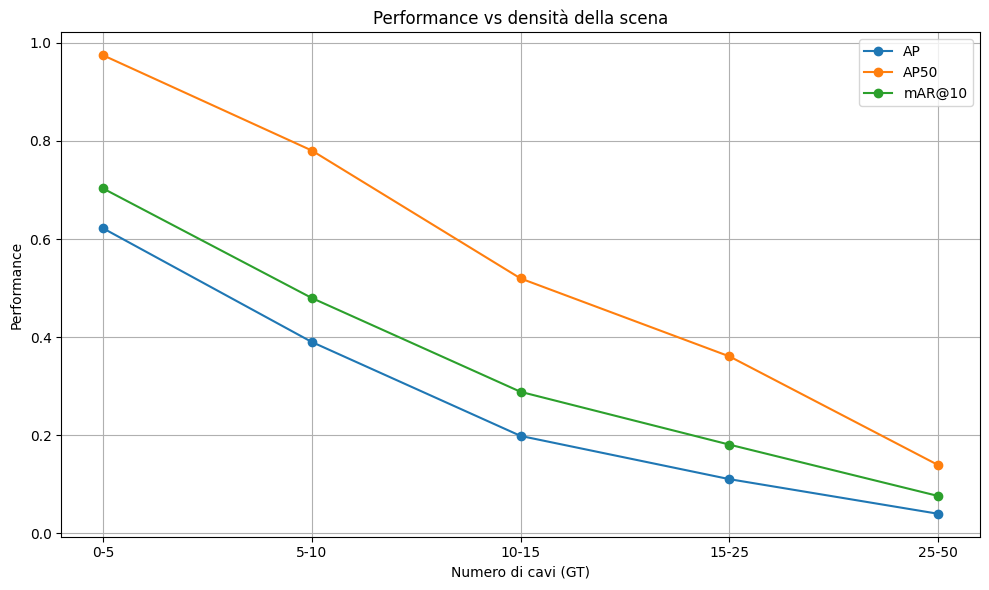


BIN | #IMG | AP | AP50 | mAR@10
     0-5 |  182 | 0.622 | 0.975 | 0.703
    5-10 |  103 | 0.390 | 0.780 | 0.480
   10-15 |   44 | 0.199 | 0.520 | 0.288
   15-25 |   46 | 0.110 | 0.361 | 0.181
   25-50 |   24 | 0.040 | 0.139 | 0.076


In [ ]:
# ===============================
# COCOeval vs densità (#cavi GT) — FIX DEFINITIVO
# ===============================

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ===============================
# PATHS
# ===============================
GT_JSON = "/content/drive/MyDrive/test/test.json"
PRED_JSON = "/content/drive/MyDrive/predictions_lds2.json"

# ===============================
# LOAD
# ===============================
coco_gt = COCO(GT_JSON)
coco_pred = coco_gt.loadRes(PRED_JSON)

# ===============================
# DENSITÀ PER IMMAGINE
# ===============================
density = {}
for img in coco_gt.dataset["images"]:
    img_id = img["id"]
    density[img_id] = len(coco_gt.getAnnIds(imgIds=img_id))

# ===============================
# BIN DI DENSITÀ
# ===============================
bins = [(0,5), (5,10), (10,15), (15,25), (25,50)]
bin_labels = [f"{a}-{b}" for a,b in bins]

bin_img_ids = defaultdict(list)
for img_id, d in density.items():
    for (a,b), label in zip(bins, bin_labels):
        if a <= d < b:
            bin_img_ids[label].append(img_id)
            break

# ===============================
# COCOeval PER BIN
# ===============================
results = []

for label in bin_labels:
    img_ids = bin_img_ids[label]

    if len(img_ids) < 5:
        continue

    coco_eval = COCOeval(coco_gt, coco_pred, iouType="segm")
    coco_eval.params.imgIds = img_ids

    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()   # <<< QUESTA ERA LA CHIAVE

    if len(coco_eval.stats) != 12:
        print(f"⚠️ Bin {label} ignorato (stats non valide)")
        continue

    s = coco_eval.stats

    results.append({
        "bin": label,
        "count": len(img_ids),
        "AP": s[0],
        "AP50": s[1],
        "AP75": s[2],
        "mAR@10": s[8]
    })

# ===============================
# PLOT
# ===============================
labels = [r["bin"] for r in results]
x = np.arange(len(labels))

AP = [r["AP"] for r in results]
AP50 = [r["AP50"] for r in results]
mAR = [r["mAR@10"] for r in results]

plt.figure(figsize=(10,6))
plt.plot(x, AP, marker="o", label="AP")
plt.plot(x, AP50, marker="o", label="AP50")
plt.plot(x, mAR, marker="o", label="mAR@10")

plt.xticks(x, labels)
plt.xlabel("Numero di cavi (GT)")
plt.ylabel("Performance")
plt.title("Performance vs densità della scena")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# TABELLA
# ===============================
print("\nBIN | #IMG | AP | AP50 | mAR@10")
for r in results:
    print(f"{r['bin']:>8s} | {r['count']:4d} | {r['AP']:.3f} | {r['AP50']:.3f} | {r['mAR@10']:.3f}")


In [ ]:
# ===============================
# NON-ORACLE FP FILTER (COCO)
# ===============================

import json
import numpy as np
from collections import defaultdict
from pycocotools import mask as coco_mask

# ===============================
# PATHS
# ===============================
PRED_JSON_IN  = "/content/drive/MyDrive/predictions_lds2.json"
PRED_JSON_OUT = "/content/drive/MyDrive/predictions_lds2_filtered.json"

# ===============================
# PARAMETRI (SAFE DEFAULT)
# ===============================
MAX_PRED_SPARSE = 80
MAX_PRED_DENSE  = 30

FP_ONLY_THRESHOLD = 200     # se >200 pred
FP_ONLY_MEAN_SCORE = 0.15   # e score medio < 0.15 → drop tutto

MIN_SCORE = 0.05
MIN_AREA  = 40              # pixel
MIN_ASPECT_RATIO = 3.0      # cavi = allungati

# ===============================
# LOAD PRED
# ===============================
with open(PRED_JSON_IN, "r") as f:
    preds = json.load(f)

preds_by_img = defaultdict(list)
for p in preds:
    preds_by_img[p["image_id"]].append(p)

filtered_preds = []

# ===============================
# UTILS
# ===============================
def mask_area(seg):
    if isinstance(seg, dict):  # RLE
        return coco_mask.area(seg)
    return 0

def bbox_aspect_ratio(bbox):
    _, _, w, h = bbox
    if min(w, h) == 0:
        return 0
    return max(w, h) / min(w, h)

# ===============================
# FILTER LOOP
# ===============================
for img_id, plist in preds_by_img.items():

    n_pred = len(plist)
    scores = np.array([p["score"] for p in plist])
    mean_score = scores.mean() if n_pred > 0 else 0

    # --------------------------------
    # 1️⃣ DROP FP-ONLY IMAGES
    # --------------------------------
    if n_pred > FP_ONLY_THRESHOLD and mean_score < FP_ONLY_MEAN_SCORE:
        continue

    # --------------------------------
    # 2️⃣ SORT BY SCORE
    # --------------------------------
    plist = sorted(plist, key=lambda x: x["score"], reverse=True)

    # --------------------------------
    # 3️⃣ DENSITY-AWARE TOP-K
    # --------------------------------
    max_k = MAX_PRED_DENSE if n_pred > 50 else MAX_PRED_SPARSE
    plist = plist[:max_k]

    # --------------------------------
    # 4️⃣ PER-PRED FILTER
    # --------------------------------
    for p in plist:

        if p["score"] < MIN_SCORE:
            continue

        area = mask_area(p["segmentation"])
        if area < MIN_AREA:
            continue

        ar = bbox_aspect_ratio(p["bbox"])
        if ar < MIN_ASPECT_RATIO:
            continue

        filtered_preds.append(p)

# ===============================
# SAVE
# ===============================
with open(PRED_JSON_OUT, "w") as f:
    json.dump(filtered_preds, f)

print("================================")
print("NON-ORACLE FP FILTER COMPLETATO")
print(f"Input preds : {len(preds)}")
print(f"Output preds: {len(filtered_preds)}")
print(f"Salvato in  : {PRED_JSON_OUT}")
print("================================")


NON-ORACLE FP FILTER COMPLETATO
Input preds : 15214
Output preds: 3577
Salvato in  : /content/drive/MyDrive/predictions_lds2_filtered.json


In [ ]:
# ===============================
# ANALISI NUMERICA FALSE NEGATIVES vs DENSITÀ
# ===============================

import json
import numpy as np
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# ===============================
# PATHS
# ===============================
GT_JSON   = "/content/drive/MyDrive/test/test.json"
PRED_JSON = "/content/drive/MyDrive/predictions_lds2.json"

IOU_TH = 0.1   # soglia bassa: basta "toccare" il GT

# ===============================
# LOAD
# ===============================
coco_gt = COCO(GT_JSON)

with open(PRED_JSON, "r") as f:
    preds = json.load(f)

preds_by_img = defaultdict(list)
for p in preds:
    preds_by_img[p["image_id"]].append(p)

# ===============================
# UTILS
# ===============================
def decode_mask(seg, h, w):
    if isinstance(seg, dict):
        m = coco_mask.decode(seg)
        if m.ndim == 3:
            m = m[:, :, 0]
        return m.astype(bool)
    elif isinstance(seg, list):
        mask = np.zeros((h, w), dtype=np.uint8)
        for poly in seg:
            pts = np.array(poly).reshape(-1,2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 1)
        return mask.astype(bool)
    return None

def mask_iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return inter / union if union > 0 else 0.0

# ===============================
# BIN DI DENSITÀ
# ===============================
bins = [(0,5), (5,10), (10,15), (15,20), (20,1000)]
bin_labels = [f"{a}-{b}" for a,b in bins]

stats = {
    label: {"GT":0, "TP":0, "FN":0}
    for label in bin_labels
}

# ===============================
# LOOP PRINCIPALE
# ===============================
for img in coco_gt.dataset["images"]:
    img_id = img["id"]
    h, w = img["height"], img["width"]

    gt_ids = coco_gt.getAnnIds(imgIds=img_id)
    n_gt = len(gt_ids)

    # assegna bin
    label = None
    for (a,b), l in zip(bins, bin_labels):
        if a <= n_gt < b:
            label = l
            break
    if label is None or n_gt == 0:
        continue

    pred_list = preds_by_img.get(img_id, [])
    pred_masks = [
        decode_mask(p["segmentation"], h, w)
        for p in pred_list
    ]

    for ann_id in gt_ids:
        ann = coco_gt.loadAnns(ann_id)[0]
        gt_mask = decode_mask(ann["segmentation"], h, w)

        best_iou = 0.0
        for pm in pred_masks:
            if pm is None:
                continue
            best_iou = max(best_iou, mask_iou(gt_mask, pm))

        stats[label]["GT"] += 1
        if best_iou >= IOU_TH:
            stats[label]["TP"] += 1
        else:
            stats[label]["FN"] += 1

# ===============================
# STAMPA RISULTATI
# ===============================
print("BIN | GT | TP | FN | FN-rate | Recall")
print("-------------------------------------------")
for label in bin_labels:
    GT = stats[label]["GT"]
    TP = stats[label]["TP"]
    FN = stats[label]["FN"]

    if GT == 0:
        continue

    fn_rate = FN / GT
    recall = TP / GT

    print(
        f"{label:>8s} | "
        f"{GT:4d} | {TP:4d} | {FN:4d} | "
        f"{fn_rate:6.3f} | {recall:6.3f}"
    )


loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
BIN | GT | TP | FN | FN-rate | Recall
-------------------------------------------
     0-5 |  519 |  519 |    0 |  0.000 |  1.000
    5-10 |  661 |  633 |   28 |  0.042 |  0.958
   10-15 |  510 |  432 |   78 |  0.153 |  0.847
   15-20 |  487 |  392 |   95 |  0.195 |  0.805
 20-1000 | 1151 |  591 |  560 |  0.487 |  0.513


loading annotations into memory...
Done (t=0.09s)
creating index...
index created!


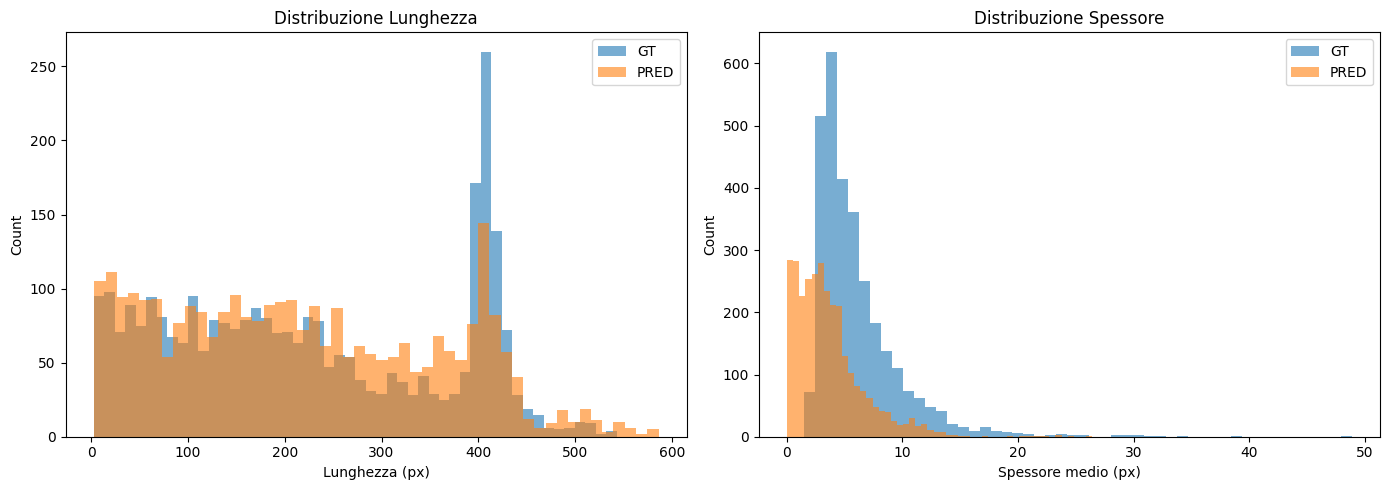


===== LUNGHEZZA =====
GT     | mean=226.69 | median=206.96 | p90=414.21
PRED   | mean=218.79 | median=203.27 | p90=409.37

===== SPESSORE =====
GT     | mean=6.10 | median=5.06 | p90=10.44
PRED   | mean=3.65 | median=3.04 | p90=7.47


In [ ]:
# ===============================
# DISTRIBUZIONE LUNGHEZZA / SPESSORE
# GT vs PRED
# ===============================

import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# ===============================
# PATHS
# ===============================
GT_JSON   = "/content/drive/MyDrive/test/test.json"
PRED_JSON = "/content/drive/MyDrive/predictions_lds2.json"

MAX_INSTANCES = 3000   # safety cap

# ===============================
# LOAD
# ===============================
coco_gt = COCO(GT_JSON)

with open(PRED_JSON, "r") as f:
    preds = json.load(f)

# ===============================
# UTILS
# ===============================
import cv2
import numpy as np
from pycocotools import mask as coco_mask

def decode_mask(seg, h, w):
    # RLE
    if isinstance(seg, dict):
        m = coco_mask.decode(seg)
        if m.ndim == 3:
            m = m[:, :, 0]
        return m.astype(bool)

    # POLYGON
    if isinstance(seg, list):
        mask = np.zeros((h, w), dtype=np.uint8)
        for poly in seg:
            pts = np.array(poly).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 1)
        return mask.astype(bool)

    return None


def length_thickness(mask):
    ys, xs = np.where(mask)
    if len(xs) < 10:
        return None

    coords = np.stack([xs, ys], axis=1).astype(np.float32)
    coords -= coords.mean(axis=0)

    cov = np.cov(coords.T)
    eigvals, _ = np.linalg.eig(cov)
    eigvals = np.sort(eigvals)[::-1]

    length = 2 * np.sqrt(eigvals[0])     # asse maggiore
    area = mask.sum()
    thickness = area / max(length, 1e-6)

    return length, thickness

# ===============================
# COLLECT GT
# ===============================
gt_L, gt_T = [], []

for img in coco_gt.dataset["images"]:
    img_id = img["id"]
    h, w = img["height"], img["width"]

    for ann_id in coco_gt.getAnnIds(imgIds=img_id):
        ann = coco_gt.loadAnns(ann_id)[0]
        mask = decode_mask(ann["segmentation"], h, w)
        if mask is None:
            continue

        res = length_thickness(mask)
        if res is None:
            continue

        L, T = res
        gt_L.append(L)
        gt_T.append(T)

        if len(gt_L) >= MAX_INSTANCES:
            break
    if len(gt_L) >= MAX_INSTANCES:
        break

# ===============================
# COLLECT PRED
# ===============================
pred_L, pred_T = [], []

for p in preds:
    h, w = p["segmentation"]["size"]
    mask = decode_mask(p["segmentation"], h, w)
    if mask is None:
        continue

    res = length_thickness(mask)
    if res is None:
        continue

    L, T = res
    pred_L.append(L)
    pred_T.append(T)

    if len(pred_L) >= MAX_INSTANCES:
        break

# ===============================
# PLOT DISTRIBUZIONI
# ===============================
plt.figure(figsize=(14,5))

# ---- Lunghezza ----
plt.subplot(1,2,1)
plt.hist(gt_L, bins=50, alpha=0.6, label="GT")
plt.hist(pred_L, bins=50, alpha=0.6, label="PRED")
plt.xlabel("Lunghezza (px)")
plt.ylabel("Count")
plt.title("Distribuzione Lunghezza")
plt.legend()

# ---- Spessore ----
plt.subplot(1,2,2)
plt.hist(gt_T, bins=50, alpha=0.6, label="GT")
plt.hist(pred_T, bins=50, alpha=0.6, label="PRED")
plt.xlabel("Spessore medio (px)")
plt.ylabel("Count")
plt.title("Distribuzione Spessore")
plt.legend()

plt.tight_layout()
plt.show()

# ===============================
# STATS RIASSUNTIVE
# ===============================
def stats(name, arr):
    arr = np.array(arr)
    print(
        f"{name:6s} | "
        f"mean={arr.mean():.2f} | "
        f"median={np.median(arr):.2f} | "
        f"p90={np.percentile(arr,90):.2f}"
    )

print("\n===== LUNGHEZZA =====")
stats("GT", gt_L)
stats("PRED", pred_L)

print("\n===== SPESSORE =====")
stats("GT", gt_T)
stats("PRED", pred_T)


loading annotations into memory...
Done (t=0.09s)
creating index...
index created!


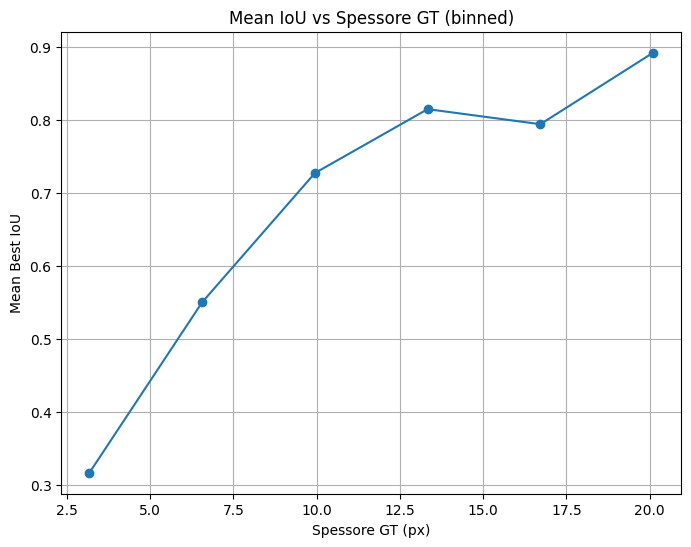

In [ ]:
# ===============================
# IoU vs SPESSORE GT
# ===============================

import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
import cv2

# ===============================
# PATHS
# ===============================
GT_JSON   = "/content/drive/MyDrive/test/test.json"
PRED_JSON = "/content/drive/MyDrive/predictions_lds2.json"

IOU_MIN_MATCH = 0.0   # consideriamo anche 0
MAX_SAMPLES = 4000    # safety

# ===============================
# LOAD
# ===============================
coco_gt = COCO(GT_JSON)
with open(PRED_JSON, "r") as f:
    preds = json.load(f)

preds_by_img = defaultdict(list)
for p in preds:
    preds_by_img[p["image_id"]].append(p)

# ===============================
# UTILS
# ===============================
def decode_mask(seg, h, w):
    if isinstance(seg, dict):
        m = coco_mask.decode(seg)
        if m.ndim == 3:
            m = m[:, :, 0]
        return m.astype(bool)
    if isinstance(seg, list):
        mask = np.zeros((h, w), dtype=np.uint8)
        for poly in seg:
            pts = np.array(poly).reshape(-1,2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 1)
        return mask.astype(bool)
    return None

def length_thickness(mask):
    ys, xs = np.where(mask)
    if len(xs) < 20:
        return None

    coords = np.stack([xs, ys], axis=1).astype(np.float32)
    coords -= coords.mean(axis=0)

    cov = np.cov(coords.T)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.sort(eigvals)[::-1]

    length = 2 * np.sqrt(eigvals[0])
    area = mask.sum()
    thickness = area / max(length, 1e-6)

    return thickness

def mask_iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return inter / union if union > 0 else 0.0

# ===============================
# COLLECT (THICKNESS, IoU)
# ===============================
gt_thickness = []
best_ious = []

for img in coco_gt.dataset["images"]:
    img_id = img["id"]
    h, w = img["height"], img["width"]

    pred_masks = []
    for p in preds_by_img.get(img_id, []):
        pm = decode_mask(p["segmentation"], h, w)
        if pm is not None:
            pred_masks.append(pm)

    if len(pred_masks) == 0:
        continue

    for ann_id in coco_gt.getAnnIds(imgIds=img_id):
        ann = coco_gt.loadAnns(ann_id)[0]
        gt_mask = decode_mask(ann["segmentation"], h, w)
        if gt_mask is None:
            continue

        thick = length_thickness(gt_mask)
        if thick is None:
            continue

        best_iou = 0.0
        for pm in pred_masks:
            best_iou = max(best_iou, mask_iou(gt_mask, pm))

        gt_thickness.append(thick)
        best_ious.append(best_iou)

        if len(gt_thickness) >= MAX_SAMPLES:
            break
    if len(gt_thickness) >= MAX_SAMPLES:
        break

gt_thickness = np.array(gt_thickness)
best_ious = np.array(best_ious)

# ===============================
# SCATTER + BINNING
# ===============================
plt.figure(figsize=(8,6))
plt.scatter(gt_thickness, best_ious, s=8, alpha=0.4)
plt.xlabel("Spessore GT (px)")
plt.ylabel("Best IoU with predictions")
plt.title("IoU vs Spessore GT")
plt.grid(True)
plt.show()

# ===============================
# BINNED MEAN IoU
# ===============================
bins = np.linspace(gt_thickness.min(), gt_thickness.max(), 15)
bin_centers = []
bin_iou_mean = []

for i in range(len(bins)-1):
    mask = (gt_thickness >= bins[i]) & (gt_thickness < bins[i+1])
    if mask.sum() < 20:
        continue
    bin_centers.append(0.5 * (bins[i] + bins[i+1]))
    bin_iou_mean.append(best_ious[mask].mean())

plt.figure(figsize=(8,6))
plt.plot(bin_centers, bin_iou_mean, marker="o")
plt.xlabel("Spessore GT (px)")
plt.ylabel("Mean Best IoU")
plt.title("Mean IoU vs Spessore GT (binned)")
plt.grid(True)
plt.show()
